# RideBase — 02 EDA: Veri Sözlüğü ve DataFrame Hazırlığı

Bu notebook RideBase Synthetic Dataset **v1.1** içindeki 19 tablonun amacını ve bütün sütunlarını açıklar; ardından dosyaları açık dataframe değişkenlerine yükler.

Her sütun için teknik İngilizce adın yanında **Türkçe karşılık**, sade anlam ve gerçek örnek değer verilir. Buradaki **anlam/semantik**, bir sütunun yalnızca veri tipini değil, gerçek hayatta neyi temsil ettiğini ve nasıl yorumlanması gerektiğini ifade eder.

> Not: Yüksek NULL oranı tek başına veri hatası değildir. Right-censoring, aktif varlıklar, uygulanabilirlik kuralları, opsiyonel metinler ve bilinmeyen teknik özellikler gerçek NULL ile temsil edilir.

## Veri katmanları

- **source_tables:** İlişkisel operasyon ve master tabloları.
- **derived_outputs:** Canonical zaman çizelgesi, audit, ML feature/target ve split tabloları.
- `services.csv` base event tablosudur; maliyet analizi için `services_enriched.csv` kullanılmalıdır.
- Snapshot feature'ları yalnızca `snapshot_at` anına kadar olan bilgileri içerir; gelecek hedefleri ayrı tablolardadır.

## Tablolar ve tüm sütunların açıklamaları

### `workshops` — `workshops.csv`

**DataFrame:** `df_workshops`  
**Katman:** `source_tables`  
**Amaç:** Servis noktalarının konum, kapasite, uzmanlık, fiyat ve operasyon özellikleri.  
**Sütun sayısı:** 35

Aşağıda her sütun yatay kaydırma gerektirmeyen dikey bilgi kartı biçiminde açıklanmıştır.

#### 1. `workshop_id` — servis noktası kimliği

- **Veri tipi:** `object`
- **Ne demek?** Servis noktasının benzersiz kimliği.
- **Veri içinden örnekler:** `WS0001`, `WS0002`, `WS0003`

---

#### 2. `workshop_name` — servis noktası adı

- **Veri tipi:** `object`
- **Ne demek?** Servis noktasına verilen sentetik işletme adı. Gerçek bir işletmeyi temsil etmez; raporlarda servisleri okunabilir adla göstermek için kullanılır.
- **Veri içinden örnekler:** `RideBase Sentetik Servis İstanbul Anadolu`, `RideBase Sentetik Servis Ankara`, `RideBase Sentetik Servis İzmir`

---

#### 3. `city` — şehir

- **Veri tipi:** `object`
- **Ne demek?** Servis noktasının veya müşterinin bulunduğu şehir. Bölgesel servis yoğunluğu ve kullanım farklılıklarını karşılaştırmak için kullanılır.
- **Veri içinden örnekler:** `İstanbul`, `Ankara`, `İzmir`

---

#### 4. `district_profile` — yerleşim bölgesi profili

- **Veri tipi:** `object`
- **Ne demek?** Servis çevresinin yerleşim karakteri. Örneğin yoğun metropol, banliyö veya daha seyrek yerleşim; trafik, müşteri hacmi ve kullanım biçimini temsil eden sentetik kategoridir.
- **Veri içinden örnekler:** `METROPOLITAN_DENSE`, `METROPOLITAN`, `COASTAL_METROPOLITAN`

---

#### 5. `region` — coğrafi bölge

- **Veri tipi:** `object`
- **Ne demek?** Şehrin bağlı olduğu coğrafi bölge; örneğin Marmara veya Ege. Bölgesel karşılaştırmalarda kullanılır.
- **Veri içinden örnekler:** `Marmara`, `İç Anadolu`, `Ege`

---

#### 6. `climate_zone` — iklim bölgesi sınıfı

- **Veri tipi:** `object`
- **Ne demek?** Kullanım bölgesinin iklim sınıfı. Sıcaklık ve nem gibi çevresel koşulların sürüş mevsimselliği ve bakım/aşınma simülasyonuna etkisini temsil eder; gerçek zamanlı hava durumu değildir.
- **Veri içinden örnekler:** `TEMPERATE_HUMID`, `CONTINENTAL_DRY`, `MEDITERRANEAN_COASTAL`

---

#### 7. `price_level` — fiyat seviyesi

- **Veri tipi:** `object`
- **Ne demek?** Servis noktasının göreli fiyat segmenti. LOW/MEDIUM/HIGH gibi sınıflar gerçek TL tarifesi değil, servisler arası fiyat seviyesi farkını simüle eder.
- **Veri içinden örnekler:** `LOW`, `MEDIUM`, `HIGH`

---

#### 8. `opening_time` — açılış saati

- **Veri tipi:** `object`
- **Ne demek?** Servis noktasının normal çalışma günlerindeki açılış saati.
- **Veri içinden örnekler:** `08:30`, `09:00`, `08:00`

---

#### 9. `closing_time` — kapanış saati

- **Veri tipi:** `object`
- **Ne demek?** Servis noktasının normal çalışma günlerindeki kapanış saati.
- **Veri içinden örnekler:** `18:30`, `18:00`, `19:00`

---

#### 10. `working_days` — çalışma günleri

- **Veri tipi:** `object`
- **Ne demek?** Servisin düzenli açık olduğu haftanın günleri. Virgülle ayrılmış gün kodları kullanılır; MON Pazartesi, TUE Salı vb.
- **Veri içinden örnekler:** `MON,TUE,WED,THU,FRI,SAT`

---

#### 11. `sunday_open` — pazar günü açık mı

- **Veri tipi:** `int64`
- **Ne demek?** Servis pazar günü açıksa 1, kapalıysa 0.
- **Veri içinden örnekler:** `1`, `0`

---

#### 12. `service_bay_count` — servis çalışma istasyonu sayısı

- **Veri tipi:** `int64`
- **Ne demek?** Aynı anda motosiklet üzerinde çalışılabilen fiziksel servis istasyonu/lift alanı sayısı.
- **Veri içinden örnekler:** `4`, `6`, `7`

---

#### 13. `technician_count` — teknisyen sayısı

- **Veri tipi:** `int64`
- **Ne demek?** Servis noktasındaki toplam teknisyen sayısı.
- **Veri içinden örnekler:** `5`, `7`, `8`

---

#### 14. `senior_technician_count` — kıdemli teknisyen sayısı

- **Veri tipi:** `int64`
- **Ne demek?** Toplam teknisyenler içindeki kıdemli teknisyen sayısı.
- **Veri içinden örnekler:** `1`, `2`, `3`

---

#### 15. `daily_service_capacity` — günlük servis kapasitesi

- **Veri tipi:** `int64`
- **Ne demek?** Servis noktasının bir iş gününde tamamlayabileceği yaklaşık motosiklet sayısı.
- **Veri içinden örnekler:** `11`, `15`, `18`

---

#### 16. `appointment_rate` — randevulu geliş oranı

- **Veri tipi:** `float64`
- **Ne demek?** Servislerin randevulu gelme payı. 0,45 değeri yaklaşık %45 demektir.
- **Veri içinden örnekler:** `0.45`, `0.58`, `0.62`

---

#### 17. `walk_in_rate` — randevusuz geliş oranı

- **Veri tipi:** `float64`
- **Ne demek?** Randevusuz gelen servislerin payı. 0,55 değeri yaklaşık %55 demektir.
- **Veri içinden örnekler:** `0.55`, `0.42`, `0.38`

---

#### 18. `avg_parts_lead_days` — ortalama parça tedarik süresi

- **Veri tipi:** `float64`
- **Ne demek?** Stokta olmayan bir parçanın servise ulaşması için gereken ortalama gün sayısı.
- **Veri içinden örnekler:** `2.0`, `1.8`, `1.5`

---

#### 19. `same_day_parts_rate` — aynı gün parça temin oranı

- **Veri tipi:** `float64`
- **Ne demek?** Gerekli parçanın aynı gün temin edilebilme oranı. 0–1 aralığındadır.
- **Veri içinden örnekler:** `0.72`, `0.78`, `0.82`

---

#### 20. `multibrand` — çok markalı servis mi

- **Veri tipi:** `int64`
- **Ne demek?** Servis birden fazla motosiklet markasına hizmet veriyorsa 1; tek marka/uzman servis ise 0.
- **Veri içinden örnekler:** `1`

---

#### 21. `specialization` — uzmanlık alanları

- **Veri tipi:** `object`
- **Ne demek?** Servisin yoğunlaştığı motosiklet kategorileri. Birden fazla kategori noktalı virgülle ayrılabilir.
- **Veri içinden örnekler:** `SCOOTER;CUB;COMMUTER`, `NAKED;SCOOTER;TOURING`, `SCOOTER;BIG_SCOOTER;NAKED`

---

#### 22. `supported_powertrains` — desteklenen güç sistemleri

- **Veri tipi:** `object`
- **Ne demek?** Servisin bakım yapabildiği güç sistemi türleri; örneğin ICE içten yanmalı, EV elektrikli motosiklet.
- **Veri içinden örnekler:** `ICE;EV`, `ICE`

---

#### 23. `supported_final_drives` — desteklenen son aktarım türleri

- **Veri tipi:** `object`
- **Ne demek?** Servisin desteklediği son aktarım sistemleri; örneğin CHAIN zincir, V_BELT kayış, SHAFT şaft.
- **Veri içinden örnekler:** `CHAIN;V_BELT;DIRECT`, `CHAIN;V_BELT;BELT;DIRECT`, `CHAIN;V_BELT;BELT;SHAFT;DIRECT`

---

#### 24. `supports_ev` — elektrikli motosiklet desteği

- **Veri tipi:** `int64`
- **Ne demek?** Servis elektrikli motosiklete hizmet verebiliyorsa 1.
- **Veri içinden örnekler:** `1`, `0`

---

#### 25. `supports_abs_diagnostics` — ABS teşhis desteği

- **Veri tipi:** `int64`
- **Ne demek?** Serviste ABS arıza tespit imkânı varsa 1.
- **Veri içinden örnekler:** `1`

---

#### 26. `supports_advanced_diagnostics` — ileri teşhis desteği

- **Veri tipi:** `int64`
- **Ne demek?** Serviste ileri seviye elektronik/ECU teşhis imkânı varsa 1.
- **Veri içinden örnekler:** `0`, `1`

---

#### 27. `labor_rate_index` — işçilik fiyat endeksi

- **Veri tipi:** `float64`
- **Ne demek?** Servisin işçilik fiyatını referans seviyeye göre çarpan göreli endeks. 1,0 referans; 1,2 yaklaşık %20 daha yüksek fiyat seviyesi demektir.
- **Veri içinden örnekler:** `0.9`, `1.0`, `1.02`

---

#### 28. `parts_sale_multiplier` — parça satış çarpanı

- **Veri tipi:** `float64`
- **Ne demek?** Parça alış maliyetinden satış fiyatına geçerken kullanılan servis bazlı göreli çarpan.
- **Veri içinden örnekler:** `0.92`, `1.0`, `1.03`

---

#### 29. `customer_volume_index` — müşteri hacmi endeksi

- **Veri tipi:** `float64`
- **Ne demek?** Servisin göreli müşteri yoğunluğu endeksi. 1,0 referans hacmi temsil eder.
- **Veri içinden örnekler:** `1.25`, `1.05`, `1.18`

---

#### 30. `courier_customer_share` — kurye müşteri payı

- **Veri tipi:** `float64`
- **Ne demek?** Müşteriler içinde kurye/yoğun ticari kullanım profiline sahip olanların tahmini payı.
- **Veri içinden örnekler:** `0.28`, `0.18`, `0.22`

---

#### 31. `seasonality_strength` — mevsimsellik gücü

- **Veri tipi:** `float64`
- **Ne demek?** Kullanım veya servis talebinin mevsimlere göre ne kadar değiştiğini gösteren 0–1 arası sentetik güç katsayısı.
- **Veri içinden örnekler:** `0.12`, `0.25`, `0.1`

---

#### 32. `data_origin` — veri kökeni

- **Veri tipi:** `object`
- **Ne demek?** Kaydın nereden geldiğini gösterir. SYNTHETIC değeri, kaydın gerçek bir müşteri, motosiklet veya servis işleminden alınmadığını; bilgisayar tarafından yapay olarak üretildiğini belirtir. Veri analizi sırasında gerçek operasyon verisiyle karıştırılmaması için tutulur.
- **Veri içinden örnekler:** `SYNTHETIC`

---

#### 33. `generator_version` — üretici sürümü

- **Veri tipi:** `object`
- **Ne demek?** Kaydı oluşturan sentetik veri üretim kodunun ve kurallarının sürümüdür. 1.1.0 değeri, kaydın RideBase v1.1 üretim kurallarıyla hazırlandığını gösterir. Bu alan motosikletin ECU/yazılım sürümü değildir; veri üretimini izlemek ve farklı dataset sürümlerini ayırmak içindir.
- **Veri içinden örnekler:** `1.1.0`

---

#### 34. `scenario_id` — senaryo kimliği

- **Veri tipi:** `object`
- **Ne demek?** Sentetik üretim senaryosu kimliği.
- **Veri içinden örnekler:** `URBAN_VALUE_HIGH_VOLUME`, `BALANCED_MULTIBRAND`, `COASTAL_SCOOTER_HEAVY`

---

#### 35. `notes` — notlar

- **Veri tipi:** `object`
- **Ne demek?** Kayıt hakkında gerektiğinde ek açıklama yazılabilecek opsiyonel not alanıdır. Bu tabloda bütün değerler boşsa pandas veri tipini float64 olarak tahmin edebilir; buna rağmen alanın kavramsal anlamı sayısal ölçüm değil serbest metindir. Boş olması veri hatası değildir.
- **Veri içinden örnekler:** `Yüksek hacimli, fiyat hassasiyeti yüksek şehir içi serv…`, `Dengeli randevu/yaya geliş oranı olan çok markalı merke…`, `Ilıman iklim nedeniyle yıl boyu daha yüksek scooter kul…`

### `customers` — `customers.csv`

**DataFrame:** `df_customers`  
**Katman:** `source_tables`  
**Amaç:** Müşteri kimliği, segmenti, bağlı olduğu servis ve müşteri yaşam döngüsü bilgileri.  
**Sütun sayısı:** 16

Aşağıda her sütun yatay kaydırma gerektirmeyen dikey bilgi kartı biçiminde açıklanmıştır.

#### 1. `customer_id` — müşteri kimliği

- **Veri tipi:** `object`
- **Ne demek?** Müşterinin benzersiz kimliği.
- **Veri içinden örnekler:** `C000001`, `C000002`, `C000003`

---

#### 2. `workshop_id` — servis noktası kimliği

- **Veri tipi:** `object`
- **Ne demek?** Servis noktasının benzersiz kimliği.
- **Veri içinden örnekler:** `WS0003`, `WS0008`, `WS0009`

---

#### 3. `customer_type` — müşteri tür

- **Veri tipi:** `object`
- **Ne demek?** Müşteri tür bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `INDIVIDUAL`, `FLEET`, `COMMERCIAL`

---

#### 4. `first_seen_date` — first seen tarih

- **Veri tipi:** `object`
- **Ne demek?** First seen tarihi.
- **Veri içinden örnekler:** `2024-06-08`, `2023-07-10`, `2023-06-22`

---

#### 5. `city` — şehir

- **Veri tipi:** `object`
- **Ne demek?** Servis noktasının veya müşterinin bulunduğu şehir. Bölgesel servis yoğunluğu ve kullanım farklılıklarını karşılaştırmak için kullanılır.
- **Veri içinden örnekler:** `İzmir`, `Gaziantep`, `Samsun`

---

#### 6. `region` — coğrafi bölge

- **Veri tipi:** `object`
- **Ne demek?** Şehrin bağlı olduğu coğrafi bölge; örneğin Marmara veya Ege. Bölgesel karşılaştırmalarda kullanılır.
- **Veri içinden örnekler:** `Ege`, `Güneydoğu Anadolu`, `Karadeniz`

---

#### 7. `is_fleet_customer` — mı fleet müşteri

- **Veri tipi:** `int64`
- **Ne demek?** Is fleet customer durumunu gösteren bayrak veya uygulanabilirlik alanı.
- **Veri içinden örnekler:** `0`, `1`

---

#### 8. `preferred_contact` — preferred contact

- **Veri tipi:** `object`
- **Ne demek?** Preferred contact bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `WHATSAPP`, `EMAIL`, `PHONE`

---

#### 9. `acquisition_channel` — acquisition channel

- **Veri tipi:** `object`
- **Ne demek?** Acquisition channel bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `GOOGLE_MAPS`, `WALK_IN`, `REFERRAL`

---

#### 10. `synthetic_alias` — synthetic alias

- **Veri tipi:** `object`
- **Ne demek?** Synthetic alias bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `Customer_000001`, `Customer_000002`, `Customer_000003`

---

#### 11. `is_active` — aktif mi

- **Veri tipi:** `int64`
- **Ne demek?** İlgili müşteri veya motosiklet kaydının veri setinin gözlem süresi sonunda RideBase sisteminde hâlâ takip edilip edilmediğini gösterir. 1 hâlâ aktif/takip ediliyor, 0 takip sona ermiş demektir. Motosikletin motorunun o anda çalışıp çalışmadığını göstermez.
- **Veri içinden örnekler:** `1`, `0`

---

#### 12. `churn_date` — müşteri ayrılma tarihi

- **Veri tipi:** `object`
- **Ne demek?** Pasif müşterinin ayrılma tarihi; aktif müşteride NULL.
- **Veri içinden örnekler:** `2026-02-17`, `2026-06-01`, `2022-03-09`

---

#### 13. `data_origin` — veri kökeni

- **Veri tipi:** `object`
- **Ne demek?** Kaydın nereden geldiğini gösterir. SYNTHETIC değeri, kaydın gerçek bir müşteri, motosiklet veya servis işleminden alınmadığını; bilgisayar tarafından yapay olarak üretildiğini belirtir. Veri analizi sırasında gerçek operasyon verisiyle karıştırılmaması için tutulur.
- **Veri içinden örnekler:** `SYNTHETIC`

---

#### 14. `generator_version` — üretici sürümü

- **Veri tipi:** `object`
- **Ne demek?** Kaydı oluşturan sentetik veri üretim kodunun ve kurallarının sürümüdür. 1.1.0 değeri, kaydın RideBase v1.1 üretim kurallarıyla hazırlandığını gösterir. Bu alan motosikletin ECU/yazılım sürümü değildir; veri üretimini izlemek ve farklı dataset sürümlerini ayırmak içindir.
- **Veri içinden örnekler:** `1.1.0`

---

#### 15. `random_seed` — rastgelelik tohumu

- **Veri tipi:** `int64`
- **Ne demek?** Sentetik üretimdeki rastgele görünen seçimleri tekrar üretilebilir yapan başlangıç sayısıdır. Seed 42 ve üretim kuralları aynı tutulursa aynı seçimler yeniden elde edilir. Gerçek dünyada müşteri veya motosiklete ait bir özellik değildir ve ML modeline verilmemelidir.
- **Veri içinden örnekler:** `42`

---

#### 16. `notes` — notlar

- **Veri tipi:** `float64`
- **Ne demek?** Kayıt hakkında gerektiğinde ek açıklama yazılabilecek opsiyonel not alanıdır. Bu tabloda bütün değerler boşsa pandas veri tipini float64 olarak tahmin edebilir; buna rağmen alanın kavramsal anlamı sayısal ölçüm değil serbest metindir. Boş olması veri hatası değildir.
- **Veri içinden örnekler:** NULL

### `motorcycles` — `motorcycles.csv`

**DataFrame:** `df_motorcycles`  
**Katman:** `source_tables`  
**Amaç:** Müşterilere ait motosiklet örnekleri; model, üretim yılı, sahiplik ve gözlem dönemi bilgileri.  
**Sütun sayısı:** 24

Aşağıda her sütun yatay kaydırma gerektirmeyen dikey bilgi kartı biçiminde açıklanmıştır.

#### 1. `motorcycle_id` — motosiklet kimliği

- **Veri tipi:** `object`
- **Ne demek?** Motosiklet örneğinin benzersiz kimliği.
- **Veri içinden örnekler:** `MC000001`, `MC000002`, `MC000003`

---

#### 2. `customer_id` — müşteri kimliği

- **Veri tipi:** `object`
- **Ne demek?** Müşterinin benzersiz kimliği.
- **Veri içinden örnekler:** `C000001`, `C000002`, `C000003`

---

#### 3. `workshop_id` — servis noktası kimliği

- **Veri tipi:** `object`
- **Ne demek?** Servis noktasının benzersiz kimliği.
- **Veri içinden örnekler:** `WS0003`, `WS0008`, `WS0009`

---

#### 4. `model_id` — model kimliği

- **Veri tipi:** `object`
- **Ne demek?** Teknik model masterına bağlanan model kimliği.
- **Veri içinden örnekler:** `YAMAHA_NMAX125`, `HONDA_PCX125`, `MONDIAL_50_UAG`

---

#### 5. `brand` — marka

- **Veri tipi:** `object`
- **Ne demek?** Motosiklet markası.
- **Veri içinden örnekler:** `Yamaha`, `Honda`, `Mondial`

---

#### 6. `model_name` — model adı

- **Veri tipi:** `object`
- **Ne demek?** Motosiklet model adı.
- **Veri içinden örnekler:** `NMAX 125`, `PCX125`, `50 UAG`

---

#### 7. `category` — motosiklet kategorisi

- **Veri tipi:** `object`
- **Ne demek?** Scooter, commuter, naked vb. motosiklet kategorisi.
- **Veri içinden örnekler:** `SCOOTER`, `CUB`, `BIG_SCOOTER`

---

#### 8. `powertrain_type` — güç sistemi türü

- **Veri tipi:** `object`
- **Ne demek?** Güç aktarma türü: ICE veya EV.
- **Veri içinden örnekler:** `ICE`, `EV`

---

#### 9. `production_year` — üretim yılı

- **Veri tipi:** `int64`
- **Ne demek?** Motosiklet örneğinin üretim yılı.
- **Veri içinden örnekler:** `2017`, `2021`, `2020`

---

#### 10. `production_year_basis` — production yıl dayanak

- **Veri tipi:** `object`
- **Ne demek?** Production year basis için kaynak/yöntem bilgisi.
- **Veri içinden örnekler:** `V1_1_SIMULATION_MODEL_RANGE_VALIDATED`

---

#### 11. `first_registration_date` — first registration tarih

- **Veri tipi:** `object`
- **Ne demek?** First registration tarihi.
- **Veri içinden örnekler:** `2017-02-16`, `2021-04-10`, `2020-04-22`

---

#### 12. `ownership_start_date` — ownership start tarih

- **Veri tipi:** `object`
- **Ne demek?** Ownership start tarihi.
- **Veri içinden örnekler:** `2019-01-05`, `2023-03-19`, `2022-08-26`

---

#### 13. `initial_mileage_km` — initial kilometre kilometre

- **Veri tipi:** `int64`
- **Ne demek?** Kilometre cinsinden initial mileage değeri.
- **Veri içinden örnekler:** `83780`, `27440`, `32650`

---

#### 14. `initial_mileage_basis` — initial kilometre dayanak

- **Veri tipi:** `object`
- **Ne demek?** Initial mileage basis için kaynak/yöntem bilgisi.
- **Veri içinden örnekler:** `AGE_CUSTOMER_TYPE_CATEGORY_PRIOR`

---

#### 15. `observation_start_date` — gözlem başlangıç tarihi

- **Veri tipi:** `object`
- **Ne demek?** Motosiklet gözlem döneminin başlangıç tarihi.
- **Veri içinden örnekler:** `2024-06-21`, `2023-07-12`, `2023-06-30`

---

#### 16. `observation_end_date` — gözlem bitiş tarihi

- **Veri tipi:** `object`
- **Ne demek?** Pasif motosiklette gözlem bitiş tarihi; aktif motosiklette NULL olabilir.
- **Veri içinden örnekler:** `2026-02-10`, `2026-08-25`, `2026-06-01`

---

#### 17. `vin_synthetic` — sentetik şasi numarası

- **Veri tipi:** `object`
- **Ne demek?** Motosiklet için yapay olarak üretilmiş şasi/araç kimlik numarasıdır. VIN, Vehicle Identification Number (Araç Kimlik Numarası) anlamına gelir. Örneğin RBSYN28086615C98F içindeki RB RideBase'i, SYN sentetik olduğunu, kalan karakterler ise benzersizliği temsil eder. Gerçek bir araca ait değildir. Tabloları birleştirmek için bunun yerine motorcycle_id kullanılmalı; benzersiz kimlik olduğu için ML özelliği olarak modele verilmemelidir.
- **Veri içinden örnekler:** `RBSYNE3EFA77D23F0`, `RBSYN022AACC9F763`, `RBSYN28086615C98F`

---

#### 18. `plate_synthetic` — sentetik plaka numarası

- **Veri tipi:** `object`
- **Ne demek?** Motosiklet için yapay olarak üretilmiş plaka numarasıdır. Örneğin SYN-35-000001 içinde SYN kaydın sentetik olduğunu, 35 simüle edilen şehir plaka kodunu, 000001 ise benzersiz sıra numarasını gösterir. Gerçek bir araç veya kişiye ait değildir. Tablo bağlantılarında motorcycle_id kullanılmalı; bu benzersiz kimlik ML modeline özellik olarak verilmemelidir.
- **Veri içinden örnekler:** `SYN-35-000001`, `SYN-27-000002`, `SYN-27-000003`

---

#### 19. `is_active` — aktif mi

- **Veri tipi:** `int64`
- **Ne demek?** İlgili müşteri veya motosiklet kaydının veri setinin gözlem süresi sonunda RideBase sisteminde hâlâ takip edilip edilmediğini gösterir. 1 hâlâ aktif/takip ediliyor, 0 takip sona ermiş demektir. Motosikletin motorunun o anda çalışıp çalışmadığını göstermez.
- **Veri içinden örnekler:** `1`, `0`

---

#### 20. `data_origin` — veri kökeni

- **Veri tipi:** `object`
- **Ne demek?** Kaydın nereden geldiğini gösterir. SYNTHETIC değeri, kaydın gerçek bir müşteri, motosiklet veya servis işleminden alınmadığını; bilgisayar tarafından yapay olarak üretildiğini belirtir. Veri analizi sırasında gerçek operasyon verisiyle karıştırılmaması için tutulur.
- **Veri içinden örnekler:** `SYNTHETIC`

---

#### 21. `generator_version` — üretici sürümü

- **Veri tipi:** `object`
- **Ne demek?** Kaydı oluşturan sentetik veri üretim kodunun ve kurallarının sürümüdür. 1.1.0 değeri, kaydın RideBase v1.1 üretim kurallarıyla hazırlandığını gösterir. Bu alan motosikletin ECU/yazılım sürümü değildir; veri üretimini izlemek ve farklı dataset sürümlerini ayırmak içindir.
- **Veri içinden örnekler:** `1.1.0`

---

#### 22. `random_seed` — rastgelelik tohumu

- **Veri tipi:** `int64`
- **Ne demek?** Sentetik üretimdeki rastgele görünen seçimleri tekrar üretilebilir yapan başlangıç sayısıdır. Seed 42 ve üretim kuralları aynı tutulursa aynı seçimler yeniden elde edilir. Gerçek dünyada müşteri veya motosiklete ait bir özellik değildir ve ML modeline verilmemelidir.
- **Veri içinden örnekler:** `42`

---

#### 23. `model_assignment_basis` — motosiklet modeli atama yöntemi

- **Veri tipi:** `object`
- **Ne demek?** Sentetik bir motosiklete hangi modelin atanacağını belirleyen yöntemin adıdır. MARKET_WEIGHT_X_CUSTOMER_TYPE_X_WORKSHOP_SPECIALIZATION ifadesi; modelin simülasyondaki pazar ağırlığının, müşteri tipinin ve bağlı servisin uzmanlık alanının birlikte değerlendirildiğini anlatır. Gerçek bir satış veya OEM atama kaydı değildir.
- **Veri içinden örnekler:** `MARKET_WEIGHT_X_CUSTOMER_TYPE_X_WORKSHOP_SPECIALIZATION`

---

#### 24. `notes` — notlar

- **Veri tipi:** `float64`
- **Ne demek?** Kayıt hakkında gerektiğinde ek açıklama yazılabilecek opsiyonel not alanıdır. Bu tabloda bütün değerler boşsa pandas veri tipini float64 olarak tahmin edebilir; buna rağmen alanın kavramsal anlamı sayısal ölçüm değil serbest metindir. Boş olması veri hatası değildir.
- **Veri içinden örnekler:** NULL

### `motorcycle_models` — `ridebase_motorcycle_models_v1.csv`

**DataFrame:** `df_motorcycle_models`  
**Katman:** `source_tables`  
**Amaç:** Motosiklet modellerinin teknik özellik masterı ve simülasyonda kullanılan model aralıkları.  
**Sütun sayısı:** 38

Aşağıda her sütun yatay kaydırma gerektirmeyen dikey bilgi kartı biçiminde açıklanmıştır.

#### 1. `model_id` — model kimliği

- **Veri tipi:** `object`
- **Ne demek?** Teknik model masterına bağlanan model kimliği.
- **Veri içinden örnekler:** `HONDA_PCX125`, `HONDA_ACTIVA125`, `TVS_JUPITER125`

---

#### 2. `brand` — marka

- **Veri tipi:** `object`
- **Ne demek?** Motosiklet markası.
- **Veri içinden örnekler:** `Honda`, `TVS`, `Kuba`

---

#### 3. `model_name` — model adı

- **Veri tipi:** `object`
- **Ne demek?** Motosiklet model adı.
- **Veri içinden örnekler:** `PCX125`, `Activa 125`, `Jupiter 125`

---

#### 4. `variant_or_generation` — variant or generation

- **Veri tipi:** `object`
- **Ne demek?** Variant or generation bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `current TR listing`, `TR listing`, `current`

---

#### 5. `category` — motosiklet kategorisi

- **Veri tipi:** `object`
- **Ne demek?** Scooter, commuter, naked vb. motosiklet kategorisi.
- **Veri içinden örnekler:** `SCOOTER`, `CUB`, `NAKED`

---

#### 6. `market_priority` — market priority

- **Veri tipi:** `object`
- **Ne demek?** Market priority bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `CORE`, `HIGH`, `MEDIUM`

---

#### 7. `generator_weight_raw` — generator weight raw

- **Veri tipi:** `float64`
- **Ne demek?** Generator weight raw bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `10.0`, `8.0`, `7.0`

---

#### 8. `generator_weight_seed` — generator weight seed

- **Veri tipi:** `float64`
- **Ne demek?** Generator weight seed bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `0.10627`, `0.085016`, `0.074389`

---

#### 9. `weight_basis` — weight dayanak

- **Veri tipi:** `object`
- **Ne demek?** Weight basis için kaynak/yöntem bilgisi.
- **Veri içinden örnekler:** `ENGINEERING_PRIOR_NOT_MARKET_SHARE`

---

#### 10. `powertrain_type` — güç sistemi türü

- **Veri tipi:** `object`
- **Ne demek?** Güç aktarma türü: ICE veya EV.
- **Veri içinden örnekler:** `ICE`, `EV`

---

#### 11. `engine_displacement_cc` — motor hacmi

- **Veri tipi:** `float64`
- **Ne demek?** Motor hacmi (cc); bilinmiyorsa NULL.
- **Veri içinden örnekler:** `125.0`, `124.0`, `124.8`

---

#### 12. `cylinder_count` — cylinder sayı

- **Veri tipi:** `int64`
- **Ne demek?** Cylinder adedi.
- **Veri içinden örnekler:** `1`, `2`, `0`

---

#### 13. `cooling_type` — soğutma türü

- **Veri tipi:** `object`
- **Ne demek?** Motor soğutma türü: AIR, OIL, LIQUID veya EV için NONE.
- **Veri içinden örnekler:** `LIQUID`, `AIR`, `OIL`

---

#### 14. `cooling_detail` — cooling detail

- **Veri tipi:** `object`
- **Ne demek?** Cooling detail bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `FAN_FORCED_AIR`, `AIR_OIL`, `OIL_COOLED`

---

#### 15. `final_drive_type` — son aktarım türü

- **Veri tipi:** `object`
- **Ne demek?** Son aktarım türü: zincir, kayış, şaft veya doğrudan aktarım.
- **Veri içinden örnekler:** `V_BELT`, `CHAIN`, `BELT`

---

#### 16. `transmission_type` — şanzıman türü

- **Veri tipi:** `object`
- **Ne demek?** Şanzıman/aktarma sistemi türü.
- **Veri içinden örnekler:** `CVT`, `MANUAL_5`, `AUTOMATIC`

---

#### 17. `engine_oil_service_qty_l` — servislik motor yağı miktarı

- **Veri tipi:** `float64`
- **Ne demek?** Bakımda kullanılan motor yağı miktarı (litre); bilinmiyorsa NULL.
- **Veri içinden örnekler:** `0.8`, `1.5`, `1.0`

---

#### 18. `oil_quantity_basis` — oil miktar dayanak

- **Veri tipi:** `object`
- **Ne demek?** Oil quantity basis için kaynak/yöntem bilgisi.
- **Veri içinden örnekler:** `2021 owner manual: after draining`, `2019 owner manual: after draining`, `2025 NSS250A/350A manual: with filter`

---

#### 19. `spark_plug_count` — buji sayısı

- **Veri tipi:** `float64`
- **Ne demek?** Buji adedi; bilinmiyorsa NULL, uygulanmıyorsa 0 olabilir.
- **Veri içinden örnekler:** `1.0`, `2.0`, `0.0`

---

#### 20. `fuel_type` — fuel tür

- **Veri tipi:** `object`
- **Ne demek?** Fuel tür bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `GASOLINE`, `ELECTRIC`

---

#### 21. `production_start_year` — model üretim başlangıç yılı

- **Veri tipi:** `float64`
- **Ne demek?** Simülasyonda model için kullanılan en erken üretim yılı.
- **Veri içinden örnekler:** `2015.0`, `2016.0`, `2017.0`

---

#### 22. `production_end_year` — model üretim bitiş yılı

- **Veri tipi:** `float64`
- **Ne demek?** Simülasyonda model için kullanılan en geç üretim yılı.
- **Veri içinden örnekler:** `2026.0`, `2025.0`, `2024.0`

---

#### 23. `spec_reference_year` — spec reference yıl

- **Veri tipi:** `float64`
- **Ne demek?** Spec reference yıl bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `2026.0`, `2025.0`, `2024.0`

---

#### 24. `policy_group` — policy group

- **Veri tipi:** `object`
- **Ne demek?** Policy group bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `ICE_125_LIQUID_BELT`, `ICE_125_SCOOTER_BELT`, `ICE_125_AIR_BELT`

---

#### 25. `engine_oil_applicable` — engine oil applicable

- **Veri tipi:** `bool`
- **Ne demek?** Engine oil applicable bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `True`, `False`

---

#### 26. `spark_plug_applicable` — spark plug applicable

- **Veri tipi:** `bool`
- **Ne demek?** Spark plug applicable bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `True`, `False`

---

#### 27. `coolant_applicable` — coolant applicable

- **Veri tipi:** `bool`
- **Ne demek?** Coolant applicable bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `True`, `False`

---

#### 28. `chain_maintenance_applicable` — chain maintenance applicable

- **Veri tipi:** `bool`
- **Ne demek?** Chain maintenance applicable bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `False`, `True`

---

#### 29. `belt_maintenance_applicable` — belt maintenance applicable

- **Veri tipi:** `bool`
- **Ne demek?** Belt maintenance applicable bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `True`, `False`

---

#### 30. `policy_ready` — policy ready

- **Veri tipi:** `bool`
- **Ne demek?** Policy ready bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `True`, `False`

---

#### 31. `spec_confidence` — spec confidence

- **Veri tipi:** `object`
- **Ne demek?** Spec confidence bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `HIGH`, `MEDIUM`, `LOW`

---

#### 32. `source_type` — kaynak tür

- **Veri tipi:** `object`
- **Ne demek?** Kaynak tür bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `OFFICIAL`, `SECONDARY`

---

#### 33. `primary_source_url` — ana kaynak url

- **Veri tipi:** `object`
- **Ne demek?** Ana kaynak url bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `https://www.honda.com.tr/motosiklet/modeller/scooter/ho…`, `https://www.honda.com.tr/motosiklet/modeller/scooter/lp…`, `https://www.tvsmotor.com/tvs-jupiter-125/disc`

---

#### 34. `secondary_source_url` — secondary kaynak url

- **Veri tipi:** `object`
- **Ne demek?** Secondary kaynak url bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `https://www.motorhaber.com.tr/2025-yilinda-turkiye-de-e…`

---

#### 35. `verification_notes` — verification notes

- **Veri tipi:** `object`
- **Ne demek?** Verification notes bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `Core market row. 0.8 L oil figure is generation-specifi…`, `Cooling and exact oil service quantity intentionally le…`, `Official TVS spec: single-cylinder, air-cooled, 124.8 c…`

---

#### 36. `source_checked_at` — kaynak checked zamanı

- **Veri tipi:** `object`
- **Ne demek?** Source checked olayının zaman damgası.
- **Veri içinden örnekler:** `2026-08-25`

---

#### 37. `production_year_range_basis` — production yıl range dayanak

- **Veri tipi:** `object`
- **Ne demek?** Model üretim yılı aralığının hangi kuralla belirlendiği.
- **Veri içinden örnekler:** `SIMULATION_PRIOR_MODEL_RANGE`

---

#### 38. `production_year_range_confidence` — production yıl range confidence

- **Veri tipi:** `object`
- **Ne demek?** Üretim yılı aralığının güven seviyesi; OEM kesinliği değildir.
- **Veri içinden örnekler:** `LOW`

### `usage_profiles` — `usage_profiles.csv`

**DataFrame:** `df_usage_profiles`  
**Katman:** `source_tables`  
**Amaç:** Motosikletlerin kullanım tipi, sürüş yoğunluğu, yol dağılımı ve çevresel kullanım profili.  
**Sütun sayısı:** 30

Aşağıda her sütun yatay kaydırma gerektirmeyen dikey bilgi kartı biçiminde açıklanmıştır.

#### 1. `usage_profile_id` — kullanım profili id

- **Veri tipi:** `object`
- **Ne demek?** Kullanım profili satırının benzersiz kimliği.
- **Veri içinden örnekler:** `UP000001`, `UP000002`, `UP000003`

---

#### 2. `motorcycle_id` — motosiklet kimliği

- **Veri tipi:** `object`
- **Ne demek?** Motosiklet örneğinin benzersiz kimliği.
- **Veri içinden örnekler:** `MC000001`, `MC000002`, `MC000003`

---

#### 3. `customer_id` — müşteri kimliği

- **Veri tipi:** `object`
- **Ne demek?** Müşterinin benzersiz kimliği.
- **Veri içinden örnekler:** `C000001`, `C000002`, `C000003`

---

#### 4. `workshop_id` — servis noktası kimliği

- **Veri tipi:** `object`
- **Ne demek?** Servis noktasının benzersiz kimliği.
- **Veri içinden örnekler:** `WS0003`, `WS0008`, `WS0009`

---

#### 5. `usage_type` — kullanım tür

- **Veri tipi:** `object`
- **Ne demek?** Kullanım tür bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `COURIER`, `COMMUTER`, `WEEKEND`

---

#### 6. `annual_km_baseline` — yıllık kilometre baseline

- **Veri tipi:** `int64`
- **Ne demek?** Yıllık kilometre baseline bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `20100`, `13500`, `9300`

---

#### 7. `annual_km_basis` — yıllık kilometre dayanak

- **Veri tipi:** `object`
- **Ne demek?** Annual km basis için kaynak/yöntem bilgisi.
- **Veri içinden örnekler:** `PROFILE_PRIOR_BLEND_WITH_IMPLIED_HISTORY`, `PROFILE_PRIOR`

---

#### 8. `city_ratio` — şehir oran

- **Veri tipi:** `float64`
- **Ne demek?** City oranı; genellikle 0–1 aralığında.
- **Veri içinden örnekler:** `0.949`, `0.739`, `0.7732`

---

#### 9. `highway_ratio` — highway oran

- **Veri tipi:** `float64`
- **Ne demek?** Highway oranı; genellikle 0–1 aralığında.
- **Veri içinden örnekler:** `0.0462`, `0.2507`, `0.2167`

---

#### 10. `offroad_ratio` — offroad oran

- **Veri tipi:** `float64`
- **Ne demek?** Offroad oranı; genellikle 0–1 aralığında.
- **Veri içinden örnekler:** `0.0048`, `0.0103`, `0.0101`

---

#### 11. `track_ratio` — track oran

- **Veri tipi:** `float64`
- **Ne demek?** Track oranı; genellikle 0–1 aralığında.
- **Veri içinden örnekler:** `0.0`, `0.0216`, `0.0096`

---

#### 12. `avg_ride_days_per_week` — ortalama ride gün per week

- **Veri tipi:** `float64`
- **Ne demek?** Ortalama ride days per week değeri.
- **Veri içinden örnekler:** `5.7`, `5.47`, `3.96`

---

#### 13. `daily_active_probability` — günlük aktif probability

- **Veri tipi:** `float64`
- **Ne demek?** Günlük aktif probability bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `0.77`, `0.74`, `0.536`

---

#### 14. `avg_km_per_active_day` — ortalama kilometre per aktif gün

- **Veri tipi:** `float64`
- **Ne demek?** Ortalama km per active day değeri.
- **Veri içinden örnekler:** `71.4`, `50.0`, `47.5`

---

#### 15. `weekday_multiplier` — weekday multiplier

- **Veri tipi:** `float64`
- **Ne demek?** Weekday multiplier bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `1.151`, `1.342`, `1.197`

---

#### 16. `weekend_multiplier` — weekend multiplier

- **Veri tipi:** `float64`
- **Ne demek?** Weekend multiplier bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `0.851`, `0.592`, `0.591`

---

#### 17. `riding_intensity` — riding intensity

- **Veri tipi:** `object`
- **Ne demek?** Riding intensity bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `HIGH`, `MEDIUM`, `LOW`

---

#### 18. `seasonality_strength` — mevsimsellik gücü

- **Veri tipi:** `float64`
- **Ne demek?** Kullanım veya servis talebinin mevsimlere göre ne kadar değiştiğini gösteren 0–1 arası sentetik güç katsayısı.
- **Veri içinden örnekler:** `0.145`, `0.144`, `0.139`

---

#### 19. `winter_usage_factor` — winter kullanım factor

- **Veri tipi:** `float64`
- **Ne demek?** Winter kullanım factor bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `0.811`, `0.784`, `0.756`

---

#### 20. `weather_sensitivity` — weather sensitivity

- **Veri tipi:** `float64`
- **Ne demek?** Weather sensitivity bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `0.264`, `0.412`, `0.327`

---

#### 21. `storage_condition` — storage condition

- **Veri tipi:** `object`
- **Ne demek?** Storage condition bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `COVERED_PARKING`, `STREET`, `GARAGE`

---

#### 22. `load_severity_factor` — load severity factor

- **Veri tipi:** `float64`
- **Ne demek?** Load severity factor bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `1.099`, `1.023`, `0.946`

---

#### 23. `climate_zone` — iklim bölgesi sınıfı

- **Veri tipi:** `object`
- **Ne demek?** Kullanım bölgesinin iklim sınıfı. Sıcaklık ve nem gibi çevresel koşulların sürüş mevsimselliği ve bakım/aşınma simülasyonuna etkisini temsil eder; gerçek zamanlı hava durumu değildir.
- **Veri içinden örnekler:** `MEDITERRANEAN_COASTAL`, `SEMI_ARID_HOT`, `HUMID_RAINY`

---

#### 24. `profile_start_date` — profili start tarih

- **Veri tipi:** `object`
- **Ne demek?** Kullanım profilinin geçerlilik başlangıcı.
- **Veri içinden örnekler:** `2024-06-21`, `2023-07-12`, `2023-06-30`

---

#### 25. `profile_end_date` — profili end tarih

- **Veri tipi:** `object`
- **Ne demek?** Pasif motosiklette profil bitişi; aktif motosiklette NULL olabilir.
- **Veri içinden örnekler:** `2026-02-10`, `2026-08-25`, `2026-06-01`

---

#### 26. `data_origin` — veri kökeni

- **Veri tipi:** `object`
- **Ne demek?** Kaydın nereden geldiğini gösterir. SYNTHETIC değeri, kaydın gerçek bir müşteri, motosiklet veya servis işleminden alınmadığını; bilgisayar tarafından yapay olarak üretildiğini belirtir. Veri analizi sırasında gerçek operasyon verisiyle karıştırılmaması için tutulur.
- **Veri içinden örnekler:** `SYNTHETIC`

---

#### 27. `generator_version` — üretici sürümü

- **Veri tipi:** `object`
- **Ne demek?** Kaydı oluşturan sentetik veri üretim kodunun ve kurallarının sürümüdür. 1.1.0 değeri, kaydın RideBase v1.1 üretim kurallarıyla hazırlandığını gösterir. Bu alan motosikletin ECU/yazılım sürümü değildir; veri üretimini izlemek ve farklı dataset sürümlerini ayırmak içindir.
- **Veri içinden örnekler:** `1.1.0`

---

#### 28. `random_seed` — rastgelelik tohumu

- **Veri tipi:** `int64`
- **Ne demek?** Sentetik üretimdeki rastgele görünen seçimleri tekrar üretilebilir yapan başlangıç sayısıdır. Seed 42 ve üretim kuralları aynı tutulursa aynı seçimler yeniden elde edilir. Gerçek dünyada müşteri veya motosiklete ait bir özellik değildir ve ML modeline verilmemelidir.
- **Veri içinden örnekler:** `42`

---

#### 29. `profile_rule_version` — profili rule sürüm

- **Veri tipi:** `object`
- **Ne demek?** Profile rule sürümü.
- **Veri içinden örnekler:** `1.1.0`

---

#### 30. `notes` — notlar

- **Veri tipi:** `float64`
- **Ne demek?** Kayıt hakkında gerektiğinde ek açıklama yazılabilecek opsiyonel not alanıdır. Bu tabloda bütün değerler boşsa pandas veri tipini float64 olarak tahmin edebilir; buna rağmen alanın kavramsal anlamı sayısal ölçüm değil serbest metindir. Boş olması veri hatası değildir.
- **Veri içinden örnekler:** NULL

### `mileage_monthly` — `mileage_timeline_monthly.csv`

**DataFrame:** `df_mileage_monthly`  
**Katman:** `source_tables`  
**Amaç:** Her motosiklet için aylık longitudinal kilometre gelişimi.  
**Sütun sayısı:** 15

Aşağıda her sütun yatay kaydırma gerektirmeyen dikey bilgi kartı biçiminde açıklanmıştır.

#### 1. `timeline_id` — timeline id

- **Veri tipi:** `object`
- **Ne demek?** Aylık kilometre zaman çizelgesi satır kimliği.
- **Veri içinden örnekler:** `MTL0000001`, `MTL0000002`, `MTL0000003`

---

#### 2. `motorcycle_id` — motosiklet kimliği

- **Veri tipi:** `object`
- **Ne demek?** Motosiklet örneğinin benzersiz kimliği.
- **Veri içinden örnekler:** `MC000001`, `MC000002`, `MC000003`

---

#### 3. `workshop_id` — servis noktası kimliği

- **Veri tipi:** `object`
- **Ne demek?** Servis noktasının benzersiz kimliği.
- **Veri içinden örnekler:** `WS0003`, `WS0008`, `WS0009`

---

#### 4. `year_month` — yıl ay

- **Veri tipi:** `object`
- **Ne demek?** Yıl ay bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `2024-06`, `2024-07`, `2024-08`

---

#### 5. `period_start_date` — period start tarih

- **Veri tipi:** `object`
- **Ne demek?** Period start tarihi.
- **Veri içinden örnekler:** `2024-06-21`, `2024-07-01`, `2024-08-01`

---

#### 6. `period_end_date` — period end tarih

- **Veri tipi:** `object`
- **Ne demek?** Period end tarihi.
- **Veri içinden örnekler:** `2024-06-30`, `2024-07-31`, `2024-08-31`

---

#### 7. `opening_odometer_km` — açılış kilometre sayacı kilometre

- **Veri tipi:** `int64`
- **Ne demek?** Aylık dönemin açılış kilometresi.
- **Veri içinden örnekler:** `83780`, `84324`, `86225`

---

#### 8. `closing_odometer_km` — kapanış kilometre sayacı kilometre

- **Veri tipi:** `int64`
- **Ne demek?** Aylık dönemin kapanış kilometresi.
- **Veri içinden örnekler:** `84324`, `86225`, `87883`

---

#### 9. `km_added` — kilometre added

- **Veri tipi:** `int64`
- **Ne demek?** Aylık dönemde eklenen kilometre.
- **Veri içinden örnekler:** `544`, `1901`, `1658`

---

#### 10. `active_days` — aktif gün

- **Veri tipi:** `int64`
- **Ne demek?** Gün cinsinden active değeri.
- **Veri içinden örnekler:** `10`, `27`, `25`

---

#### 11. `avg_km_per_active_day_observed` — ortalama kilometre per aktif gün gözlenen

- **Veri tipi:** `float64`
- **Ne demek?** Ortalama km per active day observed değeri.
- **Veri içinden örnekler:** `54.4`, `70.4`, `66.3`

---

#### 12. `usage_type` — kullanım tür

- **Veri tipi:** `object`
- **Ne demek?** Kullanım tür bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `COURIER`, `COMMUTER`, `WEEKEND`

---

#### 13. `annual_km_baseline` — yıllık kilometre baseline

- **Veri tipi:** `int64`
- **Ne demek?** Yıllık kilometre baseline bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `20100`, `13500`, `9300`

---

#### 14. `data_origin` — veri kökeni

- **Veri tipi:** `object`
- **Ne demek?** Kaydın nereden geldiğini gösterir. SYNTHETIC değeri, kaydın gerçek bir müşteri, motosiklet veya servis işleminden alınmadığını; bilgisayar tarafından yapay olarak üretildiğini belirtir. Veri analizi sırasında gerçek operasyon verisiyle karıştırılmaması için tutulur.
- **Veri içinden örnekler:** `SYNTHETIC`

---

#### 15. `generator_version` — üretici sürümü

- **Veri tipi:** `object`
- **Ne demek?** Kaydı oluşturan sentetik veri üretim kodunun ve kurallarının sürümüdür. 1.1.0 değeri, kaydın RideBase v1.1 üretim kurallarıyla hazırlandığını gösterir. Bu alan motosikletin ECU/yazılım sürümü değildir; veri üretimini izlemek ve farklı dataset sürümlerini ayırmak içindir.
- **Veri içinden örnekler:** `1.1.0`

### `maintenance_tasks` — `maintenance_tasks.csv`

**DataFrame:** `df_maintenance_tasks`  
**Katman:** `source_tables`  
**Amaç:** Bakım işlemlerinin canonical taksonomisi ve teknik uygulanabilirlik kuralları.  
**Sütun sayısı:** 17

Aşağıda her sütun yatay kaydırma gerektirmeyen dikey bilgi kartı biçiminde açıklanmıştır.

#### 1. `task_code` — bakım görevi kodu

- **Veri tipi:** `object`
- **Ne demek?** Canonical bakım görevi kodu.
- **Veri içinden örnekler:** `ENGINE_OIL_CHECK`, `ENGINE_OIL_CHANGE`, `OIL_FILTER_CHANGE`

---

#### 2. `canonical_name_tr` — standartlaştırılmış ad tr

- **Veri tipi:** `object`
- **Ne demek?** Standartlaştırılmış ad tr bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `Motor Yağı Seviye Kontrolü`, `Motor Yağı Değişimi`, `Yağ Filtresi Değişimi`

---

#### 3. `canonical_name_en` — standartlaştırılmış ad en

- **Veri tipi:** `object`
- **Ne demek?** Standartlaştırılmış ad en bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `Engine Oil Level Check`, `Engine Oil Change`, `Oil Filter Replacement`

---

#### 4. `component_group` — component group

- **Veri tipi:** `object`
- **Ne demek?** Component group bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `ENGINE`, `INTAKE`, `IGNITION`

---

#### 5. `action_type` — action tür

- **Veri tipi:** `object`
- **Ne demek?** Action tür bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `INSPECT`, `REPLACE`, `DIAGNOSE`

---

#### 6. `is_periodic` — mı periodic

- **Veri tipi:** `int64`
- **Ne demek?** Is periodic durumunu gösteren bayrak veya uygulanabilirlik alanı.
- **Veri içinden örnekler:** `1`, `0`

---

#### 7. `is_wear_based` — mı wear based

- **Veri tipi:** `int64`
- **Ne demek?** Is wear based durumunu gösteren bayrak veya uygulanabilirlik alanı.
- **Veri içinden örnekler:** `0`, `1`

---

#### 8. `is_fault_based` — mı fault based

- **Veri tipi:** `int64`
- **Ne demek?** Is fault based durumunu gösteren bayrak veya uygulanabilirlik alanı.
- **Veri içinden örnekler:** `0`, `1`

---

#### 9. `requires_part` — requires parça

- **Veri tipi:** `int64`
- **Ne demek?** Requires part durumunu gösteren bayrak veya uygulanabilirlik alanı.
- **Veri içinden örnekler:** `0`, `1`

---

#### 10. `applicable_powertrain` — applicable powertrain

- **Veri tipi:** `object`
- **Ne demek?** Applicable powertrain bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `ICE`, `BOTH`, `EV`

---

#### 11. `required_final_drive` — gerekli final drive

- **Veri tipi:** `object`
- **Ne demek?** Gerekli final drive bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `V_BELT`, `CHAIN`, `BELT`

---

#### 12. `required_cooling_type` — gerekli cooling tür

- **Veri tipi:** `object`
- **Ne demek?** Gerekli cooling tür bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `LIQUID`

---

#### 13. `required_transmission_type` — gerekli transmission tür

- **Veri tipi:** `object`
- **Ne demek?** Gerekli transmission tür bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `MANUAL`, `CVT`

---

#### 14. `part_category_hint` — parça kategori hint

- **Veri tipi:** `object`
- **Ne demek?** Parça kategori hint bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `ENGINE_OIL`, `OIL_FILTER`, `CAM_CHAIN_TENSIONER`

---

#### 15. `can_be_next_service_target` — can be sonraki servis hedef

- **Veri tipi:** `int64`
- **Ne demek?** Can be sonraki servis hedef bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `1`, `0`

---

#### 16. `notes` — notlar

- **Veri tipi:** `object`
- **Ne demek?** Kayıt hakkında gerektiğinde ek açıklama yazılabilecek opsiyonel not alanıdır. Bu tabloda bütün değerler boşsa pandas veri tipini float64 olarak tahmin edebilir; buna rağmen alanın kavramsal anlamı sayısal ölçüm değil serbest metindir. Boş olması veri hatası değildir.
- **Veri içinden örnekler:** `Yağ seviyesi ve genel durumu kontrol edilir.`, `Yağ miktarı model teknik özelliğinden/politikadan türet…`, `Yalnızca yağ filtresi bulunan uyumlu modellerde.`

---

#### 17. `taxonomy_version` — taxonomy sürüm

- **Veri tipi:** `object`
- **Ne demek?** Taxonomy sürümü.
- **Veri içinden örnekler:** `1.1.0`

### `maintenance_policies` — `maintenance_policies.csv`

**DataFrame:** `df_maintenance_policies`  
**Katman:** `source_tables`  
**Amaç:** Model veya politika grubuna göre kilometre, zaman, aşınma ve kullanım koşullu bakım kuralları.  
**Sütun sayısı:** 30

Aşağıda her sütun yatay kaydırma gerektirmeyen dikey bilgi kartı biçiminde açıklanmıştır.

#### 1. `policy_id` — policy id

- **Veri tipi:** `object`
- **Ne demek?** Bakım politikası kuralının benzersiz kimliği.
- **Veri içinden örnekler:** `POL0001`, `POL0002`, `POL0003`

---

#### 2. `scope_type` — scope tür

- **Veri tipi:** `object`
- **Ne demek?** Scope tür bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `GROUP`, `MODEL`

---

#### 3. `model_id` — model kimliği

- **Veri tipi:** `object`
- **Ne demek?** Teknik model masterına bağlanan model kimliği.
- **Veri içinden örnekler:** `BAJAJ_NS200`, `HONDA_PCX125`

---

#### 4. `policy_group` — policy group

- **Veri tipi:** `object`
- **Ne demek?** Policy group bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `EV_HUB_MOTOR`, `ICE_125_AIR_BELT`, `ICE_125_AIR_CHAIN`

---

#### 5. `task_code` — bakım görevi kodu

- **Veri tipi:** `object`
- **Ne demek?** Canonical bakım görevi kodu.
- **Veri içinden örnekler:** `EV_TRACTION_BATTERY_HEALTH_CHECK`, `EV_CHARGING_PORT_INSPECTION`, `EV_HIGH_VOLTAGE_SYSTEM_INSPECTION`

---

#### 6. `policy_kind` — policy kind

- **Veri tipi:** `object`
- **Ne demek?** Policy kind bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `SCHEDULED`, `CONDITION_BASED`, `WEAR_BASED`

---

#### 7. `initial_trigger_km` — initial trigger kilometre

- **Veri tipi:** `float64`
- **Ne demek?** Kilometre cinsinden initial trigger değeri.
- **Veri içinden örnekler:** `1000.0`, `750.0`, `10000.0`

---

#### 8. `recurring_km` — recurring kilometre

- **Veri tipi:** `float64`
- **Ne demek?** Kilometre cinsinden recurring değeri.
- **Veri içinden örnekler:** `12000.0`, `6000.0`, `5000.0`

---

#### 9. `initial_trigger_months` — initial trigger months

- **Veri tipi:** `float64`
- **Ne demek?** Initial trigger months bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `6.0`

---

#### 10. `recurring_months` — recurring months

- **Veri tipi:** `float64`
- **Ne demek?** Recurring months bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `12.0`, `24.0`, `36.0`

---

#### 11. `trigger_mode` — trigger mode

- **Veri tipi:** `object`
- **Ne demek?** Trigger mode bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `WHICHEVER_FIRST`, `CONDITION_ONLY`, `TIME_ONLY`

---

#### 12. `severe_use_multiplier` — severe kullanım multiplier

- **Veri tipi:** `float64`
- **Ne demek?** Severe kullanım multiplier bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `1.0`, `0.8`, `0.75`

---

#### 13. `courier_multiplier` — courier multiplier

- **Veri tipi:** `float64`
- **Ne demek?** Courier multiplier bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `1.0`, `0.75`, `0.85`

---

#### 14. `offroad_multiplier` — offroad multiplier

- **Veri tipi:** `float64`
- **Ne demek?** Offroad multiplier bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `1.0`, `0.8`, `0.6`

---

#### 15. `dusty_environment_multiplier` — dusty environment multiplier

- **Veri tipi:** `float64`
- **Ne demek?** Dusty environment multiplier bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `1.0`, `0.5`, `0.8`

---

#### 16. `wear_mean_km` — wear mean kilometre

- **Veri tipi:** `float64`
- **Ne demek?** Kilometre cinsinden wear mean değeri.
- **Veri içinden örnekler:** `18000.0`, `14000.0`, `22000.0`

---

#### 17. `wear_sd_km` — wear sd kilometre

- **Veri tipi:** `float64`
- **Ne demek?** Kilometre cinsinden wear sd değeri.
- **Veri içinden örnekler:** `5000.0`, `4500.0`, `7000.0`

---

#### 18. `wear_min_km` — wear min kilometre

- **Veri tipi:** `float64`
- **Ne demek?** Kilometre cinsinden wear min değeri.
- **Veri içinden örnekler:** `8000.0`, `6000.0`, `7000.0`

---

#### 19. `wear_max_km` — wear max kilometre

- **Veri tipi:** `float64`
- **Ne demek?** Kilometre cinsinden wear max değeri.
- **Veri içinden örnekler:** `35000.0`, `30000.0`, `45000.0`

---

#### 20. `precedence` — precedence

- **Veri tipi:** `int64`
- **Ne demek?** Precedence bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `10`, `100`

---

#### 21. `evidence_level` — evidence seviyesi

- **Veri tipi:** `object`
- **Ne demek?** Evidence seviyesi bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `SIMULATION_PRIOR`, `SIMULATION_BACKOFF`, `REPRESENTATIVE_BACKOFF`

---

#### 22. `source_authority` — kaynak authority

- **Veri tipi:** `object`
- **Ne demek?** Kaynak authority bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `RideBase simulation prior`, `RideBase engineering backoff`, `Honda/KYMCO representative schedules`

---

#### 23. `source_model_or_family` — kaynak model or family

- **Veri tipi:** `object`
- **Ne demek?** Kaynak model or family bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `KYMCO X-Town CT family representative architecture`, `Hydraulic brake system`, `CVT scooter representative`

---

#### 24. `source_url` — kaynak url

- **Veri tipi:** `object`
- **Ne demek?** Kaynak url bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `https://www.honda.com.tr/assets/files/Bx6KmWpQrT1715073…`, `https://www.kymco.com.tr/upi/pdf/x-town-ct-250.pdf?v=we…`, `https://bajajturkiye.com.tr/wp-content/uploads/2025/04/…`

---

#### 25. `source_page_or_note` — kaynak page or note

- **Veri tipi:** `object`
- **Ne demek?** Kaynak page or note bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `PCX schedule lists brake fluid replacement every 2 year…`, `Architecture-derived backoff; not model-exact.`, `PCX schedule explicitly lists brake fluid replacement e…`

---

#### 26. `confidence` — confidence

- **Veri tipi:** `object`
- **Ne demek?** Confidence bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `LOW`, `MEDIUM`, `HIGH`

---

#### 27. `is_manufacturer_exact_interval` — mı manufacturer exact interval

- **Veri tipi:** `int64`
- **Ne demek?** Is manufacturer exact interval durumunu gösteren bayrak veya uygulanabilirlik alanı.
- **Veri içinden örnekler:** `0`, `1`

---

#### 28. `is_generator_active` — mı generator aktif

- **Veri tipi:** `int64`
- **Ne demek?** Is generator active durumunu gösteren bayrak veya uygulanabilirlik alanı.
- **Veri içinden örnekler:** `1`

---

#### 29. `policy_version` — policy sürüm

- **Veri tipi:** `object`
- **Ne demek?** Policy sürümü.
- **Veri içinden örnekler:** `1.1.0`

---

#### 30. `notes` — notlar

- **Veri tipi:** `object`
- **Ne demek?** Kayıt hakkında gerektiğinde ek açıklama yazılabilecek opsiyonel not alanıdır. Bu tabloda bütün değerler boşsa pandas veri tipini float64 olarak tahmin edebilir; buna rağmen alanın kavramsal anlamı sayısal ölçüm değil serbest metindir. Boş olması veri hatası değildir.
- **Veri içinden örnekler:** `Simulation cadence only; not claimed as manufacturer ex…`, `36 months is a stochastic simulation center, not a manu…`

### `appointments` — `appointments.csv`

**DataFrame:** `df_appointments`  
**Katman:** `source_tables`  
**Amaç:** Servis randevuları ve CONVERTED/CANCELLED/NO_SHOW/RESCHEDULED yaşam döngüsü.  
**Sütun sayısı:** 13

Aşağıda her sütun yatay kaydırma gerektirmeyen dikey bilgi kartı biçiminde açıklanmıştır.

#### 1. `appointment_id` — randevu kimliği

- **Veri tipi:** `object`
- **Ne demek?** Randevunun benzersiz kimliği.
- **Veri içinden örnekler:** `APT000001`, `APT000002`, `APT000003`

---

#### 2. `workshop_id` — servis noktası kimliği

- **Veri tipi:** `object`
- **Ne demek?** Servis noktasının benzersiz kimliği.
- **Veri içinden örnekler:** `WS0003`, `WS0008`, `WS0007`

---

#### 3. `customer_id` — müşteri kimliği

- **Veri tipi:** `object`
- **Ne demek?** Müşterinin benzersiz kimliği.
- **Veri içinden örnekler:** `C000001`, `C000002`, `C000003`

---

#### 4. `motorcycle_id` — motosiklet kimliği

- **Veri tipi:** `object`
- **Ne demek?** Motosiklet örneğinin benzersiz kimliği.
- **Veri içinden örnekler:** `MC000001`, `MC000002`, `MC000003`

---

#### 5. `created_at` — oluşturulma zamanı

- **Veri tipi:** `object`
- **Ne demek?** Created olayının zaman damgası.
- **Veri içinden örnekler:** `2026-03-21 14:00:00`, `2026-06-12 15:45:00`, `2023-09-18 11:15:00`

---

#### 6. `scheduled_at` — planlanan zamanı

- **Veri tipi:** `object`
- **Ne demek?** Scheduled olayının zaman damgası.
- **Veri içinden örnekler:** `2026-03-25 10:43:00`, `2026-06-22 15:04:00`, `2023-09-19 12:20:00`

---

#### 7. `appointment_type` — randevu tür

- **Veri tipi:** `object`
- **Ne demek?** Randevu tür bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `PERIODIC`, `REPAIR`, `BREAKDOWN`

---

#### 8. `source` — kaynak

- **Veri tipi:** `object`
- **Ne demek?** Kaynak bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `MOBILE_APP`, `PHONE`, `WHATSAPP`

---

#### 9. `status` — durum

- **Veri tipi:** `object`
- **Ne demek?** Durum bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `CONVERTED_TO_SERVICE`, `CANCELLED`, `NO_SHOW`

---

#### 10. `service_id` — servis kimliği

- **Veri tipi:** `object`
- **Ne demek?** Servis olayının benzersiz kimliği.
- **Veri içinden örnekler:** `SVC000003`, `SVC000004`, `SVC000005`

---

#### 11. `customer_request` — müşteri request

- **Veri tipi:** `object`
- **Ne demek?** Müşteri request bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `PERIODIC`, `REPAIR`, `BREAKDOWN`

---

#### 12. `data_origin` — veri kökeni

- **Veri tipi:** `object`
- **Ne demek?** Kaydın nereden geldiğini gösterir. SYNTHETIC değeri, kaydın gerçek bir müşteri, motosiklet veya servis işleminden alınmadığını; bilgisayar tarafından yapay olarak üretildiğini belirtir. Veri analizi sırasında gerçek operasyon verisiyle karıştırılmaması için tutulur.
- **Veri içinden örnekler:** `SYNTHETIC`

---

#### 13. `generator_version` — üretici sürümü

- **Veri tipi:** `object`
- **Ne demek?** Kaydı oluşturan sentetik veri üretim kodunun ve kurallarının sürümüdür. 1.1.0 değeri, kaydın RideBase v1.1 üretim kurallarıyla hazırlandığını gösterir. Bu alan motosikletin ECU/yazılım sürümü değildir; veri üretimini izlemek ve farklı dataset sürümlerini ayırmak içindir.
- **Veri içinden örnekler:** `1.1.0`

### `services` — `services.csv`

**DataFrame:** `df_services`  
**Katman:** `source_tables`  
**Amaç:** Ham/base servis olayı tablosu. Toplu maliyet alanları burada bilinçli olarak boş bırakılmıştır.  
**Sütun sayısı:** 35

Aşağıda her sütun yatay kaydırma gerektirmeyen dikey bilgi kartı biçiminde açıklanmıştır.

#### 1. `service_id` — servis kimliği

- **Veri tipi:** `object`
- **Ne demek?** Servis olayının benzersiz kimliği.
- **Veri içinden örnekler:** `SVC000001`, `SVC000002`, `SVC000003`

---

#### 2. `workshop_id` — servis noktası kimliği

- **Veri tipi:** `object`
- **Ne demek?** Servis noktasının benzersiz kimliği.
- **Veri içinden örnekler:** `WS0003`, `WS0008`, `WS0007`

---

#### 3. `customer_id` — müşteri kimliği

- **Veri tipi:** `object`
- **Ne demek?** Müşterinin benzersiz kimliği.
- **Veri içinden örnekler:** `C000001`, `C000002`, `C000003`

---

#### 4. `motorcycle_id` — motosiklet kimliği

- **Veri tipi:** `object`
- **Ne demek?** Motosiklet örneğinin benzersiz kimliği.
- **Veri içinden örnekler:** `MC000001`, `MC000002`, `MC000003`

---

#### 5. `appointment_id` — randevu kimliği

- **Veri tipi:** `object`
- **Ne demek?** Randevunun benzersiz kimliği.
- **Veri içinden örnekler:** `APT000001`, `APT000002`, `APT000003`

---

#### 6. `service_type_code` — servis tür kod

- **Veri tipi:** `object`
- **Ne demek?** Servis tür kod bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `REPAIR`, `PERIODIC`, `BREAKDOWN`

---

#### 7. `primary_trigger_task` — ana trigger görev

- **Veri tipi:** `object`
- **Ne demek?** Ana trigger görev bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `UNSCHEDULED_EVENT`, `ENGINE_OIL_CHANGE`, `GENERAL_SAFETY_INSPECTION`

---

#### 8. `trigger_due_km` — trigger due kilometre

- **Veri tipi:** `float64`
- **Ne demek?** Kilometre cinsinden trigger due değeri.
- **Veri içinden örnekler:** `105139.4`, `115760.1`, `122170.2`

---

#### 9. `trigger_due_date` — trigger due tarih

- **Veri tipi:** `object`
- **Ne demek?** Trigger due tarihi.
- **Veri içinden örnekler:** `2026-05-15`, `2026-11-24`, `2027-03-25`

---

#### 10. `service_delay_days` — servis delay gün

- **Veri tipi:** `int64`
- **Ne demek?** Gün cinsinden service delay değeri.
- **Veri içinden örnekler:** `0`, `2`, `28`

---

#### 11. `arrival_mode` — arrival mode

- **Veri tipi:** `object`
- **Ne demek?** Arrival mode bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `WALK_IN`, `APPOINTMENT`

---

#### 12. `received_at` — servise kabul zamanı

- **Veri tipi:** `object`
- **Ne demek?** Servisin kabul edildiği ham zaman damgası.
- **Veri içinden örnekler:** `2024-07-03 16:15:00`, `2025-08-11 09:26:00`, `2026-03-25 11:19:00`

---

#### 13. `odometer_km` — kilometre sayacı kilometre

- **Veri tipi:** `int64`
- **Ne demek?** Servis kabulündeki kilometre sayacı.
- **Veri içinden örnekler:** `84478`, `105231`, `117670`

---

#### 14. `mileage_source` — kilometre kaynak

- **Veri tipi:** `object`
- **Ne demek?** Mileage source için kaynak/yöntem bilgisi.
- **Veri içinden örnekler:** `MANUAL`, `ESTIMATED`, `CUSTOMER_REPORTED`

---

#### 15. `mileage_quality_flag` — kilometre quality işaret

- **Veri tipi:** `object`
- **Ne demek?** Kilometre quality işaret bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `VALID`, `ESTIMATED`

---

#### 16. `is_mileage_estimated` — mı kilometre tahmini

- **Veri tipi:** `int64`
- **Ne demek?** Is mileage estimated durumunu gösteren bayrak veya uygulanabilirlik alanı.
- **Veri içinden örnekler:** `0`, `1`

---

#### 17. `status` — durum

- **Veri tipi:** `object`
- **Ne demek?** Durum bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `DELIVERED`

---

#### 18. `estimated_delivery_at` — tahmini delivery zamanı

- **Veri tipi:** `object`
- **Ne demek?** Estimated delivery olayının zaman damgası.
- **Veri içinden örnekler:** `2024-07-03 16:15:00`, `2025-08-11 09:26:00`, `2026-03-25 11:19:00`

---

#### 19. `completed_at` — tamamlanma zamanı

- **Veri tipi:** `object`
- **Ne demek?** Servis/görevin tamamlanma zaman damgası; bağlama göre ham veya görev seviyesi.
- **Veri içinden örnekler:** `2024-07-03 16:56:00`, `2025-08-11 17:11:00`, `2026-03-25 09:12:00`

---

#### 20. `delivered_at` — teslim zamanı

- **Veri tipi:** `object`
- **Ne demek?** Motosikletin müşteriye teslim edildiği ham zaman damgası.
- **Veri içinden örnekler:** `2024-07-04 16:08:00`, `2025-08-11 14:39:00`, `2026-03-26 09:36:00`

---

#### 21. `customer_complaint` — müşteri complaint

- **Veri tipi:** `object`
- **Ne demek?** Müşteri complaint bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `Mekanik sorun şüphesiyle genel kontrol istendi.`, `Genel bakım ve kontroller talep edildi.`, `Periyodik bakım zamanı geldi.`

---

#### 22. `technician_notes` — technician notes

- **Veri tipi:** `float64`
- **Ne demek?** Technician notes bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** NULL

---

#### 23. `labor_minutes_pre_task` — labor minutes pre görev

- **Veri tipi:** `int64`
- **Ne demek?** Labor minutes pre görev bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `150`, `56`, `66`

---

#### 24. `labor_total` — labor toplam

- **Veri tipi:** `float64`
- **Ne demek?** Toplam işçilik tutarı; base services tablosunda bilinçli boş, enriched tabloda dolu.
- **Veri içinden örnekler:** NULL

---

#### 25. `parts_total` — parts toplam

- **Veri tipi:** `float64`
- **Ne demek?** Toplam parça satış tutarı; base services tablosunda bilinçli boş, enriched tabloda dolu.
- **Veri içinden örnekler:** NULL

---

#### 26. `discount_total` — discount toplam

- **Veri tipi:** `float64`
- **Ne demek?** Toplam indirim tutarı; base services tablosunda bilinçli boş, enriched tabloda dolu.
- **Veri içinden örnekler:** NULL

---

#### 27. `tax_total` — tax toplam

- **Veri tipi:** `float64`
- **Ne demek?** Toplam vergi tutarı; base services tablosunda bilinçli boş, enriched tabloda dolu.
- **Veri içinden örnekler:** NULL

---

#### 28. `grand_total` — grand toplam

- **Veri tipi:** `float64`
- **Ne demek?** İndirim ve vergi sonrası genel servis tutarı; enriched tablo analiz kaynağıdır.
- **Veri içinden örnekler:** NULL

---

#### 29. `is_breakdown` — mı breakdown

- **Veri tipi:** `int64`
- **Ne demek?** Is breakdown durumunu gösteren bayrak veya uygulanabilirlik alanı.
- **Veri içinden örnekler:** `0`, `1`

---

#### 30. `is_warranty` — mı warranty

- **Veri tipi:** `int64`
- **Ne demek?** Is warranty durumunu gösteren bayrak veya uygulanabilirlik alanı.
- **Veri içinden örnekler:** `0`, `1`

---

#### 31. `capture_origin` — capture origin

- **Veri tipi:** `object`
- **Ne demek?** Capture origin bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `RIDEBASE_WORKSHOP`

---

#### 32. `data_origin` — veri kökeni

- **Veri tipi:** `object`
- **Ne demek?** Kaydın nereden geldiğini gösterir. SYNTHETIC değeri, kaydın gerçek bir müşteri, motosiklet veya servis işleminden alınmadığını; bilgisayar tarafından yapay olarak üretildiğini belirtir. Veri analizi sırasında gerçek operasyon verisiyle karıştırılmaması için tutulur.
- **Veri içinden örnekler:** `SYNTHETIC`

---

#### 33. `generator_version` — üretici sürümü

- **Veri tipi:** `object`
- **Ne demek?** Kaydı oluşturan sentetik veri üretim kodunun ve kurallarının sürümüdür. 1.1.0 değeri, kaydın RideBase v1.1 üretim kurallarıyla hazırlandığını gösterir. Bu alan motosikletin ECU/yazılım sürümü değildir; veri üretimini izlemek ve farklı dataset sürümlerini ayırmak içindir.
- **Veri içinden örnekler:** `1.1.0`

---

#### 34. `random_seed` — rastgelelik tohumu

- **Veri tipi:** `int64`
- **Ne demek?** Sentetik üretimdeki rastgele görünen seçimleri tekrar üretilebilir yapan başlangıç sayısıdır. Seed 42 ve üretim kuralları aynı tutulursa aynı seçimler yeniden elde edilir. Gerçek dünyada müşteri veya motosiklete ait bir özellik değildir ve ML modeline verilmemelidir.
- **Veri içinden örnekler:** `42`

---

#### 35. `scenario_id` — senaryo kimliği

- **Veri tipi:** `object`
- **Ne demek?** Sentetik üretim senaryosu kimliği.
- **Veri içinden örnekler:** `MAINTENANCE_EVENT_SIM_V1`

### `services_enriched` — `services_enriched.csv`

**DataFrame:** `df_services_enriched`  
**Katman:** `source_tables`  
**Amaç:** Servis olaylarının hesaplanmış maliyet alanları eklenmiş analiz-hazır sürümü.  
**Sütun sayısı:** 41

Aşağıda her sütun yatay kaydırma gerektirmeyen dikey bilgi kartı biçiminde açıklanmıştır.

#### 1. `service_id` — servis kimliği

- **Veri tipi:** `object`
- **Ne demek?** Servis olayının benzersiz kimliği.
- **Veri içinden örnekler:** `SVC000001`, `SVC000002`, `SVC000003`

---

#### 2. `workshop_id` — servis noktası kimliği

- **Veri tipi:** `object`
- **Ne demek?** Servis noktasının benzersiz kimliği.
- **Veri içinden örnekler:** `WS0003`, `WS0008`, `WS0007`

---

#### 3. `customer_id` — müşteri kimliği

- **Veri tipi:** `object`
- **Ne demek?** Müşterinin benzersiz kimliği.
- **Veri içinden örnekler:** `C000001`, `C000002`, `C000003`

---

#### 4. `motorcycle_id` — motosiklet kimliği

- **Veri tipi:** `object`
- **Ne demek?** Motosiklet örneğinin benzersiz kimliği.
- **Veri içinden örnekler:** `MC000001`, `MC000002`, `MC000003`

---

#### 5. `appointment_id` — randevu kimliği

- **Veri tipi:** `object`
- **Ne demek?** Randevunun benzersiz kimliği.
- **Veri içinden örnekler:** `APT000001`, `APT000002`, `APT000003`

---

#### 6. `service_type_code` — servis tür kod

- **Veri tipi:** `object`
- **Ne demek?** Servis tür kod bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `REPAIR`, `PERIODIC`, `BREAKDOWN`

---

#### 7. `primary_trigger_task` — ana trigger görev

- **Veri tipi:** `object`
- **Ne demek?** Ana trigger görev bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `UNSCHEDULED_EVENT`, `ENGINE_OIL_CHANGE`, `GENERAL_SAFETY_INSPECTION`

---

#### 8. `trigger_due_km` — trigger due kilometre

- **Veri tipi:** `float64`
- **Ne demek?** Kilometre cinsinden trigger due değeri.
- **Veri içinden örnekler:** `105139.4`, `115760.1`, `122170.2`

---

#### 9. `trigger_due_date` — trigger due tarih

- **Veri tipi:** `object`
- **Ne demek?** Trigger due tarihi.
- **Veri içinden örnekler:** `2026-05-15`, `2026-11-24`, `2027-03-25`

---

#### 10. `service_delay_days` — servis delay gün

- **Veri tipi:** `int64`
- **Ne demek?** Gün cinsinden service delay değeri.
- **Veri içinden örnekler:** `0`, `2`, `28`

---

#### 11. `arrival_mode` — arrival mode

- **Veri tipi:** `object`
- **Ne demek?** Arrival mode bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `WALK_IN`, `APPOINTMENT`

---

#### 12. `received_at` — servise kabul zamanı

- **Veri tipi:** `object`
- **Ne demek?** Servisin kabul edildiği ham zaman damgası.
- **Veri içinden örnekler:** `2024-07-03 16:15:00`, `2025-08-11 09:26:00`, `2026-03-25 11:19:00`

---

#### 13. `odometer_km` — kilometre sayacı kilometre

- **Veri tipi:** `int64`
- **Ne demek?** Servis kabulündeki kilometre sayacı.
- **Veri içinden örnekler:** `84478`, `105231`, `117670`

---

#### 14. `mileage_source` — kilometre kaynak

- **Veri tipi:** `object`
- **Ne demek?** Mileage source için kaynak/yöntem bilgisi.
- **Veri içinden örnekler:** `MANUAL`, `ESTIMATED`, `CUSTOMER_REPORTED`

---

#### 15. `mileage_quality_flag` — kilometre quality işaret

- **Veri tipi:** `object`
- **Ne demek?** Kilometre quality işaret bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `VALID`, `ESTIMATED`

---

#### 16. `is_mileage_estimated` — mı kilometre tahmini

- **Veri tipi:** `int64`
- **Ne demek?** Is mileage estimated durumunu gösteren bayrak veya uygulanabilirlik alanı.
- **Veri içinden örnekler:** `0`, `1`

---

#### 17. `status` — durum

- **Veri tipi:** `object`
- **Ne demek?** Durum bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `DELIVERED`

---

#### 18. `estimated_delivery_at` — tahmini delivery zamanı

- **Veri tipi:** `object`
- **Ne demek?** Estimated delivery olayının zaman damgası.
- **Veri içinden örnekler:** `2024-07-03 16:15:00`, `2025-08-11 09:26:00`, `2026-03-25 11:19:00`

---

#### 19. `completed_at` — tamamlanma zamanı

- **Veri tipi:** `object`
- **Ne demek?** Servis/görevin tamamlanma zaman damgası; bağlama göre ham veya görev seviyesi.
- **Veri içinden örnekler:** `2024-07-03 16:56:00`, `2025-08-11 17:11:00`, `2026-03-25 09:12:00`

---

#### 20. `delivered_at` — teslim zamanı

- **Veri tipi:** `object`
- **Ne demek?** Motosikletin müşteriye teslim edildiği ham zaman damgası.
- **Veri içinden örnekler:** `2024-07-04 16:08:00`, `2025-08-11 14:39:00`, `2026-03-26 09:36:00`

---

#### 21. `customer_complaint` — müşteri complaint

- **Veri tipi:** `object`
- **Ne demek?** Müşteri complaint bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `Mekanik sorun şüphesiyle genel kontrol istendi.`, `Genel bakım ve kontroller talep edildi.`, `Periyodik bakım zamanı geldi.`

---

#### 22. `technician_notes` — technician notes

- **Veri tipi:** `float64`
- **Ne demek?** Technician notes bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** NULL

---

#### 23. `labor_minutes_pre_task` — labor minutes pre görev

- **Veri tipi:** `int64`
- **Ne demek?** Labor minutes pre görev bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `150`, `56`, `66`

---

#### 24. `labor_total` — labor toplam

- **Veri tipi:** `float64`
- **Ne demek?** Toplam işçilik tutarı; base services tablosunda bilinçli boş, enriched tabloda dolu.
- **Veri içinden örnekler:** `730.0`, `1070.0`, `1880.0`

---

#### 25. `parts_total` — parts toplam

- **Veri tipi:** `float64`
- **Ne demek?** Toplam parça satış tutarı; base services tablosunda bilinçli boş, enriched tabloda dolu.
- **Veri içinden örnekler:** `2100.0`, `940.0`, `570.0`

---

#### 26. `discount_total` — discount toplam

- **Veri tipi:** `float64`
- **Ne demek?** Toplam indirim tutarı; base services tablosunda bilinçli boş, enriched tabloda dolu.
- **Veri içinden örnekler:** `0.0`, `100.75`, `50.24`

---

#### 27. `tax_total` — tax toplam

- **Veri tipi:** `float64`
- **Ne demek?** Toplam vergi tutarı; base services tablosunda bilinçli boş, enriched tabloda dolu.
- **Veri içinden örnekler:** `566.0`, `402.0`, `490.0`

---

#### 28. `grand_total` — grand toplam

- **Veri tipi:** `float64`
- **Ne demek?** İndirim ve vergi sonrası genel servis tutarı; enriched tablo analiz kaynağıdır.
- **Veri içinden örnekler:** `3396.0`, `2412.0`, `2940.0`

---

#### 29. `is_breakdown` — mı breakdown

- **Veri tipi:** `int64`
- **Ne demek?** Is breakdown durumunu gösteren bayrak veya uygulanabilirlik alanı.
- **Veri içinden örnekler:** `0`, `1`

---

#### 30. `is_warranty` — mı warranty

- **Veri tipi:** `int64`
- **Ne demek?** Is warranty durumunu gösteren bayrak veya uygulanabilirlik alanı.
- **Veri içinden örnekler:** `0`, `1`

---

#### 31. `capture_origin` — capture origin

- **Veri tipi:** `object`
- **Ne demek?** Capture origin bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `RIDEBASE_WORKSHOP`

---

#### 32. `data_origin` — veri kökeni

- **Veri tipi:** `object`
- **Ne demek?** Kaydın nereden geldiğini gösterir. SYNTHETIC değeri, kaydın gerçek bir müşteri, motosiklet veya servis işleminden alınmadığını; bilgisayar tarafından yapay olarak üretildiğini belirtir. Veri analizi sırasında gerçek operasyon verisiyle karıştırılmaması için tutulur.
- **Veri içinden örnekler:** `SYNTHETIC`

---

#### 33. `generator_version` — üretici sürümü

- **Veri tipi:** `object`
- **Ne demek?** Kaydı oluşturan sentetik veri üretim kodunun ve kurallarının sürümüdür. 1.1.0 değeri, kaydın RideBase v1.1 üretim kurallarıyla hazırlandığını gösterir. Bu alan motosikletin ECU/yazılım sürümü değildir; veri üretimini izlemek ve farklı dataset sürümlerini ayırmak içindir.
- **Veri içinden örnekler:** `1.1.0`

---

#### 34. `random_seed` — rastgelelik tohumu

- **Veri tipi:** `int64`
- **Ne demek?** Sentetik üretimdeki rastgele görünen seçimleri tekrar üretilebilir yapan başlangıç sayısıdır. Seed 42 ve üretim kuralları aynı tutulursa aynı seçimler yeniden elde edilir. Gerçek dünyada müşteri veya motosiklete ait bir özellik değildir ve ML modeline verilmemelidir.
- **Veri içinden örnekler:** `42`

---

#### 35. `scenario_id` — senaryo kimliği

- **Veri tipi:** `object`
- **Ne demek?** Sentetik üretim senaryosu kimliği.
- **Veri içinden örnekler:** `MAINTENANCE_EVENT_SIM_V1`

---

#### 36. `subtotal_before_discount` — subtotal before discount

- **Veri tipi:** `float64`
- **Ne demek?** Subtotal before discount bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `2830.0`, `2010.0`, `2450.0`

---

#### 37. `discount_rate` — discount oran

- **Veri tipi:** `float64`
- **Ne demek?** Discount oranı/hızı.
- **Veri içinden örnekler:** `0.0`, `0.05`, `0.08`

---

#### 38. `tax_rate` — tax oran

- **Veri tipi:** `float64`
- **Ne demek?** Tax oranı/hızı.
- **Veri içinden örnekler:** `0.2`, `0.18`

---

#### 39. `pricing_currency` — pricing currency

- **Veri tipi:** `object`
- **Ne demek?** Pricing currency bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `TRY`

---

#### 40. `cost_calculation_basis` — maliyet calculation dayanak

- **Veri tipi:** `object`
- **Ne demek?** Cost calculation basis için kaynak/yöntem bilgisi.
- **Veri içinden örnekler:** `SYNTHETIC_SERVICE_TASKS_X_PART_PRICES`

---

#### 41. `cost_rule_version` — maliyet rule sürüm

- **Veri tipi:** `object`
- **Ne demek?** Cost rule sürümü.
- **Veri içinden örnekler:** `1.0.0`

### `service_tasks` — `service_tasks.csv`

**DataFrame:** `df_service_tasks`  
**Katman:** `source_tables`  
**Amaç:** Her servis planında yer alan bakım görevleri, durumları, süreleri ve işçilik maliyetleri.  
**Sütun sayısı:** 26

Aşağıda her sütun yatay kaydırma gerektirmeyen dikey bilgi kartı biçiminde açıklanmıştır.

#### 1. `service_task_id` — servis görevi kimliği

- **Veri tipi:** `object`
- **Ne demek?** Servis görevi satırının benzersiz kimliği.
- **Veri içinden örnekler:** `STK0000001`, `STK0000002`, `STK0000003`

---

#### 2. `service_id` — servis kimliği

- **Veri tipi:** `object`
- **Ne demek?** Servis olayının benzersiz kimliği.
- **Veri içinden örnekler:** `SVC000001`, `SVC000002`, `SVC000003`

---

#### 3. `motorcycle_id` — motosiklet kimliği

- **Veri tipi:** `object`
- **Ne demek?** Motosiklet örneğinin benzersiz kimliği.
- **Veri içinden örnekler:** `MC000001`, `MC000002`, `MC000003`

---

#### 4. `workshop_id` — servis noktası kimliği

- **Veri tipi:** `object`
- **Ne demek?** Servis noktasının benzersiz kimliği.
- **Veri içinden örnekler:** `WS0003`, `WS0008`, `WS0007`

---

#### 5. `task_sequence` — görev sıra

- **Veri tipi:** `int64`
- **Ne demek?** Görev sıra bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `1`, `2`, `3`

---

#### 6. `task_code` — bakım görevi kodu

- **Veri tipi:** `object`
- **Ne demek?** Canonical bakım görevi kodu.
- **Veri içinden örnekler:** `BRAKE_DISC_CHANGE`, `CHARGING_SYSTEM_TEST`, `ENGINE_OIL_CHANGE`

---

#### 7. `display_title` — display title

- **Veri tipi:** `object`
- **Ne demek?** Display title bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `Fren Diski Değişimi Yapıldı`, `Şarj Sistemi Test Edildi`, `Motor Yağı Değişimi`

---

#### 8. `title_variant_type` — title variant tür

- **Veri tipi:** `object`
- **Ne demek?** Title variant tür bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `NATURAL_VARIANT`, `CANONICAL`, `CONTROLLED_TEXT_NOISE`

---

#### 9. `component_group` — component group

- **Veri tipi:** `object`
- **Ne demek?** Component group bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `BRAKES`, `ELECTRICAL`, `ENGINE`

---

#### 10. `action_type` — action tür

- **Veri tipi:** `object`
- **Ne demek?** Action tür bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `REPLACE`, `DIAGNOSE`, `INSPECT`

---

#### 11. `trigger_reason` — trigger neden

- **Veri tipi:** `object`
- **Ne demek?** Trigger neden bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `INSPECTION_FINDING`, `FAULT`, `MILEAGE_AND_TIME`

---

#### 12. `is_policy_due` — mı policy due

- **Veri tipi:** `int64`
- **Ne demek?** Is policy due durumunu gösteren bayrak veya uygulanabilirlik alanı.
- **Veri içinden örnekler:** `0`, `1`

---

#### 13. `policy_id` — policy id

- **Veri tipi:** `object`
- **Ne demek?** Bakım politikası kuralının benzersiz kimliği.
- **Veri içinden örnekler:** `POL0071`, `POL0073`, `POL0095`

---

#### 14. `status` — durum

- **Veri tipi:** `object`
- **Ne demek?** Durum bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `COMPLETED`, `DECLINED`

---

#### 15. `completed` — tamamlanan

- **Veri tipi:** `int64`
- **Ne demek?** Tamamlanan bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `1`, `0`

---

#### 16. `started_at` — started zamanı

- **Veri tipi:** `object`
- **Ne demek?** Started olayının zaman damgası.
- **Veri içinden örnekler:** `2024-07-03 16:39:02`, `2024-07-03 16:17:23`, `2025-08-11 16:38:15`

---

#### 17. `completed_at` — tamamlanma zamanı

- **Veri tipi:** `object`
- **Ne demek?** Servis/görevin tamamlanma zaman damgası; bağlama göre ham veya görev seviyesi.
- **Veri içinden örnekler:** `2024-07-03 16:56:00`, `2024-07-03 16:48:23`, `2025-08-11 16:58:15`

---

#### 18. `completed_by` — tamamlanan by

- **Veri tipi:** `object`
- **Ne demek?** Tamamlanan by bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `TECH-WS0003-03`, `TECH-WS0003-08`, `TECH-WS0003-05`

---

#### 19. `labor_minutes` — labor minutes

- **Veri tipi:** `int64`
- **Ne demek?** Dakika cinsinden labor değeri.
- **Veri içinden örnekler:** `43`, `31`, `20`

---

#### 20. `labor_cost` — labor maliyet

- **Veri tipi:** `float64`
- **Ne demek?** Parasal labor cost değeri; para birimi ilgili currency alanıyla belirlenir.
- **Veri içinden örnekler:** `420.0`, `310.0`, `260.0`

---

#### 21. `labor_cost_basis` — labor maliyet dayanak

- **Veri tipi:** `object`
- **Ne demek?** Labor cost basis için kaynak/yöntem bilgisi.
- **Veri içinden örnekler:** `SYNTHETIC_YEAR_X_WORKSHOP_RATE`

---

#### 22. `severity` — severity

- **Veri tipi:** `object`
- **Ne demek?** Severity bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `MEDIUM`, `NORMAL`, `HIGH`

---

#### 23. `data_origin` — veri kökeni

- **Veri tipi:** `object`
- **Ne demek?** Kaydın nereden geldiğini gösterir. SYNTHETIC değeri, kaydın gerçek bir müşteri, motosiklet veya servis işleminden alınmadığını; bilgisayar tarafından yapay olarak üretildiğini belirtir. Veri analizi sırasında gerçek operasyon verisiyle karıştırılmaması için tutulur.
- **Veri içinden örnekler:** `SYNTHETIC`

---

#### 24. `generator_version` — üretici sürümü

- **Veri tipi:** `object`
- **Ne demek?** Kaydı oluşturan sentetik veri üretim kodunun ve kurallarının sürümüdür. 1.1.0 değeri, kaydın RideBase v1.1 üretim kurallarıyla hazırlandığını gösterir. Bu alan motosikletin ECU/yazılım sürümü değildir; veri üretimini izlemek ve farklı dataset sürümlerini ayırmak içindir.
- **Veri içinden örnekler:** `1.1.0`

---

#### 25. `random_seed` — rastgelelik tohumu

- **Veri tipi:** `int64`
- **Ne demek?** Sentetik üretimdeki rastgele görünen seçimleri tekrar üretilebilir yapan başlangıç sayısıdır. Seed 42 ve üretim kuralları aynı tutulursa aynı seçimler yeniden elde edilir. Gerçek dünyada müşteri veya motosiklete ait bir özellik değildir ve ML modeline verilmemelidir.
- **Veri içinden örnekler:** `42`

---

#### 26. `notes` — notlar

- **Veri tipi:** `float64`
- **Ne demek?** Kayıt hakkında gerektiğinde ek açıklama yazılabilecek opsiyonel not alanıdır. Bu tabloda bütün değerler boşsa pandas veri tipini float64 olarak tahmin edebilir; buna rağmen alanın kavramsal anlamı sayısal ölçüm değil serbest metindir. Boş olması veri hatası değildir.
- **Veri içinden örnekler:** NULL

### `service_parts` — `service_parts.csv`

**DataFrame:** `df_service_parts`  
**Katman:** `source_tables`  
**Amaç:** Servis görevlerinde kullanılan parçalar, miktarlar, uyumluluk ve alış/satış tutarları.  
**Sütun sayısı:** 27

Aşağıda her sütun yatay kaydırma gerektirmeyen dikey bilgi kartı biçiminde açıklanmıştır.

#### 1. `service_part_id` — servis parçası satır kimliği

- **Veri tipi:** `object`
- **Ne demek?** Serviste kullanılan parça satırının benzersiz kimliği.
- **Veri içinden örnekler:** `SPT0000001`, `SPT0000002`, `SPT0000003`

---

#### 2. `service_id` — servis kimliği

- **Veri tipi:** `object`
- **Ne demek?** Servis olayının benzersiz kimliği.
- **Veri içinden örnekler:** `SVC000001`, `SVC000002`, `SVC000003`

---

#### 3. `service_task_id` — servis görevi kimliği

- **Veri tipi:** `object`
- **Ne demek?** Servis görevi satırının benzersiz kimliği.
- **Veri içinden örnekler:** `STK0000001`, `STK0000003`, `STK0000004`

---

#### 4. `motorcycle_id` — motosiklet kimliği

- **Veri tipi:** `object`
- **Ne demek?** Motosiklet örneğinin benzersiz kimliği.
- **Veri içinden örnekler:** `MC000001`, `MC000002`, `MC000003`

---

#### 5. `workshop_id` — servis noktası kimliği

- **Veri tipi:** `object`
- **Ne demek?** Servis noktasının benzersiz kimliği.
- **Veri içinden örnekler:** `WS0003`, `WS0008`, `WS0007`

---

#### 6. `task_code` — bakım görevi kodu

- **Veri tipi:** `object`
- **Ne demek?** Canonical bakım görevi kodu.
- **Veri içinden örnekler:** `BRAKE_DISC_CHANGE`, `ENGINE_OIL_CHANGE`, `AIR_FILTER_CHANGE`

---

#### 7. `part_id` — parça id

- **Veri tipi:** `object`
- **Ne demek?** Part için kimlik veya dış anahtar.
- **Veri içinden örnekler:** `PRT0499`, `PRT0011`, `PRT0118`

---

#### 8. `part_category` — parça kategori

- **Veri tipi:** `object`
- **Ne demek?** Parça kategori bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `BRAKE_DISC`, `ENGINE_OIL`, `AIR_FILTER`

---

#### 9. `compatibility_id` — compatibility id

- **Veri tipi:** `object`
- **Ne demek?** Compatibility için kimlik veya dış anahtar.
- **Veri içinden örnekler:** `CMP00704`, `CMP00143`, `CMP00144`

---

#### 10. `compatibility_level` — compatibility seviyesi

- **Veri tipi:** `object`
- **Ne demek?** Compatibility seviyesi bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `SYNTHETIC_MODEL_REPAIR_FITMENT`, `SYNTHETIC_GROUP_BACKOFF`, `SYNTHETIC_MODEL_SPECIFIC`

---

#### 11. `quantity` — miktar

- **Veri tipi:** `float64`
- **Ne demek?** Miktar bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `1.0`, `0.8`, `0.5`

---

#### 12. `quantity_unit` — miktar unit

- **Veri tipi:** `object`
- **Ne demek?** Miktar unit bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `PIECE`, `LITER`, `SET`

---

#### 13. `quantity_source` — miktar kaynak

- **Veri tipi:** `object`
- **Ne demek?** Quantity source için kaynak/yöntem bilgisi.
- **Veri içinden örnekler:** `TASK_DEFAULT`, `SIMULATION_DISPLACEMENT_BACKOFF`, `MODEL_MASTER_REFERENCE`

---

#### 14. `quantity_confidence` — miktar confidence

- **Veri tipi:** `object`
- **Ne demek?** Miktar confidence bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `MEDIUM`, `LOW`, `HIGH`

---

#### 15. `part_price_id` — parça fiyat id

- **Veri tipi:** `object`
- **Ne demek?** Part price için kimlik veya dış anahtar.
- **Veri içinden örnekler:** `PPR0029896`, `PPR0000617`, `PPR0007037`

---

#### 16. `unit_purchase_price` — unit purchase fiyat

- **Veri tipi:** `float64`
- **Ne demek?** Parasal unit purchase price değeri; para birimi ilgili currency alanıyla belirlenir.
- **Veri içinden örnekler:** `1400.0`, `260.0`, `390.0`

---

#### 17. `unit_sale_price` — unit sale fiyat

- **Veri tipi:** `float64`
- **Ne demek?** Parasal unit sale price değeri; para birimi ilgili currency alanıyla belirlenir.
- **Veri içinden örnekler:** `2100.0`, `340.0`, `600.0`

---

#### 18. `purchase_total` — purchase toplam

- **Veri tipi:** `float64`
- **Ne demek?** Parasal purchase total değeri; para birimi ilgili currency alanıyla belirlenir.
- **Veri içinden örnekler:** `1400.0`, `260.0`, `390.0`

---

#### 19. `sale_total` — sale toplam

- **Veri tipi:** `float64`
- **Ne demek?** Parasal sale total değeri; para birimi ilgili currency alanıyla belirlenir.
- **Veri içinden örnekler:** `2100.0`, `340.0`, `600.0`

---

#### 20. `currency` — currency

- **Veri tipi:** `object`
- **Ne demek?** Currency bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `TRY`

---

#### 21. `stock_source` — stock kaynak

- **Veri tipi:** `object`
- **Ne demek?** Stock source için kaynak/yöntem bilgisi.
- **Veri içinden örnekler:** `WORKSHOP_STOCK`, `ORDERED_SUPPLIER`, `SAME_DAY_SUPPLIER`

---

#### 22. `is_compatible` — mı compatible

- **Veri tipi:** `int64`
- **Ne demek?** Is compatible durumunu gösteren bayrak veya uygulanabilirlik alanı.
- **Veri içinden örnekler:** `1`

---

#### 23. `price_basis` — fiyat dayanak

- **Veri tipi:** `object`
- **Ne demek?** Price basis için kaynak/yöntem bilgisi.
- **Veri içinden örnekler:** `SYNTHETIC_SIMULATION`

---

#### 24. `data_origin` — veri kökeni

- **Veri tipi:** `object`
- **Ne demek?** Kaydın nereden geldiğini gösterir. SYNTHETIC değeri, kaydın gerçek bir müşteri, motosiklet veya servis işleminden alınmadığını; bilgisayar tarafından yapay olarak üretildiğini belirtir. Veri analizi sırasında gerçek operasyon verisiyle karıştırılmaması için tutulur.
- **Veri içinden örnekler:** `SYNTHETIC`

---

#### 25. `generator_version` — üretici sürümü

- **Veri tipi:** `object`
- **Ne demek?** Kaydı oluşturan sentetik veri üretim kodunun ve kurallarının sürümüdür. 1.1.0 değeri, kaydın RideBase v1.1 üretim kurallarıyla hazırlandığını gösterir. Bu alan motosikletin ECU/yazılım sürümü değildir; veri üretimini izlemek ve farklı dataset sürümlerini ayırmak içindir.
- **Veri içinden örnekler:** `1.1.0`

---

#### 26. `random_seed` — rastgelelik tohumu

- **Veri tipi:** `int64`
- **Ne demek?** Sentetik üretimdeki rastgele görünen seçimleri tekrar üretilebilir yapan başlangıç sayısıdır. Seed 42 ve üretim kuralları aynı tutulursa aynı seçimler yeniden elde edilir. Gerçek dünyada müşteri veya motosiklete ait bir özellik değildir ve ML modeline verilmemelidir.
- **Veri içinden örnekler:** `42`

---

#### 27. `notes` — notlar

- **Veri tipi:** `object`
- **Ne demek?** Kayıt hakkında gerektiğinde ek açıklama yazılabilecek opsiyonel not alanıdır. Bu tabloda bütün değerler boşsa pandas veri tipini float64 olarak tahmin edebilir; buna rağmen alanın kavramsal anlamı sayısal ölçüm değil serbest metindir. Boş olması veri hatası değildir.
- **Veri içinden örnekler:** `Selected using compatibility precedence and service-yea…`

### `service_status_history` — `service_status_history.csv`

**DataFrame:** `df_service_status_history`  
**Katman:** `derived_outputs`  
**Amaç:** Her servisin canonical ve monoton durum zaman çizelgesi; timestamp onarımlarının güvenilir kaynağı.  
**Sütun sayısı:** 21

Aşağıda her sütun yatay kaydırma gerektirmeyen dikey bilgi kartı biçiminde açıklanmıştır.

#### 1. `status_history_id` — durum geçmiş id

- **Veri tipi:** `object`
- **Ne demek?** Servis durum geçmişi satırının benzersiz kimliği.
- **Veri içinden örnekler:** `SSH0000001`, `SSH0000002`, `SSH0000003`

---

#### 2. `service_id` — servis kimliği

- **Veri tipi:** `object`
- **Ne demek?** Servis olayının benzersiz kimliği.
- **Veri içinden örnekler:** `SVC000001`, `SVC000002`, `SVC000003`

---

#### 3. `workshop_id` — servis noktası kimliği

- **Veri tipi:** `object`
- **Ne demek?** Servis noktasının benzersiz kimliği.
- **Veri içinden örnekler:** `WS0003`, `WS0008`, `WS0007`

---

#### 4. `customer_id` — müşteri kimliği

- **Veri tipi:** `object`
- **Ne demek?** Müşterinin benzersiz kimliği.
- **Veri içinden örnekler:** `C000001`, `C000002`, `C000003`

---

#### 5. `motorcycle_id` — motosiklet kimliği

- **Veri tipi:** `object`
- **Ne demek?** Motosiklet örneğinin benzersiz kimliği.
- **Veri içinden örnekler:** `MC000001`, `MC000002`, `MC000003`

---

#### 6. `status_sequence` — durum sıra

- **Veri tipi:** `int64`
- **Ne demek?** Durum sıra bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `1`, `2`, `3`

---

#### 7. `previous_status` — önceki durum

- **Veri tipi:** `object`
- **Ne demek?** Önceki durum bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `RECEIVED`, `DIAGNOSIS`, `AWAITING_APPROVAL`

---

#### 8. `status` — durum

- **Veri tipi:** `object`
- **Ne demek?** Durum bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `RECEIVED`, `DIAGNOSIS`, `AWAITING_APPROVAL`

---

#### 9. `status_at` — durum zamanı

- **Veri tipi:** `object`
- **Ne demek?** Canonical servis durum olayının zaman damgası.
- **Veri içinden örnekler:** `2024-07-03 16:15:00`, `2024-07-03 16:15:28`, `2024-07-03 16:16:04`

---

#### 10. `status_reason_code` — durum neden kod

- **Veri tipi:** `object`
- **Ne demek?** Durum neden kod bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `SERVICE_ACCEPTED`, `INITIAL_DIAGNOSIS`, `CUSTOMER_APPROVAL_FLOW`

---

#### 11. `related_entity_type` — related entity tür

- **Veri tipi:** `object`
- **Ne demek?** Related entity tür bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `SERVICE`, `SERVICE_PART`, `SERVICE_TASK`

---

#### 12. `related_entity_id` — related entity id

- **Veri tipi:** `object`
- **Ne demek?** Related entity için kimlik veya dış anahtar.
- **Veri içinden örnekler:** `SVC000001`, `SPT0000001`, `STK0000002`

---

#### 13. `timestamp_source` — timestamp kaynak

- **Veri tipi:** `object`
- **Ne demek?** Timestamp source için kaynak/yöntem bilgisi.
- **Veri içinden örnekler:** `SERVICES.RECEIVED_AT`, `DERIVED_RECEIVED_TO_FIRST_TASK`, `DERIVED_FROM_SERVICE_PARTS`

---

#### 14. `is_derived_timestamp` — mı derived timestamp

- **Veri tipi:** `int64`
- **Ne demek?** Is derived timestamp durumunu gösteren bayrak veya uygulanabilirlik alanı.
- **Veri içinden örnekler:** `0`, `1`

---

#### 15. `was_timestamp_repaired` — was timestamp repaired

- **Veri tipi:** `int64`
- **Ne demek?** Was timestamp repaired bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `0`, `1`

---

#### 16. `repair_reason` — onarım neden

- **Veri tipi:** `object`
- **Ne demek?** Timestamp onarım gerekçesi; onarım yoksa NULL.
- **Veri içinden örnekler:** `DELIVERY_NOT_AFTER_COMPLETION`, `SERVICE_COMPLETED_BEFORE_LAST_TASK_COMPLETION`

---

#### 17. `is_terminal` — mı terminal

- **Veri tipi:** `int64`
- **Ne demek?** Is terminal durumunu gösteren bayrak veya uygulanabilirlik alanı.
- **Veri içinden örnekler:** `0`, `1`

---

#### 18. `data_origin` — veri kökeni

- **Veri tipi:** `object`
- **Ne demek?** Kaydın nereden geldiğini gösterir. SYNTHETIC değeri, kaydın gerçek bir müşteri, motosiklet veya servis işleminden alınmadığını; bilgisayar tarafından yapay olarak üretildiğini belirtir. Veri analizi sırasında gerçek operasyon verisiyle karıştırılmaması için tutulur.
- **Veri içinden örnekler:** `SYNTHETIC`

---

#### 19. `generator_version` — üretici sürümü

- **Veri tipi:** `object`
- **Ne demek?** Kaydı oluşturan sentetik veri üretim kodunun ve kurallarının sürümüdür. 1.1.0 değeri, kaydın RideBase v1.1 üretim kurallarıyla hazırlandığını gösterir. Bu alan motosikletin ECU/yazılım sürümü değildir; veri üretimini izlemek ve farklı dataset sürümlerini ayırmak içindir.
- **Veri içinden örnekler:** `1.1.0`

---

#### 20. `random_seed` — rastgelelik tohumu

- **Veri tipi:** `int64`
- **Ne demek?** Sentetik üretimdeki rastgele görünen seçimleri tekrar üretilebilir yapan başlangıç sayısıdır. Seed 42 ve üretim kuralları aynı tutulursa aynı seçimler yeniden elde edilir. Gerçek dünyada müşteri veya motosiklete ait bir özellik değildir ve ML modeline verilmemelidir.
- **Veri içinden örnekler:** `42`

---

#### 21. `scenario_id` — senaryo kimliği

- **Veri tipi:** `object`
- **Ne demek?** Sentetik üretim senaryosu kimliği.
- **Veri içinden örnekler:** `MAINTENANCE_EVENT_SIM_V1`

### `noise_audit` — `noise_audit.csv`

**DataFrame:** `df_noise_audit`  
**Katman:** `derived_outputs`  
**Amaç:** Kontrollü metin gürültüsü, tahmini kilometre ve timestamp onarımlarının denetim izi.  
**Sütun sayısı:** 26

Aşağıda her sütun yatay kaydırma gerektirmeyen dikey bilgi kartı biçiminde açıklanmıştır.

#### 1. `noise_audit_id` — noise audit id

- **Veri tipi:** `object`
- **Ne demek?** Gürültü/onarım audit kaydının benzersiz kimliği.
- **Veri içinden örnekler:** `NAU0000001`, `NAU0000002`, `NAU0000003`

---

#### 2. `entity_type` — entity tür

- **Veri tipi:** `object`
- **Ne demek?** Entity tür bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `SERVICE_STATUS`, `SERVICE`, `SERVICE_TASK`

---

#### 3. `entity_id` — entity id

- **Veri tipi:** `object`
- **Ne demek?** Entity için kimlik veya dış anahtar.
- **Veri içinden örnekler:** `SSH0000014`, `SVC000003`, `SSH0000021`

---

#### 4. `service_id` — servis kimliği

- **Veri tipi:** `object`
- **Ne demek?** Servis olayının benzersiz kimliği.
- **Veri içinden örnekler:** `SVC000002`, `SVC000003`, `SVC000006`

---

#### 5. `motorcycle_id` — motosiklet kimliği

- **Veri tipi:** `object`
- **Ne demek?** Motosiklet örneğinin benzersiz kimliği.
- **Veri içinden örnekler:** `MC000001`, `MC000002`, `MC000003`

---

#### 6. `workshop_id` — servis noktası kimliği

- **Veri tipi:** `object`
- **Ne demek?** Servis noktasının benzersiz kimliği.
- **Veri içinden örnekler:** `WS0003`, `WS0008`, `WS0007`

---

#### 7. `field_name` — field ad

- **Veri tipi:** `object`
- **Ne demek?** Field ad bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `delivered_at`, `odometer_km`, `completed_at`

---

#### 8. `issue_type` — issue tür

- **Veri tipi:** `object`
- **Ne demek?** Issue tür bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `STATUS_TIMESTAMP_INCONSISTENCY`, `MILEAGE_ESTIMATED`, `CONTROLLED_TEXT_NOISE`

---

#### 9. `issue_category` — issue kategori

- **Veri tipi:** `object`
- **Ne demek?** Issue kategori bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `TEMPORAL_INCONSISTENCY`, `OBSERVATION_UNCERTAINTY`, `TEXT_VARIATION`

---

#### 10. `severity` — severity

- **Veri tipi:** `object`
- **Ne demek?** Severity bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `HIGH`, `MEDIUM`, `LOW`

---

#### 11. `is_intentional_noise` — mı intentional noise

- **Veri tipi:** `int64`
- **Ne demek?** Is intentional noise durumunu gösteren bayrak veya uygulanabilirlik alanı.
- **Veri içinden örnekler:** `0`, `1`

---

#### 12. `observed_value` — gözlenen value

- **Veri tipi:** `object`
- **Ne demek?** Gözlenen value bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `2025-08-11 14:39:00`, `117670`, `2026-03-25 09:12:00`

---

#### 13. `original_clean_value` — orijinal temiz value

- **Veri tipi:** `float64`
- **Ne demek?** Varsa gürültü öncesi birebir değer; saklanmadıysa NULL.
- **Veri içinden örnekler:** NULL

---

#### 14. `canonical_clean_value` — standartlaştırılmış temiz value

- **Veri tipi:** `object`
- **Ne demek?** Kullanılabilir canonical temiz/onarılmış değer.
- **Veri içinden örnekler:** `2025-08-11 17:12:00`, `2026-03-25 11:19:00`, `2023-11-13 14:24:00`

---

#### 15. `clean_value_available` — temiz value mevcut

- **Veri tipi:** `int64`
- **Ne demek?** Canonical temiz temsil mevcutsa 1.
- **Veri içinden örnekler:** `1`, `0`

---

#### 16. `detection_source` — detection kaynak

- **Veri tipi:** `object`
- **Ne demek?** Detection source için kaynak/yöntem bilgisi.
- **Veri içinden örnekler:** `REPAIRED_SERVICES.DELIVERED_AT`, `services.is_mileage_estimated`, `SERVICE_TASKS.COMPLETED_AT`

---

#### 17. `repair_action` — onarım action

- **Veri tipi:** `object`
- **Ne demek?** Onarım action bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `USE_CANONICAL_STATUS_HISTORY_TIMESTAMP`, `KEEP_WITH_QUALITY_FLAG`, `USE_TASK_CODE_OR_CANONICAL_TAXONOMY`

---

#### 18. `repair_applied` — onarım applied

- **Veri tipi:** `int64`
- **Ne demek?** Audit kaydında onarım uygulandıysa 1.
- **Veri içinden örnekler:** `1`, `0`

---

#### 19. `ml_handling` — ml handling

- **Veri tipi:** `object`
- **Ne demek?** Ml handling bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `USE_REPAIRED_TIMELINE_ONLY`, `KEEP_AND_INCLUDE_MILEAGE_QUALITY_FEATURES`, `DO_NOT_USE_RAW_TITLE_AS_TARGET_KEY`

---

#### 20. `noise_rule_version` — noise rule sürüm

- **Veri tipi:** `object`
- **Ne demek?** Noise rule sürümü.
- **Veri içinden örnekler:** `STATUS_TIMELINE_REPAIR_V1_1`, `MILEAGE_UNCERTAINTY_V1_1`, `TEXT_NOISE_V1_1`

---

#### 21. `data_origin` — veri kökeni

- **Veri tipi:** `object`
- **Ne demek?** Kaydın nereden geldiğini gösterir. SYNTHETIC değeri, kaydın gerçek bir müşteri, motosiklet veya servis işleminden alınmadığını; bilgisayar tarafından yapay olarak üretildiğini belirtir. Veri analizi sırasında gerçek operasyon verisiyle karıştırılmaması için tutulur.
- **Veri içinden örnekler:** `SYNTHETIC`

---

#### 22. `generator_version` — üretici sürümü

- **Veri tipi:** `object`
- **Ne demek?** Kaydı oluşturan sentetik veri üretim kodunun ve kurallarının sürümüdür. 1.1.0 değeri, kaydın RideBase v1.1 üretim kurallarıyla hazırlandığını gösterir. Bu alan motosikletin ECU/yazılım sürümü değildir; veri üretimini izlemek ve farklı dataset sürümlerini ayırmak içindir.
- **Veri içinden örnekler:** `1.1.0`

---

#### 23. `random_seed` — rastgelelik tohumu

- **Veri tipi:** `int64`
- **Ne demek?** Sentetik üretimdeki rastgele görünen seçimleri tekrar üretilebilir yapan başlangıç sayısıdır. Seed 42 ve üretim kuralları aynı tutulursa aynı seçimler yeniden elde edilir. Gerçek dünyada müşteri veya motosiklete ait bir özellik değildir ve ML modeline verilmemelidir.
- **Veri içinden örnekler:** `42`

---

#### 24. `scenario_id` — senaryo kimliği

- **Veri tipi:** `object`
- **Ne demek?** Sentetik üretim senaryosu kimliği.
- **Veri içinden örnekler:** `MAINTENANCE_EVENT_SIM_V1`

---

#### 25. `notes` — notlar

- **Veri tipi:** `object`
- **Ne demek?** Kayıt hakkında gerektiğinde ek açıklama yazılabilecek opsiyonel not alanıdır. Bu tabloda bütün değerler boşsa pandas veri tipini float64 olarak tahmin edebilir; buna rağmen alanın kavramsal anlamı sayısal ölçüm değil serbest metindir. Boş olması veri hatası değildir.
- **Veri içinden örnekler:** `DELIVERY_NOT_AFTER_COMPLETION`, `This is modeled measurement uncertainty rather than a k…`, `SERVICE_COMPLETED_BEFORE_LAST_TASK_COMPLETION`

---

#### 26. `original_clean_value_available` — orijinal temiz value mevcut

- **Veri tipi:** `int64`
- **Ne demek?** Birebir gürültü öncesi değer saklandıysa 1.
- **Veri içinden örnekler:** `0`

### `ml_snapshots` — `ml_maintenance_snapshots.parquet`

**DataFrame:** `df_ml_snapshots`  
**Katman:** `derived_outputs`  
**Amaç:** Her teslim edilmiş servis sonrasında, yalnızca o ana kadarki bilgilerle oluşturulan ML feature snapshot'ları.  
**Sütun sayısı:** 137

Aşağıda her sütun yatay kaydırma gerektirmeyen dikey bilgi kartı biçiminde açıklanmıştır.

#### 1. `snapshot_id` — anlık görüntü kimliği

- **Veri tipi:** `object`
- **Ne demek?** Feature ve target tablolarını birleştiren benzersiz snapshot anahtarı.
- **Veri içinden örnekler:** `SNP_SVC000001`, `SNP_SVC000002`, `SNP_SVC000003`

---

#### 2. `source_service_id` — kaynak servis id

- **Veri tipi:** `object`
- **Ne demek?** Snapshot'ı oluşturan mevcut servis olayının kimliği.
- **Veri içinden örnekler:** `SVC000001`, `SVC000002`, `SVC000003`

---

#### 3. `snapshot_at` — anlık görüntü zamanı

- **Veri tipi:** `object`
- **Ne demek?** Canonical DELIVERED anına eşit snapshot zaman damgası.
- **Veri içinden örnekler:** `2024-07-04 16:08:00`, `2025-08-11 17:12:00`, `2026-03-26 09:36:00`

---

#### 4. `snapshot_date` — snapshot tarih

- **Veri tipi:** `object`
- **Ne demek?** Snapshot tarihi.
- **Veri içinden örnekler:** `2024-07-04`, `2025-08-11`, `2026-03-26`

---

#### 5. `service_sequence` — servis sıra

- **Veri tipi:** `int32`
- **Ne demek?** Servis sıra bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `1`, `2`, `3`

---

#### 6. `snapshot_year` — snapshot yıl

- **Veri tipi:** `int32`
- **Ne demek?** Snapshot yıl bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `2024`, `2025`, `2026`

---

#### 7. `snapshot_month` — snapshot ay

- **Veri tipi:** `int32`
- **Ne demek?** Snapshot ay bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `7`, `8`, `3`

---

#### 8. `snapshot_quarter` — snapshot quarter

- **Veri tipi:** `int32`
- **Ne demek?** Snapshot quarter bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `3`, `1`, `2`

---

#### 9. `snapshot_day_of_year` — snapshot gün of yıl

- **Veri tipi:** `int32`
- **Ne demek?** Snapshot gün of yıl bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `186`, `223`, `85`

---

#### 10. `snapshot_month_sin` — snapshot ay sin

- **Veri tipi:** `float64`
- **Ne demek?** Snapshot ay sin bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `1.2246467991473532e-16`, `-0.4999999999999997`, `0.8660254037844386`

---

#### 11. `snapshot_month_cos` — snapshot ay cos

- **Veri tipi:** `float64`
- **Ne demek?** Snapshot ay cos bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `-1.0`, `-0.8660254037844388`, `0.5000000000000001`

---

#### 12. `motorcycle_id` — motosiklet kimliği

- **Veri tipi:** `object`
- **Ne demek?** Motosiklet örneğinin benzersiz kimliği.
- **Veri içinden örnekler:** `MC000001`, `MC000002`, `MC000003`

---

#### 13. `customer_id` — müşteri kimliği

- **Veri tipi:** `object`
- **Ne demek?** Müşterinin benzersiz kimliği.
- **Veri içinden örnekler:** `C000001`, `C000002`, `C000003`

---

#### 14. `workshop_id` — servis noktası kimliği

- **Veri tipi:** `object`
- **Ne demek?** Servis noktasının benzersiz kimliği.
- **Veri içinden örnekler:** `WS0003`, `WS0008`, `WS0007`

---

#### 15. `model_id` — model kimliği

- **Veri tipi:** `object`
- **Ne demek?** Teknik model masterına bağlanan model kimliği.
- **Veri içinden örnekler:** `YAMAHA_NMAX125`, `HONDA_PCX125`, `MONDIAL_50_UAG`

---

#### 16. `brand` — marka

- **Veri tipi:** `object`
- **Ne demek?** Motosiklet markası.
- **Veri içinden örnekler:** `Yamaha`, `Honda`, `Mondial`

---

#### 17. `model_name` — model adı

- **Veri tipi:** `object`
- **Ne demek?** Motosiklet model adı.
- **Veri içinden örnekler:** `NMAX 125`, `PCX125`, `50 UAG`

---

#### 18. `category` — motosiklet kategorisi

- **Veri tipi:** `object`
- **Ne demek?** Scooter, commuter, naked vb. motosiklet kategorisi.
- **Veri içinden örnekler:** `SCOOTER`, `CUB`, `NAKED`

---

#### 19. `powertrain_type` — güç sistemi türü

- **Veri tipi:** `object`
- **Ne demek?** Güç aktarma türü: ICE veya EV.
- **Veri içinden örnekler:** `ICE`, `EV`

---

#### 20. `engine_displacement_cc` — motor hacmi

- **Veri tipi:** `float64`
- **Ne demek?** Motor hacmi (cc); bilinmiyorsa NULL.
- **Veri içinden örnekler:** `125.0`, `50.0`, `49.6`

---

#### 21. `cylinder_count` — cylinder sayı

- **Veri tipi:** `int64`
- **Ne demek?** Cylinder adedi.
- **Veri içinden örnekler:** `1`, `2`, `0`

---

#### 22. `cooling_type` — soğutma türü

- **Veri tipi:** `object`
- **Ne demek?** Motor soğutma türü: AIR, OIL, LIQUID veya EV için NONE.
- **Veri içinden örnekler:** `LIQUID`, `AIR`, `OIL`

---

#### 23. `final_drive_type` — son aktarım türü

- **Veri tipi:** `object`
- **Ne demek?** Son aktarım türü: zincir, kayış, şaft veya doğrudan aktarım.
- **Veri içinden örnekler:** `V_BELT`, `CHAIN`, `DIRECT`

---

#### 24. `transmission_type` — şanzıman türü

- **Veri tipi:** `object`
- **Ne demek?** Şanzıman/aktarma sistemi türü.
- **Veri içinden örnekler:** `CVT`, `MANUAL_5`, `AUTOMATIC`

---

#### 25. `engine_oil_service_qty_l` — servislik motor yağı miktarı

- **Veri tipi:** `float64`
- **Ne demek?** Bakımda kullanılan motor yağı miktarı (litre); bilinmiyorsa NULL.
- **Veri içinden örnekler:** `0.8`, `1.5`, `1.0`

---

#### 26. `spark_plug_count` — buji sayısı

- **Veri tipi:** `float64`
- **Ne demek?** Buji adedi; bilinmiyorsa NULL, uygulanmıyorsa 0 olabilir.
- **Veri içinden örnekler:** `1.0`, `2.0`, `0.0`

---

#### 27. `fuel_type` — fuel tür

- **Veri tipi:** `object`
- **Ne demek?** Fuel tür bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `GASOLINE`, `ELECTRIC`

---

#### 28. `policy_group` — policy group

- **Veri tipi:** `object`
- **Ne demek?** Policy group bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `ICE_125_LIQUID_BELT`, `ICE_50_AIR_CHAIN`, `ICE_50_AIR_BELT`

---

#### 29. `policy_ready` — policy ready

- **Veri tipi:** `bool`
- **Ne demek?** Policy ready bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `True`, `False`

---

#### 30. `spec_confidence` — spec confidence

- **Veri tipi:** `object`
- **Ne demek?** Spec confidence bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `HIGH`, `MEDIUM`, `LOW`

---

#### 31. `production_year` — üretim yılı

- **Veri tipi:** `int64`
- **Ne demek?** Motosiklet örneğinin üretim yılı.
- **Veri içinden örnekler:** `2017`, `2021`, `2020`

---

#### 32. `motorcycle_age_years` — motosiklet age years

- **Veri tipi:** `float64`
- **Ne demek?** Motosiklet age years bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `7.378507871321013`, `8.48186173853525`, `9.103353867214237`

---

#### 33. `ownership_months` — ownership months

- **Veri tipi:** `float64`
- **Ne demek?** Ownership months bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `65.93839835728953`, `79.17864476386038`, `86.63655030800821`

---

#### 34. `initial_mileage_km` — initial kilometre kilometre

- **Veri tipi:** `int64`
- **Ne demek?** Kilometre cinsinden initial mileage değeri.
- **Veri içinden örnekler:** `83780`, `27440`, `32650`

---

#### 35. `is_left_truncated` — mı left truncated

- **Veri tipi:** `int32`
- **Ne demek?** Is left truncated durumunu gösteren bayrak veya uygulanabilirlik alanı.
- **Veri içinden örnekler:** `1`, `0`

---

#### 36. `days_observed` — gün gözlenen

- **Veri tipi:** `int32`
- **Ne demek?** Gün gözlenen bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `13`, `416`, `643`

---

#### 37. `customer_type` — müşteri tür

- **Veri tipi:** `object`
- **Ne demek?** Müşteri tür bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `INDIVIDUAL`, `FLEET`, `COMMERCIAL`

---

#### 38. `is_fleet_customer` — mı fleet müşteri

- **Veri tipi:** `int32`
- **Ne demek?** Is fleet customer durumunu gösteren bayrak veya uygulanabilirlik alanı.
- **Veri içinden örnekler:** `0`, `1`

---

#### 39. `acquisition_channel` — acquisition channel

- **Veri tipi:** `object`
- **Ne demek?** Acquisition channel bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `GOOGLE_MAPS`, `WALK_IN`, `REFERRAL`

---

#### 40. `usage_type` — kullanım tür

- **Veri tipi:** `object`
- **Ne demek?** Kullanım tür bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `COURIER`, `COMMUTER`, `SEASONAL`

---

#### 41. `annual_km_baseline` — yıllık kilometre baseline

- **Veri tipi:** `float64`
- **Ne demek?** Yıllık kilometre baseline bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `20100.0`, `13500.0`, `9300.0`

---

#### 42. `city_ratio` — şehir oran

- **Veri tipi:** `float64`
- **Ne demek?** City oranı; genellikle 0–1 aralığında.
- **Veri içinden örnekler:** `0.949`, `0.739`, `0.7732`

---

#### 43. `highway_ratio` — highway oran

- **Veri tipi:** `float64`
- **Ne demek?** Highway oranı; genellikle 0–1 aralığında.
- **Veri içinden örnekler:** `0.0462`, `0.2507`, `0.2167`

---

#### 44. `offroad_ratio` — offroad oran

- **Veri tipi:** `float64`
- **Ne demek?** Offroad oranı; genellikle 0–1 aralığında.
- **Veri içinden örnekler:** `0.0048`, `0.0103`, `0.0101`

---

#### 45. `track_ratio` — track oran

- **Veri tipi:** `float64`
- **Ne demek?** Track oranı; genellikle 0–1 aralığında.
- **Veri içinden örnekler:** `0.0`, `0.0096`, `0.0113`

---

#### 46. `avg_ride_days_per_week` — ortalama ride gün per week

- **Veri tipi:** `float64`
- **Ne demek?** Ortalama ride days per week değeri.
- **Veri içinden örnekler:** `5.7`, `5.47`, `3.96`

---

#### 47. `daily_active_probability` — günlük aktif probability

- **Veri tipi:** `float64`
- **Ne demek?** Günlük aktif probability bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `0.77`, `0.74`, `0.536`

---

#### 48. `avg_km_per_active_day` — ortalama kilometre per aktif gün

- **Veri tipi:** `float64`
- **Ne demek?** Ortalama km per active day değeri.
- **Veri içinden örnekler:** `71.4`, `50.0`, `47.5`

---

#### 49. `riding_intensity` — riding intensity

- **Veri tipi:** `object`
- **Ne demek?** Riding intensity bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `HIGH`, `MEDIUM`, `LOW`

---

#### 50. `seasonality_strength` — mevsimsellik gücü

- **Veri tipi:** `float64`
- **Ne demek?** Kullanım veya servis talebinin mevsimlere göre ne kadar değiştiğini gösteren 0–1 arası sentetik güç katsayısı.
- **Veri içinden örnekler:** `0.145`, `0.144`, `0.139`

---

#### 51. `winter_usage_factor` — winter kullanım factor

- **Veri tipi:** `float64`
- **Ne demek?** Winter kullanım factor bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `0.811`, `0.784`, `0.756`

---

#### 52. `weather_sensitivity` — weather sensitivity

- **Veri tipi:** `float64`
- **Ne demek?** Weather sensitivity bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `0.264`, `0.412`, `0.327`

---

#### 53. `storage_condition` — storage condition

- **Veri tipi:** `object`
- **Ne demek?** Storage condition bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `COVERED_PARKING`, `STREET`, `GARAGE`

---

#### 54. `load_severity_factor` — load severity factor

- **Veri tipi:** `float64`
- **Ne demek?** Load severity factor bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `1.099`, `1.023`, `0.946`

---

#### 55. `climate_zone` — iklim bölgesi sınıfı

- **Veri tipi:** `object`
- **Ne demek?** Kullanım bölgesinin iklim sınıfı. Sıcaklık ve nem gibi çevresel koşulların sürüş mevsimselliği ve bakım/aşınma simülasyonuna etkisini temsil eder; gerçek zamanlı hava durumu değildir.
- **Veri içinden örnekler:** `MEDITERRANEAN_COASTAL`, `SEMI_ARID_HOT`, `MEDITERRANEAN_HOT`

---

#### 56. `workshop_city` — servis noktası şehir

- **Veri tipi:** `object`
- **Ne demek?** Servis noktası şehir bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `İzmir`, `Gaziantep`, `Adana`

---

#### 57. `workshop_region` — servis noktası bölge

- **Veri tipi:** `object`
- **Ne demek?** Servis noktası bölge bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `Ege`, `Güneydoğu Anadolu`, `Akdeniz`

---

#### 58. `workshop_climate_zone` — servis noktası iklim bölgesi

- **Veri tipi:** `object`
- **Ne demek?** Servis noktası iklim bölgesi bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `MEDITERRANEAN_COASTAL`, `SEMI_ARID_HOT`, `MEDITERRANEAN_HOT`

---

#### 59. `price_level` — fiyat seviyesi

- **Veri tipi:** `object`
- **Ne demek?** Servis noktasının göreli fiyat segmenti. LOW/MEDIUM/HIGH gibi sınıflar gerçek TL tarifesi değil, servisler arası fiyat seviyesi farkını simüle eder.
- **Veri içinden örnekler:** `MEDIUM`, `HIGH`, `PREMIUM`

---

#### 60. `service_bay_count` — servis çalışma istasyonu sayısı

- **Veri tipi:** `int32`
- **Ne demek?** Aynı anda motosiklet üzerinde çalışılabilen fiziksel servis istasyonu/lift alanı sayısı.
- **Veri içinden örnekler:** `7`, `6`, `5`

---

#### 61. `technician_count` — teknisyen sayısı

- **Veri tipi:** `int32`
- **Ne demek?** Servis noktasındaki toplam teknisyen sayısı.
- **Veri içinden örnekler:** `8`, `9`, `7`

---

#### 62. `daily_service_capacity` — günlük servis kapasitesi

- **Veri tipi:** `int32`
- **Ne demek?** Servis noktasının bir iş gününde tamamlayabileceği yaklaşık motosiklet sayısı.
- **Veri içinden örnekler:** `18`, `19`, `16`

---

#### 63. `appointment_rate` — randevulu geliş oranı

- **Veri tipi:** `float64`
- **Ne demek?** Servislerin randevulu gelme payı. 0,45 değeri yaklaşık %45 demektir.
- **Veri içinden örnekler:** `0.62`, `0.65`, `0.52`

---

#### 64. `avg_parts_lead_days` — ortalama parça tedarik süresi

- **Veri tipi:** `float64`
- **Ne demek?** Stokta olmayan bir parçanın servise ulaşması için gereken ortalama gün sayısı.
- **Veri içinden örnekler:** `1.5`, `1.6`, `1.7`

---

#### 65. `same_day_parts_rate` — aynı gün parça temin oranı

- **Veri tipi:** `float64`
- **Ne demek?** Gerekli parçanın aynı gün temin edilebilme oranı. 0–1 aralığındadır.
- **Veri içinden örnekler:** `0.82`, `0.83`, `0.8`

---

#### 66. `labor_rate_index` — işçilik fiyat endeksi

- **Veri tipi:** `float64`
- **Ne demek?** Servisin işçilik fiyatını referans seviyeye göre çarpan göreli endeks. 1,0 referans; 1,2 yaklaşık %20 daha yüksek fiyat seviyesi demektir.
- **Veri içinden örnekler:** `1.02`, `1.12`, `1.0`

---

#### 67. `customer_volume_index` — müşteri hacmi endeksi

- **Veri tipi:** `float64`
- **Ne demek?** Servisin göreli müşteri yoğunluğu endeksi. 1,0 referans hacmi temsil eder.
- **Veri içinden örnekler:** `1.18`, `1.1`, `1.16`

---

#### 68. `courier_customer_share` — kurye müşteri payı

- **Veri tipi:** `float64`
- **Ne demek?** Müşteriler içinde kurye/yoğun ticari kullanım profiline sahip olanların tahmini payı.
- **Veri içinden örnekler:** `0.22`, `0.26`, `0.31`

---

#### 69. `snapshot_odometer_km` — anlık kilometre

- **Veri tipi:** `int64`
- **Ne demek?** Snapshot anındaki kilometre sayacı.
- **Veri içinden örnekler:** `84478`, `105231`, `117670`

---

#### 70. `current_mileage_source` — mevcut kilometre kaynak

- **Veri tipi:** `object`
- **Ne demek?** Snapshot'ı oluşturan mevcut servise ait mileage source özelliği.
- **Veri içinden örnekler:** `MANUAL`, `ESTIMATED`, `CUSTOMER_REPORTED`

---

#### 71. `current_mileage_quality_flag` — mevcut kilometre quality işaret

- **Veri tipi:** `object`
- **Ne demek?** Snapshot'ı oluşturan mevcut servise ait mileage quality flag özelliği.
- **Veri içinden örnekler:** `VALID`, `ESTIMATED`

---

#### 72. `current_mileage_estimated` — mevcut kilometre tahmini

- **Veri tipi:** `int32`
- **Ne demek?** Snapshot'ı oluşturan mevcut servise ait mileage estimated özelliği.
- **Veri içinden örnekler:** `0`, `1`

---

#### 73. `current_service_type_code` — mevcut servis tür kod

- **Veri tipi:** `object`
- **Ne demek?** Snapshot'ı oluşturan mevcut servise ait service type code özelliği.
- **Veri içinden örnekler:** `REPAIR`, `PERIODIC`, `BREAKDOWN`

---

#### 74. `current_arrival_mode` — mevcut arrival mode

- **Veri tipi:** `object`
- **Ne demek?** Snapshot'ı oluşturan mevcut servise ait arrival mode özelliği.
- **Veri içinden örnekler:** `WALK_IN`, `APPOINTMENT`

---

#### 75. `current_primary_trigger_task` — mevcut ana trigger görev

- **Veri tipi:** `object`
- **Ne demek?** Snapshot'ı oluşturan mevcut servise ait primary trigger task özelliği.
- **Veri içinden örnekler:** `UNSCHEDULED_EVENT`, `ENGINE_OIL_CHANGE`, `GENERAL_SAFETY_INSPECTION`

---

#### 76. `current_service_delay_days` — mevcut servis delay gün

- **Veri tipi:** `int32`
- **Ne demek?** Snapshot'ı oluşturan mevcut servise ait service delay days özelliği.
- **Veri içinden örnekler:** `0`, `2`, `28`

---

#### 77. `current_is_breakdown` — mevcut mı breakdown

- **Veri tipi:** `int32`
- **Ne demek?** Snapshot'ı oluşturan mevcut servise ait is breakdown özelliği.
- **Veri içinden örnekler:** `0`, `1`

---

#### 78. `current_is_warranty` — mevcut mı warranty

- **Veri tipi:** `int32`
- **Ne demek?** Snapshot'ı oluşturan mevcut servise ait is warranty özelliği.
- **Veri içinden örnekler:** `0`, `1`

---

#### 79. `current_service_timestamp_repaired` — mevcut servis timestamp repaired

- **Veri tipi:** `int32`
- **Ne demek?** Snapshot'ı oluşturan mevcut servise ait service timestamp repaired özelliği.
- **Veri içinden örnekler:** `0`, `1`

---

#### 80. `current_labor_total` — mevcut labor toplam

- **Veri tipi:** `float64`
- **Ne demek?** Snapshot'ı oluşturan mevcut servise ait labor total özelliği.
- **Veri içinden örnekler:** `730.0`, `1070.0`, `1880.0`

---

#### 81. `current_parts_total` — mevcut parts toplam

- **Veri tipi:** `float64`
- **Ne demek?** Snapshot'ı oluşturan mevcut servise ait parts total özelliği.
- **Veri içinden örnekler:** `2100.0`, `940.0`, `570.0`

---

#### 82. `current_grand_total` — mevcut grand toplam

- **Veri tipi:** `float64`
- **Ne demek?** Snapshot'ı oluşturan mevcut servise ait grand total özelliği.
- **Veri içinden örnekler:** `3396.0`, `2412.0`, `2940.0`

---

#### 83. `current_task_count` — mevcut görev sayı

- **Veri tipi:** `int32`
- **Ne demek?** Snapshot'ı oluşturan mevcut servise ait task count özelliği.
- **Veri içinden örnekler:** `2`, `4`, `5`

---

#### 84. `current_completed_task_count` — mevcut tamamlanan görev sayı

- **Veri tipi:** `int32`
- **Ne demek?** Snapshot'ı oluşturan mevcut servise ait completed task count özelliği.
- **Veri içinden örnekler:** `2`, `4`, `3`

---

#### 85. `current_declined_task_count` — mevcut reddedilen görev sayı

- **Veri tipi:** `int32`
- **Ne demek?** Snapshot'ı oluşturan mevcut servise ait declined task count özelliği.
- **Veri içinden örnekler:** `0`, `1`, `2`

---

#### 86. `current_policy_due_task_count` — mevcut policy due görev sayı

- **Veri tipi:** `int32`
- **Ne demek?** Snapshot'ı oluşturan mevcut servise ait policy due task count özelliği.
- **Veri içinden örnekler:** `0`, `3`, `5`

---

#### 87. `current_fault_task_count` — mevcut fault görev sayı

- **Veri tipi:** `int32`
- **Ne demek?** Snapshot'ı oluşturan mevcut servise ait fault task count özelliği.
- **Veri içinden örnekler:** `1`, `0`, `2`

---

#### 88. `current_inspection_finding_task_count` — mevcut inspection finding görev sayı

- **Veri tipi:** `int32`
- **Ne demek?** Snapshot'ı oluşturan mevcut servise ait inspection finding task count özelliği.
- **Veri içinden örnekler:** `1`, `0`, `3`

---

#### 89. `current_replace_task_count` — mevcut replace görev sayı

- **Veri tipi:** `int32`
- **Ne demek?** Snapshot'ı oluşturan mevcut servise ait replace task count özelliği.
- **Veri içinden örnekler:** `1`, `2`, `3`

---

#### 90. `current_parts_line_count` — mevcut parts line sayı

- **Veri tipi:** `int32`
- **Ne demek?** Snapshot'ı oluşturan mevcut servise ait parts line count özelliği.
- **Veri içinden örnekler:** `1`, `2`, `0`

---

#### 91. `current_supplier_parts_line_count` — mevcut supplier parts line sayı

- **Veri tipi:** `int32`
- **Ne demek?** Snapshot'ı oluşturan mevcut servise ait supplier parts line count özelliği.
- **Veri içinden örnekler:** `0`, `1`, `2`

---

#### 92. `days_since_previous_service` — gün since önceki servis

- **Veri tipi:** `float64`
- **Ne demek?** Snapshot anında son previous service olayından beri geçen gün; geçmiş olay yoksa NULL.
- **Veri içinden örnekler:** `-1.0`, `403.0444444444444`, `226.68333333333334`

---

#### 93. `km_since_previous_service` — kilometre since önceki servis

- **Veri tipi:** `float64`
- **Ne demek?** Snapshot anında son previous service olayından beri geçen kilometre; geçmiş olay yoksa NULL.
- **Veri içinden örnekler:** `-1.0`, `20753.0`, `12439.0`

---

#### 94. `avg_km_per_day_since_previous_service` — ortalama kilometre per gün since önceki servis

- **Veri tipi:** `float64`
- **Ne demek?** Ortalama km per day since previous service değeri.
- **Veri içinden örnekler:** `-1.0`, `51.4905993273419`, `54.87390633041688`

---

#### 95. `avg_service_interval_days` — ortalama servis interval gün

- **Veri tipi:** `float64`
- **Ne demek?** Ortalama service interval days değeri.
- **Veri içinden örnekler:** `-1.0`, `403.0444444444444`, `314.8638888888889`

---

#### 96. `avg_service_interval_km` — ortalama servis interval kilometre

- **Veri tipi:** `float64`
- **Ne demek?** Ortalama service interval km değeri.
- **Veri içinden örnekler:** `-1.0`, `20753.0`, `16596.0`

---

#### 97. `rolling3_interval_days` — rolling3 interval gün

- **Veri tipi:** `float64`
- **Ne demek?** Yakın geçmiş servisler üzerinden hesaplanan hareketli rolling3 interval days özelliği.
- **Veri içinden örnekler:** `-1.0`, `201.0222222222222`, `209.57592592592593`

---

#### 98. `rolling3_interval_km` — rolling3 interval kilometre

- **Veri tipi:** `float64`
- **Ne demek?** Yakın geçmiş servisler üzerinden hesaplanan hareketli rolling3 interval km özelliği.
- **Veri içinden örnekler:** `-1.0`, `10376.0`, `11063.666666666666`

---

#### 99. `service_odometer_regression_count_to_date` — servis kilometre sayacı regression sayı to tarih

- **Veri tipi:** `int32`
- **Ne demek?** Service odometer regression count to tarihi.
- **Veri içinden örnekler:** `0`, `1`

---

#### 100. `periodic_service_count` — periodic servis sayı

- **Veri tipi:** `int32`
- **Ne demek?** Periodic service adedi.
- **Veri içinden örnekler:** `0`, `1`, `2`

---

#### 101. `repair_service_count` — onarım servis sayı

- **Veri tipi:** `int32`
- **Ne demek?** Repair service adedi.
- **Veri içinden örnekler:** `1`, `0`, `2`

---

#### 102. `breakdown_service_count` — breakdown servis sayı

- **Veri tipi:** `int32`
- **Ne demek?** Breakdown service adedi.
- **Veri içinden örnekler:** `0`, `1`, `2`

---

#### 103. `warranty_service_count` — warranty servis sayı

- **Veri tipi:** `int32`
- **Ne demek?** Warranty service adedi.
- **Veri içinden örnekler:** `0`, `1`, `2`

---

#### 104. `appointment_service_count` — randevu servis sayı

- **Veri tipi:** `int32`
- **Ne demek?** Appointment service adedi.
- **Veri içinden örnekler:** `0`, `1`, `2`

---

#### 105. `walkin_service_count` — walkin servis sayı

- **Veri tipi:** `int32`
- **Ne demek?** Walkin service adedi.
- **Veri içinden örnekler:** `1`, `2`, `0`

---

#### 106. `services_last_90d` — services last 90d

- **Veri tipi:** `int32`
- **Ne demek?** Services last 90d bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `1`, `2`, `3`

---

#### 107. `services_last_365d` — services last 365d

- **Veri tipi:** `int32`
- **Ne demek?** Services last 365d bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `1`, `2`, `3`

---

#### 108. `cumulative_service_spend` — birikimli servis spend

- **Veri tipi:** `float64`
- **Ne demek?** Snapshot anına kadar birikimli service spend değeri.
- **Veri içinden örnekler:** `3396.0`, `5808.0`, `8748.0`

---

#### 109. `avg_service_spend` — ortalama servis spend

- **Veri tipi:** `float64`
- **Ne demek?** Ortalama service spend değeri.
- **Veri içinden örnekler:** `3396.0`, `2904.0`, `2916.0`

---

#### 110. `total_task_count` — toplam görev sayı

- **Veri tipi:** `int32`
- **Ne demek?** Toplam task count sayısı veya tutarı.
- **Veri içinden örnekler:** `2`, `6`, `11`

---

#### 111. `total_completed_task_count` — toplam tamamlanan görev sayı

- **Veri tipi:** `int32`
- **Ne demek?** Toplam completed task count sayısı veya tutarı.
- **Veri içinden örnekler:** `2`, `6`, `10`

---

#### 112. `total_declined_task_count` — toplam reddedilen görev sayı

- **Veri tipi:** `int32`
- **Ne demek?** Toplam declined task count sayısı veya tutarı.
- **Veri içinden örnekler:** `0`, `1`, `2`

---

#### 113. `total_policy_due_task_count` — toplam policy due görev sayı

- **Veri tipi:** `int32`
- **Ne demek?** Toplam policy due task count sayısı veya tutarı.
- **Veri içinden örnekler:** `0`, `3`, `8`

---

#### 114. `total_fault_task_count` — toplam fault görev sayı

- **Veri tipi:** `int32`
- **Ne demek?** Toplam fault task count sayısı veya tutarı.
- **Veri içinden örnekler:** `1`, `0`, `2`

---

#### 115. `total_inspection_finding_task_count` — toplam inspection finding görev sayı

- **Veri tipi:** `int32`
- **Ne demek?** Toplam inspection finding task count sayısı veya tutarı.
- **Veri içinden örnekler:** `1`, `0`, `3`

---

#### 116. `total_replace_task_count` — toplam replace görev sayı

- **Veri tipi:** `int32`
- **Ne demek?** Toplam replace task count sayısı veya tutarı.
- **Veri içinden örnekler:** `1`, `3`, `4`

---

#### 117. `days_since_engine_task` — gün since engine görev

- **Veri tipi:** `float64`
- **Ne demek?** Snapshot anında son engine task olayından beri geçen gün; geçmiş olay yoksa NULL.
- **Veri içinden örnekler:** `-1.0`, `0.0`, `90.22569444444444`

---

#### 118. `km_since_engine_task` — kilometre since engine görev

- **Veri tipi:** `float64`
- **Ne demek?** Snapshot anında son engine task olayından beri geçen kilometre; geçmiş olay yoksa NULL.
- **Veri içinden örnekler:** `-1.0`, `0.0`, `5104.0`

---

#### 119. `days_since_brakes_task` — gün since brakes görev

- **Veri tipi:** `float64`
- **Ne demek?** Snapshot anında son brakes task olayından beri geçen gün; geçmiş olay yoksa NULL.
- **Veri içinden örnekler:** `0.0`, `403.0444444444444`, `90.22569444444444`

---

#### 120. `km_since_brakes_task` — kilometre since brakes görev

- **Veri tipi:** `float64`
- **Ne demek?** Snapshot anında son brakes task olayından beri geçen kilometre; geçmiş olay yoksa NULL.
- **Veri içinden örnekler:** `0.0`, `20753.0`, `5104.0`

---

#### 121. `days_since_final_drive_task` — gün since final drive görev

- **Veri tipi:** `float64`
- **Ne demek?** Snapshot anında son final drive task olayından beri geçen gün; geçmiş olay yoksa NULL.
- **Veri içinden örnekler:** `-1.0`, `0.0`, `86.10069444444444`

---

#### 122. `km_since_final_drive_task` — kilometre since final drive görev

- **Veri tipi:** `float64`
- **Ne demek?** Snapshot anında son final drive task olayından beri geçen kilometre; geçmiş olay yoksa NULL.
- **Veri içinden örnekler:** `-1.0`, `0.0`, `2787.0`

---

#### 123. `days_since_tires_wheels_task` — gün since tires wheels görev

- **Veri tipi:** `float64`
- **Ne demek?** Snapshot anında son tires wheels task olayından beri geçen gün; geçmiş olay yoksa NULL.
- **Veri içinden örnekler:** `-1.0`, `0.0`, `54.93333333333333`

---

#### 124. `km_since_tires_wheels_task` — kilometre since tires wheels görev

- **Veri tipi:** `float64`
- **Ne demek?** Snapshot anında son tires wheels task olayından beri geçen kilometre; geçmiş olay yoksa NULL.
- **Veri içinden örnekler:** `-1.0`, `0.0`, `2031.0`

---

#### 125. `days_since_electrical_task` — gün since electrical görev

- **Veri tipi:** `float64`
- **Ne demek?** Snapshot anında son electrical task olayından beri geçen gün; geçmiş olay yoksa NULL.
- **Veri içinden örnekler:** `0.0`, `403.0444444444444`, `90.22569444444444`

---

#### 126. `km_since_electrical_task` — kilometre since electrical görev

- **Veri tipi:** `float64`
- **Ne demek?** Snapshot anında son electrical task olayından beri geçen kilometre; geçmiş olay yoksa NULL.
- **Veri içinden örnekler:** `0.0`, `20753.0`, `5104.0`

---

#### 127. `days_since_transmission_task` — gün since transmission görev

- **Veri tipi:** `float64`
- **Ne demek?** Snapshot anında son transmission task olayından beri geçen gün; geçmiş olay yoksa NULL.
- **Veri içinden örnekler:** `-1.0`, `0.0`, `226.68333333333334`

---

#### 128. `km_since_transmission_task` — kilometre since transmission görev

- **Veri tipi:** `float64`
- **Ne demek?** Snapshot anında son transmission task olayından beri geçen kilometre; geçmiş olay yoksa NULL.
- **Veri içinden örnekler:** `-1.0`, `0.0`, `12439.0`

---

#### 129. `days_since_cooling_task` — gün since cooling görev

- **Veri tipi:** `float64`
- **Ne demek?** Snapshot anında son cooling task olayından beri geçen gün; geçmiş olay yoksa NULL.
- **Veri içinden örnekler:** `-1.0`, `0.0`, `90.22569444444444`

---

#### 130. `km_since_cooling_task` — kilometre since cooling görev

- **Veri tipi:** `float64`
- **Ne demek?** Snapshot anında son cooling task olayından beri geçen kilometre; geçmiş olay yoksa NULL.
- **Veri içinden örnekler:** `-1.0`, `0.0`, `5104.0`

---

#### 131. `days_since_intake_task` — gün since intake görev

- **Veri tipi:** `float64`
- **Ne demek?** Snapshot anında son intake task olayından beri geçen gün; geçmiş olay yoksa NULL.
- **Veri içinden örnekler:** `-1.0`, `0.0`, `226.68333333333334`

---

#### 132. `km_since_intake_task` — kilometre since intake görev

- **Veri tipi:** `float64`
- **Ne demek?** Snapshot anında son intake task olayından beri geçen kilometre; geçmiş olay yoksa NULL.
- **Veri içinden örnekler:** `-1.0`, `0.0`, `12439.0`

---

#### 133. `feature_version` — feature sürüm

- **Veri tipi:** `object`
- **Ne demek?** Feature sürümü.
- **Veri içinden örnekler:** `1.1.0`

---

#### 134. `data_origin` — veri kökeni

- **Veri tipi:** `object`
- **Ne demek?** Kaydın nereden geldiğini gösterir. SYNTHETIC değeri, kaydın gerçek bir müşteri, motosiklet veya servis işleminden alınmadığını; bilgisayar tarafından yapay olarak üretildiğini belirtir. Veri analizi sırasında gerçek operasyon verisiyle karıştırılmaması için tutulur.
- **Veri içinden örnekler:** `SYNTHETIC`

---

#### 135. `generator_version` — üretici sürümü

- **Veri tipi:** `object`
- **Ne demek?** Kaydı oluşturan sentetik veri üretim kodunun ve kurallarının sürümüdür. 1.1.0 değeri, kaydın RideBase v1.1 üretim kurallarıyla hazırlandığını gösterir. Bu alan motosikletin ECU/yazılım sürümü değildir; veri üretimini izlemek ve farklı dataset sürümlerini ayırmak içindir.
- **Veri içinden örnekler:** `1.1.0`

---

#### 136. `random_seed` — rastgelelik tohumu

- **Veri tipi:** `int32`
- **Ne demek?** Sentetik üretimdeki rastgele görünen seçimleri tekrar üretilebilir yapan başlangıç sayısıdır. Seed 42 ve üretim kuralları aynı tutulursa aynı seçimler yeniden elde edilir. Gerçek dünyada müşteri veya motosiklete ait bir özellik değildir ve ML modeline verilmemelidir.
- **Veri içinden örnekler:** `42`

---

#### 137. `scenario_id` — senaryo kimliği

- **Veri tipi:** `object`
- **Ne demek?** Sentetik üretim senaryosu kimliği.
- **Veri içinden örnekler:** `MAINTENANCE_EVENT_SIM_V1`

### `next_service_targets` — `ml_next_service_targets.parquet`

**DataFrame:** `df_next_service_targets`  
**Katman:** `derived_outputs`  
**Amaç:** Her snapshot için bir sonraki servise kalan gün/kilometre ve right-censoring hedefleri.  
**Sütun sayısı:** 38

Aşağıda her sütun yatay kaydırma gerektirmeyen dikey bilgi kartı biçiminde açıklanmıştır.

#### 1. `snapshot_id` — anlık görüntü kimliği

- **Veri tipi:** `object`
- **Ne demek?** Feature ve target tablolarını birleştiren benzersiz snapshot anahtarı.
- **Veri içinden örnekler:** `SNP_SVC000001`, `SNP_SVC000002`, `SNP_SVC000003`

---

#### 2. `source_service_id` — kaynak servis id

- **Veri tipi:** `object`
- **Ne demek?** Snapshot'ı oluşturan mevcut servis olayının kimliği.
- **Veri içinden örnekler:** `SVC000001`, `SVC000002`, `SVC000003`

---

#### 3. `motorcycle_id` — motosiklet kimliği

- **Veri tipi:** `object`
- **Ne demek?** Motosiklet örneğinin benzersiz kimliği.
- **Veri içinden örnekler:** `MC000001`, `MC000002`, `MC000003`

---

#### 4. `customer_id` — müşteri kimliği

- **Veri tipi:** `object`
- **Ne demek?** Müşterinin benzersiz kimliği.
- **Veri içinden örnekler:** `C000001`, `C000002`, `C000003`

---

#### 5. `workshop_id` — servis noktası kimliği

- **Veri tipi:** `object`
- **Ne demek?** Servis noktasının benzersiz kimliği.
- **Veri içinden örnekler:** `WS0003`, `WS0008`, `WS0007`

---

#### 6. `snapshot_at` — anlık görüntü zamanı

- **Veri tipi:** `object`
- **Ne demek?** Canonical DELIVERED anına eşit snapshot zaman damgası.
- **Veri içinden örnekler:** `2024-07-04 16:08:00`, `2025-08-11 17:12:00`, `2026-03-26 09:36:00`

---

#### 7. `snapshot_odometer_km` — anlık kilometre

- **Veri tipi:** `int64`
- **Ne demek?** Snapshot anındaki kilometre sayacı.
- **Veri içinden örnekler:** `84478`, `105231`, `117670`

---

#### 8. `target_event_observed` — hedef olay gözlendi mi

- **Veri tipi:** `int32`
- **Ne demek?** Snapshot sonrası servis gözlendiyse 1, aksi halde 0.
- **Veri içinden örnekler:** `1`, `0`

---

#### 9. `is_right_censored` — sağdan sansürlü mü

- **Veri tipi:** `int32`
- **Ne demek?** Gözlem ufkunda sonraki servis bilinmiyorsa 1.
- **Veri içinden örnekler:** `0`, `1`

---

#### 10. `next_service_id` — sonraki servis id

- **Veri tipi:** `object`
- **Ne demek?** Snapshot sonrasındaki ilk servis kimliği; censored ise NULL.
- **Veri içinden örnekler:** `SVC000002`, `SVC000003`, `SVC000004`

---

#### 11. `next_service_received_at_raw` — sonraki servis received zamanı raw

- **Veri tipi:** `object`
- **Ne demek?** Bir sonraki servise ait received at raw bilgisi; censored ise NULL.
- **Veri içinden örnekler:** `2025-08-11 09:26:00`, `2026-03-25 11:19:00`, `2026-06-22 15:20:00`

---

#### 12. `target_next_service_at` — hedef sonraki servis zamanı

- **Veri tipi:** `object`
- **Ne demek?** Modelleme hedefi veya hedef kalite bayrağı: next service at.
- **Veri içinden örnekler:** `2025-08-11 09:26:00`, `2026-03-25 11:19:00`, `2026-06-22 15:20:00`

---

#### 13. `next_service_delivered_at` — sonraki servis delivered zamanı

- **Veri tipi:** `object`
- **Ne demek?** Bir sonraki servise ait delivered at bilgisi; censored ise NULL.
- **Veri içinden örnekler:** `2025-08-11 17:12:00`, `2026-03-26 09:36:00`, `2026-06-24 15:01:00`

---

#### 14. `days_to_next_service_raw` — gün to sonraki servis raw

- **Veri tipi:** `float64`
- **Ne demek?** Gün to sonraki servis raw bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `402.72083333333336`, `225.7548611111111`, `88.2388888888889`

---

#### 15. `days_to_next_service` — sonraki servise kalan gün

- **Veri tipi:** `float64`
- **Ne demek?** Bir sonraki servise kalan temiz gün hedefi; censored ise NULL.
- **Veri içinden örnekler:** `402.72083333333336`, `225.7548611111111`, `88.2388888888889`

---

#### 16. `target_time_repaired` — hedef zaman repaired

- **Veri tipi:** `float64`
- **Ne demek?** Modelleme hedefi veya hedef kalite bayrağı: time repaired.
- **Veri içinden örnekler:** `0.0`, `1.0`

---

#### 17. `next_service_odometer_km` — sonraki servis kilometre sayacı kilometre

- **Veri tipi:** `float64`
- **Ne demek?** Bir sonraki servise ait odometer km bilgisi; censored ise NULL.
- **Veri içinden örnekler:** `105231.0`, `117670.0`, `122774.0`

---

#### 18. `km_to_next_service_raw` — kilometre to sonraki servis raw

- **Veri tipi:** `float64`
- **Ne demek?** Kilometre to sonraki servis raw bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `20753.0`, `12439.0`, `5104.0`

---

#### 19. `km_to_next_service` — sonraki servise kalan kilometre

- **Veri tipi:** `float64`
- **Ne demek?** Bir sonraki servise kalan geçerli kilometre hedefi; censored/geçersiz ise NULL.
- **Veri içinden örnekler:** `20753.0`, `12439.0`, `5104.0`

---

#### 20. `target_km_valid` — hedef kilometre valid

- **Veri tipi:** `float64`
- **Ne demek?** Modelleme hedefi veya hedef kalite bayrağı: km valid.
- **Veri içinden örnekler:** `1.0`, `0.0`

---

#### 21. `next_service_mileage_source` — sonraki servis kilometre kaynak

- **Veri tipi:** `object`
- **Ne demek?** Bir sonraki servise ait mileage source bilgisi; censored ise NULL.
- **Veri içinden örnekler:** `MANUAL`, `ESTIMATED`, `CUSTOMER_REPORTED`

---

#### 22. `next_service_mileage_quality_flag` — sonraki servis kilometre quality işaret

- **Veri tipi:** `object`
- **Ne demek?** Bir sonraki servise ait mileage quality flag bilgisi; censored ise NULL.
- **Veri içinden örnekler:** `VALID`, `ESTIMATED`

---

#### 23. `next_service_is_mileage_estimated` — sonraki servis mı kilometre tahmini

- **Veri tipi:** `float64`
- **Ne demek?** Bir sonraki servise ait is mileage estimated bilgisi; censored ise NULL.
- **Veri içinden örnekler:** `0.0`, `1.0`

---

#### 24. `next_service_type_code` — sonraki servis tür kod

- **Veri tipi:** `object`
- **Ne demek?** Bir sonraki servise ait type code bilgisi; censored ise NULL.
- **Veri içinden örnekler:** `PERIODIC`, `BREAKDOWN`, `REPAIR`

---

#### 25. `next_service_primary_trigger_task` — sonraki servis ana trigger görev

- **Veri tipi:** `object`
- **Ne demek?** Bir sonraki servise ait primary trigger task bilgisi; censored ise NULL.
- **Veri içinden örnekler:** `ENGINE_OIL_CHANGE`, `UNSCHEDULED_EVENT`, `GENERAL_SAFETY_INSPECTION`

---

#### 26. `next_service_arrival_mode` — sonraki servis arrival mode

- **Veri tipi:** `object`
- **Ne demek?** Bir sonraki servise ait arrival mode bilgisi; censored ise NULL.
- **Veri içinden örnekler:** `WALK_IN`, `APPOINTMENT`

---

#### 27. `next_service_is_breakdown` — sonraki servis mı breakdown

- **Veri tipi:** `float64`
- **Ne demek?** Bir sonraki servise ait is breakdown bilgisi; censored ise NULL.
- **Veri içinden örnekler:** `0.0`, `1.0`

---

#### 28. `next_service_is_warranty` — sonraki servis mı warranty

- **Veri tipi:** `float64`
- **Ne demek?** Bir sonraki servise ait is warranty bilgisi; censored ise NULL.
- **Veri içinden örnekler:** `0.0`, `1.0`

---

#### 29. `censor_at` — censor zamanı

- **Veri tipi:** `object`
- **Ne demek?** Right-censoring için at bilgisi.
- **Veri içinden örnekler:** `2026-08-03 17:33:00`, `2026-06-01 23:59:59`, `2026-04-29 23:59:59`

---

#### 30. `censor_days` — censor gün

- **Veri tipi:** `float64`
- **Ne demek?** Right-censoring için days bilgisi.
- **Veri içinden örnekler:** `760.0590277777778`, `357.01458333333335`, `130.33125`

---

#### 31. `days_to_event_or_censor` — gün to event or censor

- **Veri tipi:** `float64`
- **Ne demek?** Servis olayına veya administrativ censor tarihine kadar geçen gün.
- **Veri içinden örnekler:** `402.72083333333336`, `225.7548611111111`, `88.2388888888889`

---

#### 32. `censor_source` — censor kaynak

- **Veri tipi:** `object`
- **Ne demek?** Right-censoring için source bilgisi.
- **Veri içinden örnekler:** `GLOBAL_DATASET_CUTOFF`, `MOTORCYCLE_OBSERVATION_END`

---

#### 33. `censor_time_repaired` — censor zaman repaired

- **Veri tipi:** `int32`
- **Ne demek?** Right-censoring için time repaired bilgisi.
- **Veri içinden örnekler:** `0`, `1`

---

#### 34. `target_version` — hedef sürüm

- **Veri tipi:** `object`
- **Ne demek?** Modelleme hedefi veya hedef kalite bayrağı: version.
- **Veri içinden örnekler:** `1.1.0`

---

#### 35. `data_origin` — veri kökeni

- **Veri tipi:** `object`
- **Ne demek?** Kaydın nereden geldiğini gösterir. SYNTHETIC değeri, kaydın gerçek bir müşteri, motosiklet veya servis işleminden alınmadığını; bilgisayar tarafından yapay olarak üretildiğini belirtir. Veri analizi sırasında gerçek operasyon verisiyle karıştırılmaması için tutulur.
- **Veri içinden örnekler:** `SYNTHETIC`

---

#### 36. `generator_version` — üretici sürümü

- **Veri tipi:** `object`
- **Ne demek?** Kaydı oluşturan sentetik veri üretim kodunun ve kurallarının sürümüdür. 1.1.0 değeri, kaydın RideBase v1.1 üretim kurallarıyla hazırlandığını gösterir. Bu alan motosikletin ECU/yazılım sürümü değildir; veri üretimini izlemek ve farklı dataset sürümlerini ayırmak içindir.
- **Veri içinden örnekler:** `1.1.0`

---

#### 37. `random_seed` — rastgelelik tohumu

- **Veri tipi:** `int32`
- **Ne demek?** Sentetik üretimdeki rastgele görünen seçimleri tekrar üretilebilir yapan başlangıç sayısıdır. Seed 42 ve üretim kuralları aynı tutulursa aynı seçimler yeniden elde edilir. Gerçek dünyada müşteri veya motosiklete ait bir özellik değildir ve ML modeline verilmemelidir.
- **Veri içinden örnekler:** `42`

---

#### 38. `scenario_id` — senaryo kimliği

- **Veri tipi:** `object`
- **Ne demek?** Sentetik üretim senaryosu kimliği.
- **Veri içinden örnekler:** `MAINTENANCE_EVENT_SIM_V1`

### `next_task_targets` — `ml_next_task_targets.parquet`

**DataFrame:** `df_next_task_targets`  
**Katman:** `derived_outputs`  
**Amaç:** Bir sonraki gözlenen servisteki canonical task'lar için çok etiketli hedef tablosu.  
**Sütun sayısı:** 105

Aşağıda her sütun yatay kaydırma gerektirmeyen dikey bilgi kartı biçiminde açıklanmıştır.

#### 1. `snapshot_id` — anlık görüntü kimliği

- **Veri tipi:** `object`
- **Ne demek?** Feature ve target tablolarını birleştiren benzersiz snapshot anahtarı.
- **Veri içinden örnekler:** `SNP_SVC000001`, `SNP_SVC000002`, `SNP_SVC000003`

---

#### 2. `source_service_id` — kaynak servis id

- **Veri tipi:** `object`
- **Ne demek?** Snapshot'ı oluşturan mevcut servis olayının kimliği.
- **Veri içinden örnekler:** `SVC000001`, `SVC000002`, `SVC000003`

---

#### 3. `motorcycle_id` — motosiklet kimliği

- **Veri tipi:** `object`
- **Ne demek?** Motosiklet örneğinin benzersiz kimliği.
- **Veri içinden örnekler:** `MC000001`, `MC000002`, `MC000003`

---

#### 4. `customer_id` — müşteri kimliği

- **Veri tipi:** `object`
- **Ne demek?** Müşterinin benzersiz kimliği.
- **Veri içinden örnekler:** `C000001`, `C000002`, `C000003`

---

#### 5. `workshop_id` — servis noktası kimliği

- **Veri tipi:** `object`
- **Ne demek?** Servis noktasının benzersiz kimliği.
- **Veri içinden örnekler:** `WS0003`, `WS0008`, `WS0007`

---

#### 6. `next_service_id` — sonraki servis id

- **Veri tipi:** `object`
- **Ne demek?** Snapshot sonrasındaki ilk servis kimliği; censored ise NULL.
- **Veri içinden örnekler:** `SVC000002`, `SVC000003`, `SVC000004`

---

#### 7. `target_event_observed` — hedef olay gözlendi mi

- **Veri tipi:** `int32`
- **Ne demek?** Snapshot sonrası servis gözlendiyse 1, aksi halde 0.
- **Veri içinden örnekler:** `1`, `0`

---

#### 8. `is_right_censored` — sağdan sansürlü mü

- **Veri tipi:** `int32`
- **Ne demek?** Gözlem ufkunda sonraki servis bilinmiyorsa 1.
- **Veri içinden örnekler:** `0`, `1`

---

#### 9. `next_task_count` — sonraki görev sayı

- **Veri tipi:** `Int16`
- **Ne demek?** Bir sonraki gözlenen olaya ait task count bilgisi; censored ise NULL olabilir.
- **Veri içinden örnekler:** `4`, `5`, `3`

---

#### 10. `next_completed_task_count` — sonraki tamamlanan görev sayı

- **Veri tipi:** `Int16`
- **Ne demek?** Bir sonraki gözlenen olaya ait completed task count bilgisi; censored ise NULL olabilir.
- **Veri içinden örnekler:** `4`, `3`, `6`

---

#### 11. `next_declined_task_count` — sonraki reddedilen görev sayı

- **Veri tipi:** `Int16`
- **Ne demek?** Bir sonraki gözlenen olaya ait declined task count bilgisi; censored ise NULL olabilir.
- **Veri içinden örnekler:** `0`, `1`, `2`

---

#### 12. `next_task_codes` — sonraki görev codes

- **Veri tipi:** `object`
- **Ne demek?** Sonraki gözlenen servisteki canonical task kodları; censored ise NULL.
- **Veri içinden örnekler:** `AIR_FILTER_CHANGE\|CVT_CASE_INSPECTION\|ENGINE_OIL_CHANGE…`, `AIR_FILTER_INSPECTION\|BATTERY_TEST\|BRAKE_FLUID_CHECK\|CO…`, `AIR_FILTER_INSPECTION\|CVT_CASE_INSPECTION\|ENGINE_OIL_CH…`

---

#### 13. `next_completed_task_codes` — sonraki tamamlanan görev codes

- **Veri tipi:** `object`
- **Ne demek?** Sonraki serviste tamamlanan task kodları; censored ise NULL.
- **Veri içinden örnekler:** `AIR_FILTER_CHANGE\|CVT_CASE_INSPECTION\|ENGINE_OIL_CHANGE…`, `BATTERY_TEST\|BRAKE_FLUID_CHECK\|COOLANT_CHANGE\|ENGINE_OI…`, `AIR_FILTER_INSPECTION\|CVT_CASE_INSPECTION\|GENERAL_SAFET…`

---

#### 14. `next_declined_task_codes` — sonraki reddedilen görev codes

- **Veri tipi:** `object`
- **Ne demek?** Sonraki serviste reddedilen task kodları; censored ise NULL, reddedilen yoksa boş liste gösterimi.
- **Veri içinden örnekler:** `AIR_FILTER_INSPECTION`, `ENGINE_OIL_CHANGE`, `GENERAL_SAFETY_INSPECTION`

---

#### 15. `task__ENGINE_OIL_CHECK` — sonraki serviste engine oil check görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste ENGINE OIL CHECK görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`

---

#### 16. `task__ENGINE_OIL_CHANGE` — sonraki serviste engine oil change görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste ENGINE OIL CHANGE görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `1`, `0`

---

#### 17. `task__OIL_FILTER_CHANGE` — sonraki serviste oil filter change görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste OIL FILTER CHANGE görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 18. `task__OIL_LEAK_INSPECTION` — sonraki serviste oil leak inspection görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste OIL LEAK INSPECTION görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 19. `task__ENGINE_COMPRESSION_TEST` — sonraki serviste engine compression test görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste ENGINE COMPRESSION TEST görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 20. `task__VALVE_CLEARANCE_INSPECTION` — sonraki serviste valve clearance inspection görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste VALVE CLEARANCE INSPECTION görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 21. `task__VALVE_CLEARANCE_ADJUST` — sonraki serviste valve clearance adjust görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste VALVE CLEARANCE ADJUST görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 22. `task__CAM_CHAIN_INSPECTION` — sonraki serviste cam chain inspection görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste CAM CHAIN INSPECTION görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`

---

#### 23. `task__CAM_CHAIN_TENSIONER_SERVICE` — sonraki serviste cam chain tensioner service görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste CAM CHAIN TENSIONER SERVICE görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`

---

#### 24. `task__AIR_FILTER_INSPECTION` — sonraki serviste air filter inspection görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste AIR FILTER INSPECTION görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 25. `task__AIR_FILTER_CLEAN` — sonraki serviste air filter clean görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste AIR FILTER CLEAN görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 26. `task__AIR_FILTER_CHANGE` — sonraki serviste air filter change görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste AIR FILTER CHANGE görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `1`, `0`

---

#### 27. `task__THROTTLE_BODY_CLEAN` — sonraki serviste throttle body clean görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste THROTTLE BODY CLEAN görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 28. `task__INTAKE_LEAK_INSPECTION` — sonraki serviste intake leak inspection görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste INTAKE LEAK INSPECTION görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 29. `task__SPARK_PLUG_INSPECTION` — sonraki serviste spark plug inspection görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste SPARK PLUG INSPECTION görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 30. `task__SPARK_PLUG_CHANGE` — sonraki serviste spark plug change görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste SPARK PLUG CHANGE görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 31. `task__FUEL_FILTER_INSPECTION` — sonraki serviste fuel filter inspection görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste FUEL FILTER INSPECTION görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 32. `task__FUEL_FILTER_CHANGE` — sonraki serviste fuel filter change görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste FUEL FILTER CHANGE görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 33. `task__FUEL_INJECTOR_CLEAN` — sonraki serviste fuel injector clean görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste FUEL INJECTOR CLEAN görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 34. `task__FUEL_SYSTEM_DIAGNOSTIC` — sonraki serviste fuel system diagnostic görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste FUEL SYSTEM DIAGNOSTIC görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 35. `task__COOLANT_LEVEL_CHECK` — sonraki serviste coolant level check görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste COOLANT LEVEL CHECK görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 36. `task__COOLANT_CHANGE` — sonraki serviste coolant change görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste COOLANT CHANGE görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 37. `task__COOLING_SYSTEM_INSPECTION` — sonraki serviste cooling system inspection görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste COOLING SYSTEM INSPECTION görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`

---

#### 38. `task__RADIATOR_CLEAN` — sonraki serviste radiator clean görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste RADIATOR CLEAN görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`

---

#### 39. `task__THERMOSTAT_DIAGNOSTIC` — sonraki serviste thermostat diagnostic görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste THERMOSTAT DIAGNOSTIC görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 40. `task__CLUTCH_FREE_PLAY_CHECK` — sonraki serviste clutch free play check görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste CLUTCH FREE PLAY CHECK görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 41. `task__CLUTCH_ADJUST` — sonraki serviste clutch adjust görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste CLUTCH ADJUST görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 42. `task__CLUTCH_PLATE_INSPECTION` — sonraki serviste clutch plate inspection görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste CLUTCH PLATE INSPECTION görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 43. `task__CLUTCH_PLATE_CHANGE` — sonraki serviste clutch plate change görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste CLUTCH PLATE CHANGE görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 44. `task__GEARBOX_OIL_CHANGE` — sonraki serviste gearbox oil change görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste GEARBOX OIL CHANGE görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`

---

#### 45. `task__CVT_CASE_INSPECTION` — sonraki serviste cvt case inspection görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste CVT CASE INSPECTION görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `1`, `0`

---

#### 46. `task__CVT_BELT_INSPECTION` — sonraki serviste cvt belt inspection görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste CVT BELT INSPECTION görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 47. `task__CVT_BELT_CHANGE` — sonraki serviste cvt belt change görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste CVT BELT CHANGE görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 48. `task__CVT_ROLLER_INSPECTION` — sonraki serviste cvt roller inspection görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste CVT ROLLER INSPECTION görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 49. `task__CVT_ROLLER_CHANGE` — sonraki serviste cvt roller change görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste CVT ROLLER CHANGE görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`

---

#### 50. `task__FINAL_GEAR_OIL_CHANGE` — sonraki serviste final gear oil change görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste FINAL GEAR OIL CHANGE görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 51. `task__CHAIN_INSPECTION` — sonraki serviste chain inspection görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste CHAIN INSPECTION görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 52. `task__CHAIN_CLEAN` — sonraki serviste chain clean görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste CHAIN CLEAN görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 53. `task__CHAIN_LUBRICATE` — sonraki serviste chain lubricate görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste CHAIN LUBRICATE görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 54. `task__CHAIN_ADJUST` — sonraki serviste chain adjust görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste CHAIN ADJUST görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`

---

#### 55. `task__CHAIN_SPROCKET_REPLACE` — sonraki serviste chain sprocket replace görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste CHAIN SPROCKET REPLACE görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`

---

#### 56. `task__DRIVE_BELT_INSPECTION` — sonraki serviste drive belt inspection görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste DRIVE BELT INSPECTION görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`

---

#### 57. `task__DRIVE_BELT_CHANGE` — sonraki serviste drive belt change görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste DRIVE BELT CHANGE görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`

---

#### 58. `task__SHAFT_DRIVE_OIL_CHANGE` — sonraki serviste shaft drive oil change görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste SHAFT DRIVE OIL CHANGE görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`

---

#### 59. `task__SHAFT_DRIVE_INSPECTION` — sonraki serviste shaft drive inspection görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste SHAFT DRIVE INSPECTION görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`

---

#### 60. `task__FRONT_BRAKE_PAD_INSPECTION` — sonraki serviste front brake pad inspection görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste FRONT BRAKE PAD INSPECTION görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 61. `task__FRONT_BRAKE_PAD_CHANGE` — sonraki serviste front brake pad change görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste FRONT BRAKE PAD CHANGE görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`

---

#### 62. `task__REAR_BRAKE_PAD_INSPECTION` — sonraki serviste rear brake pad inspection görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste REAR BRAKE PAD INSPECTION görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 63. `task__REAR_BRAKE_PAD_CHANGE` — sonraki serviste rear brake pad change görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste REAR BRAKE PAD CHANGE görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`

---

#### 64. `task__BRAKE_DISC_INSPECTION` — sonraki serviste brake disc inspection görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste BRAKE DISC INSPECTION görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 65. `task__BRAKE_DISC_CHANGE` — sonraki serviste brake disc change görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste BRAKE DISC CHANGE görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 66. `task__BRAKE_FLUID_CHECK` — sonraki serviste brake fluid check görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste BRAKE FLUID CHECK görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 67. `task__BRAKE_FLUID_CHANGE` — sonraki serviste brake fluid change görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste BRAKE FLUID CHANGE görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 68. `task__BRAKE_SYSTEM_BLEED` — sonraki serviste brake system bleed görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste BRAKE SYSTEM BLEED görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 69. `task__ABS_DIAGNOSTIC` — sonraki serviste abs diagnostic görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste ABS DIAGNOSTIC görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 70. `task__FRONT_TIRE_INSPECTION` — sonraki serviste front tire inspection görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste FRONT TIRE INSPECTION görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 71. `task__FRONT_TIRE_CHANGE` — sonraki serviste front tire change görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste FRONT TIRE CHANGE görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 72. `task__REAR_TIRE_INSPECTION` — sonraki serviste rear tire inspection görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste REAR TIRE INSPECTION görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 73. `task__REAR_TIRE_CHANGE` — sonraki serviste rear tire change görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste REAR TIRE CHANGE görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 74. `task__WHEEL_BALANCE` — sonraki serviste wheel balance görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste WHEEL BALANCE görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 75. `task__WHEEL_BEARING_INSPECTION` — sonraki serviste wheel bearing inspection görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste WHEEL BEARING INSPECTION görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 76. `task__WHEEL_BEARING_CHANGE` — sonraki serviste wheel bearing change görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste WHEEL BEARING CHANGE görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 77. `task__FORK_INSPECTION` — sonraki serviste fork inspection görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste FORK INSPECTION görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 78. `task__FORK_OIL_CHANGE` — sonraki serviste fork oil change görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste FORK OIL CHANGE görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`

---

#### 79. `task__FORK_SEAL_CHANGE` — sonraki serviste fork seal change görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste FORK SEAL CHANGE görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 80. `task__REAR_SHOCK_INSPECTION` — sonraki serviste rear shock inspection görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste REAR SHOCK INSPECTION görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`

---

#### 81. `task__STEERING_BEARING_INSPECTION` — sonraki serviste steering bearing inspection görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste STEERING BEARING INSPECTION görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 82. `task__STEERING_BEARING_ADJUST` — sonraki serviste steering bearing adjust görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste STEERING BEARING ADJUST görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`

---

#### 83. `task__STEERING_BEARING_CHANGE` — sonraki serviste steering bearing change görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste STEERING BEARING CHANGE görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 84. `task__BATTERY_TEST` — sonraki serviste battery test görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste BATTERY TEST görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 85. `task__BATTERY_CHANGE` — sonraki serviste battery change görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste BATTERY CHANGE görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 86. `task__CHARGING_SYSTEM_TEST` — sonraki serviste charging system test görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste CHARGING SYSTEM TEST görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 87. `task__LIGHTING_SYSTEM_INSPECTION` — sonraki serviste lighting system inspection görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste LIGHTING SYSTEM INSPECTION görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`

---

#### 88. `task__ECU_DIAGNOSTIC_SCAN` — sonraki serviste ecu diagnostic scan görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste ECU DIAGNOSTIC SCAN görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 89. `task__EV_TRACTION_BATTERY_HEALTH_CHECK` — sonraki serviste ev traction battery health check görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste EV TRACTION BATTERY HEALTH CHECK görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 90. `task__EV_CHARGING_PORT_INSPECTION` — sonraki serviste ev charging port inspection görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste EV CHARGING PORT INSPECTION görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 91. `task__EV_DRIVE_MOTOR_DIAGNOSTIC` — sonraki serviste ev drive motor diagnostic görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste EV DRIVE MOTOR DIAGNOSTIC görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 92. `task__EV_HIGH_VOLTAGE_SYSTEM_INSPECTION` — sonraki serviste ev high voltage system inspection görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste EV HIGH VOLTAGE SYSTEM INSPECTION görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 93. `task__GENERAL_SAFETY_INSPECTION` — sonraki serviste general safety inspection görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste GENERAL SAFETY INSPECTION görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `1`, `0`

---

#### 94. `task__FASTENER_TORQUE_INSPECTION` — sonraki serviste fastener torque inspection görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste FASTENER TORQUE INSPECTION görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`

---

#### 95. `task__CABLE_CONTROL_LUBRICATION` — sonraki serviste cable control lubrication görevi var mı

- **Veri tipi:** `Int8`
- **Ne demek?** Sonraki gözlenen serviste CABLE CONTROL LUBRICATION görevinin bulunma etiketi: 1/0; right-censored ise NULL.
- **Veri içinden örnekler:** `0`

---

#### 96. `target_definition` — hedef definition

- **Veri tipi:** `object`
- **Ne demek?** Modelleme hedefi veya hedef kalite bayrağı: definition.
- **Veri içinden örnekler:** `TASK_PRESENT_IN_NEXT_SERVICE_PLAN_COMPLETED_OR_DECLINED`

---

#### 97. `taxonomy_target_class_count` — taxonomy hedef class sayı

- **Veri tipi:** `int32`
- **Ne demek?** Taxonomy target class adedi.
- **Veri içinden örnekler:** `81`

---

#### 98. `observed_positive_class_count` — gözlenen positive class sayı

- **Veri tipi:** `int32`
- **Ne demek?** Observed positive class adedi.
- **Veri içinden örnekler:** `60`

---

#### 99. `eligible_but_unobserved_class_count` — eligible but unobserved class sayı

- **Veri tipi:** `int32`
- **Ne demek?** Eligible but unobserved class adedi.
- **Veri içinden örnekler:** `21`

---

#### 100. `taxonomy_version` — taxonomy sürüm

- **Veri tipi:** `object`
- **Ne demek?** Taxonomy sürümü.
- **Veri içinden örnekler:** `1.1.0`

---

#### 101. `target_version` — hedef sürüm

- **Veri tipi:** `object`
- **Ne demek?** Modelleme hedefi veya hedef kalite bayrağı: version.
- **Veri içinden örnekler:** `1.1.0`

---

#### 102. `data_origin` — veri kökeni

- **Veri tipi:** `object`
- **Ne demek?** Kaydın nereden geldiğini gösterir. SYNTHETIC değeri, kaydın gerçek bir müşteri, motosiklet veya servis işleminden alınmadığını; bilgisayar tarafından yapay olarak üretildiğini belirtir. Veri analizi sırasında gerçek operasyon verisiyle karıştırılmaması için tutulur.
- **Veri içinden örnekler:** `SYNTHETIC`

---

#### 103. `generator_version` — üretici sürümü

- **Veri tipi:** `object`
- **Ne demek?** Kaydı oluşturan sentetik veri üretim kodunun ve kurallarının sürümüdür. 1.1.0 değeri, kaydın RideBase v1.1 üretim kurallarıyla hazırlandığını gösterir. Bu alan motosikletin ECU/yazılım sürümü değildir; veri üretimini izlemek ve farklı dataset sürümlerini ayırmak içindir.
- **Veri içinden örnekler:** `1.1.0`

---

#### 104. `random_seed` — rastgelelik tohumu

- **Veri tipi:** `int32`
- **Ne demek?** Sentetik üretimdeki rastgele görünen seçimleri tekrar üretilebilir yapan başlangıç sayısıdır. Seed 42 ve üretim kuralları aynı tutulursa aynı seçimler yeniden elde edilir. Gerçek dünyada müşteri veya motosiklete ait bir özellik değildir ve ML modeline verilmemelidir.
- **Veri içinden örnekler:** `42`

---

#### 105. `scenario_id` — senaryo kimliği

- **Veri tipi:** `object`
- **Ne demek?** Sentetik üretim senaryosu kimliği.
- **Veri içinden örnekler:** `MAINTENANCE_EVENT_SIM_V1`

### `split_manifest` — `split_manifest.csv`

**DataFrame:** `df_split_manifest`  
**Katman:** `derived_outputs`  
**Amaç:** Zaman bazlı train/validation/test ayrımı ve unseen-motorcycle/workshop değerlendirme rejimleri.  
**Sütun sayısı:** 37

Aşağıda her sütun yatay kaydırma gerektirmeyen dikey bilgi kartı biçiminde açıklanmıştır.

#### 1. `manifest_id` — manifest id

- **Veri tipi:** `object`
- **Ne demek?** Split manifest satırının benzersiz kimliği.
- **Veri içinden örnekler:** `SPM0000001`, `SPM0000002`, `SPM0000003`

---

#### 2. `snapshot_id` — anlık görüntü kimliği

- **Veri tipi:** `object`
- **Ne demek?** Feature ve target tablolarını birleştiren benzersiz snapshot anahtarı.
- **Veri içinden örnekler:** `SNP_SVC000001`, `SNP_SVC000002`, `SNP_SVC000003`

---

#### 3. `source_service_id` — kaynak servis id

- **Veri tipi:** `object`
- **Ne demek?** Snapshot'ı oluşturan mevcut servis olayının kimliği.
- **Veri içinden örnekler:** `SVC000001`, `SVC000002`, `SVC000003`

---

#### 4. `motorcycle_id` — motosiklet kimliği

- **Veri tipi:** `object`
- **Ne demek?** Motosiklet örneğinin benzersiz kimliği.
- **Veri içinden örnekler:** `MC000001`, `MC000002`, `MC000003`

---

#### 5. `customer_id` — müşteri kimliği

- **Veri tipi:** `object`
- **Ne demek?** Müşterinin benzersiz kimliği.
- **Veri içinden örnekler:** `C000001`, `C000002`, `C000003`

---

#### 6. `workshop_id` — servis noktası kimliği

- **Veri tipi:** `object`
- **Ne demek?** Servis noktasının benzersiz kimliği.
- **Veri içinden örnekler:** `WS0003`, `WS0008`, `WS0007`

---

#### 7. `snapshot_at` — anlık görüntü zamanı

- **Veri tipi:** `object`
- **Ne demek?** Canonical DELIVERED anına eşit snapshot zaman damgası.
- **Veri içinden örnekler:** `2024-07-04 16:08:00`, `2025-08-11 17:12:00`, `2026-03-26 09:36:00`

---

#### 8. `snapshot_odometer_km` — anlık kilometre

- **Veri tipi:** `int64`
- **Ne demek?** Snapshot anındaki kilometre sayacı.
- **Veri içinden örnekler:** `84478`, `105231`, `117670`

---

#### 9. `primary_time_split` — ana zaman veri bölümü

- **Veri tipi:** `object`
- **Ne demek?** Ana zaman bazlı TRAIN/VALIDATION/TEST etiketi.
- **Veri içinden örnekler:** `TRAIN`, `VALIDATION`, `TEST`

---

#### 10. `primary_split_start_at` — ana veri bölümü start zamanı

- **Veri tipi:** `object`
- **Ne demek?** Primary split start olayının zaman damgası.
- **Veri içinden örnekler:** `2021-01-27 11:31:00`, `2025-07-01 00:00:00`, `2026-01-01 00:00:00`

---

#### 11. `primary_split_end_at` — ana veri bölümü end zamanı

- **Veri tipi:** `object`
- **Ne demek?** Primary split end olayının zaman damgası.
- **Veri içinden örnekler:** `2025-06-30 23:59:59`, `2025-12-31 23:59:59`, `2026-08-03 17:33:00`

---

#### 12. `primary_label_cutoff_at` — ana label cutoff zamanı

- **Veri tipi:** `object`
- **Ne demek?** Primary label cutoff olayının zaman damgası.
- **Veri içinden örnekler:** `2025-06-30 23:59:59`, `2025-12-31 23:59:59`, `2026-08-03 17:33:00`

---

#### 13. `next_service_id` — sonraki servis id

- **Veri tipi:** `object`
- **Ne demek?** Snapshot sonrasındaki ilk servis kimliği; censored ise NULL.
- **Veri içinden örnekler:** `SVC000002`, `SVC000003`, `SVC000004`

---

#### 14. `next_service_at` — sonraki servis zamanı

- **Veri tipi:** `object`
- **Ne demek?** Bir sonraki servise ait at bilgisi; censored ise NULL.
- **Veri içinden örnekler:** `2025-08-11 09:26:00`, `2026-03-25 11:19:00`, `2026-06-22 15:20:00`

---

#### 15. `full_dataset_event_observed` — full dataset event gözlenen

- **Veri tipi:** `int64`
- **Ne demek?** Full dataset event gözlenen bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `1`, `0`

---

#### 16. `full_dataset_right_censored` — full dataset right censored

- **Veri tipi:** `int64`
- **Ne demek?** Full dataset right censored bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `0`, `1`

---

#### 17. `event_observed_by_primary_cutoff` — event gözlenen by ana cutoff

- **Veri tipi:** `int64`
- **Ne demek?** Event gözlenen by ana cutoff bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `0`, `1`

---

#### 18. `boundary_crossing_future_target` — boundary crossing future hedef

- **Veri tipi:** `int64`
- **Ne demek?** Boundary crossing future hedef bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `1`, `0`

---

#### 19. `task_target_eligible_primary` — görev hedef eligible ana

- **Veri tipi:** `int64`
- **Ne demek?** Görev hedef eligible ana bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `0`, `1`

---

#### 20. `next_service_regression_eligible_primary` — sonraki servis regression eligible ana

- **Veri tipi:** `int64`
- **Ne demek?** Bir sonraki servise ait regression eligible primary bilgisi; censored ise NULL.
- **Veri içinden örnekler:** `0`, `1`

---

#### 21. `survival_target_eligible_primary` — survival hedef eligible ana

- **Veri tipi:** `int64`
- **Ne demek?** Survival hedef eligible ana bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `1`

---

#### 22. `survival_event_observed_in_window` — survival event gözlenen in window

- **Veri tipi:** `int64`
- **Ne demek?** Survival event gözlenen in window bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `0`, `1`

---

#### 23. `survival_admin_censor_at` — survival admin censor zamanı

- **Veri tipi:** `object`
- **Ne demek?** Survival admin censor olayının zaman damgası.
- **Veri içinden örnekler:** `2025-06-30 23:59:59`, `2025-12-31 23:59:59`, `2026-06-22 15:20:00`

---

#### 24. `unseen_motorcycle_split` — unseen motosiklet veri bölümü

- **Veri tipi:** `object`
- **Ne demek?** Motosiklet bazlı group-holdout değerlendirme etiketi.
- **Veri içinden örnekler:** `TRAIN`, `VALIDATION`, `TEST`

---

#### 25. `is_unseen_motorcycle_validation` — mı unseen motosiklet validation

- **Veri tipi:** `int64`
- **Ne demek?** Is unseen motorcycle validation durumunu gösteren bayrak veya uygulanabilirlik alanı.
- **Veri içinden örnekler:** `0`, `1`

---

#### 26. `is_unseen_motorcycle_test` — mı unseen motosiklet test

- **Veri tipi:** `int64`
- **Ne demek?** Is unseen motorcycle test durumunu gösteren bayrak veya uygulanabilirlik alanı.
- **Veri içinden örnekler:** `0`, `1`

---

#### 27. `unseen_workshop_split` — unseen servis noktası veri bölümü

- **Veri tipi:** `object`
- **Ne demek?** Workshop bazlı group-holdout değerlendirme etiketi.
- **Veri içinden örnekler:** `TRAIN`, `VALIDATION`, `TEST`

---

#### 28. `is_unseen_workshop_validation` — mı unseen servis noktası validation

- **Veri tipi:** `int64`
- **Ne demek?** Is unseen workshop validation durumunu gösteren bayrak veya uygulanabilirlik alanı.
- **Veri içinden örnekler:** `0`, `1`

---

#### 29. `is_unseen_workshop_test` — mı unseen servis noktası test

- **Veri tipi:** `int64`
- **Ne demek?** Is unseen workshop test durumunu gösteren bayrak veya uygulanabilirlik alanı.
- **Veri içinden örnekler:** `0`, `1`

---

#### 30. `motorcycle_group_hash` — motosiklet group hash

- **Veri tipi:** `uint64`
- **Ne demek?** Motosiklet group hash bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `6411767099563454294`, `4440362905931393030`, `7130099504539058439`

---

#### 31. `workshop_group_hash` — servis noktası group hash

- **Veri tipi:** `uint64`
- **Ne demek?** Servis noktası group hash bilgisini tutar. Bu alanın gerçek örnek değerleri yan sütunda gösterilmiştir; yorumlarken tablonun bir satırının neyi temsil ettiği dikkate alınmalıdır.
- **Veri içinden örnekler:** `5993427844424968809`, `15943022802158451407`, `7476744782907672117`

---

#### 32. `split_version` — veri bölümü sürüm

- **Veri tipi:** `object`
- **Ne demek?** Split sürümü.
- **Veri içinden örnekler:** `SPLIT_MANIFEST_V1_1`

---

#### 33. `random_seed` — rastgelelik tohumu

- **Veri tipi:** `int64`
- **Ne demek?** Sentetik üretimdeki rastgele görünen seçimleri tekrar üretilebilir yapan başlangıç sayısıdır. Seed 42 ve üretim kuralları aynı tutulursa aynı seçimler yeniden elde edilir. Gerçek dünyada müşteri veya motosiklete ait bir özellik değildir ve ML modeline verilmemelidir.
- **Veri içinden örnekler:** `42`

---

#### 34. `data_origin` — veri kökeni

- **Veri tipi:** `object`
- **Ne demek?** Kaydın nereden geldiğini gösterir. SYNTHETIC değeri, kaydın gerçek bir müşteri, motosiklet veya servis işleminden alınmadığını; bilgisayar tarafından yapay olarak üretildiğini belirtir. Veri analizi sırasında gerçek operasyon verisiyle karıştırılmaması için tutulur.
- **Veri içinden örnekler:** `SYNTHETIC`

---

#### 35. `generator_version` — üretici sürümü

- **Veri tipi:** `object`
- **Ne demek?** Kaydı oluşturan sentetik veri üretim kodunun ve kurallarının sürümüdür. 1.1.0 değeri, kaydın RideBase v1.1 üretim kurallarıyla hazırlandığını gösterir. Bu alan motosikletin ECU/yazılım sürümü değildir; veri üretimini izlemek ve farklı dataset sürümlerini ayırmak içindir.
- **Veri içinden örnekler:** `1.1.0`

---

#### 36. `scenario_id` — senaryo kimliği

- **Veri tipi:** `object`
- **Ne demek?** Sentetik üretim senaryosu kimliği.
- **Veri içinden örnekler:** `MAINTENANCE_EVENT_SIM_V1`

---

#### 37. `notes` — notlar

- **Veri tipi:** `object`
- **Ne demek?** Kayıt hakkında gerektiğinde ek açıklama yazılabilecek opsiyonel not alanıdır. Bu tabloda bütün değerler boşsa pandas veri tipini float64 olarak tahmin edebilir; buna rağmen alanın kavramsal anlamı sayısal ölçüm değil serbest metindir. Boş olması veri hatası değildir.
- **Veri içinden örnekler:** `PRIMARY=time-based; unseen motorcycle/workshop are sepa…`

## DataFrame yükleme kodları

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.width", 220)

In [2]:
def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "notebooks").is_dir() and (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError("ridebase-ml proje kökü bulunamadı.")

PROJECT_ROOT = find_project_root()
DATASET_ROOT = PROJECT_ROOT.parent / "ridebase_v1_1"
SOURCE_DIR = DATASET_ROOT / "source_tables"
DERIVED_DIR = DATASET_ROOT / "derived_outputs"
REPORTS_DIR = PROJECT_ROOT / "reports"

if not SOURCE_DIR.is_dir() or not DERIVED_DIR.is_dir():
    raise FileNotFoundError(f"RideBase v1.1 bulunamadı: {DATASET_ROOT}")

print("Project root :", PROJECT_ROOT)
print("Dataset root :", DATASET_ROOT)
print("Source tables:", SOURCE_DIR)
print("Derived files:", DERIVED_DIR)

Project root : /Users/nihatkutukoglu/Downloads/ridebase_synthetic_dataset_v1/ridebase-ml
Dataset root : /Users/nihatkutukoglu/Downloads/ridebase_synthetic_dataset_v1/ridebase_v1_1
Source tables: /Users/nihatkutukoglu/Downloads/ridebase_synthetic_dataset_v1/ridebase_v1_1/source_tables
Derived files: /Users/nihatkutukoglu/Downloads/ridebase_synthetic_dataset_v1/ridebase_v1_1/derived_outputs


In [3]:
# Source tablolar
df_workshops = pd.read_csv(SOURCE_DIR / "workshops.csv", encoding="utf-8-sig")
df_customers = pd.read_csv(SOURCE_DIR / "customers.csv", encoding="utf-8-sig")
df_motorcycles = pd.read_csv(SOURCE_DIR / "motorcycles.csv", encoding="utf-8-sig")
df_motorcycle_models = pd.read_csv(SOURCE_DIR / "ridebase_motorcycle_models_v1.csv", encoding="utf-8-sig")
df_usage_profiles = pd.read_csv(SOURCE_DIR / "usage_profiles.csv", encoding="utf-8-sig")
df_mileage_monthly = pd.read_csv(SOURCE_DIR / "mileage_timeline_monthly.csv", encoding="utf-8-sig")
df_maintenance_tasks = pd.read_csv(SOURCE_DIR / "maintenance_tasks.csv", encoding="utf-8-sig")
df_maintenance_policies = pd.read_csv(SOURCE_DIR / "maintenance_policies.csv", encoding="utf-8-sig")
df_appointments = pd.read_csv(SOURCE_DIR / "appointments.csv", encoding="utf-8-sig")
df_services = pd.read_csv(SOURCE_DIR / "services.csv", encoding="utf-8-sig")
df_services_enriched = pd.read_csv(SOURCE_DIR / "services_enriched.csv", encoding="utf-8-sig")
df_service_tasks = pd.read_csv(SOURCE_DIR / "service_tasks.csv", encoding="utf-8-sig")
df_service_parts = pd.read_csv(SOURCE_DIR / "service_parts.csv", encoding="utf-8-sig")

print("13 source dataframe yüklendi.")

13 source dataframe yüklendi.


In [4]:
# Derived / ML tablolar
df_service_status_history = pd.read_csv(DERIVED_DIR / "service_status_history.csv", encoding="utf-8-sig")
df_noise_audit = pd.read_csv(DERIVED_DIR / "noise_audit.csv", encoding="utf-8-sig")
df_ml_snapshots = pd.read_parquet(DERIVED_DIR / "ml_maintenance_snapshots.parquet", engine="pyarrow")
df_next_service_targets = pd.read_parquet(DERIVED_DIR / "ml_next_service_targets.parquet", engine="pyarrow")
df_next_task_targets = pd.read_parquet(DERIVED_DIR / "ml_next_task_targets.parquet", engine="pyarrow")
df_split_manifest = pd.read_csv(DERIVED_DIR / "split_manifest.csv", encoding="utf-8-sig")

with open(DERIVED_DIR / "dataset_metadata.json", encoding="utf-8") as file:
    dataset_metadata = json.load(file)

with open(DERIVED_DIR / "quality_report.json", encoding="utf-8") as file:
    quality_report = json.load(file)

print("6 derived dataframe ve 2 JSON dokümanı yüklendi.")

6 derived dataframe ve 2 JSON dokümanı yüklendi.


In [5]:
dataframes = {
    "workshops": df_workshops,
    "customers": df_customers,
    "motorcycles": df_motorcycles,
    "motorcycle_models": df_motorcycle_models,
    "usage_profiles": df_usage_profiles,
    "mileage_monthly": df_mileage_monthly,
    "maintenance_tasks": df_maintenance_tasks,
    "maintenance_policies": df_maintenance_policies,
    "appointments": df_appointments,
    "services": df_services,
    "services_enriched": df_services_enriched,
    "service_tasks": df_service_tasks,
    "service_parts": df_service_parts,
    "service_status_history": df_service_status_history,
    "noise_audit": df_noise_audit,
    "ml_snapshots": df_ml_snapshots,
    "next_service_targets": df_next_service_targets,
    "next_task_targets": df_next_task_targets,
    "split_manifest": df_split_manifest,
}

print("Registry tablo sayısı:", len(dataframes))

Registry tablo sayısı: 19


In [6]:
inventory = pd.DataFrame([
    {
        "dataset": name,
        "rows": len(df),
        "columns": len(df.columns),
        "missing_cells": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
        "memory_mb": round(df.memory_usage(deep=True).sum() / 1_000_000, 2),
    }
    for name, df in dataframes.items()
]).sort_values("rows", ascending=False).reset_index(drop=True)

display(inventory)

,dataset,rows,columns,missing_cells,duplicate_rows,memory_mb
0,mileage_monthly,344714,15,0,0,218.38
1,service_status_history,312644,21,313253,0,347.89
2,service_tasks,201800,26,210696,0,291.28
3,service_parts,76305,27,0,0,112.92
4,noise_audit,46621,26,47403,0,73.00
5,services,41518,35,271591,0,69.60
6,services_enriched,41518,41,64001,0,79.57
7,next_task_targets,41518,105,774837,0,53.84
8,next_service_targets,41518,38,160398,0,61.91
9,ml_snapshots,41518,137,40096,0,128.80


## DataFrame inceleme yardımcıları

In [7]:
def show_dataframe(dataset_name: str, n: int = 5):
    """Registry'deki bir tabloyu boyut, sütun ve örnek satırlarla gösterir."""
    if dataset_name not in dataframes:
        raise KeyError(f"Bilinmeyen dataset: {dataset_name}. Seçenekler: {list(dataframes)}")
    df = dataframes[dataset_name]
    print(f"{dataset_name}: {df.shape[0]:,} satır × {df.shape[1]} sütun")
    print("Sütunlar:", df.columns.tolist())
    display(df.head(n))

show_dataframe("services_enriched")

services_enriched: 41,518 satır × 41 sütun
Sütunlar: ['service_id', 'workshop_id', 'customer_id', 'motorcycle_id', 'appointment_id', 'service_type_code', 'primary_trigger_task', 'trigger_due_km', 'trigger_due_date', 'service_delay_days', 'arrival_mode', 'received_at', 'odometer_km', 'mileage_source', 'mileage_quality_flag', 'is_mileage_estimated', 'status', 'estimated_delivery_at', 'completed_at', 'delivered_at', 'customer_complaint', 'technician_notes', 'labor_minutes_pre_task', 'labor_total', 'parts_total', 'discount_total', 'tax_total', 'grand_total', 'is_breakdown', 'is_warranty', 'capture_origin', 'data_origin', 'generator_version', 'random_seed', 'scenario_id', 'subtotal_before_discount', 'discount_rate', 'tax_rate', 'pricing_currency', 'cost_calculation_basis', 'cost_rule_version']


,service_id,workshop_id,customer_id,motorcycle_id,appointment_id,service_type_code,primary_trigger_task,trigger_due_km,trigger_due_date,service_delay_days,arrival_mode,received_at,odometer_km,mileage_source,mileage_quality_flag,is_mileage_estimated,status,estimated_delivery_at,completed_at,delivered_at,customer_complaint,technician_notes,labor_minutes_pre_task,labor_total,parts_total,discount_total,tax_total,grand_total,is_breakdown,is_warranty,capture_origin,data_origin,generator_version,random_seed,scenario_id,subtotal_before_discount,discount_rate,tax_rate,pricing_currency,cost_calculation_basis,cost_rule_version
0,SVC000001,WS0003,C000001,MC000001,NaN,REPAIR,UNSCHEDULED_EVENT,NaN,NaN,0,WALK_IN,2024-07-03 16:15:00,84478,MANUAL,VALID,0,DELIVERED,2024-07-03 16:15:00,2024-07-03 16:56:00,2024-07-04 16:08:00,Mekanik sorun şüphesiyle genel kontrol istendi.,NaN,150,730.0,2100.0,0.00,566.00,3396.0,0,0,RIDEBASE_WORKSHOP,SYNTHETIC,1.1.0,42,MAINTENANCE_EVENT_SIM_V1,2830.0,0.00,0.2,TRY,SYNTHETIC_SERVICE_TASKS_X_PART_PRICES,1.0.0
1,SVC000002,WS0003,C000001,MC000001,NaN,PERIODIC,ENGINE_OIL_CHANGE,105139.4,2026-05-15,2,WALK_IN,2025-08-11 09:26:00,105231,MANUAL,VALID,0,DELIVERED,2025-08-11 09:26:00,2025-08-11 17:11:00,2025-08-11 14:39:00,Genel bakım ve kontroller talep edildi.,NaN,56,1070.0,940.0,0.00,402.00,2412.0,0,0,RIDEBASE_WORKSHOP,SYNTHETIC,1.1.0,42,MAINTENANCE_EVENT_SIM_V1,2010.0,0.00,0.2,TRY,SYNTHETIC_SERVICE_TASKS_X_PART_PRICES,1.0.0
2,SVC000003,WS0003,C000001,MC000001,APT000001,PERIODIC,ENGINE_OIL_CHANGE,115760.1,2026-11-24,28,APPOINTMENT,2026-03-25 11:19:00,117670,ESTIMATED,ESTIMATED,1,DELIVERED,2026-03-25 11:19:00,2026-03-25 09:12:00,2026-03-26 09:36:00,Periyodik bakım zamanı geldi.,NaN,66,1880.0,570.0,0.00,490.00,2940.0,0,0,RIDEBASE_WORKSHOP,SYNTHETIC,1.1.0,42,MAINTENANCE_EVENT_SIM_V1,2450.0,0.00,0.2,TRY,SYNTHETIC_SERVICE_TASKS_X_PART_PRICES,1.0.0
3,SVC000004,WS0003,C000001,MC000001,APT000002,PERIODIC,ENGINE_OIL_CHANGE,122170.2,2027-03-25,9,APPOINTMENT,2026-06-22 15:20:00,122774,MANUAL,VALID,0,DELIVERED,2026-06-24 15:20:00,2026-06-24 12:11:00,2026-06-24 15:01:00,Bakım uyarısı sonrası servis randevusu oluşturuldu.,NaN,135,960.0,0.0,0.00,192.00,1152.0,0,0,RIDEBASE_WORKSHOP,SYNTHETIC,1.1.0,42,MAINTENANCE_EVENT_SIM_V1,960.0,0.00,0.2,TRY,SYNTHETIC_SERVICE_TASKS_X_PART_PRICES,1.0.0
4,SVC000005,WS0008,C000002,MC000002,APT000003,REPAIR,UNSCHEDULED_EVENT,NaN,NaN,0,APPOINTMENT,2023-09-19 12:40:00,30196,MANUAL,VALID,0,DELIVERED,2023-09-19 12:40:00,2023-09-19 13:22:00,2023-09-19 16:01:00,Kullanıcı arıza kontrolü talep etti.,NaN,296,1390.0,625.0,100.75,382.85,2297.1,0,0,RIDEBASE_WORKSHOP,SYNTHETIC,1.1.0,42,MAINTENANCE_EVENT_SIM_V1,2015.0,0.05,0.2,TRY,SYNTHETIC_SERVICE_TASKS_X_PART_PRICES,1.0.0


## Sonraki adım

Dataframe'ler hazır. Bundan sonraki hücrelerde sırasıyla entity dağılımları, servis davranışı, zaman analizi, segment karşılaştırmaları ve ML hedef analizi yapılabilir.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="Set2"
)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["figure.dpi"] = 110

EDA_FIGURES_DIR = REPORTS_DIR / "figures" / "eda"
EDA_FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def finish_plot(fig, file_name):
    """Grafiği kaydeder, yerleşimi düzeltir ve gösterir."""
    fig.tight_layout()
    fig.savefig(
        EDA_FIGURES_DIR / file_name,
        dpi=160,
        bbox_inches="tight"
    )
    plt.show()


def add_bar_labels(ax, percent=False):
    """Bar grafiklerinin üzerine değerleri yazar."""
    for container in ax.containers:
        labels = [
            f"%{value * 100:.1f}" if percent else f"{value:,.0f}"
            for value in container.datavalues
        ]
        ax.bar_label(container, labels=labels, padding=3, fontsize=9)

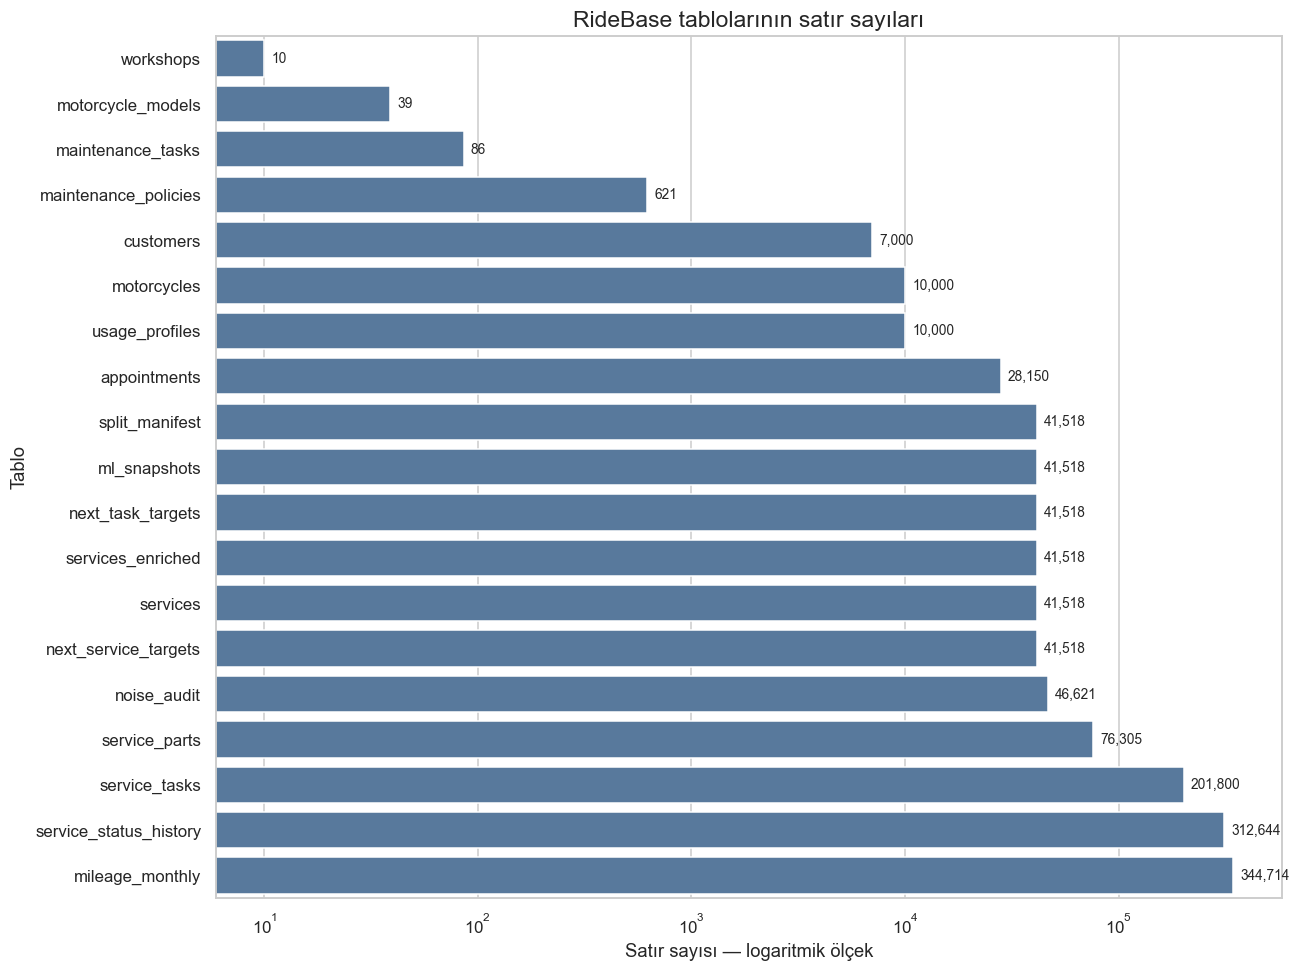

In [9]:
inventory_plot = inventory.sort_values("rows", ascending=True)

fig, ax = plt.subplots(figsize=(12, 9))

sns.barplot(
    data=inventory_plot,
    x="rows",
    y="dataset",
    color="#4C78A8",
    ax=ax
)

ax.set_xscale("log")
ax.set_title("RideBase tablolarının satır sayıları")
ax.set_xlabel("Satır sayısı — logaritmik ölçek")
ax.set_ylabel("Tablo")

for index, row in inventory_plot.reset_index(drop=True).iterrows():
    ax.text(
        row["rows"] * 1.08,
        index,
        f'{row["rows"]:,}',
        va="center",
        fontsize=9
    )

finish_plot(fig, "01_table_row_counts.png")

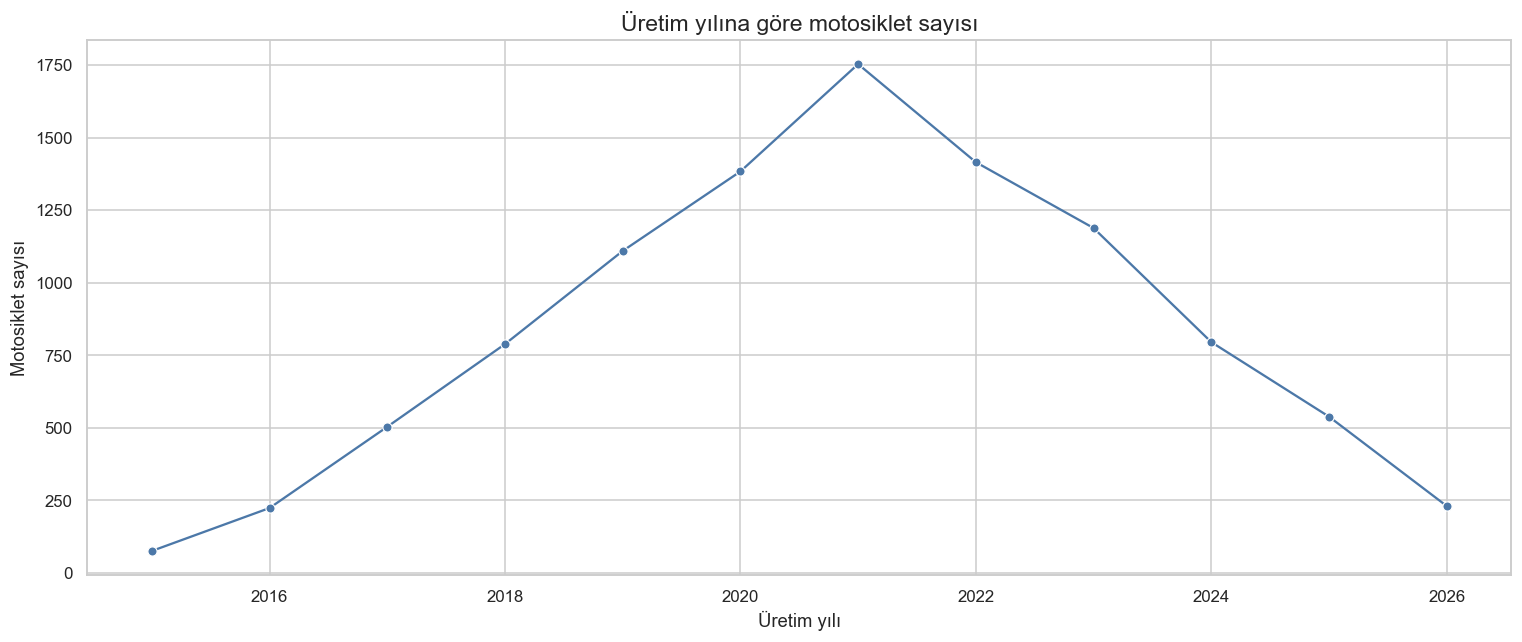

In [10]:
production_year_counts = (
    df_motorcycles["production_year"]
    .value_counts()
    .sort_index()
    .rename_axis("production_year")
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(14, 6))

sns.lineplot(
    data=production_year_counts,
    x="production_year",
    y="count",
    marker="o",
    color="#4C78A8",
    ax=ax
)

ax.set_title("Üretim yılına göre motosiklet sayısı")
ax.set_xlabel("Üretim yılı")
ax.set_ylabel("Motosiklet sayısı")

finish_plot(fig, "03_motorcycle_production_year.png")

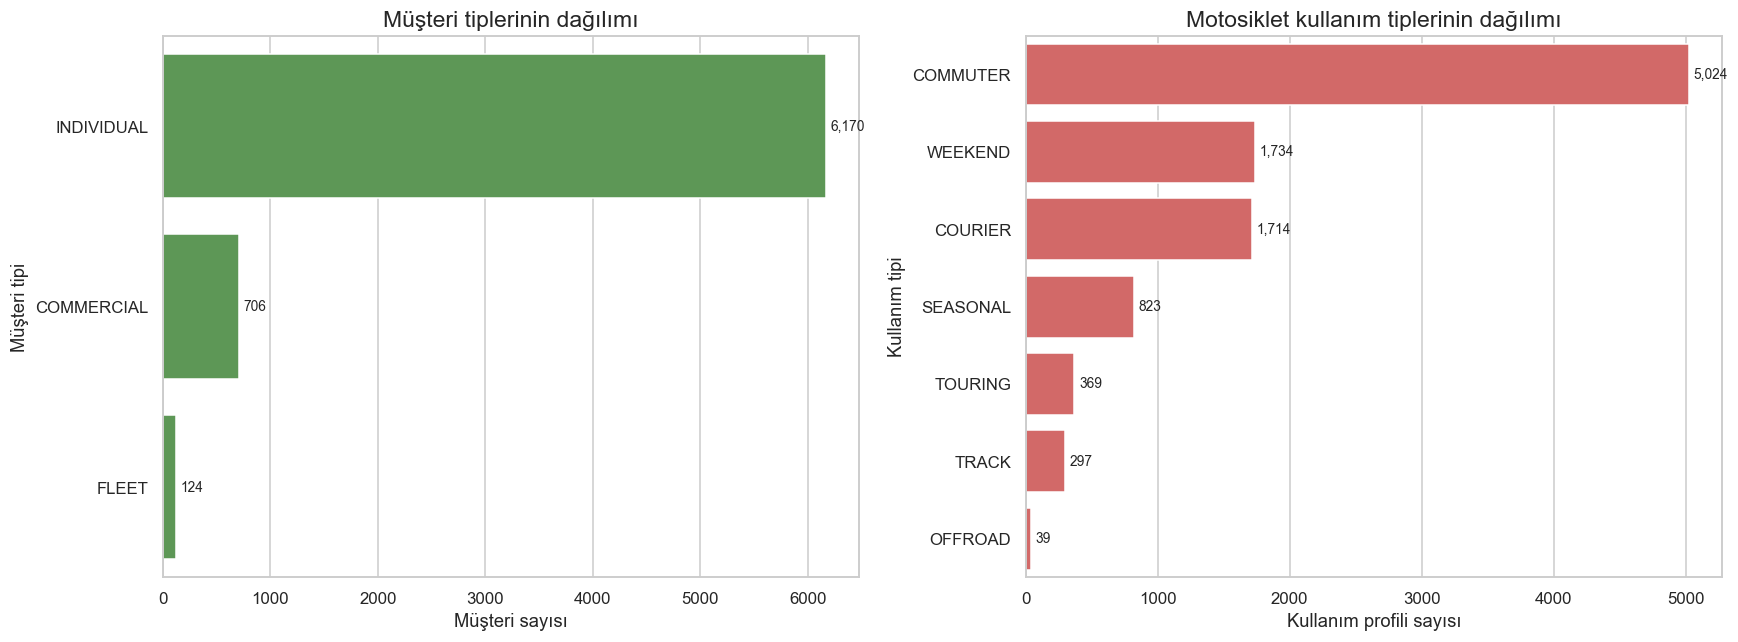

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

customer_type_counts = (
    df_customers["customer_type"]
    .value_counts()
    .reset_index()
)
customer_type_counts.columns = ["customer_type", "count"]

usage_type_counts = (
    df_usage_profiles["usage_type"]
    .value_counts()
    .reset_index()
)
usage_type_counts.columns = ["usage_type", "count"]

sns.barplot(
    data=customer_type_counts,
    x="count",
    y="customer_type",
    color="#54A24B",
    ax=axes[0]
)
axes[0].set_title("Müşteri tiplerinin dağılımı")
axes[0].set_xlabel("Müşteri sayısı")
axes[0].set_ylabel("Müşteri tipi")
add_bar_labels(axes[0])

sns.barplot(
    data=usage_type_counts,
    x="count",
    y="usage_type",
    color="#E45756",
    ax=axes[1]
)
axes[1].set_title("Motosiklet kullanım tiplerinin dağılımı")
axes[1].set_xlabel("Kullanım profili sayısı")
axes[1].set_ylabel("Kullanım tipi")
add_bar_labels(axes[1])

finish_plot(fig, "04_customer_and_usage_types.png")

### Müşteri ve kullanım tipleri ne anlama geliyor?

#### Müşteri tipleri

- **INDIVIDUAL — Bireysel müşteri:** Motosikletini kişisel ulaşım, günlük kullanım veya hobi amacıyla kullanan kişidir. Veri setinde **6.170 müşteri (%88,1)** bu gruptadır.
- **COMMERCIAL — Ticari müşteri:** Motosikleti kurye, teslimat, saha hizmeti veya küçük işletme faaliyeti gibi gelir getirici bir işte kullanan müşteridir. Genellikle filo büyüklüğünde olmayan ticari kullanımı temsil eder. Veri setinde **706 müşteri (%10,1)** bu gruptadır.
- **FLEET — Filo müşterisi:** Birden fazla motosikleti kuruluş veya işletme adına yöneten müşteridir. Bakım kararları tek araç yerine filonun tamamı düşünülerek verilebilir. Veri setinde **124 müşteri (%1,8)** bu gruptadır.

#### Kullanım tipleri

- **COMMUTER — Günlük ulaşım:** Ev–iş veya okul gibi düzenli günlük ulaşım kullanımı.
- **WEEKEND — Hafta sonu kullanımı:** Motosikletin çoğunlukla hafta sonu, gezi veya hobi amacıyla kullanılması.
- **COURIER — Kurye kullanımı:** Teslimat işi nedeniyle sık, yoğun ve yüksek kilometreli ticari kullanım.
- **SEASONAL — Mevsimsel kullanım:** Motosikletin yılın yalnızca belirli dönemlerinde, çoğunlukla uygun hava koşullarında kullanılması.
- **TOURING — Uzun yol kullanımı:** Şehirler arası veya uzun mesafeli gezi ağırlıklı kullanım.
- **TRACK — Pist kullanımı:** Motosikletin kontrollü pist ortamında yüksek performanslı kullanımı.
- **OFFROAD — Arazi kullanımı:** Asfalt dışı, toprak veya zorlu zeminlerde kullanım.

#### Grafik ne anlatıyor?

Müşterilerin büyük çoğunluğu bireyseldir. Kullanım profillerinde ise günlük ulaşım öne çıkar. Ticari, filo, pist ve arazi gruplarında daha az örnek bulunduğundan, ileride kurulacak modellerin başarısı bu küçük gruplar için ayrıca ölçülmelidir.

> **Önemli ayrım:** `COMMERCIAL` müşteri türünü, `COURIER` ise motosikletin kullanım biçimini anlatır. Aynı kavram değildir.

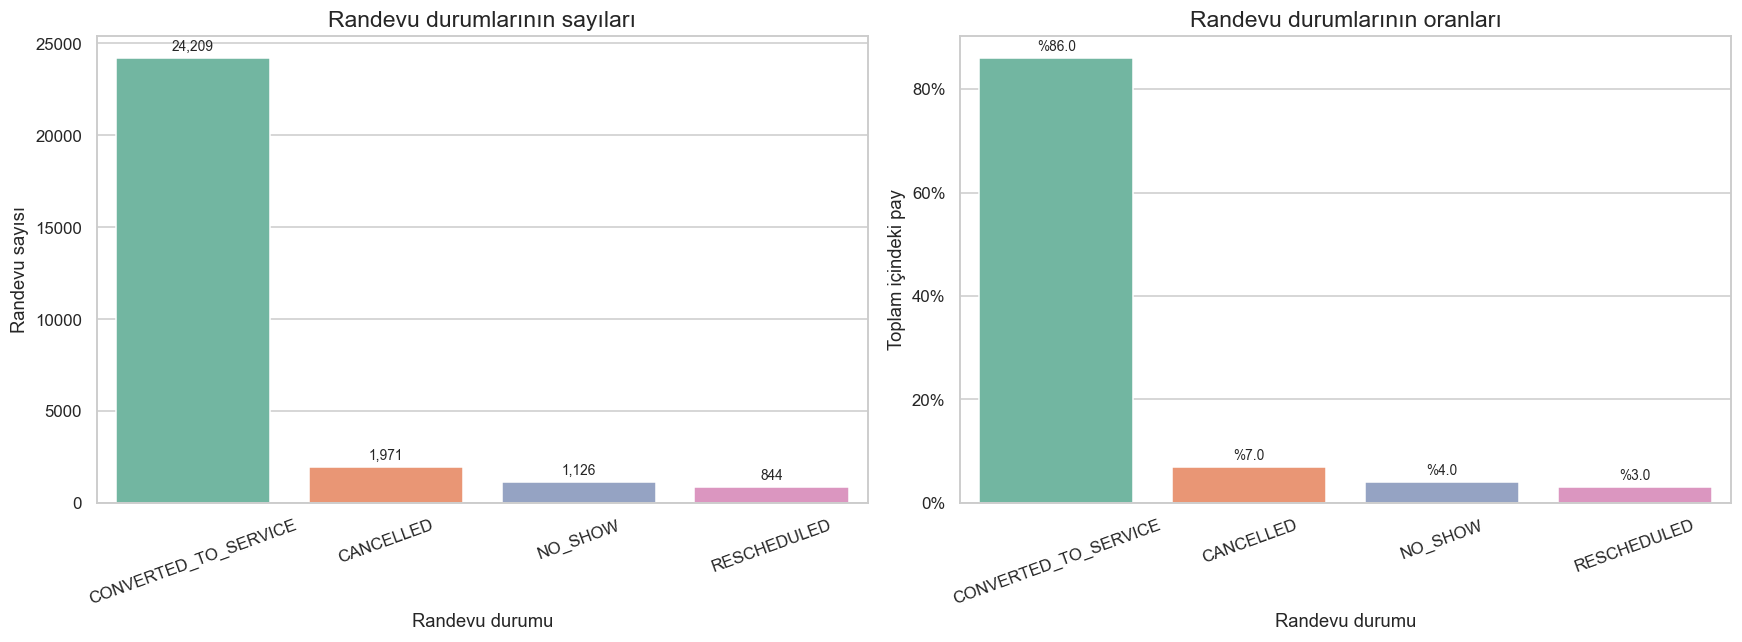

,status,count,ratio
0,CONVERTED_TO_SERVICE,24209,0.860000
1,CANCELLED,1971,0.070018
2,NO_SHOW,1126,0.040000
3,RESCHEDULED,844,0.029982


In [12]:
appointment_status = (
    df_appointments["status"]
    .value_counts()
    .rename_axis("status")
    .reset_index(name="count")
)

appointment_status["ratio"] = (
    appointment_status["count"] /
    appointment_status["count"].sum()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=appointment_status,
    x="status",
    y="count",
    hue="status",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Randevu durumlarının sayıları")
axes[0].set_xlabel("Randevu durumu")
axes[0].set_ylabel("Randevu sayısı")
axes[0].tick_params(axis="x", rotation=20)
add_bar_labels(axes[0])

sns.barplot(
    data=appointment_status,
    x="status",
    y="ratio",
    hue="status",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Randevu durumlarının oranları")
axes[1].set_xlabel("Randevu durumu")
axes[1].set_ylabel("Toplam içindeki pay")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1].tick_params(axis="x", rotation=20)
add_bar_labels(axes[1], percent=True)

finish_plot(fig, "05_appointment_status.png")

display(appointment_status)

### Randevu durumları ne anlama geliyor?

- **CONVERTED_TO_SERVICE — Servise dönüşen randevu:** Müşteri randevuya gelmiş ve randevu gerçek bir servis kaydına dönüşmüştür. Bu kayıtlarda `service_id` dolu olmalıdır. **24.209 randevu (%86)** bu gruptadır.
- **CANCELLED — İptal edilen randevu:** Randevu müşteri veya servis tarafından iptal edilmiştir. Servis gerçekleşmediği için `service_id` boş olmalıdır. **1.971 randevu (%7)** bu gruptadır.
- **NO_SHOW — Müşterinin gelmediği randevu:** Randevu iptal edilmemiş, ancak müşteri planlanan zamanda servise gelmemiştir. Servis oluşmadığı için `service_id` boş olmalıdır. **1.126 randevu (%4)** bu gruptadır.
- **RESCHEDULED — Başka tarihe alınan randevu:** İlk randevunun günü veya saati değiştirilmiştir. Bu satır eski planı temsil ettiği için doğrudan servis kaydına bağlanmaz ve `service_id` boş olabilir. **844 randevu (%3)** bu gruptadır.

#### Grafik ne anlatıyor?

Yaklaşık her 100 randevunun 86'sı servise dönüşüyor, 7'si iptal ediliyor, 4'ünde müşteri gelmiyor ve 3'ü başka tarihe alınıyor. İptal ve gelmeme oranları kapasite planlamasında önemlidir; servis istasyonu ve teknisyen zamanı ayrıldığı halde kullanılamayabilir.

#### Alttaki tablo nasıl okunur?

- `status`: Randevunun son durumu.
- `count`: Bu durumda bulunan randevu sayısı.
- `ratio`: Toplam randevular içindeki oran. Örneğin `0.86`, `%86` demektir.

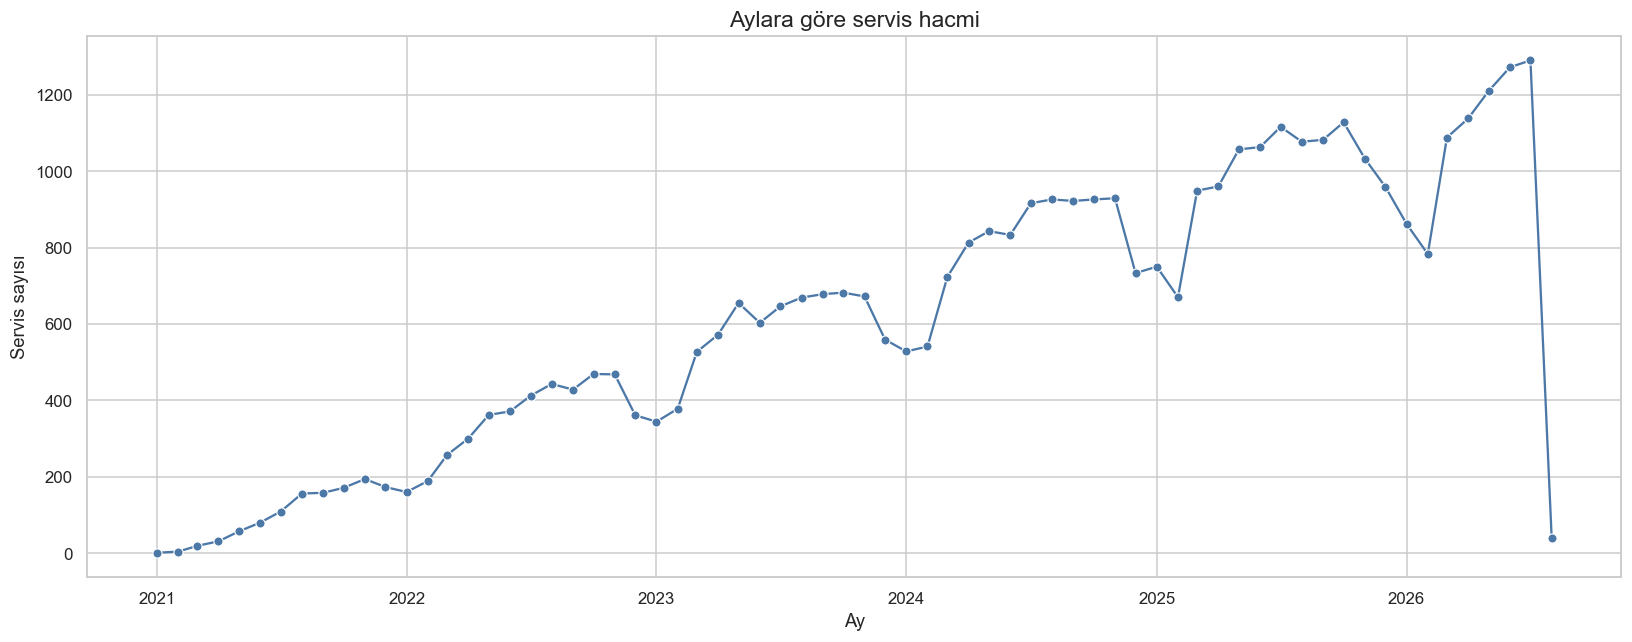

In [13]:
services_eda = df_services_enriched.copy()

services_eda["received_at"] = pd.to_datetime(
    services_eda["received_at"],
    errors="coerce"
)

monthly_services = (
    services_eda
    .dropna(subset=["received_at"])
    .set_index("received_at")
    .resample("MS")
    .size()
    .rename("service_count")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(15, 6))

sns.lineplot(
    data=monthly_services,
    x="received_at",
    y="service_count",
    marker="o",
    color="#4C78A8",
    ax=ax
)

ax.set_title("Aylara göre servis hacmi")
ax.set_xlabel("Ay")
ax.set_ylabel("Servis sayısı")

finish_plot(fig, "06_monthly_service_volume.png")

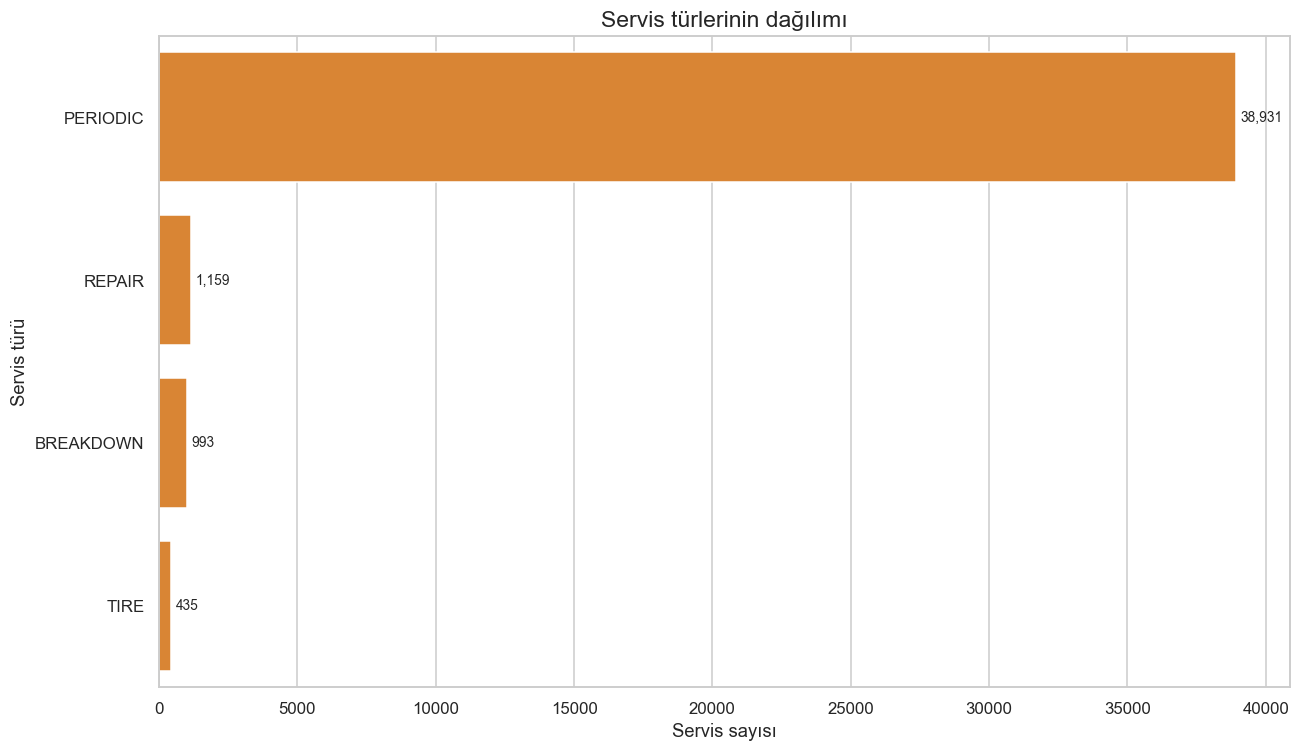

In [14]:
service_type_counts = (
    services_eda["service_type_code"]
    .value_counts()
    .reset_index()
)
service_type_counts.columns = ["service_type_code", "count"]

fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(
    data=service_type_counts,
    x="count",
    y="service_type_code",
    color="#F58518",
    ax=ax
)

ax.set_title("Servis türlerinin dağılımı")
ax.set_xlabel("Servis sayısı")
ax.set_ylabel("Servis türü")
add_bar_labels(ax)

finish_plot(fig, "07_service_types.png")

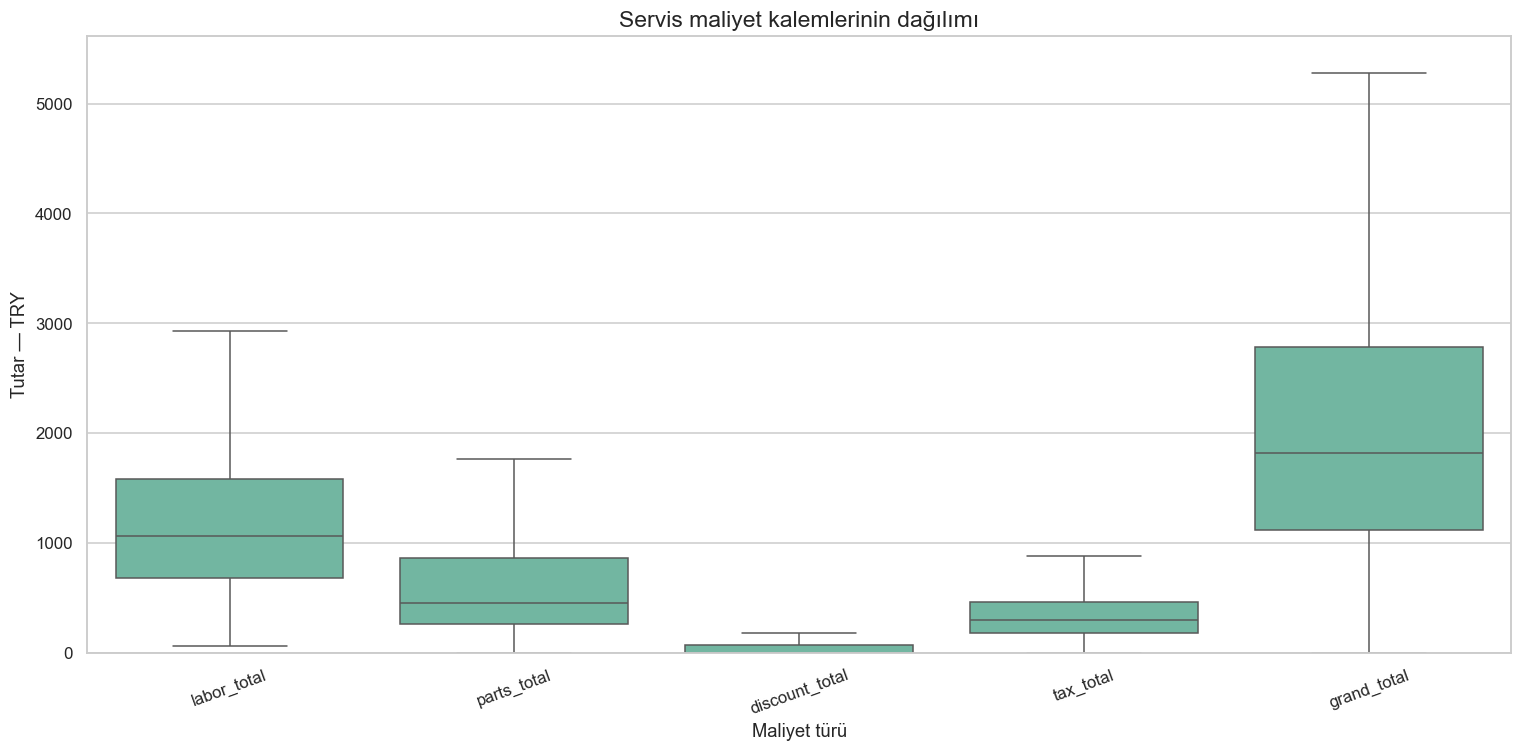

In [15]:
cost_columns = [
    "labor_total",
    "parts_total",
    "discount_total",
    "tax_total",
    "grand_total"
]

cost_long = services_eda[cost_columns].melt(
    var_name="cost_type",
    value_name="amount"
)

# Çok yüksek uç değerlerin grafiği sıkıştırmasını önlemek için
# yalnızca görünümde yüzde 99 sınırı uygulanır.
upper_limit = cost_long["amount"].quantile(0.99)

fig, ax = plt.subplots(figsize=(14, 7))

sns.boxplot(
    data=cost_long,
    x="cost_type",
    y="amount",
    showfliers=False,
    ax=ax
)

ax.set_ylim(0, upper_limit)
ax.set_title("Servis maliyet kalemlerinin dağılımı")
ax.set_xlabel("Maliyet türü")
ax.set_ylabel("Tutar — TRY")
ax.tick_params(axis="x", rotation=20)

finish_plot(fig, "08_service_cost_distributions.png")

### Servis maliyet kalemleri ne anlama geliyor?

Bu grafik, maliyet alanları doldurulmuş analiz-hazır `services_enriched.csv` tablosunu kullanır. Para birimi Türk lirasıdır (`TRY`).

- **labor_total — Toplam işçilik:** Servis görevlerinin teknisyen süresi ve servis noktasının işçilik fiyat seviyesine göre hesaplanan toplam işçilik bedeli.
- **parts_total — Toplam parça:** Serviste kullanılan bütün parçaların müşteriye satış fiyatlarının toplamı. Parça kullanılmayan serviste `0` olabilir.
- **discount_total — Toplam indirim:** İşçilik ve parça ara toplamından düşülen indirim miktarı. İndirim yoksa `0` olabilir.
- **tax_total — Toplam vergi:** İndirim sonrasında hesaplanan vergi tutarı.
- **grand_total — Genel toplam:** Müşterinin servis sonunda ödemesi beklenen nihai tutar.

Yaklaşık hesaplama ilişkisi:

`grand_total = labor_total + parts_total - discount_total + tax_total`

#### Kutu grafiği nasıl okunur?

- Kutunun içindeki yatay çizgi **medyanı**, yani ortanca servisi gösterir.
- Kutunun alt ve üst kenarı gözlemlerin ortadaki `%50` bölümünü gösterir.
- Dış çizgiler tipik düşük ve yüksek değerlere uzanır.
- Kutu ve çizgiler uzadıkça maliyetlerin servisler arasında değişkenliği artar.

#### Grafik ne anlatıyor?

`grand_total` bütün maliyet kalemlerini birleştirdiği için en yüksek dağılıma sahiptir. İşçilik çoğu serviste önemli bir maliyet kalemidir. Parça maliyetinin geniş aralığı, bazı servislerde parça kullanılmaması; bazılarında ise pahalı parçaların değiştirilmesiyle açıklanabilir. İndirim tutarları genellikle diğer kalemlerden düşüktür.

> Çok yüksek uç değerler grafiği sıkıştırmasın diye yalnızca görsel eksen `%99` sınırında tutulmuştur. Veri satırları silinmemiş veya değiştirilmemiştir.

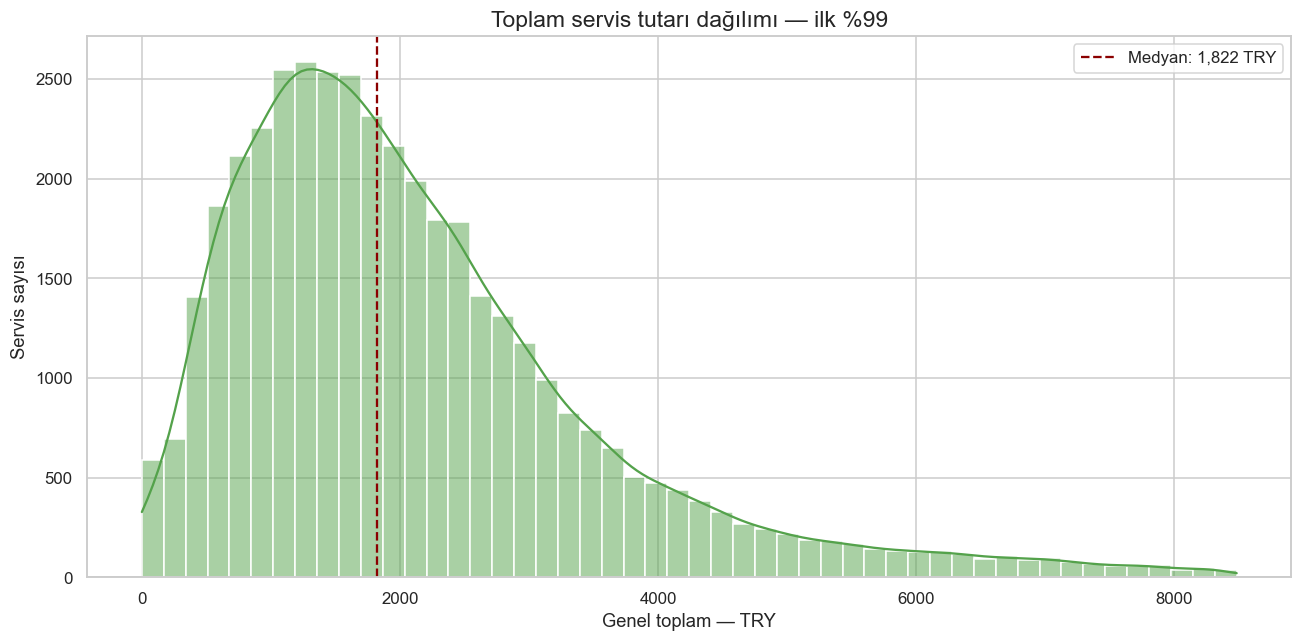

In [16]:
grand_total_limit = services_eda["grand_total"].quantile(0.99)

fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(
    data=services_eda[
        services_eda["grand_total"] <= grand_total_limit
    ],
    x="grand_total",
    bins=50,
    kde=True,
    color="#54A24B",
    ax=ax
)

median_total = services_eda["grand_total"].median()

ax.axvline(
    median_total,
    color="darkred",
    linestyle="--",
    label=f"Medyan: {median_total:,.0f} TRY"
)

ax.set_title("Toplam servis tutarı dağılımı — ilk %99")
ax.set_xlabel("Genel toplam — TRY")
ax.set_ylabel("Servis sayısı")
ax.legend()

finish_plot(fig, "09_grand_total_distribution.png")

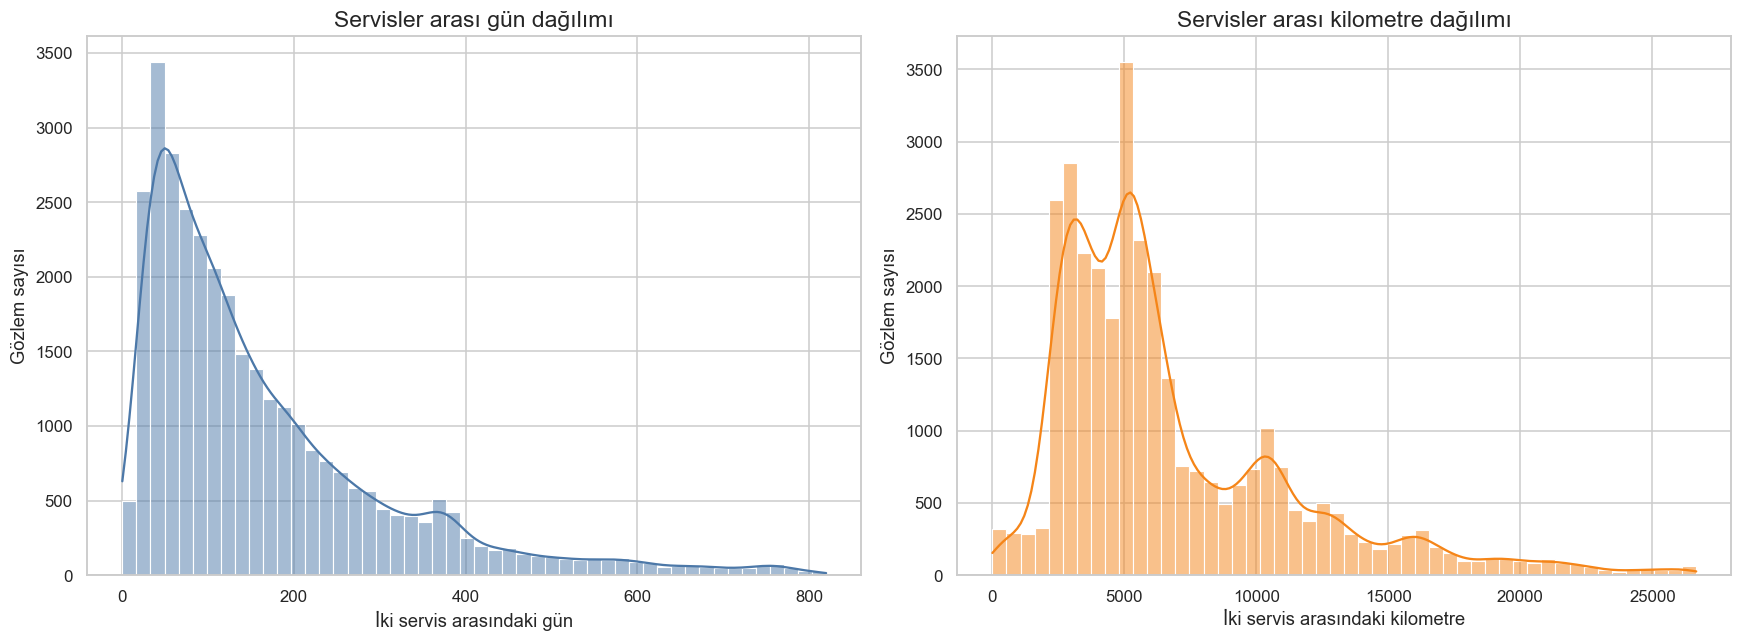

In [17]:
snapshot_intervals = (
    df_ml_snapshots[
        [
            "snapshot_id",
            "motorcycle_id",
            "snapshot_at",
            "snapshot_odometer_km"
        ]
    ]
    .copy()
)

snapshot_intervals["snapshot_at"] = pd.to_datetime(
    snapshot_intervals["snapshot_at"],
    errors="coerce"
)

snapshot_intervals = snapshot_intervals.sort_values(
    ["motorcycle_id", "snapshot_at"]
)

snapshot_intervals["interval_days"] = (
    snapshot_intervals
    .groupby("motorcycle_id")["snapshot_at"]
    .diff()
    .dt.total_seconds()
    .div(86_400)
)

snapshot_intervals["interval_km"] = (
    snapshot_intervals
    .groupby("motorcycle_id")["snapshot_odometer_km"]
    .diff()
)

valid_days = snapshot_intervals.loc[
    snapshot_intervals["interval_days"].gt(0),
    "interval_days"
]

valid_km = snapshot_intervals.loc[
    snapshot_intervals["interval_km"].gt(0),
    "interval_km"
]

day_limit = valid_days.quantile(0.99)
km_limit = valid_km.quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(
    valid_days[valid_days <= day_limit],
    bins=50,
    kde=True,
    color="#4C78A8",
    ax=axes[0]
)
axes[0].set_title("Servisler arası gün dağılımı")
axes[0].set_xlabel("İki servis arasındaki gün")
axes[0].set_ylabel("Gözlem sayısı")

sns.histplot(
    valid_km[valid_km <= km_limit],
    bins=50,
    kde=True,
    color="#F58518",
    ax=axes[1]
)
axes[1].set_title("Servisler arası kilometre dağılımı")
axes[1].set_xlabel("İki servis arasındaki kilometre")
axes[1].set_ylabel("Gözlem sayısı")

finish_plot(fig, "10_service_intervals.png")

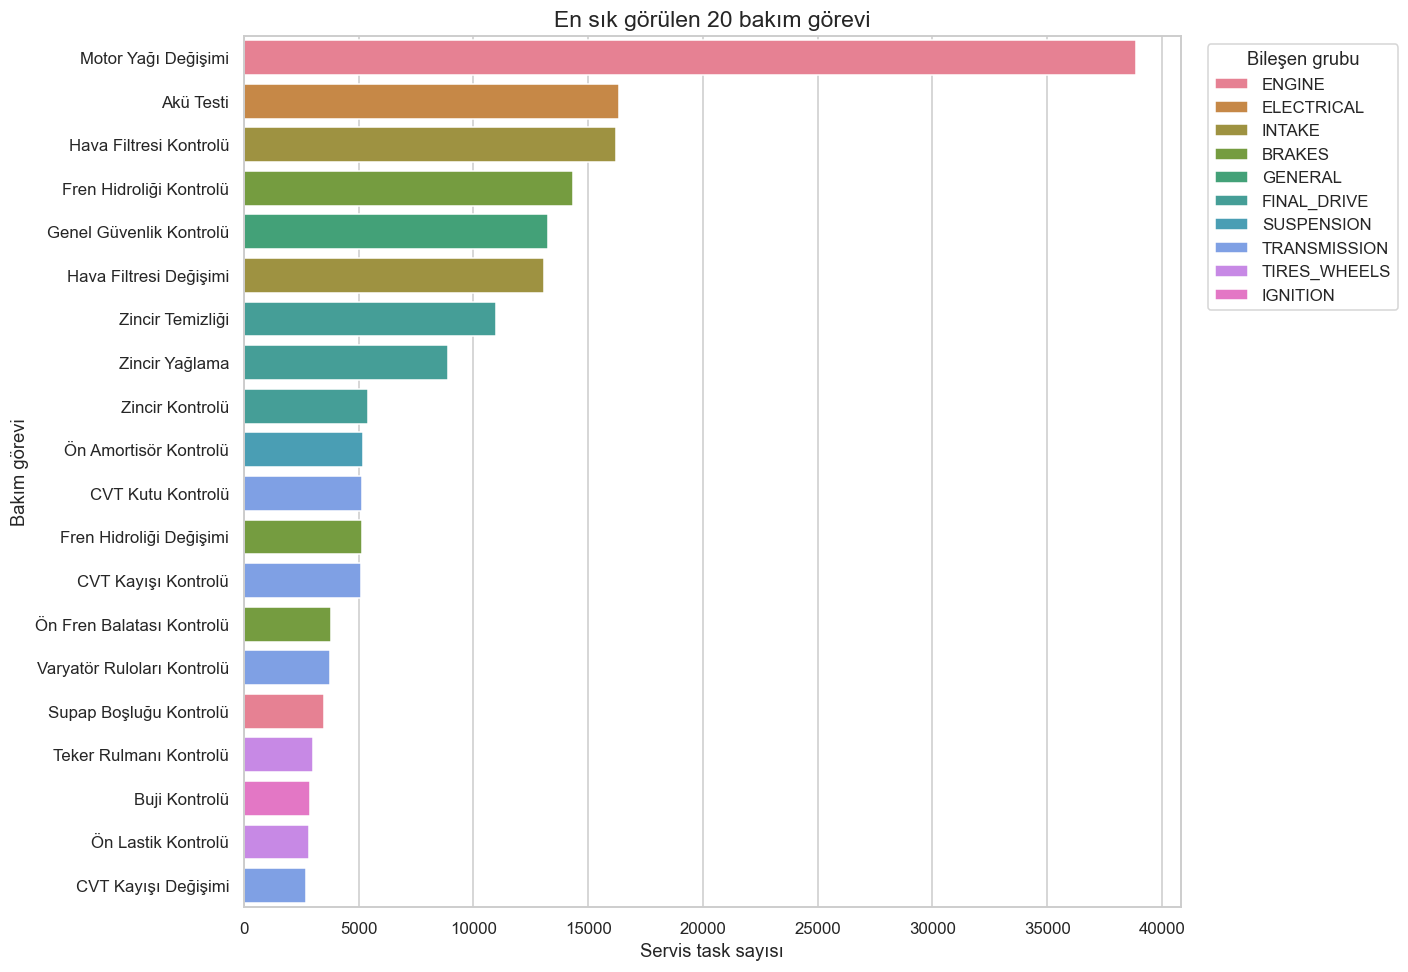

,task_code,count,canonical_name_tr,component_group
28,ENGINE_OIL_CHANGE,38882,Motor Yağı Değişimi,ENGINE
5,BATTERY_TEST,16335,Akü Testi,ELECTRICAL
3,AIR_FILTER_INSPECTION,16224,Hava Filtresi Kontrolü,INTAKE
9,BRAKE_FLUID_CHECK,14329,Fren Hidroliği Kontrolü,BRAKES
43,GENERAL_SAFETY_INSPECTION,13246,Genel Güvenlik Kontrolü,GENERAL
1,AIR_FILTER_CHANGE,13091,Hava Filtresi Değişimi,INTAKE
11,CHAIN_CLEAN,10988,Zincir Temizliği,FINAL_DRIVE
13,CHAIN_LUBRICATE,8888,Zincir Yağlama,FINAL_DRIVE
12,CHAIN_INSPECTION,5421,Zincir Kontrolü,FINAL_DRIVE
34,FORK_INSPECTION,5195,Ön Amortisör Kontrolü,SUSPENSION


In [18]:
task_frequency = (
    df_service_tasks
    .groupby("task_code")
    .size()
    .rename("count")
    .reset_index()
    .merge(
        df_maintenance_tasks[
            ["task_code", "canonical_name_tr", "component_group"]
        ],
        on="task_code",
        how="left"
    )
    .sort_values("count", ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(13, 9))

sns.barplot(
    data=task_frequency,
    x="count",
    y="canonical_name_tr",
    hue="component_group",
    dodge=False,
    ax=ax
)

ax.set_title("En sık görülen 20 bakım görevi")
ax.set_xlabel("Servis task sayısı")
ax.set_ylabel("Bakım görevi")
ax.legend(
    title="Bileşen grubu",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

finish_plot(fig, "11_top_maintenance_tasks.png")

display(task_frequency)

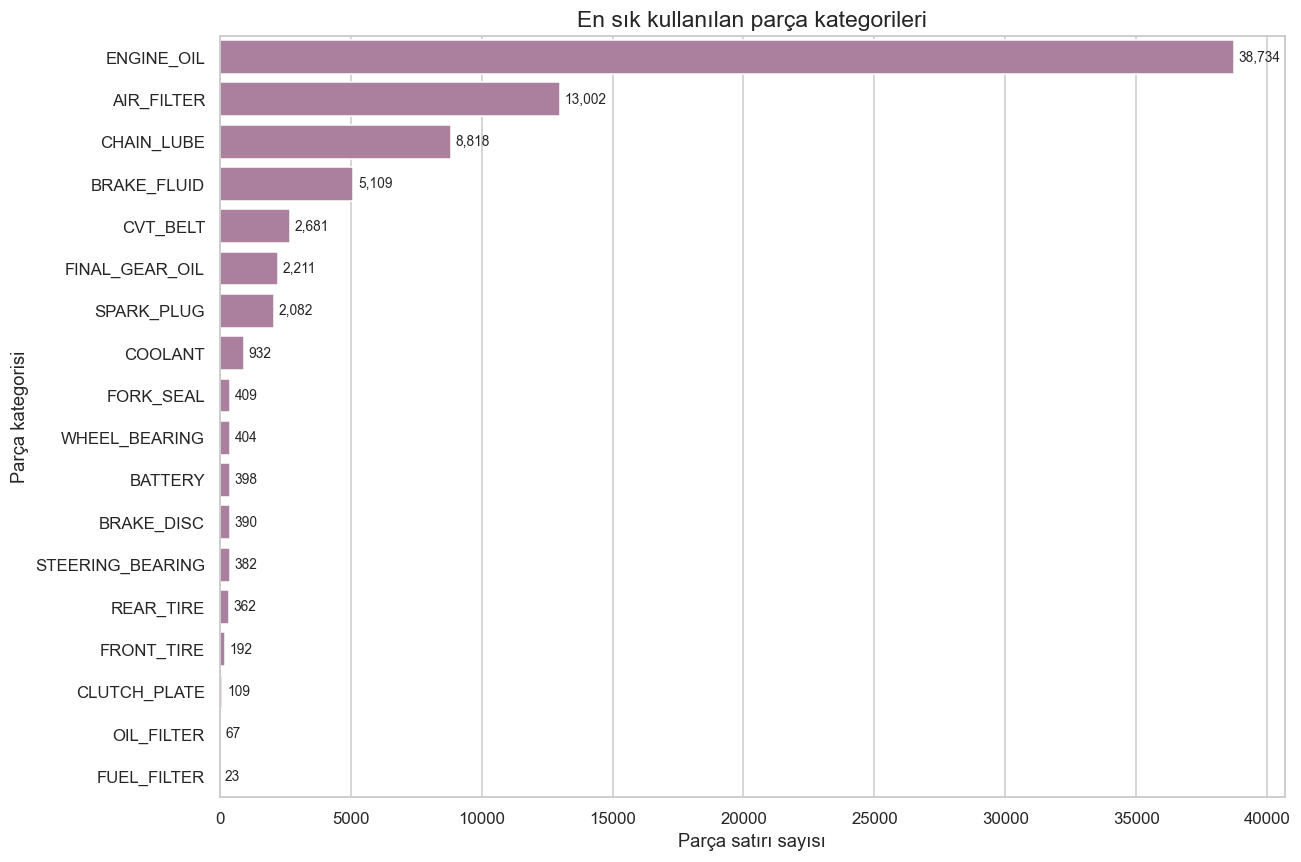

In [19]:
part_category_counts = (
    df_service_parts["part_category"]
    .value_counts()
    .head(20)
    .rename_axis("part_category")
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(12, 8))

sns.barplot(
    data=part_category_counts,
    x="count",
    y="part_category",
    color="#B279A2",
    ax=ax
)

ax.set_title("En sık kullanılan parça kategorileri")
ax.set_xlabel("Parça satırı sayısı")
ax.set_ylabel("Parça kategorisi")
add_bar_labels(ax)

finish_plot(fig, "12_part_categories.png")

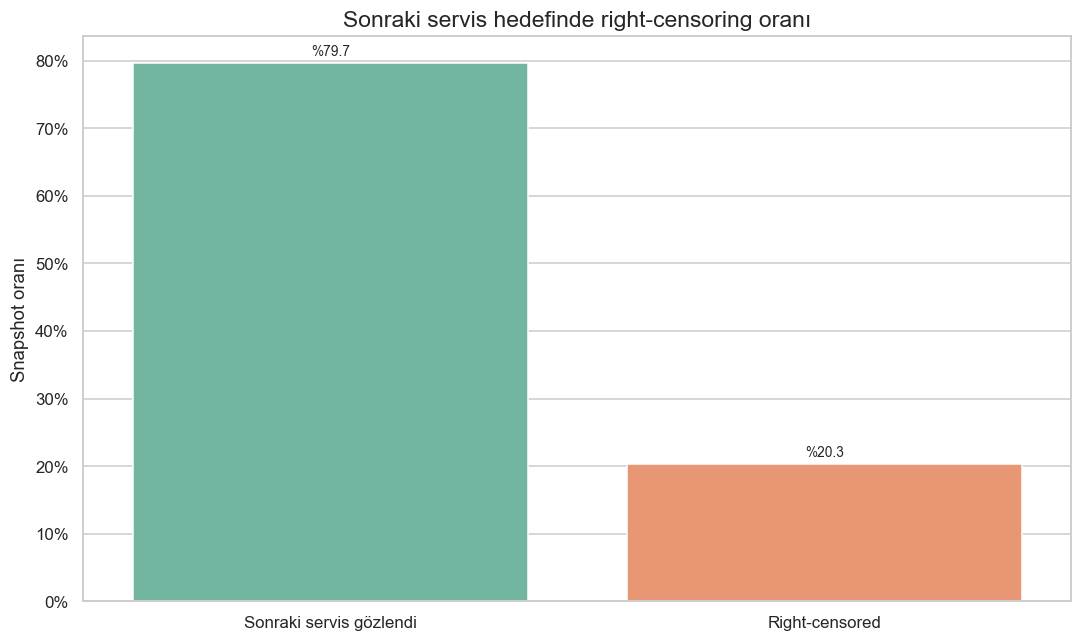

,censor_status,count,ratio
0,Sonraki servis gözlendi,33076,0.796667
1,Right-censored,8442,0.203333


In [20]:
censor_counts = (
    df_next_service_targets["is_right_censored"]
    .map({
        0: "Sonraki servis gözlendi",
        1: "Right-censored"
    })
    .value_counts()
    .rename_axis("censor_status")
    .reset_index(name="count")
)

censor_counts["ratio"] = (
    censor_counts["count"] /
    censor_counts["count"].sum()
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=censor_counts,
    x="censor_status",
    y="ratio",
    hue="censor_status",
    legend=False,
    ax=ax
)

ax.set_title("Sonraki servis hedefinde right-censoring oranı")
ax.set_xlabel("")
ax.set_ylabel("Snapshot oranı")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
add_bar_labels(ax, percent=True)

finish_plot(fig, "13_right_censoring.png")

display(censor_counts)

### Right-censored ne demektir?

**Right-censored (sağdan sansürlü)**, datasetin gözlem süresi sona erdiğinde motosikletin bir sonraki servisinin henüz gözlenmemiş olmasıdır.

Bu durum motosikletin bir daha servise gelmeyeceği anlamına gelmez. Sonraki servis, datasetin kapsadığı tarihten sonra gerçekleşmiş olabilir; dolayısıyla sonucu henüz bilmiyoruz.

- **Sonraki servis gözlendi:** Snapshot'tan sonra motosiklet yeniden servise gelmiştir. Servise kalan gün, kilometre ve bakım görevleri hesaplanabilir. **33.076 snapshot (%79,7)** bu gruptadır.
- **Right-censored:** Dataset sona erdiğinde sonraki servis görülmemiştir. Servisin ne zaman gerçekleşeceği ve hangi görevleri içereceği bilinmez. **8.442 snapshot (%20,3)** bu gruptadır.

Right-censored satırlarda:

- `target_event_observed = 0`
- `is_right_censored = 1`
- `next_service_id = NULL`
- `days_to_next_service = NULL`
- `km_to_next_service = NULL`
- `task__... = NULL`

Bu alanlar `0` ile doldurulmaz. `0`, olayın gözlendiği ve değerin gerçekten sıfır olduğu anlamına gelebilir; `NULL` ise sonucun bilinmediğini ifade eder.

> **Kısaca:** Right-censored, “sonraki servis yok” değil; “sonraki servisi gözlem süresi içinde henüz göremedik” demektir.

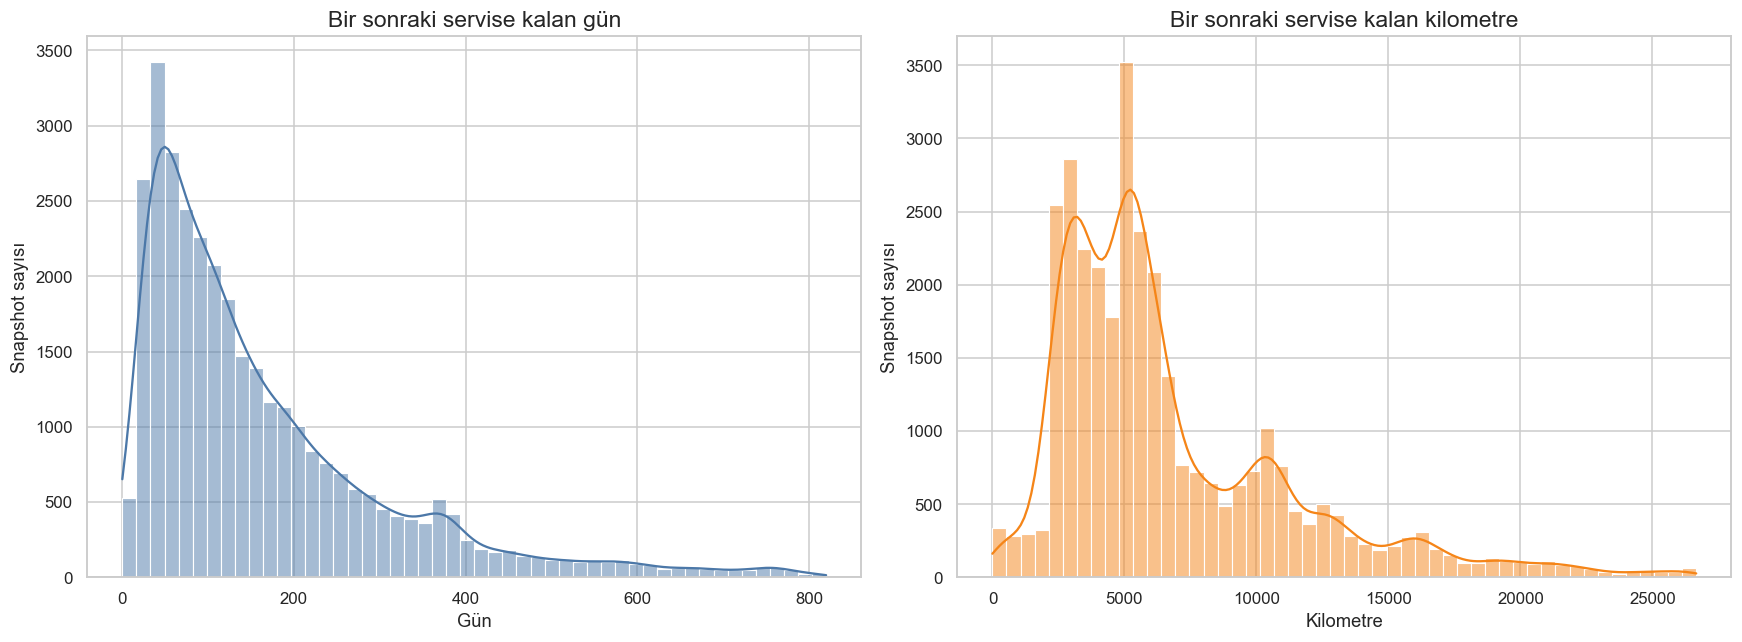

In [21]:
observed_targets = df_next_service_targets.loc[
    df_next_service_targets["target_event_observed"].eq(1)
].copy()

day_limit = observed_targets["days_to_next_service"].quantile(0.99)
km_limit = observed_targets["km_to_next_service"].quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(
    data=observed_targets[
        observed_targets["days_to_next_service"] <= day_limit
    ],
    x="days_to_next_service",
    bins=50,
    kde=True,
    color="#4C78A8",
    ax=axes[0]
)
axes[0].set_title("Bir sonraki servise kalan gün")
axes[0].set_xlabel("Gün")
axes[0].set_ylabel("Snapshot sayısı")

valid_km_targets = observed_targets[
    observed_targets["km_to_next_service"].notna() &
    observed_targets["km_to_next_service"].le(km_limit)
]

sns.histplot(
    data=valid_km_targets,
    x="km_to_next_service",
    bins=50,
    kde=True,
    color="#F58518",
    ax=axes[1]
)
axes[1].set_title("Bir sonraki servise kalan kilometre")
axes[1].set_xlabel("Kilometre")
axes[1].set_ylabel("Snapshot sayısı")

finish_plot(fig, "14_next_service_targets.png")

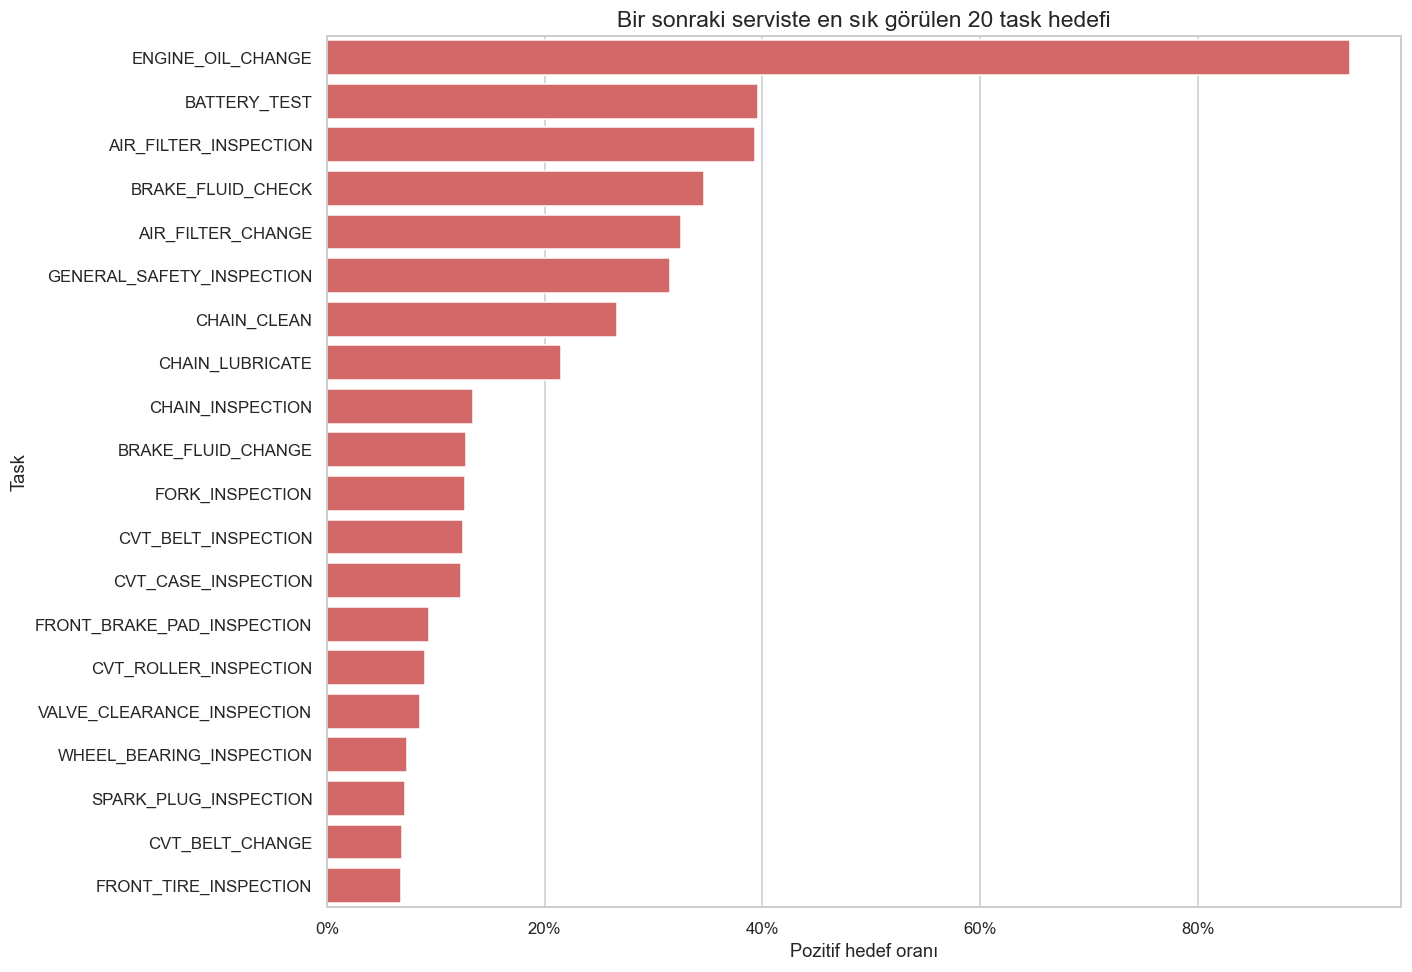

,task,positive_rate
0,ENGINE_OIL_CHANGE,0.940229
1,BATTERY_TEST,0.396239
2,AIR_FILTER_INSPECTION,0.393518
3,BRAKE_FLUID_CHECK,0.346807
4,AIR_FILTER_CHANGE,0.324858
5,GENERAL_SAFETY_INSPECTION,0.31476
6,CHAIN_CLEAN,0.266628
7,CHAIN_LUBRICATE,0.214899
8,CHAIN_INSPECTION,0.133904
9,BRAKE_FLUID_CHANGE,0.127706


In [22]:
task_target_columns = [
    column
    for column in df_next_task_targets.columns
    if column.startswith("task__")
]

observed_task_targets = df_next_task_targets.loc[
    df_next_task_targets["target_event_observed"].eq(1),
    task_target_columns
]

task_prevalence = (
    observed_task_targets
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .rename("positive_rate")
    .reset_index()
    .rename(columns={"index": "task"})
)

task_prevalence["task"] = (
    task_prevalence["task"]
    .str.replace("task__", "", regex=False)
)

fig, ax = plt.subplots(figsize=(13, 9))

sns.barplot(
    data=task_prevalence,
    x="positive_rate",
    y="task",
    color="#E45756",
    ax=ax
)

ax.set_title("Bir sonraki serviste en sık görülen 20 task hedefi")
ax.set_xlabel("Pozitif hedef oranı")
ax.set_ylabel("Task")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))

finish_plot(fig, "15_next_task_prevalence.png")

display(task_prevalence)

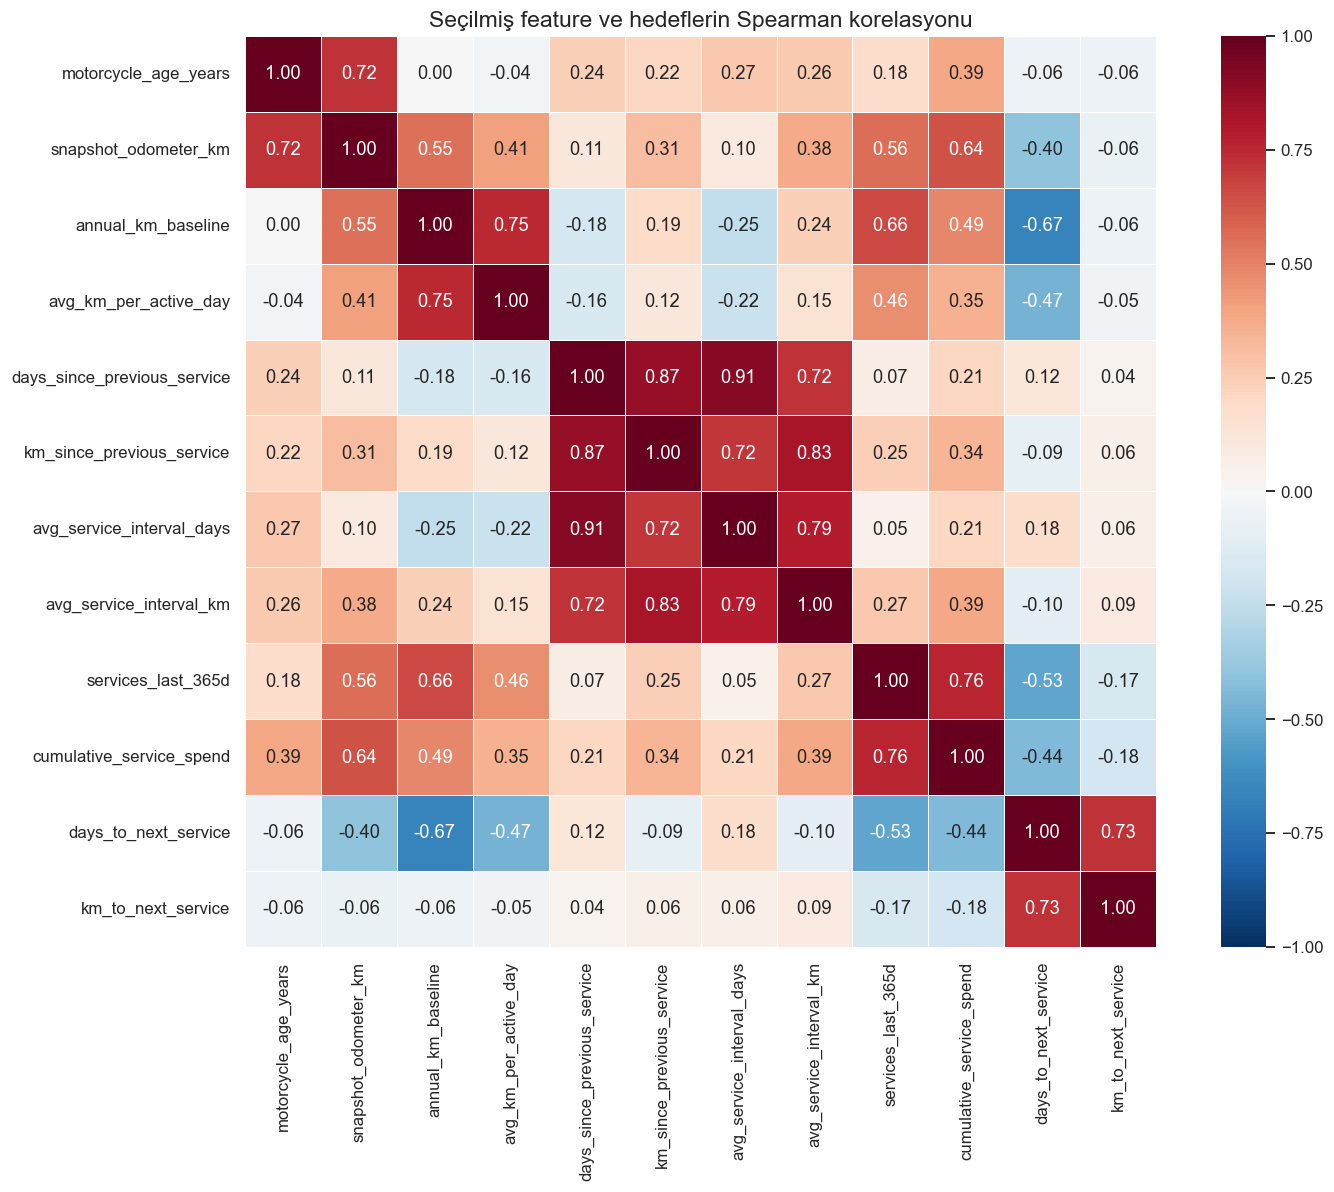

In [23]:
selected_features = [
    "motorcycle_age_years",
    "snapshot_odometer_km",
    "annual_km_baseline",
    "avg_km_per_active_day",
    "days_since_previous_service",
    "km_since_previous_service",
    "avg_service_interval_days",
    "avg_service_interval_km",
    "services_last_365d",
    "cumulative_service_spend"
]

correlation_data = (
    df_ml_snapshots[
        ["snapshot_id"] + selected_features
    ]
    .merge(
        df_next_service_targets[
            [
                "snapshot_id",
                "target_event_observed",
                "days_to_next_service",
                "km_to_next_service"
            ]
        ],
        on="snapshot_id",
        how="inner",
        validate="one_to_one"
    )
)

correlation_data = correlation_data[
    correlation_data["target_event_observed"].eq(1)
]

correlation_columns = (
    selected_features +
    ["days_to_next_service", "km_to_next_service"]
)

correlation_matrix = (
    correlation_data[correlation_columns]
    .corr(method="spearman")
)

fig, ax = plt.subplots(figsize=(14, 11))

sns.heatmap(
    correlation_matrix,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Seçilmiş feature ve hedeflerin Spearman korelasyonu")

finish_plot(fig, "16_feature_target_correlations.png")

# EDA Aşama 2 — İlişkisel ve Segment Bazlı Analiz

İlk bölümde tek değişkenli dağılımlar incelendi. Bu bölümde müşteri, kullanım tipi, motosiklet, workshop ve zaman özelliklerinin servis davranışı ve ML hedefleriyle ilişkisi araştırılır.

> Grafiklerdeki özetler ilişki gösterir; tek başına neden–sonuç kanıtlamaz.

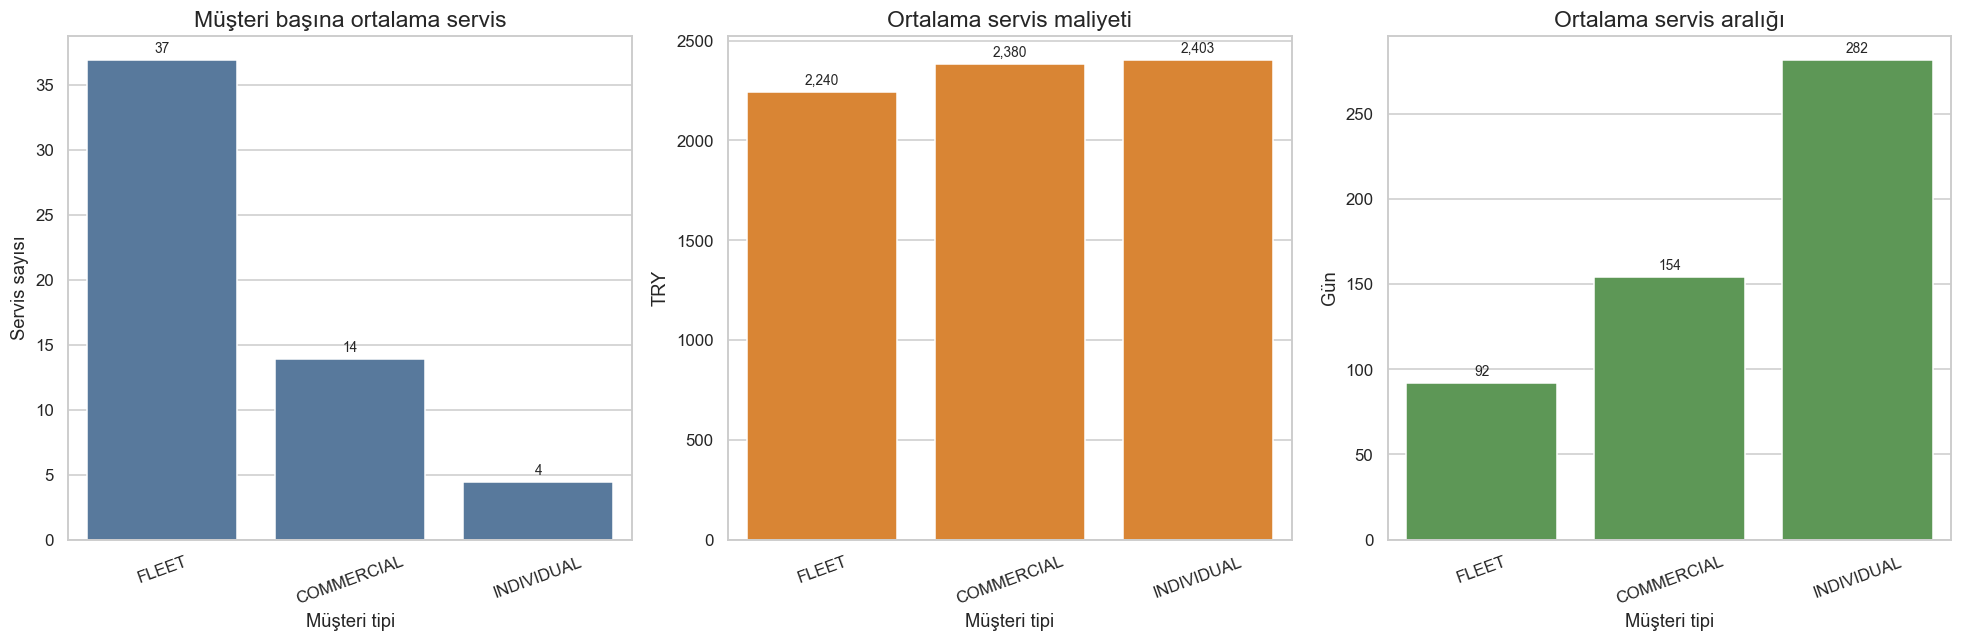

,customer_type,customer_count,avg_services_per_customer,median_services_per_customer,avg_service_cost,avg_interval_days,avg_interval_km
0,COMMERCIAL,706,13.88,10.0,2380.00,154.15,6859.01
1,FLEET,124,36.92,31.0,2239.76,91.71,5683.56
2,INDIVIDUAL,6170,4.40,3.0,2403.11,281.54,7885.90


In [24]:
# EDA AŞAMA 2 — İlişkisel ve segment bazlı analiz
from IPython.display import Markdown

# Müşteri başına servis ve harcama ölçüleri
customer_service_metrics = (
    services_eda.groupby("customer_id")
    .agg(
        service_count=("service_id", "nunique"),
        avg_service_cost=("grand_total", "mean"),
        total_service_spend=("grand_total", "sum"),
    )
    .reset_index()
)

customer_interval_metrics = (
    snapshot_intervals.loc[snapshot_intervals["interval_days"].gt(0)]
    .merge(df_motorcycles[["motorcycle_id", "customer_id"]], on="motorcycle_id", how="left")
    .groupby("customer_id")
    .agg(avg_interval_days=("interval_days", "mean"), avg_interval_km=("interval_km", "mean"))
    .reset_index()
)

customer_analysis = (
    df_customers[["customer_id", "customer_type"]]
    .merge(customer_service_metrics, on="customer_id", how="left")
    .merge(customer_interval_metrics, on="customer_id", how="left")
)
customer_analysis[["service_count", "total_service_spend"]] = (
    customer_analysis[["service_count", "total_service_spend"]].fillna(0)
)

customer_segment_summary = (
    customer_analysis.groupby("customer_type")
    .agg(
        customer_count=("customer_id", "nunique"),
        avg_services_per_customer=("service_count", "mean"),
        median_services_per_customer=("service_count", "median"),
        avg_service_cost=("avg_service_cost", "mean"),
        avg_interval_days=("avg_interval_days", "mean"),
        avg_interval_km=("avg_interval_km", "mean"),
    )
    .reset_index()
)

order = customer_segment_summary.sort_values("avg_services_per_customer", ascending=False)["customer_type"]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.barplot(data=customer_segment_summary, x="customer_type", y="avg_services_per_customer", order=order, ax=axes[0], color="#4C78A8")
sns.barplot(data=customer_segment_summary, x="customer_type", y="avg_service_cost", order=order, ax=axes[1], color="#F58518")
sns.barplot(data=customer_segment_summary, x="customer_type", y="avg_interval_days", order=order, ax=axes[2], color="#54A24B")
axes[0].set(title="Müşteri başına ortalama servis", xlabel="Müşteri tipi", ylabel="Servis sayısı")
axes[1].set(title="Ortalama servis maliyeti", xlabel="Müşteri tipi", ylabel="TRY")
axes[2].set(title="Ortalama servis aralığı", xlabel="Müşteri tipi", ylabel="Gün")
for ax in axes: ax.tick_params(axis="x", rotation=20); add_bar_labels(ax)
finish_plot(fig, "17_customer_segment_behavior.png")
display(customer_segment_summary.round(2))

INDIVIDUAL — Bireysel müşteri:
Motosikletini kişisel ulaşım, günlük kullanım veya hobi amacıyla kullanan kişi.

COMMERCIAL — Ticari müşteri:
Motosikletini gelir elde edilen bir işte kullanan müşteri. Örneğin kurye, teslimat çalışanı veya küçük işletme sahibi. Genellikle tek veya az sayıda motosikleti vardır.

FLEET — Filo müşterisi:
Bir işletme adına birden fazla motosikleti yöneten müşteri. Araç kiralama, teslimat veya kurumsal kurye filosu buna örnek olabilir.

### Müşteri segmenti grafikleri nasıl okunur?

- **Müşteri başına ortalama servis**, bir müşterinin gözlem süresinde kaç servis kaydı oluşturduğunu gösterir.
- **Ortalama servis maliyeti**, o müşteri grubundaki tipik bir servisin parasal büyüklüğünü karşılaştırır.
- **Ortalama servis aralığı**, aynı motosikletin iki servisi arasında geçen günün grup ortalamasıdır. Düşük değer daha sık servis anlamına gelir.

Grupların büyüklükleri çok farklıdır. Özellikle `FLEET` grubu küçük olduğundan yalnızca ortalamaya bakmak yeterli değildir; model değerlendirmesinde grup bazlı örnek sayısı da raporlanmalıdır.

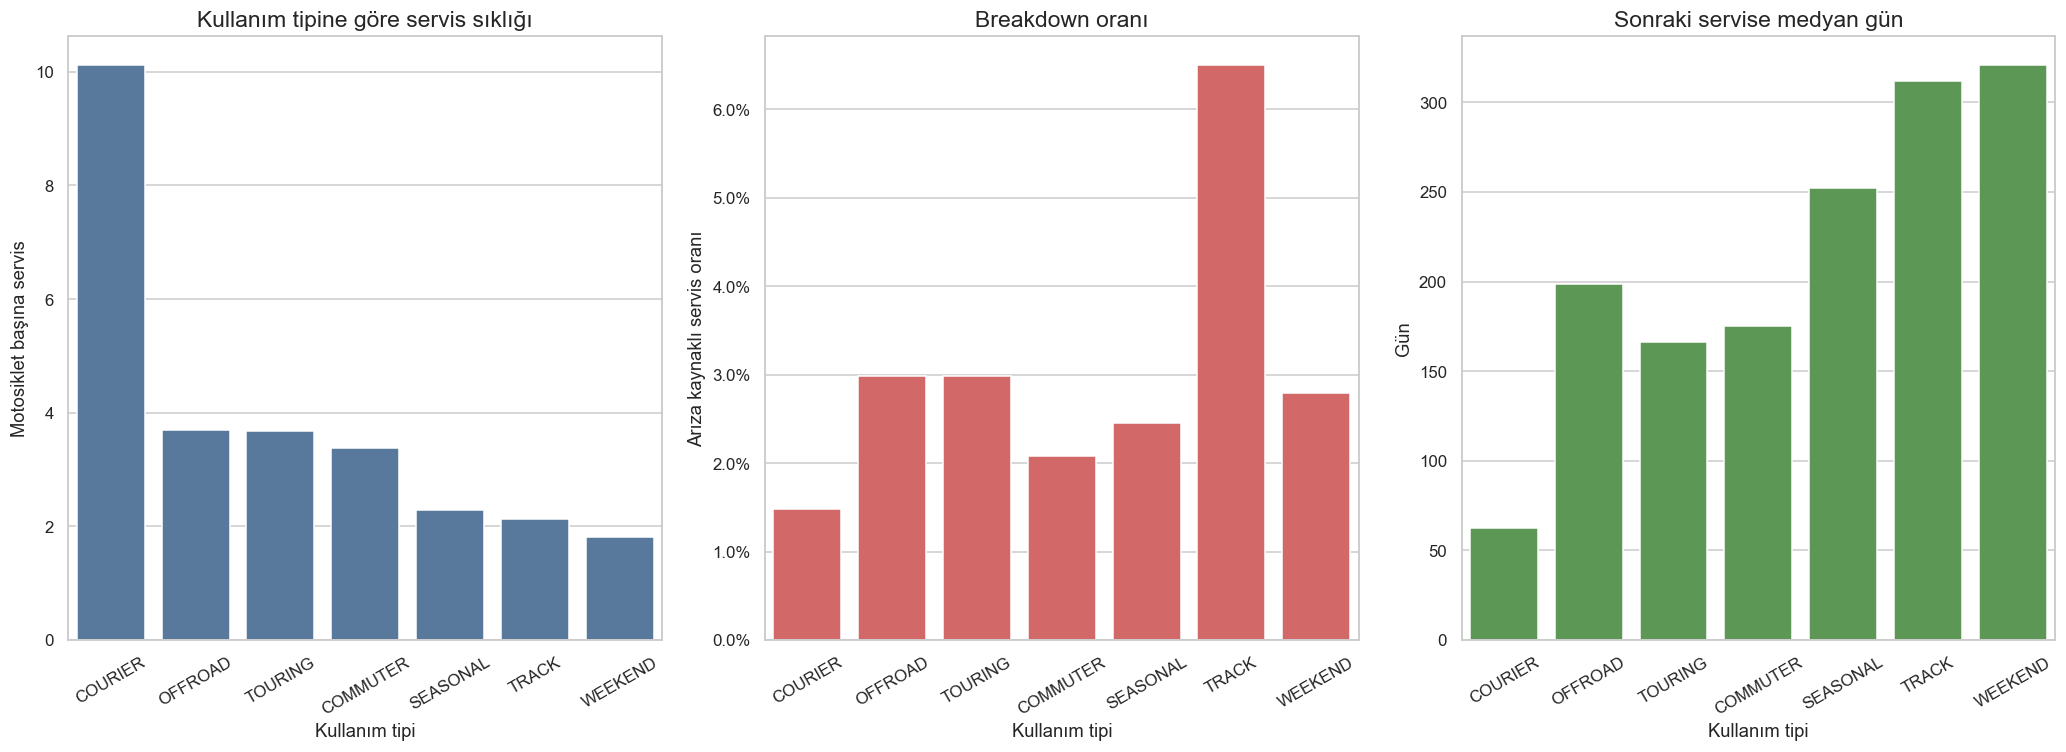

,usage_type,motorcycle_count,avg_services_per_motorcycle,avg_service_cost,breakdown_rate,avg_annual_km,median_days_to_next_service,median_km_to_next_service
0,COMMUTER,5024,3.38,2281.46,0.02,11427.41,174.99,6019.0
1,COURIER,1714,10.13,2478.70,0.01,26705.13,62.64,4885.0
2,OFFROAD,39,3.69,3293.62,0.03,8928.21,198.68,4339.5
3,SEASONAL,823,2.28,2335.47,0.02,7979.95,252.06,5390.0
4,TOURING,369,3.69,2690.11,0.03,15379.95,166.15,6350.5
5,TRACK,297,2.13,2642.97,0.07,6527.27,312.11,4102.0
6,WEEKEND,1734,1.82,2385.56,0.03,7197.00,320.99,5337.0


In [25]:
# Kullanım tipi bazında servis davranışı ve hedefler
motor_service_metrics = (
    services_eda.groupby("motorcycle_id")
    .agg(
        service_count=("service_id", "nunique"),
        avg_service_cost=("grand_total", "mean"),
        total_service_spend=("grand_total", "sum"),
        breakdown_rate=("is_breakdown", "mean"),
    )
    .reset_index()
)

usage_analysis = (
    df_usage_profiles[["motorcycle_id", "usage_type", "annual_km_baseline"]]
    .merge(motor_service_metrics, on="motorcycle_id", how="left")
)
usage_analysis[["service_count", "total_service_spend", "breakdown_rate"]] = (
    usage_analysis[["service_count", "total_service_spend", "breakdown_rate"]].fillna(0)
)

observed_usage_targets = (
    df_ml_snapshots[["snapshot_id", "motorcycle_id"]]
    .merge(df_next_service_targets[["snapshot_id", "target_event_observed", "days_to_next_service", "km_to_next_service"]], on="snapshot_id", validate="one_to_one")
    .query("target_event_observed == 1")
    .merge(df_usage_profiles[["motorcycle_id", "usage_type"]], on="motorcycle_id", how="left")
)

usage_summary = (
    usage_analysis.groupby("usage_type")
    .agg(
        motorcycle_count=("motorcycle_id", "nunique"),
        avg_services_per_motorcycle=("service_count", "mean"),
        avg_service_cost=("avg_service_cost", "mean"),
        breakdown_rate=("breakdown_rate", "mean"),
        avg_annual_km=("annual_km_baseline", "mean"),
    )
    .reset_index()
)
usage_target_summary = (
    observed_usage_targets.groupby("usage_type")
    .agg(median_days_to_next_service=("days_to_next_service", "median"), median_km_to_next_service=("km_to_next_service", "median"))
    .reset_index()
)
usage_summary = usage_summary.merge(usage_target_summary, on="usage_type", how="left")
usage_order = usage_summary.sort_values("avg_services_per_motorcycle", ascending=False)["usage_type"]

fig, axes = plt.subplots(1, 3, figsize=(19, 7))
sns.barplot(data=usage_summary, x="usage_type", y="avg_services_per_motorcycle", order=usage_order, ax=axes[0], color="#4C78A8")
sns.barplot(data=usage_summary, x="usage_type", y="breakdown_rate", order=usage_order, ax=axes[1], color="#E45756")
sns.barplot(data=usage_summary, x="usage_type", y="median_days_to_next_service", order=usage_order, ax=axes[2], color="#54A24B")
axes[0].set(title="Kullanım tipine göre servis sıklığı", xlabel="Kullanım tipi", ylabel="Motosiklet başına servis")
axes[1].set(title="Breakdown oranı", xlabel="Kullanım tipi", ylabel="Arıza kaynaklı servis oranı"); axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[2].set(title="Sonraki servise medyan gün", xlabel="Kullanım tipi", ylabel="Gün")
for ax in axes: ax.tick_params(axis="x", rotation=30)
finish_plot(fig, "18_usage_type_service_behavior.png")
display(usage_summary.round(2))

In [26]:
track_models = (
    df_usage_profiles
    .query("usage_type == 'TRACK'")
    [["motorcycle_id", "usage_type"]]
    .merge(
        df_motorcycles[
            [
                "motorcycle_id",
                "brand",
                "model_name",
                "category"
            ]
        ],
        on="motorcycle_id",
        validate="one_to_one"
    )
    .groupby(
        ["brand", "model_name", "category"]
    )
    .size()
    .sort_values(ascending=False)
    .rename("motorcycle_count")
    .reset_index()
)

track_models["ratio_pct"] = (
    100 * track_models["motorcycle_count"] /
    track_models["motorcycle_count"].sum()
).round(1)

display(track_models)

,brand,model_name,category,motorcycle_count,ratio_pct
0,CFMOTO,250NK,NAKED,86,29.0
1,CFMOTO,250SR,SUPERSPORT,68,22.9
2,TVS,Apache RTR 200 4V FI,NAKED,66,22.2
3,Yamaha,XSR125,NAKED,49,16.5
4,Honda,CL250,SCRAMBLER,28,9.4


### Kullanım tipi analizi nasıl yorumlanır?

- Servis sayısı yüksek olan kullanım tipleri daha yoğun bakım geçmişine sahiptir.
- **Breakdown oranı**, planlı bakım değil arıza nedeniyle başlayan servislerin payıdır.
- Sonraki servise medyan gün düşükse bu grup daha kısa zaman aralıklarıyla servise dönmektedir.

`COURIER` gibi yoğun kullanım gruplarının yıllık kilometresi ve servis sayısı genellikle daha yüksek olabilir. Ancak burada görülen ilişki sentetik üretim kurallarının sonucudur; gerçek pazar davranışı olarak yorumlanmamalıdır.

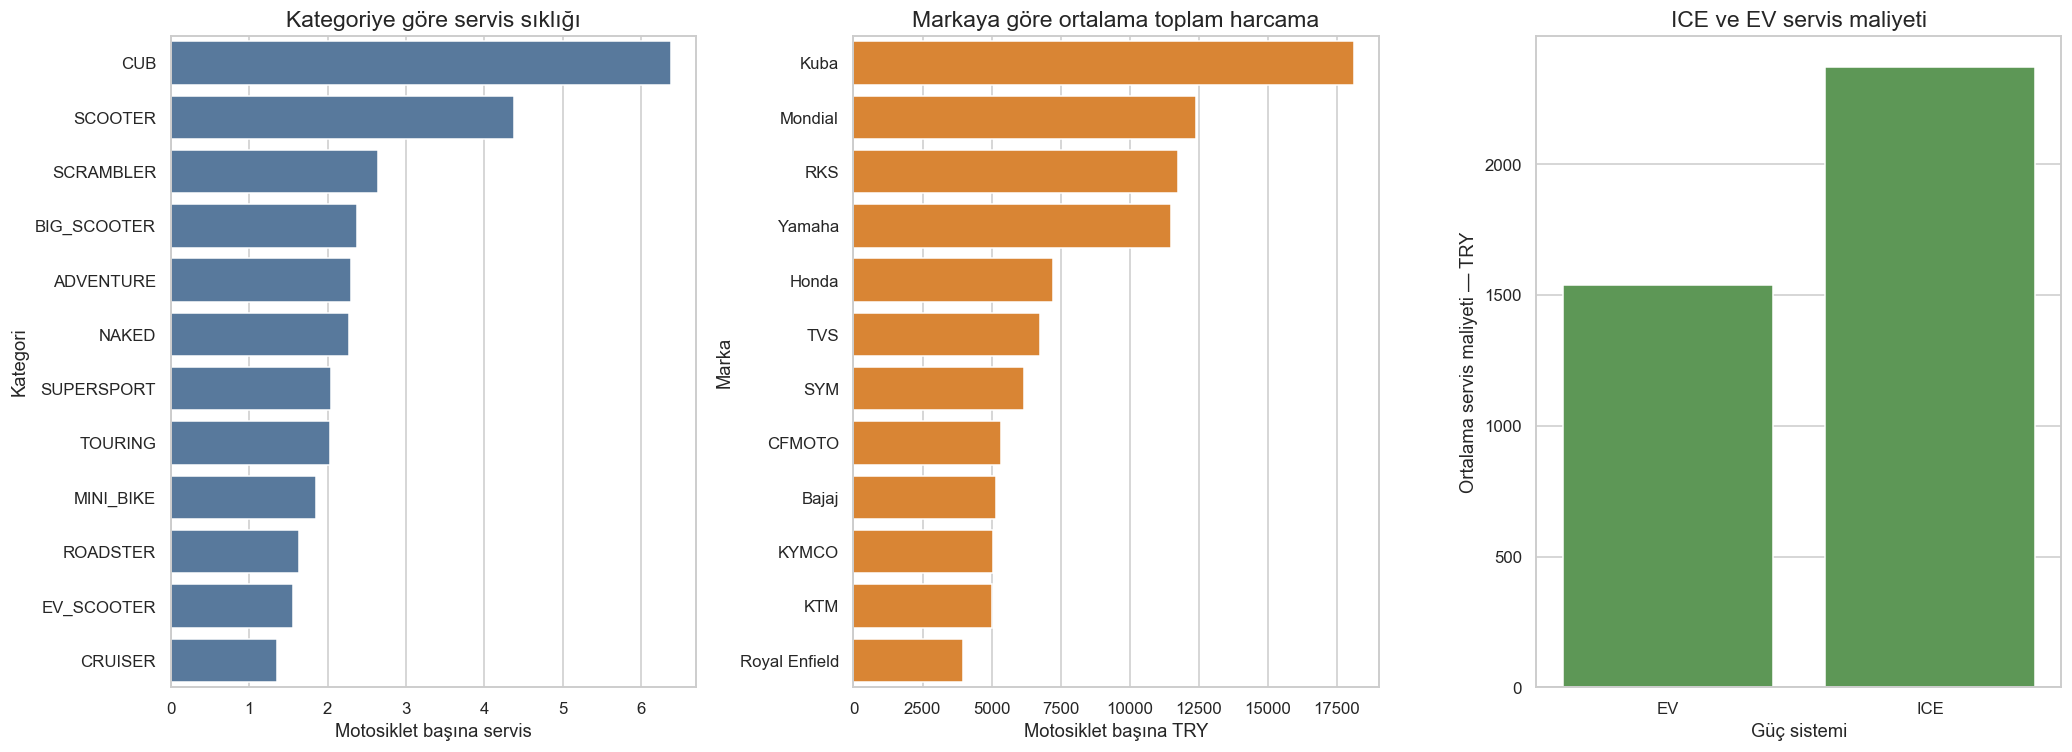

,powertrain_type,motorcycle_count,avg_services,avg_service_cost,avg_total_spend
0,EV,36,1.56,1539.70,2564.98
1,ICE,9964,4.16,2372.21,9170.30


In [27]:
# Motosiklet marka, kategori ve güç sistemi karşılaştırmaları
motorcycle_segment = (
    df_motorcycles[["motorcycle_id", "brand", "category", "powertrain_type", "production_year"]]
    .merge(motor_service_metrics, on="motorcycle_id", how="left")
)
motorcycle_segment[["service_count", "total_service_spend", "breakdown_rate"]] = (
    motorcycle_segment[["service_count", "total_service_spend", "breakdown_rate"]].fillna(0)
)
motorcycle_segment["age_at_horizon"] = 2026 - motorcycle_segment["production_year"]

category_summary = motorcycle_segment.groupby("category").agg(motorcycle_count=("motorcycle_id", "nunique"), avg_services=("service_count", "mean"), avg_total_spend=("total_service_spend", "mean")).reset_index()
brand_summary = motorcycle_segment.groupby("brand").agg(motorcycle_count=("motorcycle_id", "nunique"), avg_services=("service_count", "mean"), avg_total_spend=("total_service_spend", "mean")).reset_index()
powertrain_summary = motorcycle_segment.groupby("powertrain_type").agg(motorcycle_count=("motorcycle_id", "nunique"), avg_services=("service_count", "mean"), avg_service_cost=("avg_service_cost", "mean"), avg_total_spend=("total_service_spend", "mean")).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(19, 7))
sns.barplot(data=category_summary.sort_values("avg_services", ascending=False), x="avg_services", y="category", ax=axes[0], color="#4C78A8")
sns.barplot(data=brand_summary.sort_values("avg_total_spend", ascending=False), x="avg_total_spend", y="brand", ax=axes[1], color="#F58518")
sns.barplot(data=powertrain_summary, x="powertrain_type", y="avg_service_cost", ax=axes[2], color="#54A24B")
axes[0].set(title="Kategoriye göre servis sıklığı", xlabel="Motosiklet başına servis", ylabel="Kategori")
axes[1].set(title="Markaya göre ortalama toplam harcama", xlabel="Motosiklet başına TRY", ylabel="Marka")
axes[2].set(title="ICE ve EV servis maliyeti", xlabel="Güç sistemi", ylabel="Ortalama servis maliyeti — TRY")
finish_plot(fig, "19_motorcycle_segment_comparison.png")
display(powertrain_summary.round(2))

ICE → Benzinli / içten yanmalı motosiklet
EV  → Elektrikli motosiklet

### Motosiklet segmenti grafikleri nasıl yorumlanır?

Kategori ve marka farkları; motosiklet sayısı, kullanım yoğunluğu, teknik yapı, görev ve parça ihtiyacı gibi etkenlerin birleşimidir. Ortalama toplam harcama, tek servis maliyetinden farklıdır: hem servis sıklığını hem de servis başı tutarı içerir.

> EV örnek sayısı ICE grubundan çok daha azsa iki grubun ortalamalarını eşit güvenilirlikte kabul etmeyin. `motorcycle_count` mutlaka ortalamayla birlikte okunmalıdır.

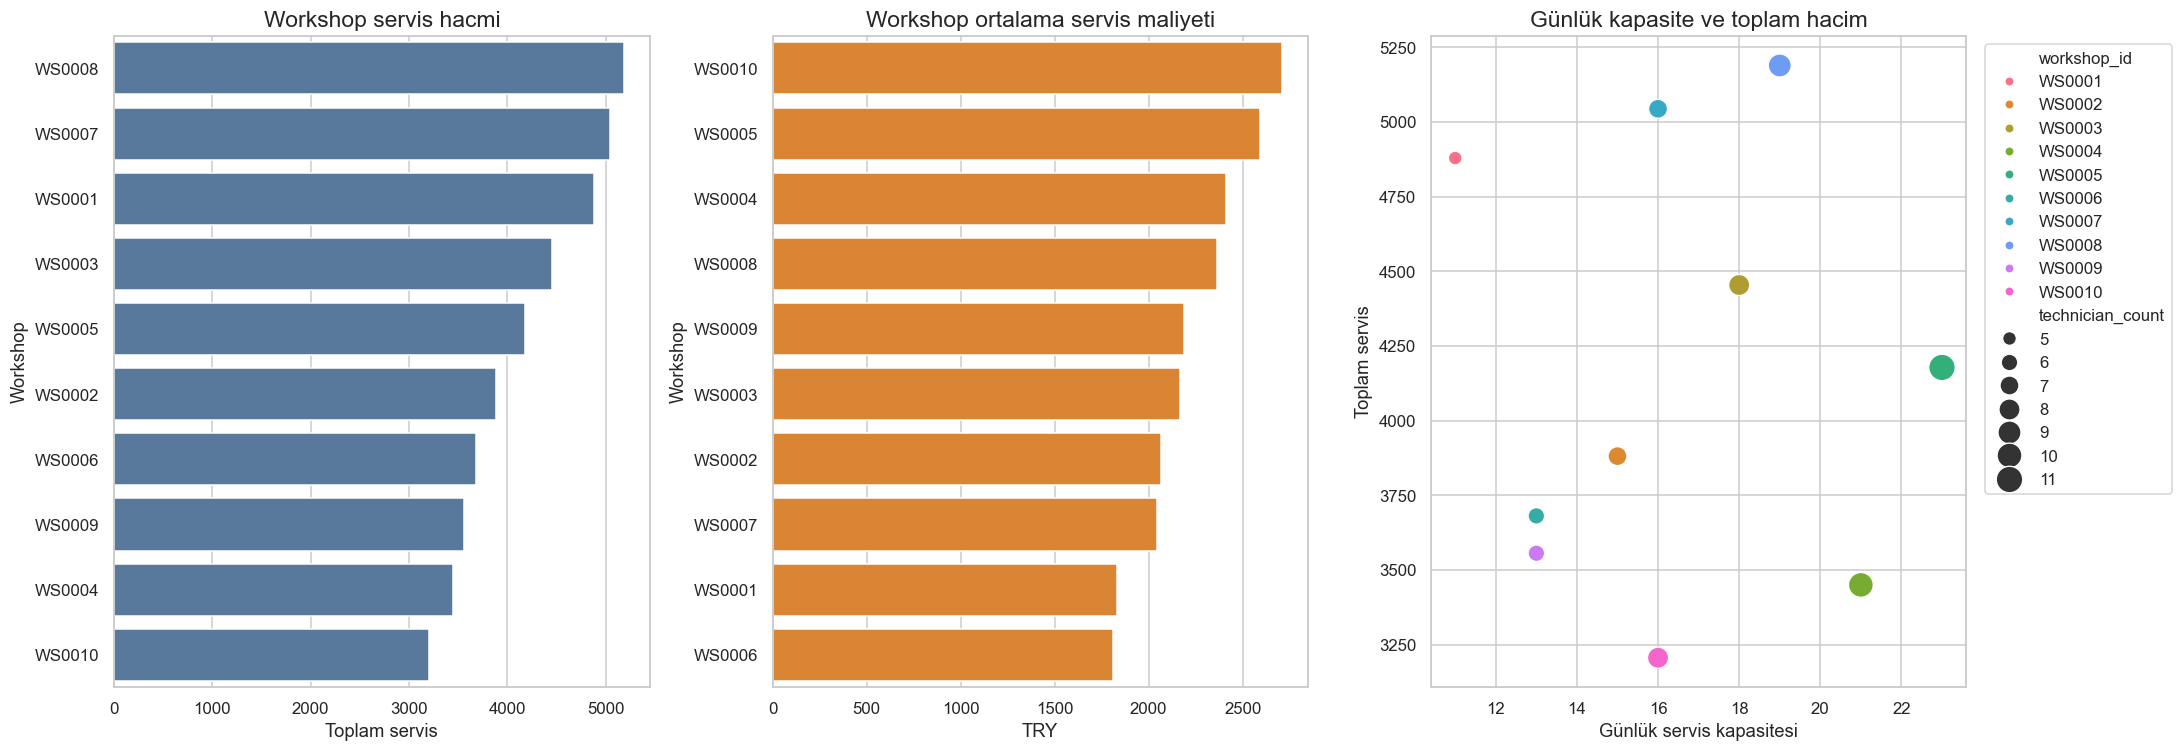

,workshop_id,service_count,avg_service_cost,median_service_cost,avg_turnaround_hours,breakdown_rate,workshop_name,daily_service_capacity,service_bay_count,technician_count
7,WS0008,5189,2363.60,1996.56,11.97,0.02,RideBase Sentetik Servis Gaziantep,19,7,9
6,WS0007,5044,2046.24,1704.10,11.63,0.02,RideBase Sentetik Servis Adana,16,6,7
0,WS0001,4879,1833.26,1555.20,12.65,0.02,RideBase Sentetik Servis İstanbul Anadolu,11,4,5
2,WS0003,4454,2166.95,1767.60,11.97,0.02,RideBase Sentetik Servis İzmir,18,7,8
4,WS0005,4178,2592.10,2163.14,11.55,0.03,RideBase Sentetik Premium Servis Antalya,23,9,11
1,WS0002,3881,2064.03,1692.00,12.10,0.02,RideBase Sentetik Servis Ankara,15,6,7
5,WS0006,3681,1809.34,1559.52,13.75,0.02,RideBase Sentetik Servis Konya,13,5,6
8,WS0009,3556,2186.62,1843.20,12.77,0.02,RideBase Sentetik Servis Samsun,13,5,6
3,WS0004,3450,2410.09,2029.20,11.33,0.03,RideBase Sentetik Servis Bursa,21,8,10
9,WS0010,3206,2711.23,2209.80,11.23,0.03,RideBase Sentetik Premium Servis Eskişehir,16,6,8


In [28]:
# Workshop hacmi, maliyeti, teslim süresi ve kapasitesi
status_times = df_service_status_history[["service_id", "status", "status_at"]].copy()
status_times["status_at"] = pd.to_datetime(status_times["status_at"], errors="coerce")
received_times = status_times.loc[status_times["status"].eq("RECEIVED")].groupby("service_id")["status_at"].min().rename("canonical_received_at")
delivered_times = status_times.loc[status_times["status"].eq("DELIVERED")].groupby("service_id")["status_at"].max().rename("canonical_delivered_at")
service_durations = pd.concat([received_times, delivered_times], axis=1).reset_index()
service_durations["turnaround_hours"] = (service_durations["canonical_delivered_at"] - service_durations["canonical_received_at"]).dt.total_seconds() / 3600

workshop_services = services_eda.merge(service_durations[["service_id", "turnaround_hours"]], on="service_id", how="left")
workshop_summary = (
    workshop_services.groupby("workshop_id")
    .agg(service_count=("service_id", "nunique"), avg_service_cost=("grand_total", "mean"), median_service_cost=("grand_total", "median"), avg_turnaround_hours=("turnaround_hours", "mean"), breakdown_rate=("is_breakdown", "mean"))
    .reset_index()
    .merge(df_workshops[["workshop_id", "workshop_name", "daily_service_capacity", "service_bay_count", "technician_count"]], on="workshop_id", how="left")
)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
sns.barplot(data=workshop_summary.sort_values("service_count", ascending=False), x="service_count", y="workshop_id", ax=axes[0], color="#4C78A8")
sns.barplot(data=workshop_summary.sort_values("avg_service_cost", ascending=False), x="avg_service_cost", y="workshop_id", ax=axes[1], color="#F58518")
sns.scatterplot(data=workshop_summary, x="daily_service_capacity", y="service_count", size="technician_count", hue="workshop_id", sizes=(80, 300), ax=axes[2])
axes[0].set(title="Workshop servis hacmi", xlabel="Toplam servis", ylabel="Workshop")
axes[1].set(title="Workshop ortalama servis maliyeti", xlabel="TRY", ylabel="Workshop")
axes[2].set(title="Günlük kapasite ve toplam hacim", xlabel="Günlük servis kapasitesi", ylabel="Toplam servis"); axes[2].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
finish_plot(fig, "20_workshop_performance.png")
display(workshop_summary.sort_values("service_count", ascending=False).round(2))

### Workshop grafikleri nasıl okunur?

- **Soldaki — Servis hacmi:** Her workshop'un dataset boyunca gerçekleştirdiği toplam servis sayısıdır. Uzun çubuk daha yoğun workshop demektir. `WS0008`, **5.189 servisle** en yüksek hacme sahiptir.
- **Ortadaki — Ortalama servis maliyeti:** Workshop'taki bir servis işleminin ortalama fatura tutarıdır. `WS0010`, yaklaşık **2.711 TRY** ile en yüksek ortalamaya sahiptir. Yüksek tutar yalnızca fiyatı değil, yapılan işlemleri ve kullanılan parçaları da yansıtabilir.
- **Sağdaki — Kapasite ve hacim:** Sağa gidildikçe günlük kapasite, yukarı gidildikçe toplam servis sayısı artar. Noktanın büyüklüğü teknisyen sayısını, rengi workshop'u gösterir.

> Yüksek kapasite her zaman yüksek servis sayısı anlamına gelmez; müşteri talebi ve profil de etkilidir. Sağdaki grafik gerçek kapasite kullanım oranı değildir, çünkü günlük kapasiteyi birkaç yıllık toplam hacimle karşılaştırır.

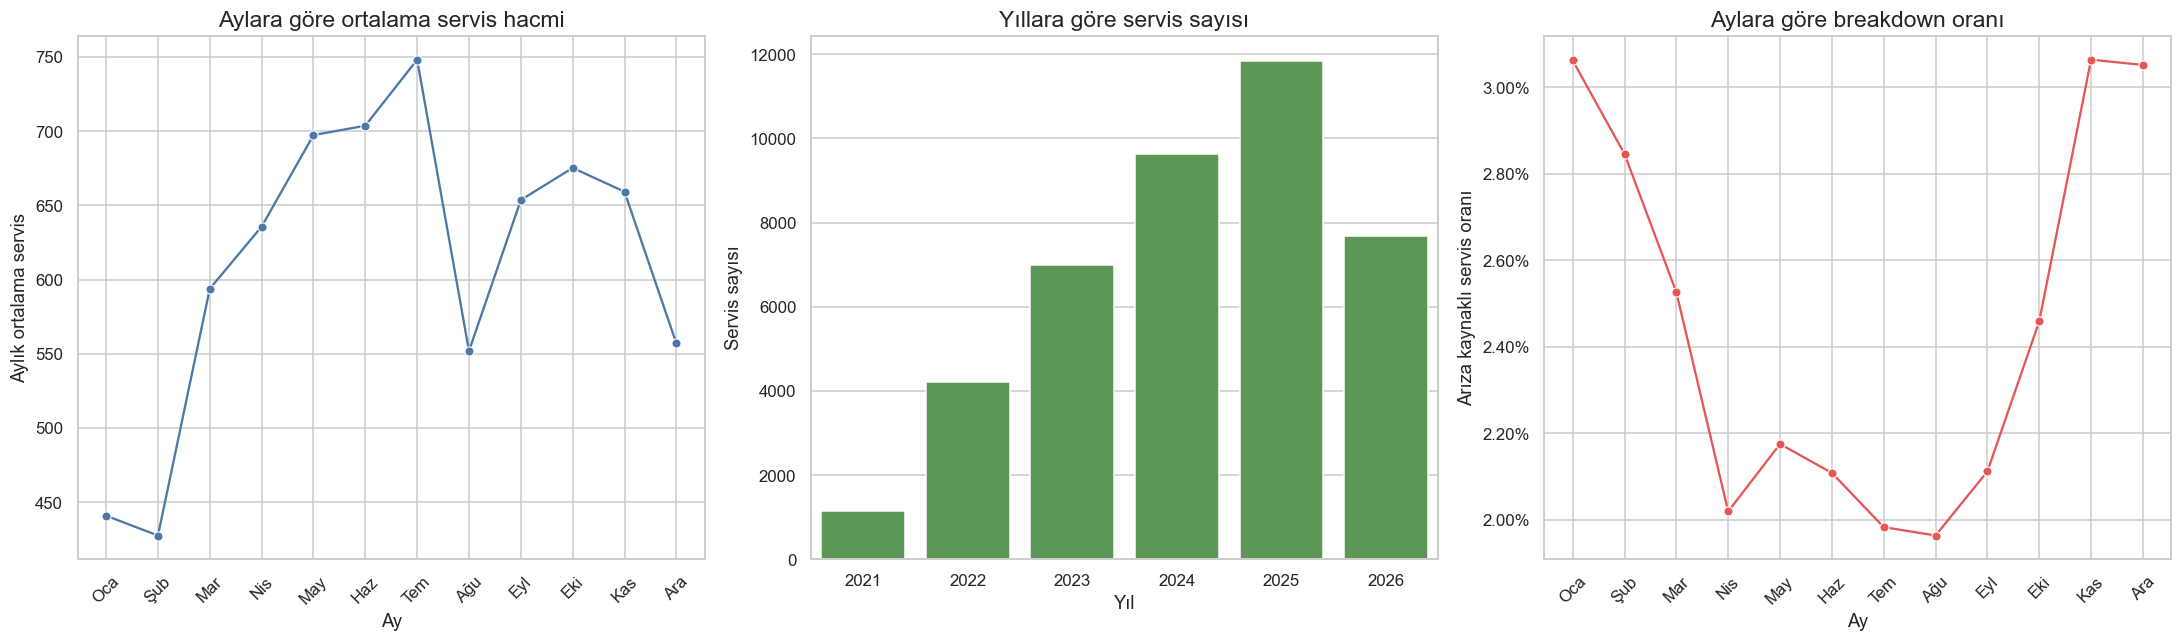

,year,service_count,avg_service_cost,breakdown_rate
0,2021,1153,536.80,0.03
1,2022,4220,847.97,0.03
2,2023,6985,1399.06,0.02
3,2024,9633,2104.18,0.03
4,2025,11844,2716.55,0.02
5,2026,7683,3260.58,0.02


In [29]:
# Mevsimsellik ve yıllara göre servis davranışı
services_time = services_eda.dropna(subset=["received_at"]).copy()
services_time["year"] = services_time["received_at"].dt.year
services_time["month_number"] = services_time["received_at"].dt.month
month_names_tr = {1:"Ocak", 2:"Şubat", 3:"Mart", 4:"Nisan", 5:"Mayıs", 6:"Haziran", 7:"Temmuz", 8:"Ağustos", 9:"Eylül", 10:"Ekim", 11:"Kasım", 12:"Aralık"}

monthly_by_year = services_time.groupby(["year", "month_number"]).size().rename("service_count").reset_index()
seasonality = monthly_by_year.groupby("month_number")["service_count"].mean().reset_index()
seasonality["month_name"] = seasonality["month_number"].map(month_names_tr)
yearly_summary = services_time.groupby("year").agg(service_count=("service_id", "nunique"), avg_service_cost=("grand_total", "mean"), breakdown_rate=("is_breakdown", "mean")).reset_index()
monthly_breakdown = services_time.groupby("month_number")["is_breakdown"].mean().reset_index(); monthly_breakdown["month_name"] = monthly_breakdown["month_number"].map(month_names_tr)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.lineplot(data=seasonality, x="month_number", y="service_count", marker="o", ax=axes[0], color="#4C78A8")
sns.barplot(data=yearly_summary, x="year", y="service_count", ax=axes[1], color="#54A24B")
sns.lineplot(data=monthly_breakdown, x="month_number", y="is_breakdown", marker="o", ax=axes[2], color="#E45756")
axes[0].set(title="Aylara göre ortalama servis hacmi", xlabel="Ay", ylabel="Aylık ortalama servis"); axes[0].set_xticks(range(1,13), [month_names_tr[i][:3] for i in range(1,13)], rotation=45)
axes[1].set(title="Yıllara göre servis sayısı", xlabel="Yıl", ylabel="Servis sayısı")
axes[2].set(title="Aylara göre breakdown oranı", xlabel="Ay", ylabel="Arıza kaynaklı servis oranı"); axes[2].set_xticks(range(1,13), [month_names_tr[i][:3] for i in range(1,13)], rotation=45); axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(1))
finish_plot(fig, "21_temporal_seasonality.png")
display(yearly_summary.round(2))

### 2026 servis sayısı neden düşük görünüyor?

2026 tam bir yıl değildir. Datasetin son servis tarihi **1 Ağustos 2026** olduğu için eylül–aralık aylarına ait kayıt bulunmamaktadır. Ağustos ayında da yalnızca 40 servis kaydı vardır.

Bu nedenle 2025'in 12 aylık toplamı ile 2026'nın yaklaşık 7 aylık toplamını doğrudan karşılaştırmak yanıltıcıdır.

Aynı dönem karşılaştırıldığında:

- 2025 Ocak–1 Ağustos: **6.610 servis**
- 2026 Ocak–1 Ağustos: **7.683 servis**

2026'nın aynı dönem servis hacmi yaklaşık `%16` daha yüksektir.

> Grafikte görülen düşüş gerçek bir servis talebi düşüşü değil, **tamamlanmamış yıl etkisidir**. 2026 değeri `YTD — yılbaşından bugüne` olarak okunmalıdır.

### Zamansal grafikler nasıl yorumlanır?

Aylık ortalama hacim, aynı takvim ayının farklı yıllardaki servis sayılarını ortalar ve mevsimsel deseni görünür hale getirir. Yıllık toplamlar karşılaştırılırken 2021 ve 2026'nın dataset içinde tam takvim yılı olmayabileceği unutulmamalıdır. Breakdown oranındaki aylık değişim, çevresel veya kullanım kaynaklı mevsimselliğe işaret edebilir; sentetik üretim kuralı olduğu için gerçek pazar kanıtı değildir.

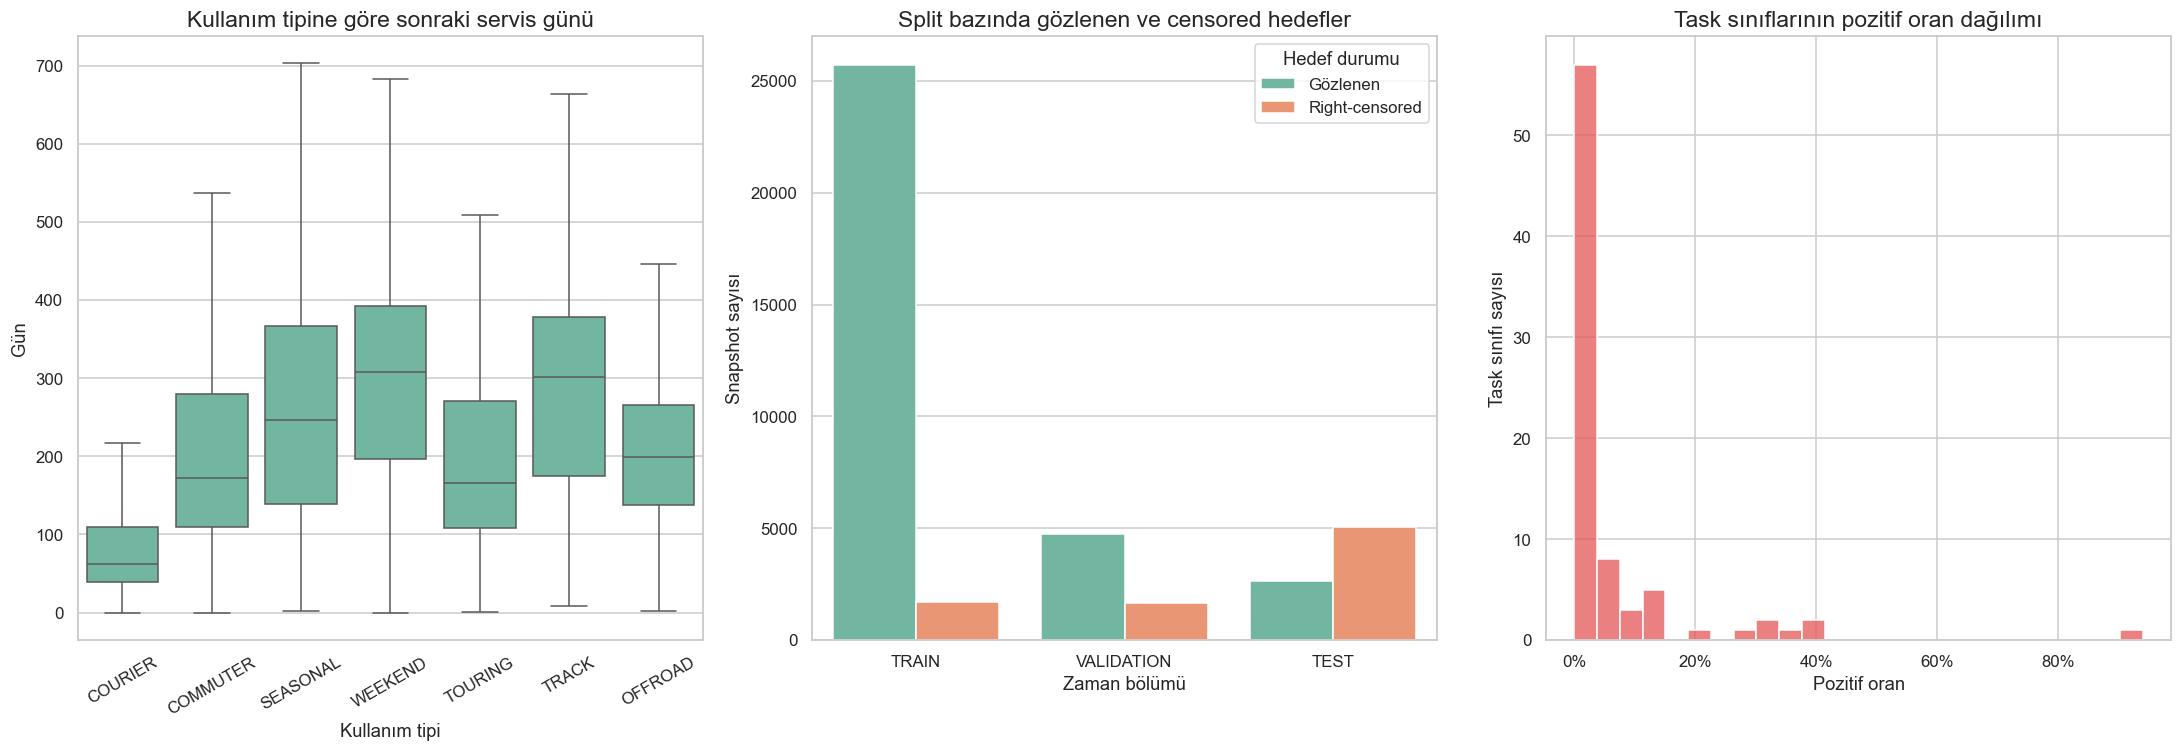

,primary_time_split,snapshot_count,observed_rate,median_days_to_next_service,median_km_to_next_service
0,TEST,7691,0.34,57.94,3995.5
1,TRAIN,27428,0.94,130.94,5576.5
2,VALIDATION,6399,0.74,107.90,5152.0


In [30]:
# ML hedeflerinin kullanım tipi ve split bazında dağılımı
usage_day_limit = observed_usage_targets["days_to_next_service"].quantile(0.99)
usage_target_plot = observed_usage_targets[observed_usage_targets["days_to_next_service"].le(usage_day_limit)].copy()

split_targets = (
    df_split_manifest[["snapshot_id", "primary_time_split"]]
    .merge(df_next_service_targets[["snapshot_id", "target_event_observed", "is_right_censored", "days_to_next_service", "km_to_next_service"]], on="snapshot_id", validate="one_to_one")
)
split_targets["event_status"] = split_targets["target_event_observed"].map({1:"Gözlenen", 0:"Right-censored"})
split_summary = split_targets.groupby("primary_time_split").agg(snapshot_count=("snapshot_id", "size"), observed_rate=("target_event_observed", "mean"), median_days_to_next_service=("days_to_next_service", "median"), median_km_to_next_service=("km_to_next_service", "median")).reset_index()
task_positive_rates = observed_task_targets.mean().astype(float)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
sns.boxplot(data=usage_target_plot, x="usage_type", y="days_to_next_service", showfliers=False, ax=axes[0])
sns.countplot(data=split_targets, x="primary_time_split", hue="event_status", order=["TRAIN", "VALIDATION", "TEST"], ax=axes[1])
sns.histplot(task_positive_rates, bins=25, ax=axes[2], color="#E45756")
axes[0].set(title="Kullanım tipine göre sonraki servis günü", xlabel="Kullanım tipi", ylabel="Gün"); axes[0].tick_params(axis="x", rotation=30)
axes[1].set(title="Split bazında gözlenen ve censored hedefler", xlabel="Zaman bölümü", ylabel="Snapshot sayısı"); axes[1].legend(title="Hedef durumu")
axes[2].set(title="Task sınıflarının pozitif oran dağılımı", xlabel="Pozitif oran", ylabel="Task sınıfı sayısı"); axes[2].xaxis.set_major_formatter(mtick.PercentFormatter(1))
finish_plot(fig, "22_ml_target_segment_and_split.png")
display(split_summary.round(2))

### ML hedef grafikleri nasıl yorumlanır?

- Kullanım tipine göre kutular ayrışıyorsa kullanım profili sonraki servis zamanını açıklayan önemli bir feature olabilir.
- TRAIN, VALIDATION ve TEST gruplarında censoring oranı farklıysa model değerlendirmesi zorlaşabilir; metrikler split bazında raporlanmalıdır.
- Task pozitif oranlarının çoğu sıfıra yakınsa ciddi **sınıf dengesizliği** vardır. Yalnızca accuracy kullanmak yanıltıcı olur; class-wise precision, recall, F1 ve PR-AUC tercih edilmelidir.
- Right-censored task etiketleri negatif `0` değildir; bilinmeyen `NULL` değerlerdir.

In [31]:
# EDA'nın veriden otomatik üretilen kısa bulguları
top_usage_services = usage_summary.sort_values("avg_services_per_motorcycle", ascending=False).iloc[0]
shortest_usage_target = usage_summary.dropna(subset=["median_days_to_next_service"]).sort_values("median_days_to_next_service").iloc[0]
top_workshop = workshop_summary.sort_values("service_count", ascending=False).iloc[0]
top_category_spend = category_summary.sort_values("avg_total_spend", ascending=False).iloc[0]
censor_rate = df_next_service_targets["is_right_censored"].mean()
zero_positive_tasks = int(task_positive_rates.eq(0).sum())
top_task_name = task_positive_rates.sort_values(ascending=False).index[0].replace("task__", "")
top_task_rate = task_positive_rates.max()

display(Markdown(f"""
## EDA sonucunda öne çıkan bulgular

1. Motosiklet başına en yüksek ortalama servis sayısı **{top_usage_services['usage_type']}** kullanım grubundadır: **{top_usage_services['avg_services_per_motorcycle']:.2f}**.
2. Sonraki servise en kısa medyan süre **{shortest_usage_target['usage_type']}** grubundadır: **{shortest_usage_target['median_days_to_next_service']:.0f} gün**.
3. En yüksek servis hacmine sahip workshop **{top_workshop['workshop_id']}**: **{int(top_workshop['service_count']):,} servis**.
4. Motosiklet başına ortalama toplam harcaması en yüksek kategori **{top_category_spend['category']}**: **{top_category_spend['avg_total_spend']:,.0f} TRY**.
5. Next-service snapshot'larının **%{censor_rate*100:.1f}** kadarı right-censored durumdadır.
6. **{zero_positive_tasks}** task sınıfında gözlenen pozitif örnek yoktur.
7. En yaygın next-task hedefi **{top_task_name}** ve gözlenen servislerdeki pozitif oranı **%{top_task_rate*100:.1f}** düzeyindedir.

> Bunlar sentetik dataset içindeki ilişkilerdir; gerçek motosiklet pazarı veya müşteri davranışı hakkında doğrudan kanıt değildir.
"""))


## EDA sonucunda öne çıkan bulgular

1. Motosiklet başına en yüksek ortalama servis sayısı **COURIER** kullanım grubundadır: **10.13**.
2. Sonraki servise en kısa medyan süre **COURIER** grubundadır: **63 gün**.
3. En yüksek servis hacmine sahip workshop **WS0008**: **5,189 servis**.
4. Motosiklet başına ortalama toplam harcaması en yüksek kategori **CUB**: **13,195 TRY**.
5. Next-service snapshot'larının **%20.3** kadarı right-censored durumdadır.
6. **21** task sınıfında gözlenen pozitif örnek yoktur.
7. En yaygın next-task hedefi **ENGINE_OIL_CHANGE** ve gözlenen servislerdeki pozitif oranı **%94.0** düzeyindedir.

> Bunlar sentetik dataset içindeki ilişkilerdir; gerçek motosiklet pazarı veya müşteri davranışı hakkında doğrudan kanıt değildir.


## Modellemeye geçerken kullanılacak ve çıkarılacak alanlar

### Feature kaynağı

Ana feature tablosu `ml_maintenance_snapshots.parquet` olmalıdır. Target tabloları yalnızca `snapshot_id` ile sonradan birleştirilmelidir.

### Kullanılabilecek feature grupları

- Motosiklet: yaş, kategori, güç sistemi, motor hacmi ve teknik özellikler
- Kullanım: `usage_type`, yıllık kilometre, günlük sürüş, şehir/otoyol/arazi oranları
- Mevcut servis: kilometre, servis türü, task sayıları ve maliyetler
- Geçmiş: önceki servisten geçen gün/km, hareketli servis aralıkları, birikimli harcama
- Workshop: kapasite, teknisyen, fiyat ve parça tedarik özellikleri
- Mevsimsellik: ay, çeyrek ve sin/cos dönüşümleri

### Modele doğrudan verilmemesi gereken alanlar

- Benzersiz kimlikler: `snapshot_id`, `service_id`, `motorcycle_id`, `customer_id`
- Yapay kimlikler: `vin_synthetic`, `plate_synthetic`, `synthetic_alias`
- Provenance: `data_origin`, `generator_version`, `random_seed`, `scenario_id`
- Serbest metin: ham not ve şikâyet alanları, özel bir NLP çalışması yapılmıyorsa
- Gelecek bilgileri: bütün `next_*` alanları ve target tablolarındaki sonuçlar

### Hedefe göre örnek seçimi

- Gün/km regresyonu: doğrudan regresyonda yalnızca gözlenen ve ilgili hedefi geçerli satırlar kullanılmalıdır.
- Survival analizi: gözlenen ve right-censored satırlar birlikte kullanılabilir.
- Next-task modeli: yalnızca sonraki servisi gözlenen satırlardaki 1/0 label'lar doğrudan sınıflandırmada kullanılmalıdır.
- Veri bölme: random split yerine `split_manifest.csv` içindeki zaman bazlı split kullanılmalıdır.

# EDA Aşama 3 — İlk 14 Tamamlayıcı Analiz

Bu bölüm EDA'yı 14 tamamlayıcı başlıkla derinleştirir. Grafikler **ilişki ve örüntü** gösterir; tek başına neden–sonuç kanıtlamaz. Tutarlar `TRY`, süreler gün/saat, oranlar yüzde olarak gösterilir.

## 1. Kilometre kullanımı

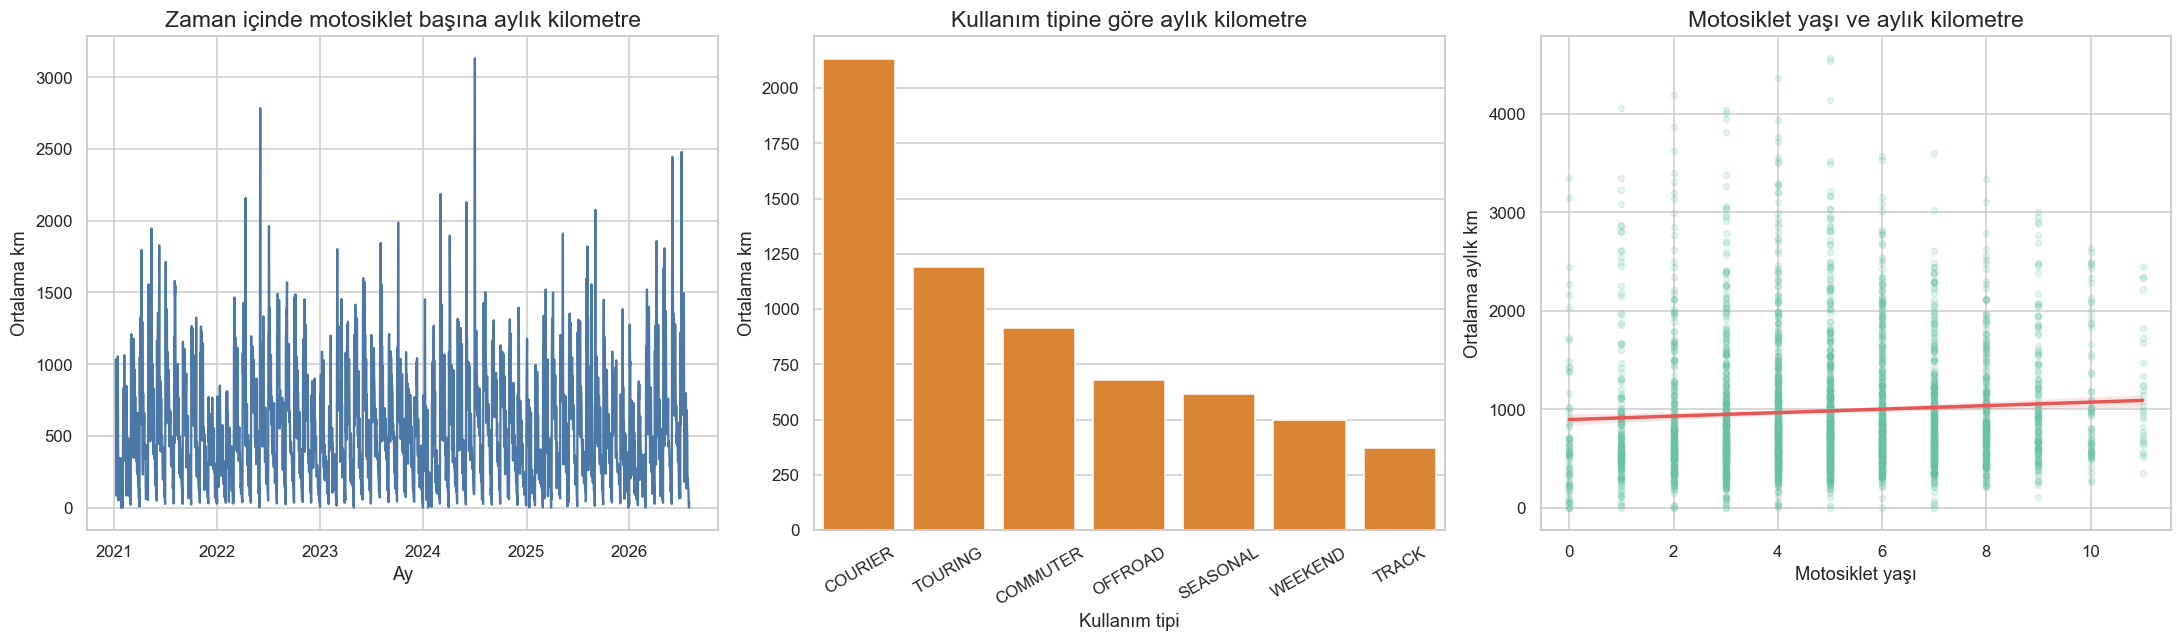

,usage_type,motorcycle_count,avg_monthly_km,median_monthly_km
1,COURIER,1714,2129.9,2054.0
4,TOURING,369,1189.1,1094.0
0,COMMUTER,5024,914.2,863.0
2,OFFROAD,39,680.3,630.0
3,SEASONAL,823,616.2,546.0
6,WEEKEND,1734,497.5,439.0
5,TRACK,297,370.0,320.0


In [32]:
mileage_eda = df_mileage_monthly.copy()
mileage_eda["period_start_date"] = pd.to_datetime(mileage_eda["period_start_date"], errors="coerce")
mileage_eda["km_added"] = pd.to_numeric(mileage_eda["km_added"], errors="coerce")
mileage_eda = mileage_eda.query("km_added >= 0").copy()

monthly_km = mileage_eda.groupby("period_start_date").agg(
    total_km=("km_added", "sum"),
    avg_km_per_motorcycle=("km_added", "mean"),
).reset_index()
usage_km = mileage_eda.groupby("usage_type").agg(
    motorcycle_count=("motorcycle_id", "nunique"),
    avg_monthly_km=("km_added", "mean"),
    median_monthly_km=("km_added", "median"),
).reset_index().sort_values("avg_monthly_km", ascending=False)

motor_km = mileage_eda.groupby("motorcycle_id")["km_added"].mean().rename("avg_monthly_km").reset_index()
motor_age_km = motor_km.merge(df_motorcycles[["motorcycle_id", "production_year"]], on="motorcycle_id", how="left")
motor_age_km["motorcycle_age"] = 2026 - motor_age_km["production_year"]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.lineplot(data=monthly_km, x="period_start_date", y="avg_km_per_motorcycle", ax=axes[0], color="#4C78A8")
sns.barplot(data=usage_km, x="usage_type", y="avg_monthly_km", ax=axes[1], color="#F58518")
sns.regplot(data=motor_age_km.sample(min(3000, len(motor_age_km)), random_state=42), x="motorcycle_age", y="avg_monthly_km", scatter_kws={"alpha": .18, "s": 16}, line_kws={"color": "#E45756"}, ax=axes[2])
axes[0].set(title="Zaman içinde motosiklet başına aylık kilometre", xlabel="Ay", ylabel="Ortalama km")
axes[1].set(title="Kullanım tipine göre aylık kilometre", xlabel="Kullanım tipi", ylabel="Ortalama km"); axes[1].tick_params(axis="x", rotation=30)
axes[2].set(title="Motosiklet yaşı ve aylık kilometre", xlabel="Motosiklet yaşı", ylabel="Ortalama aylık km")
finish_plot(fig, "23_mileage_analysis.png")
display(usage_km.round(1))

### Grafik ne anlatıyor?

- Solda, motosikletlerin bir ayda yaptığı ortalama kilometrenin zaman içindeki değişimi görülür.
- Ortada, kullanım türlerinin yoğunluğu karşılaştırılır. Yüksek sütun, o grubun ayda daha fazla yol yaptığını gösterir.
- Sağda her nokta bir motosiklettir; kırmızı çizgi yaş arttıkça kilometrenin genel yönünü özetler.

`km_added`, ilgili ayda kilometre sayacına eklenen mesafedir; toplam kilometre değildir.

## 2. Motosiklet yaşı ve servis davranışı

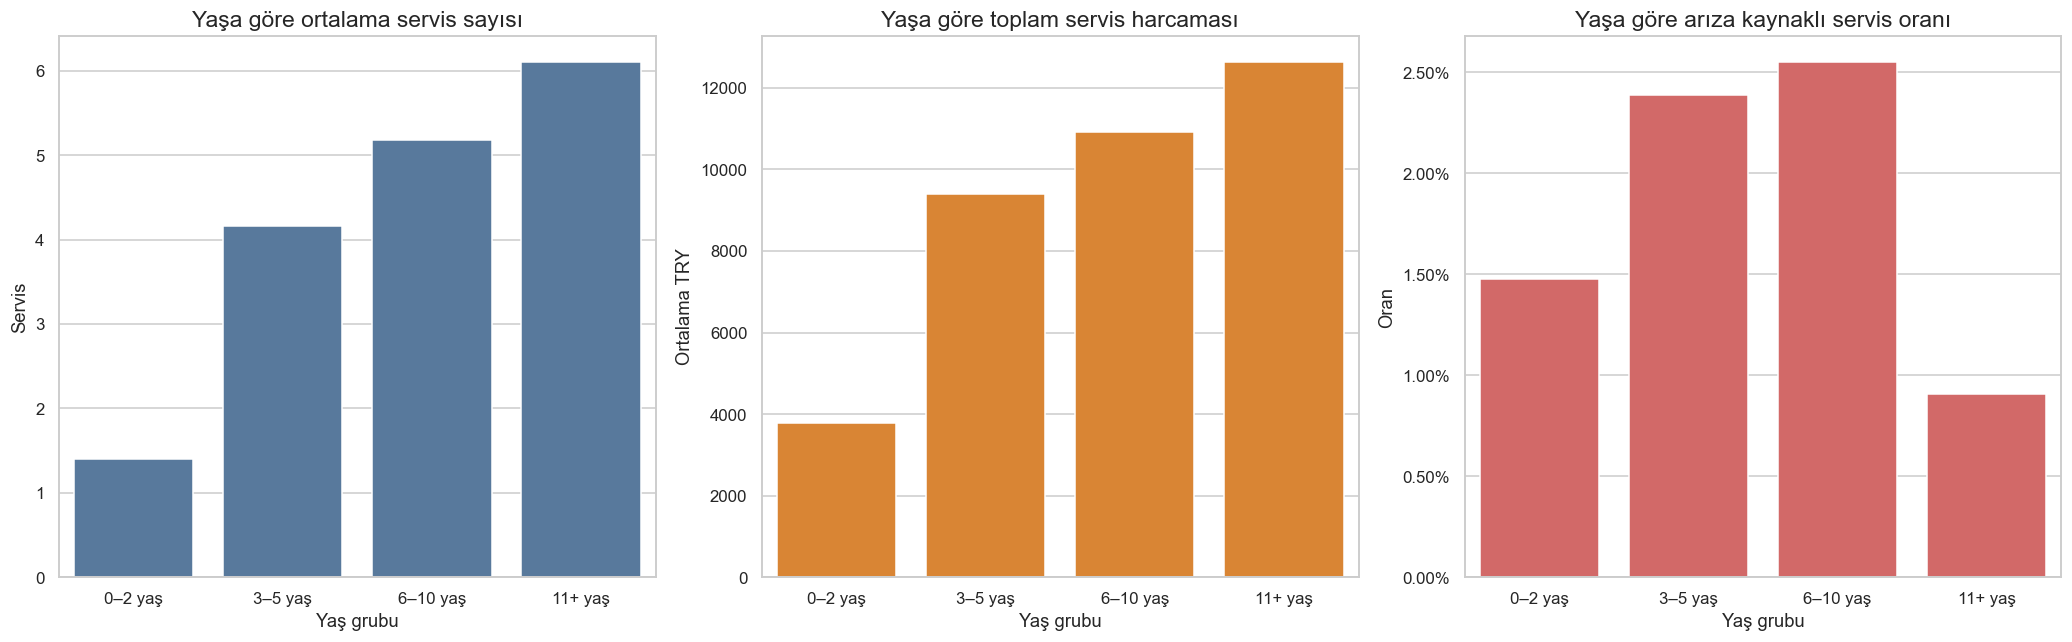

,age_group,motorcycle_count,avg_service_count,avg_total_spend,breakdown_rate
0,0–2 yaş,1563,1.40,3793.79,0.01
1,3–5 yaş,4356,4.16,9389.74,0.02
2,6–10 yaş,4006,5.18,10905.09,0.03
3,11+ yaş,75,6.11,12641.01,0.01


In [33]:
age_analysis = motorcycle_segment.copy()
age_analysis["motorcycle_age"] = 2026 - age_analysis["production_year"]
age_analysis["age_group"] = pd.cut(age_analysis["motorcycle_age"], bins=[-1, 2, 5, 10, 100], labels=["0–2 yaş", "3–5 yaş", "6–10 yaş", "11+ yaş"])
age_summary = age_analysis.groupby("age_group", observed=False).agg(
    motorcycle_count=("motorcycle_id", "nunique"),
    avg_service_count=("service_count", "mean"),
    avg_total_spend=("total_service_spend", "mean"),
    breakdown_rate=("breakdown_rate", "mean"),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
sns.barplot(data=age_summary, x="age_group", y="avg_service_count", ax=axes[0], color="#4C78A8")
sns.barplot(data=age_summary, x="age_group", y="avg_total_spend", ax=axes[1], color="#F58518")
sns.barplot(data=age_summary, x="age_group", y="breakdown_rate", ax=axes[2], color="#E45756")
axes[0].set(title="Yaşa göre ortalama servis sayısı", xlabel="Yaş grubu", ylabel="Servis")
axes[1].set(title="Yaşa göre toplam servis harcaması", xlabel="Yaş grubu", ylabel="Ortalama TRY")
axes[2].set(title="Yaşa göre arıza kaynaklı servis oranı", xlabel="Yaş grubu", ylabel="Oran"); axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(1))
finish_plot(fig, "24_motorcycle_age_behavior.png")
display(age_summary.round(2))

### Grafik ne anlatıyor?

Yaş grupları motosikletin `2026 - production_year` hesabıyla bulunan yaklaşık yaşına göre oluşturuldu. Soldaki grafik geçmiş servis sıklığını, ortadaki motosiklet başına birikmiş servis harcamasını, sağdaki ise servislerin ne kadarının **arıza nedeniyle** açıldığını gösterir. Eski motosikletin toplam harcamasının yüksek olması tek başına pahalı olduğu anlamına gelmez; daha uzun gözlem geçmişi de etkili olabilir.

## 3. Servis süreci ve teslim süresi

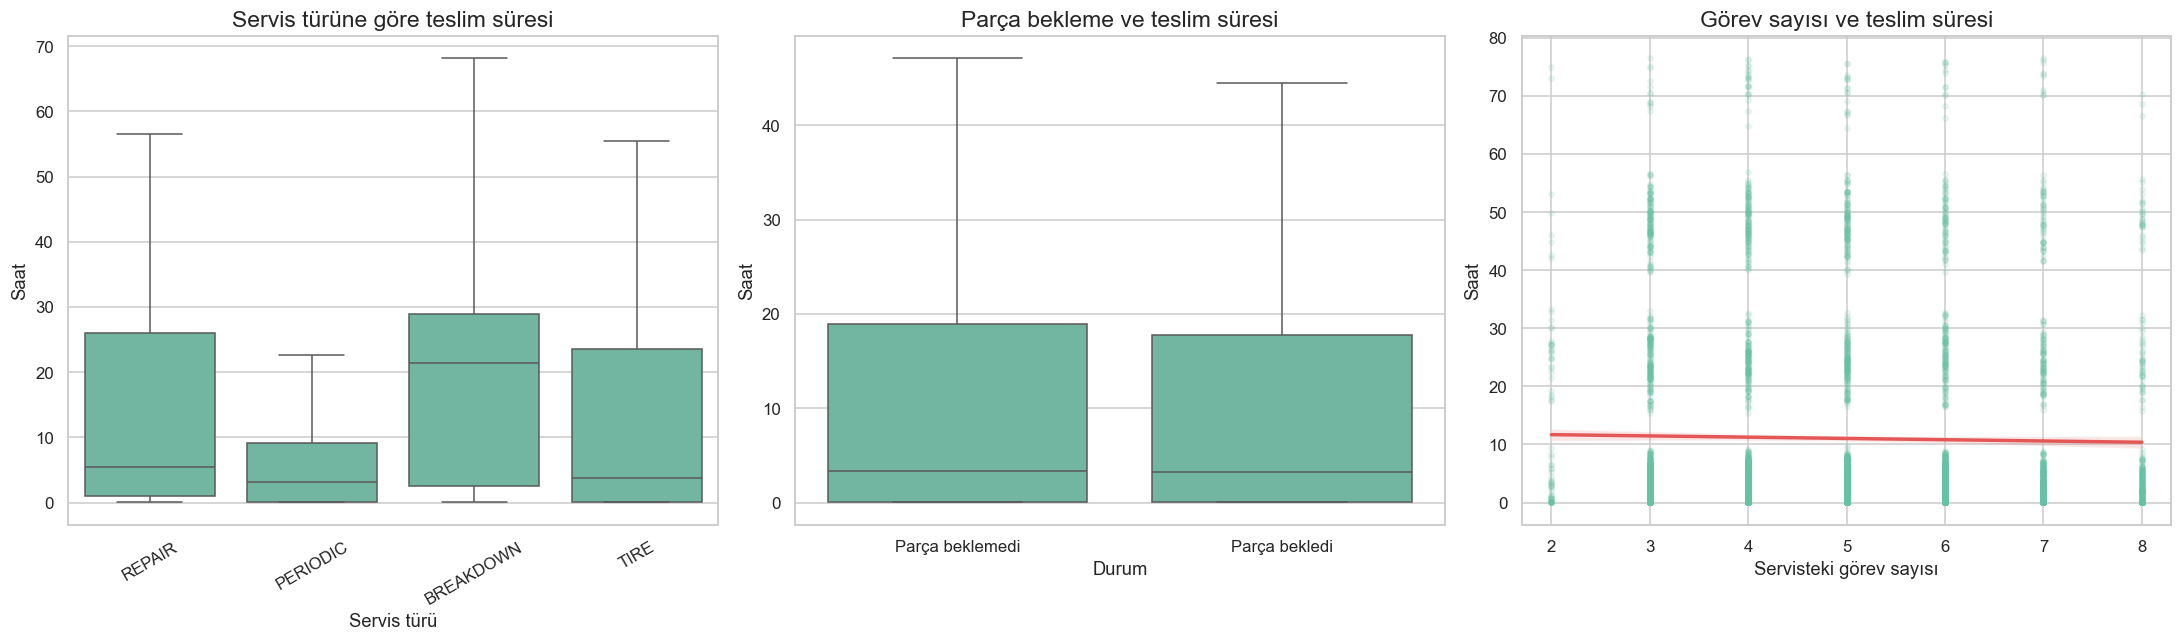

,count,median,mean
waited_for_parts,,,
Parça bekledi,22682,3.3,12.2
Parça beklemedi,18836,3.4,12.0


In [34]:
status_wide = status_times.pivot_table(index="service_id", columns="status", values="status_at", aggfunc="min")
process = service_durations[["service_id", "turnaround_hours"]].copy()
if "WAITING_PARTS" in status_wide.columns:
    process = process.merge(status_wide[["WAITING_PARTS"]].reset_index(), on="service_id", how="left")
    process["waited_for_parts"] = process["WAITING_PARTS"].notna().map({True: "Parça bekledi", False: "Parça beklemedi"})
else:
    process["waited_for_parts"] = "Parça beklemedi"
task_per_service = df_service_tasks.groupby("service_id").size().rename("task_count").reset_index()
process = process.merge(task_per_service, on="service_id", how="left").merge(
    services_eda[["service_id", "service_type_code"]], on="service_id", how="left"
)
process["task_count"] = process["task_count"].fillna(0)
process_plot = process[process["turnaround_hours"].between(0, process["turnaround_hours"].quantile(.99))].copy()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.boxplot(data=process_plot, x="service_type_code", y="turnaround_hours", showfliers=False, ax=axes[0])
sns.boxplot(data=process_plot, x="waited_for_parts", y="turnaround_hours", showfliers=False, ax=axes[1])
sns.regplot(data=process_plot.sample(min(5000, len(process_plot)), random_state=42), x="task_count", y="turnaround_hours", scatter_kws={"alpha":.12,"s":12}, line_kws={"color":"#E45756"}, ax=axes[2])
axes[0].set(title="Servis türüne göre teslim süresi", xlabel="Servis türü", ylabel="Saat"); axes[0].tick_params(axis="x", rotation=30)
axes[1].set(title="Parça bekleme ve teslim süresi", xlabel="Durum", ylabel="Saat")
axes[2].set(title="Görev sayısı ve teslim süresi", xlabel="Servisteki görev sayısı", ylabel="Saat")
finish_plot(fig, "25_service_process.png")
display(process.groupby("waited_for_parts")["turnaround_hours"].agg(["count", "median", "mean"]).round(1))

### Grafik ne anlatıyor?

`turnaround_hours`, motosikletin servise kabul edilmesi (`RECEIVED`) ile teslim edilmesi (`DELIVERED`) arasındaki süredir. Kutu yukarıdaysa o grupta teslim daha uzun sürer. **Parça bekledi** grubu, durum geçmişinde `WAITING_PARTS` kaydı bulunan servislerdir. Sağdaki çizgi görev sayısı arttığında sürenin genel olarak nasıl değiştiğini gösterir.

## 4. Servis maliyeti ilişkileri

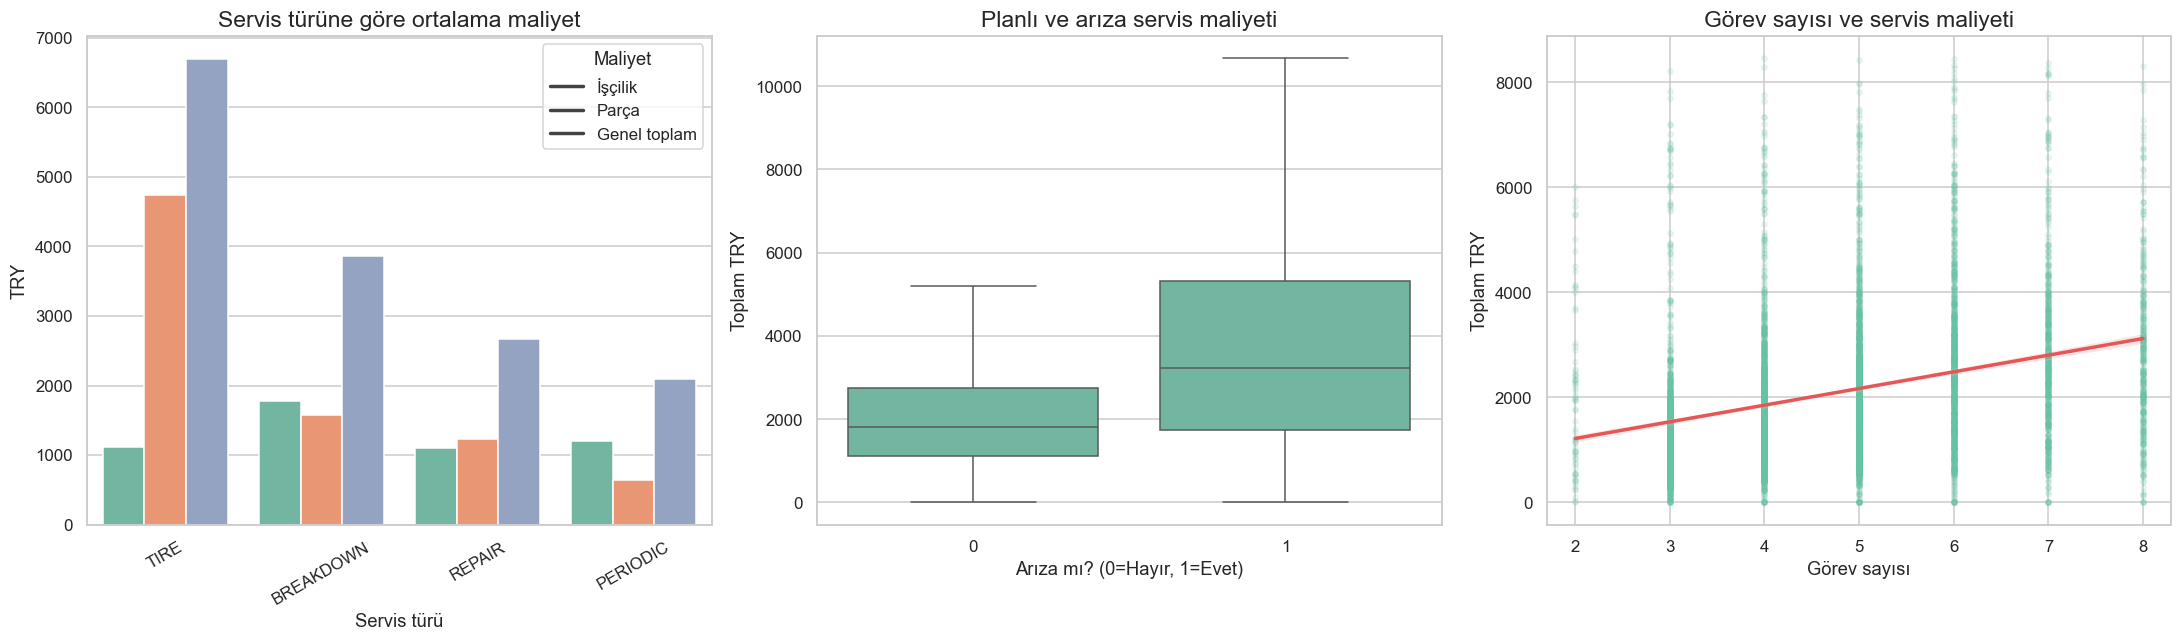

,service_type_code,service_count,avg_labor,avg_parts,avg_total
3,TIRE,435,1110.92,4744.43,6693.64
0,BREAKDOWN,993,1778.57,1573.79,3861.59
2,REPAIR,1159,1106.71,1237.80,2668.54
1,PERIODIC,38931,1202.01,646.05,2096.69


In [35]:
service_cost = services_eda.merge(task_per_service, on="service_id", how="left")
service_cost["task_count"] = service_cost["task_count"].fillna(0)
cost_by_type = service_cost.groupby("service_type_code").agg(
    service_count=("service_id", "nunique"), avg_labor=("labor_total", "mean"), avg_parts=("parts_total", "mean"), avg_total=("grand_total", "mean")
).reset_index().sort_values("avg_total", ascending=False)
cost_long = cost_by_type.melt(id_vars=["service_type_code", "service_count"], value_vars=["avg_labor", "avg_parts", "avg_total"], var_name="cost_type", value_name="TRY")
cost_sample = service_cost[service_cost["grand_total"].le(service_cost["grand_total"].quantile(.99))].sample(min(6000, len(service_cost)), random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.barplot(data=cost_long, x="service_type_code", y="TRY", hue="cost_type", ax=axes[0])
sns.boxplot(data=service_cost, x="is_breakdown", y="grand_total", showfliers=False, ax=axes[1])
sns.regplot(data=cost_sample, x="task_count", y="grand_total", scatter_kws={"alpha":.12,"s":12}, line_kws={"color":"#E45756"}, ax=axes[2])
axes[0].set(title="Servis türüne göre ortalama maliyet", xlabel="Servis türü", ylabel="TRY"); axes[0].tick_params(axis="x", rotation=30); axes[0].legend(title="Maliyet", labels=["İşçilik", "Parça", "Genel toplam"])
axes[1].set(title="Planlı ve arıza servis maliyeti", xlabel="Arıza mı? (0=Hayır, 1=Evet)", ylabel="Toplam TRY")
axes[2].set(title="Görev sayısı ve servis maliyeti", xlabel="Görev sayısı", ylabel="Toplam TRY")
finish_plot(fig, "26_cost_relationships.png")
display(cost_by_type.round(2))

### Grafik ne anlatıyor?

Solda servis türlerinin ortalama işçilik, parça ve nihai fatura tutarları karşılaştırılır. Ortadaki `0`, planlı/arıza dışı; `1`, arıza kaynaklı servistir. Sağdaki eğilim çizgisi görev sayısı arttıkça faturanın genel yönünü gösterir. Bu ilişki korelasyondur; görevin türü ve kullanılan parçanın fiyatı da maliyeti belirler.

## 5. Bakım görevleri

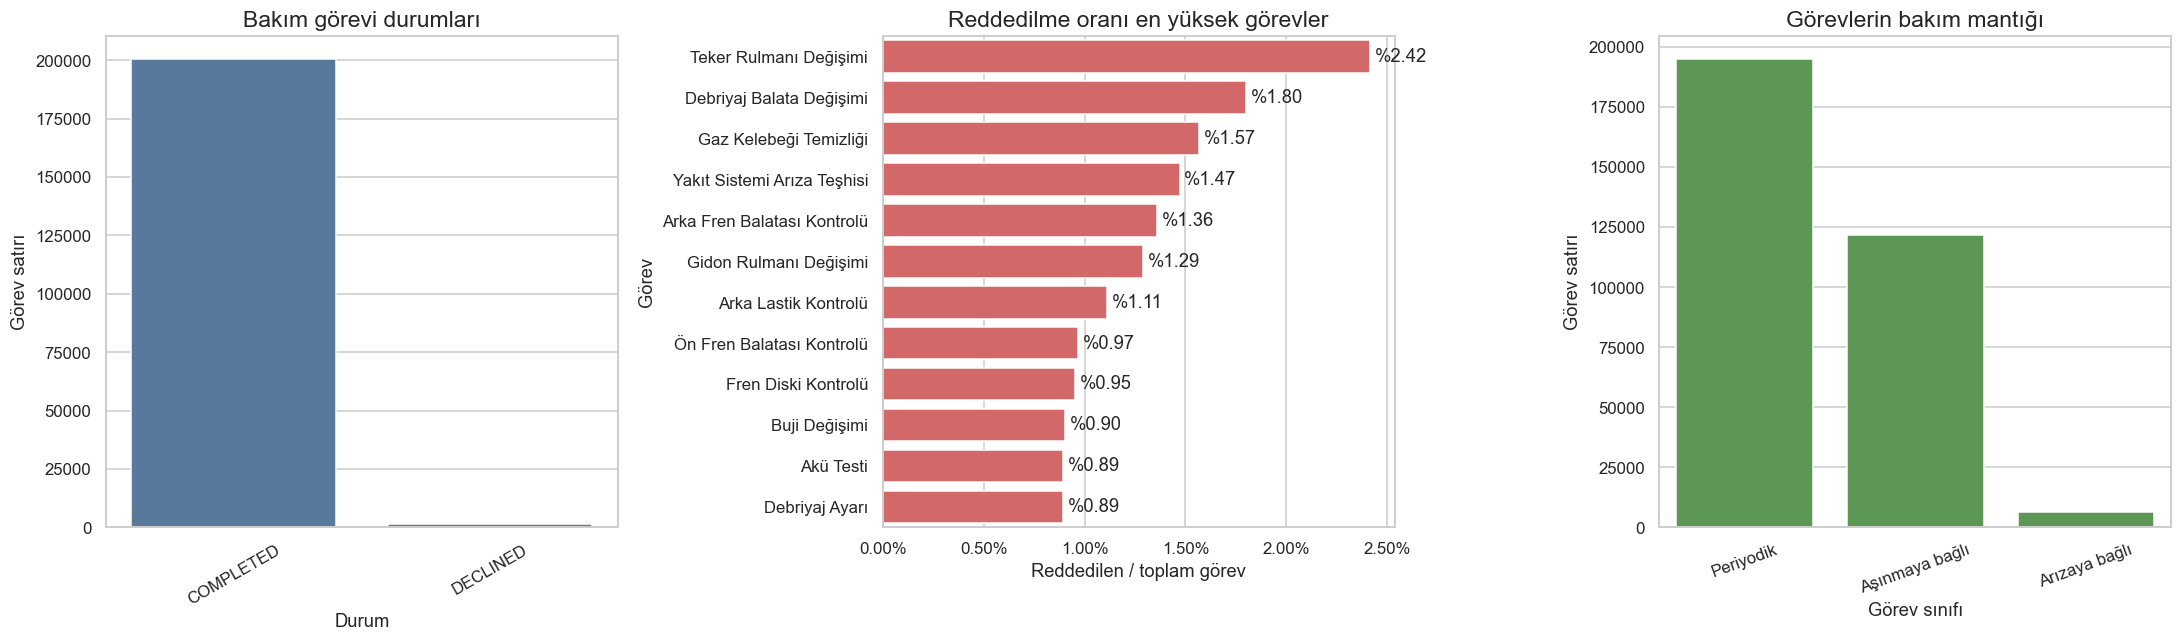

,status,count
0,COMPLETED,200385
1,DECLINED,1415


,görev_kodu,görev,toplam_görev,reddedilen,reddedilme_oranı
59,WHEEL_BEARING_CHANGE,Teker Rulmanı Değişimi,414,10,2.42%
17,CLUTCH_PLATE_CHANGE,Debriyaj Balata Değişimi,111,2,1.80%
55,THROTTLE_BODY_CLEAN,Gaz Kelebeği Temizliği,383,6,1.57%
42,FUEL_SYSTEM_DIAGNOSTIC,Yakıt Sistemi Arıza Teşhisi,204,3,1.47%
47,REAR_BRAKE_PAD_INSPECTION,Arka Fren Balatası Kontrolü,1470,20,1.36%
52,STEERING_BEARING_CHANGE,Gidon Rulmanı Değişimi,387,5,1.29%
49,REAR_TIRE_INSPECTION,Arka Lastik Kontrolü,1706,19,1.11%
36,FRONT_BRAKE_PAD_INSPECTION,Ön Fren Balatası Kontrolü,3814,37,0.97%
7,BRAKE_DISC_INSPECTION,Fren Diski Kontrolü,210,2,0.95%
50,SPARK_PLUG_CHANGE,Buji Değişimi,2101,19,0.90%


In [36]:
task_detail = df_service_tasks.merge(
    df_maintenance_tasks[["task_code", "canonical_name_tr", "component_group", "is_periodic", "is_wear_based", "is_fault_based"]],
    on="task_code",
    how="left",
    suffixes=("", "_catalog"),
)
task_status = task_detail["status"].value_counts().rename_axis("status").reset_index(name="count")

# Ham reddedilme sayısı yerine her görevin kendi içindeki reddedilme oranı.
task_detail["is_declined"] = task_detail["status"].astype(str).str.contains("DECLIN", case=False, na=False)
decline_rates = (
    task_detail.groupby(["task_code", "canonical_name_tr"], dropna=False)
    .agg(total_task_count=("service_task_id", "size"), declined_count=("is_declined", "sum"))
    .reset_index()
)
decline_rates["decline_rate"] = decline_rates["declined_count"] / decline_rates["total_task_count"]

# Çok küçük örneklerin tesadüfen en üstte görünmesini önlemek için en az 100 görev satırı.
MIN_TASK_COUNT_FOR_RATE = 100
declined = (
    decline_rates.query("total_task_count >= @MIN_TASK_COUNT_FOR_RATE")
    .sort_values(["decline_rate", "declined_count"], ascending=False)
    .head(12)
    .rename(columns={"canonical_name_tr": "task"})
)

task_classes = pd.DataFrame({
    "Sınıf": ["Periyodik", "Aşınmaya bağlı", "Arızaya bağlı"],
    "Görev satırı": [
        task_detail["is_periodic"].fillna(0).sum(),
        task_detail["is_wear_based"].fillna(0).sum(),
        task_detail["is_fault_based"].fillna(0).sum(),
    ],
})

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.barplot(data=task_status, x="status", y="count", ax=axes[0], color="#4C78A8")
if len(declined):
    sns.barplot(data=declined, x="decline_rate", y="task", ax=axes[1], color="#E45756")
    axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1))
    for container in axes[1].containers:
        axes[1].bar_label(container, labels=[f"%{value * 100:.2f}" for value in declined["decline_rate"]], padding=3)
else:
    axes[1].text(.5, .5, "Yeterli örneği olan reddedilmiş görev yok", ha="center", va="center")
sns.barplot(data=task_classes, x="Sınıf", y="Görev satırı", ax=axes[2], color="#54A24B")
axes[0].set(title="Bakım görevi durumları", xlabel="Durum", ylabel="Görev satırı"); axes[0].tick_params(axis="x", rotation=30)
axes[1].set(title="Reddedilme oranı en yüksek görevler", xlabel="Reddedilen / toplam görev", ylabel="Görev")
axes[2].set(title="Görevlerin bakım mantığı", xlabel="Görev sınıfı", ylabel="Görev satırı"); axes[2].tick_params(axis="x", rotation=20)
finish_plot(fig, "27_maintenance_tasks.png")

display(
    task_status,
    declined[["task_code", "task", "total_task_count", "declined_count", "decline_rate"]]
    .rename(columns={
        "task_code": "görev_kodu",
        "task": "görev",
        "total_task_count": "toplam_görev",
        "declined_count": "reddedilen",
        "decline_rate": "reddedilme_oranı",
    })
    .style.format({"reddedilme_oranı": "{:.2%}"})
)


### Grafik ne anlatıyor?

- **Periyodik:** Belirli kilometre veya zaman aralığında yapılması planlanan bakım.
- **Aşınmaya bağlı:** Balata veya lastik gibi kullanım sonucunda yıpranan parçaya bağlı işlem.
- **Arızaya bağlı:** Bir hata veya bozulma tespit edildiğinde yapılan işlem.

Ortadaki grafik artık ham reddedilme sayısını değil, her görevin kendi içindeki **reddedilme yüzdesini** gösterir:

`reddedilme oranı = reddedilen görev sayısı / o görevin toplam görülme sayısı`

Örneğin `%1,20`, o görev 1.000 kez önerildiyse yaklaşık 12 kez reddedildi demektir. Az gözlenen görevlerin tesadüfen yüksek oranla listenin başına çıkmaması için yalnızca **en az 100 kez görülen görevler** sıralamaya alınmıştır.

Reddedilen görev, müşteriye önerildiği halde o servis ziyaretinde yapılmamış işlemdir; görevin gereksiz olduğu anlamına gelmez.

## 6. Birlikte yapılan görevler

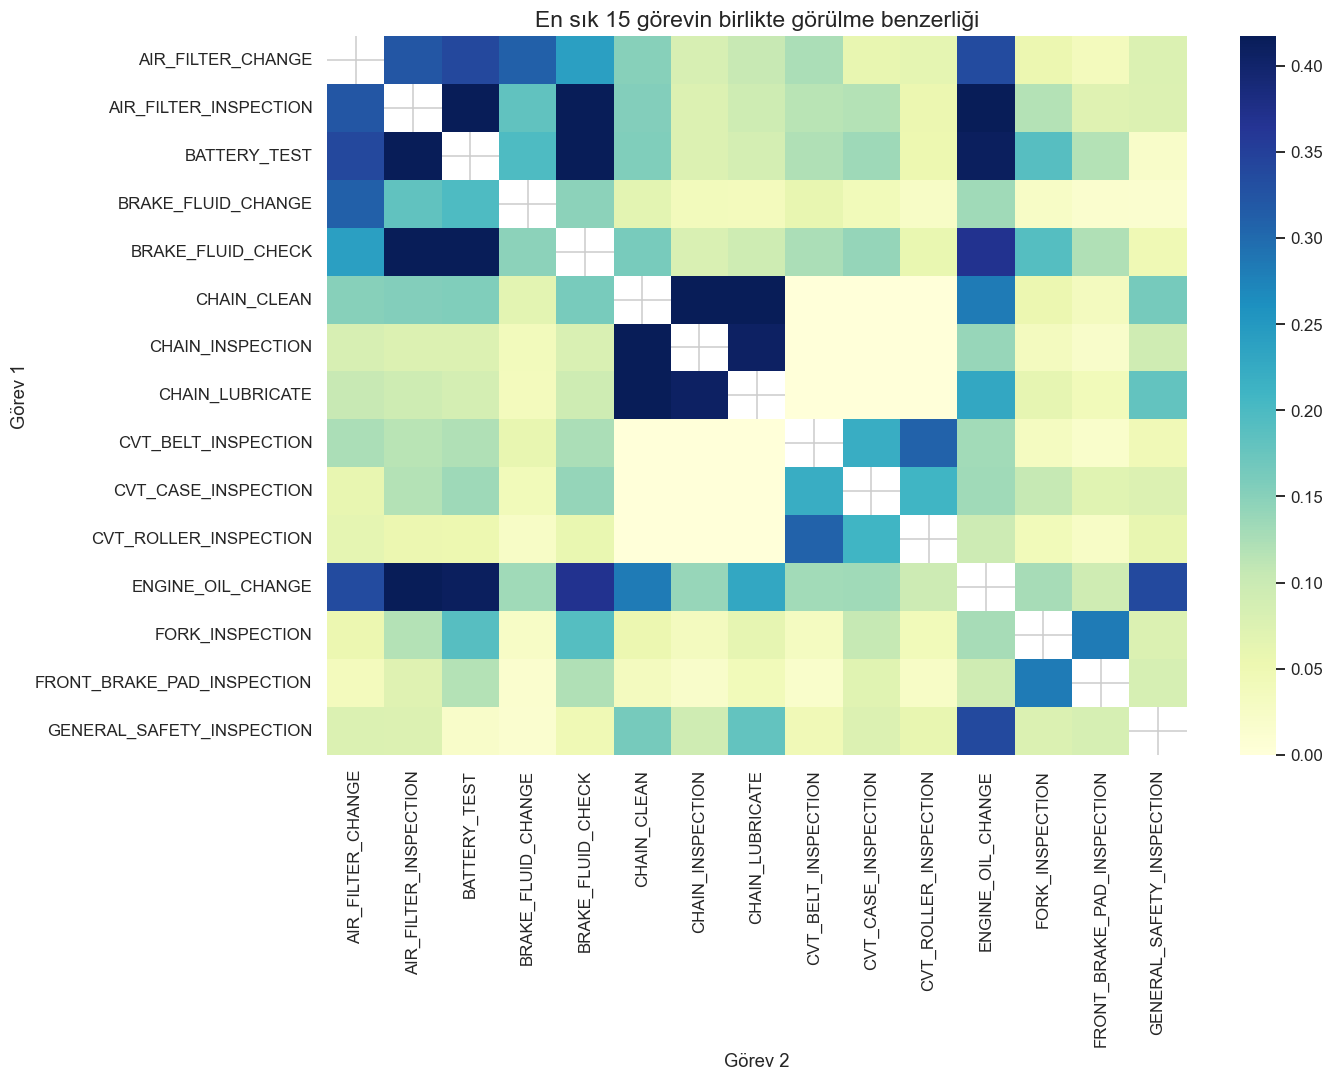

,task_1,task_2,jaccard_score
0,CHAIN_CLEAN,CHAIN_LUBRICATE,0.684
1,BATTERY_TEST,BRAKE_FLUID_CHECK,0.648
2,AIR_FILTER_INSPECTION,BATTERY_TEST,0.565
3,AIR_FILTER_INSPECTION,BRAKE_FLUID_CHECK,0.441
4,CHAIN_CLEAN,CHAIN_INSPECTION,0.430
5,AIR_FILTER_INSPECTION,ENGINE_OIL_CHANGE,0.417
6,BATTERY_TEST,ENGINE_OIL_CHANGE,0.412
7,CHAIN_INSPECTION,CHAIN_LUBRICATE,0.406
8,BRAKE_FLUID_CHECK,ENGINE_OIL_CHANGE,0.369
9,AIR_FILTER_CHANGE,BATTERY_TEST,0.339


In [37]:
top_task_codes = df_service_tasks["task_code"].value_counts().head(15).index
task_matrix = (df_service_tasks[df_service_tasks["task_code"].isin(top_task_codes)].assign(value=1).pivot_table(index="service_id", columns="task_code", values="value", aggfunc="max", fill_value=0))
intersection = task_matrix.T.dot(task_matrix)
counts = task_matrix.sum()
union = counts.to_numpy()[:, None] + counts.to_numpy()[None, :] - intersection.to_numpy()
jaccard = pd.DataFrame(intersection.to_numpy() / union, index=intersection.index, columns=intersection.columns)
jaccard.index.name = "task_1"
jaccard.columns.name = "task_2"
np.fill_diagonal(jaccard.values, np.nan)
upper_i, upper_j = np.triu_indices_from(jaccard.values, k=1)
pairs = pd.DataFrame({
    "task_1": jaccard.index.to_numpy()[upper_i],
    "task_2": jaccard.columns.to_numpy()[upper_j],
    "jaccard_score": jaccard.values[upper_i, upper_j],
}).sort_values("jaccard_score", ascending=False).head(15).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(jaccard, cmap="YlGnBu", vmin=0, vmax=np.nanquantile(jaccard.values, .95), ax=ax)
ax.set_title("En sık 15 görevin birlikte görülme benzerliği")
ax.set_xlabel("Görev 2"); ax.set_ylabel("Görev 1")
finish_plot(fig, "28_task_association.png")
display(pairs.round(3))

### Grafik ne anlatıyor?

Her kare iki bakım görevinin aynı servislerde ne ölçüde birlikte görüldüğünü gösterir. Açık renk zayıf, koyu renk güçlü birlikteliktir. Kullanılan **Jaccard skoru** 0–1 arasındadır: `0` hiç birlikte değiller, `1` her zaman aynı servislerde görülüyorlar. Bu analiz paket bakım önerisi ve çoklu hedef modellemesi için yararlıdır; biri diğerine neden oluyor demek değildir.

## 7. Parça kullanımı ve fiyatları

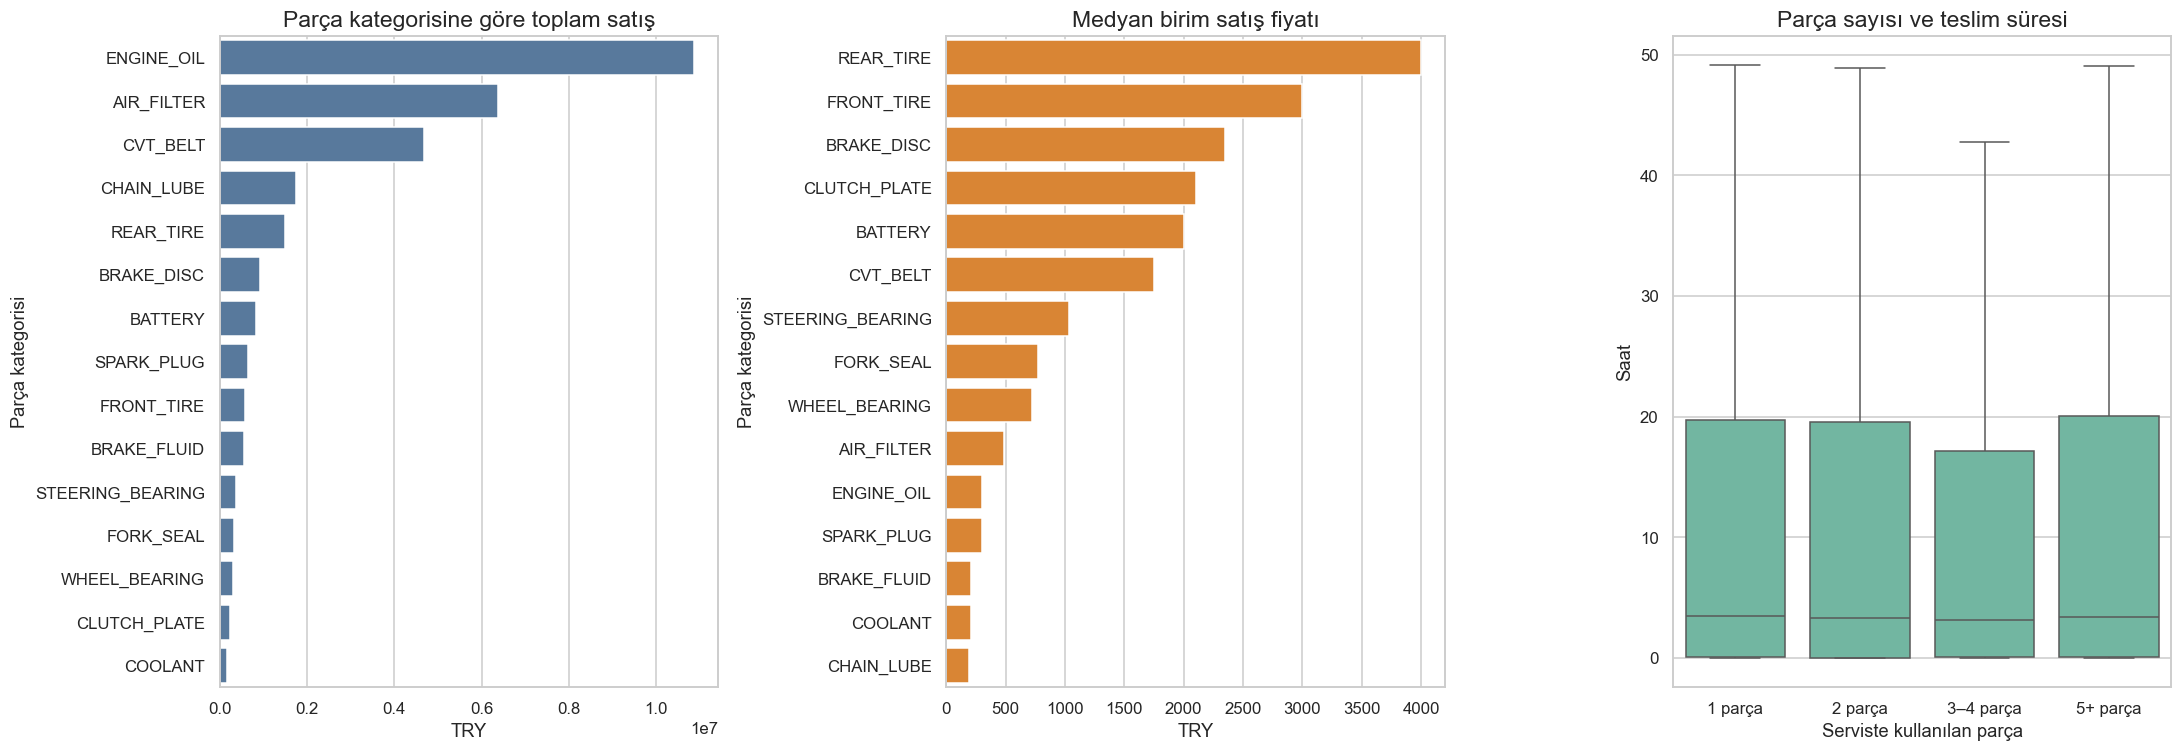

,part_category,part_rows,median_unit_price,total_sales
0,ENGINE_OIL,38734,300.0,10870669.5
1,AIR_FILTER,13002,490.0,6373185.0
2,CVT_BELT,2681,1750.0,4673865.0
3,CHAIN_LUBE,8818,190.0,1739790.0
4,REAR_TIRE,362,4000.0,1490900.0
5,BRAKE_DISC,390,2350.0,921750.0
6,BATTERY,398,2000.0,824590.0
7,SPARK_PLUG,2082,300.0,641070.0
8,FRONT_TIRE,192,3000.0,572925.0
9,BRAKE_FLUID,5109,210.0,551630.0


In [38]:
parts_eda = df_service_parts.copy()
parts_eda["unit_sale_price"] = pd.to_numeric(parts_eda["unit_sale_price"], errors="coerce")
parts_eda["sale_total"] = pd.to_numeric(parts_eda["sale_total"], errors="coerce")
part_prices = parts_eda.groupby("part_category").agg(part_rows=("service_part_id", "size"), median_unit_price=("unit_sale_price", "median"), total_sales=("sale_total", "sum")).query("part_rows >= 50").sort_values("total_sales", ascending=False).head(15).reset_index()
parts_with_time = parts_eda.groupby("service_id").agg(part_count=("service_part_id", "size"), part_sales=("sale_total", "sum")).reset_index().merge(process[["service_id", "turnaround_hours", "waited_for_parts"]], on="service_id", how="left")
parts_with_time["part_count_group"] = pd.cut(parts_with_time["part_count"], bins=[0,1,2,4,100], labels=["1 parça","2 parça","3–4 parça","5+ parça"])

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
sns.barplot(data=part_prices, x="total_sales", y="part_category", ax=axes[0], color="#4C78A8")
sns.barplot(data=part_prices.sort_values("median_unit_price", ascending=False), x="median_unit_price", y="part_category", ax=axes[1], color="#F58518")
sns.boxplot(data=parts_with_time, x="part_count_group", y="turnaround_hours", showfliers=False, ax=axes[2])
axes[0].set(title="Parça kategorisine göre toplam satış", xlabel="TRY", ylabel="Parça kategorisi")
axes[1].set(title="Medyan birim satış fiyatı", xlabel="TRY", ylabel="Parça kategorisi")
axes[2].set(title="Parça sayısı ve teslim süresi", xlabel="Serviste kullanılan parça", ylabel="Saat")
finish_plot(fig, "29_parts_analysis.png")
display(part_prices.round(2))

### Grafik ne anlatıyor?

`unit_sale_price` tek bir parçanın müşteriye satış fiyatıdır; `sale_total` miktar ile birim fiyatın toplamıdır. Solda kategori bazında ciro, ortada tipik birim fiyat, sağda serviste kullanılan parça sayısıyla teslim süresi karşılaştırılır. Yüksek toplam satış hem pahalı parçadan hem de çok sayıda satıştan kaynaklanabilir.

## 8. Randevu davranışı

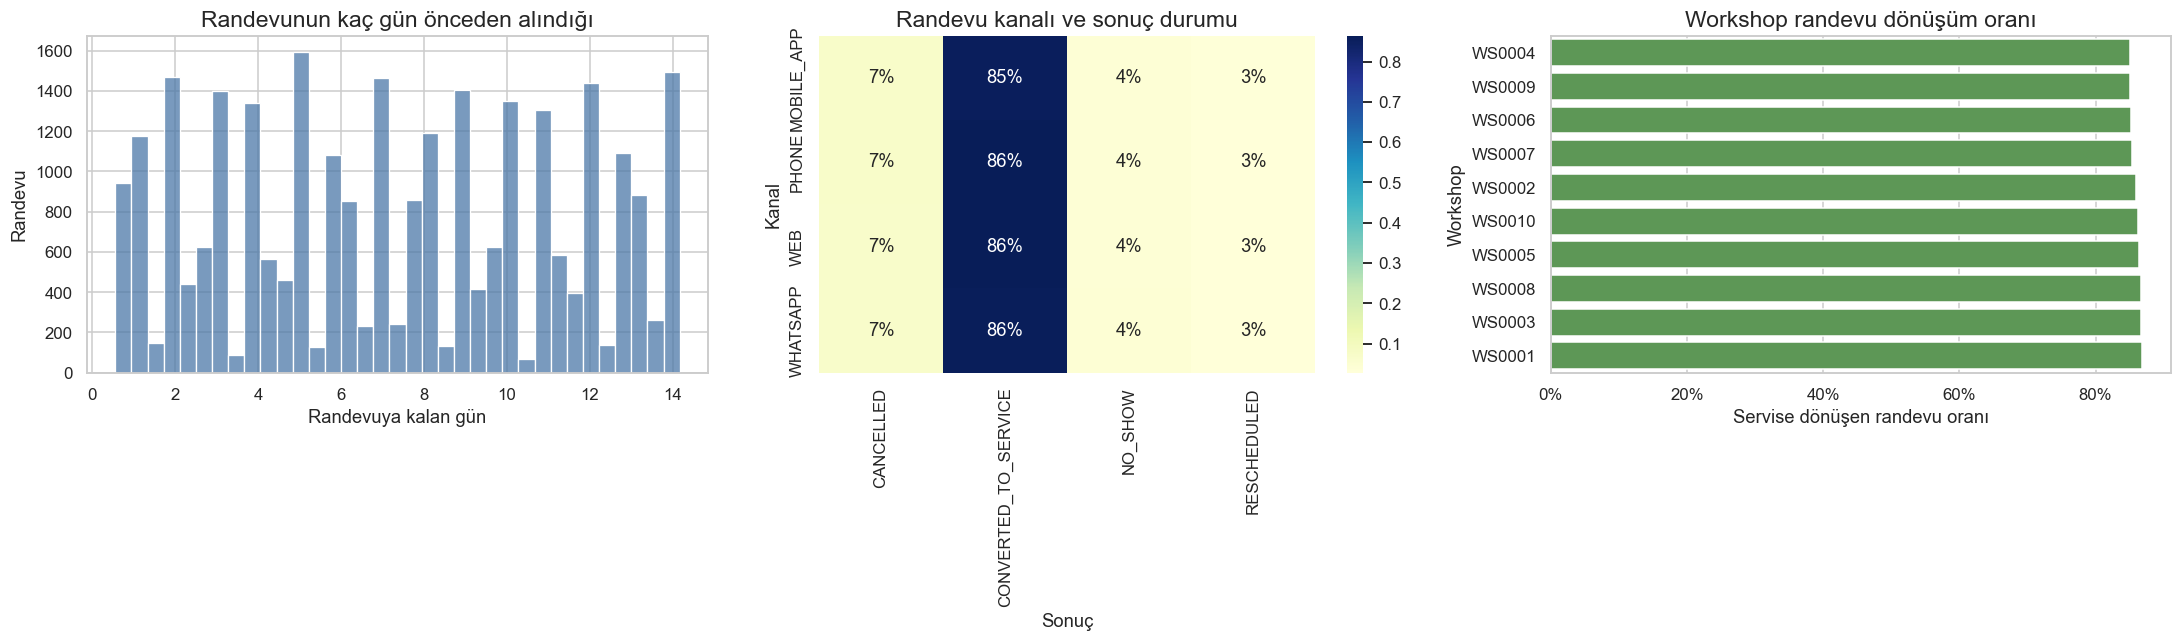

,workshop_id,appointment_count,conversion_rate,median_lead_days
0,WS0001,2387,0.868,7.223
1,WS0002,2515,0.859,7.742
2,WS0003,3136,0.867,7.075
3,WS0004,2659,0.850,7.136
4,WS0005,3699,0.863,7.181
5,WS0006,1710,0.853,7.480
6,WS0007,2927,0.854,7.751
7,WS0008,3935,0.866,7.078
8,WS0009,2267,0.850,7.903
9,WS0010,2915,0.862,7.203


In [39]:
appointments_eda = df_appointments.copy()
appointments_eda["created_at"] = pd.to_datetime(appointments_eda["created_at"], errors="coerce")
appointments_eda["scheduled_at"] = pd.to_datetime(appointments_eda["scheduled_at"], errors="coerce")
appointments_eda["lead_days"] = (appointments_eda["scheduled_at"] - appointments_eda["created_at"]).dt.total_seconds()/86400
appointments_eda = appointments_eda[appointments_eda["lead_days"].ge(0)].copy()
source_status = pd.crosstab(appointments_eda["source"], appointments_eda["status"], normalize="index")
lead_limit = appointments_eda["lead_days"].quantile(.99)
workshop_appt = appointments_eda.assign(converted=appointments_eda["status"].eq("CONVERTED_TO_SERVICE")).groupby("workshop_id").agg(appointment_count=("appointment_id","size"), conversion_rate=("converted","mean"), median_lead_days=("lead_days","median")).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.histplot(appointments_eda.loc[appointments_eda["lead_days"].le(lead_limit), "lead_days"], bins=35, ax=axes[0], color="#4C78A8")
sns.heatmap(source_status, annot=True, fmt=".0%", cmap="YlGnBu", ax=axes[1])
sns.barplot(data=workshop_appt.sort_values("conversion_rate"), x="conversion_rate", y="workshop_id", ax=axes[2], color="#54A24B")
axes[0].set(title="Randevunun kaç gün önceden alındığı", xlabel="Randevuya kalan gün", ylabel="Randevu")
axes[1].set(title="Randevu kanalı ve sonuç durumu", xlabel="Sonuç", ylabel="Kanal")
axes[2].set(title="Workshop randevu dönüşüm oranı", xlabel="Servise dönüşen randevu oranı", ylabel="Workshop"); axes[2].xaxis.set_major_formatter(mtick.PercentFormatter(1))
finish_plot(fig, "30_appointment_behavior.png")
display(workshop_appt.round(3))

### Grafik ne anlatıyor?

**Lead time**, randevunun oluşturulması ile planlanan servis zamanı arasındaki gündür. Isı haritasında her satır bir başvuru kanalının (`WEB`, `PHONE` vb.) kendi içindeki sonuç yüzdelerini verir. **Dönüşüm**, randevunun gerçek bir servis kaydına dönüşmesidir; iptal ve gelmeme dönüşüm sayılmaz.

## 9. Arıza ve garanti analizi

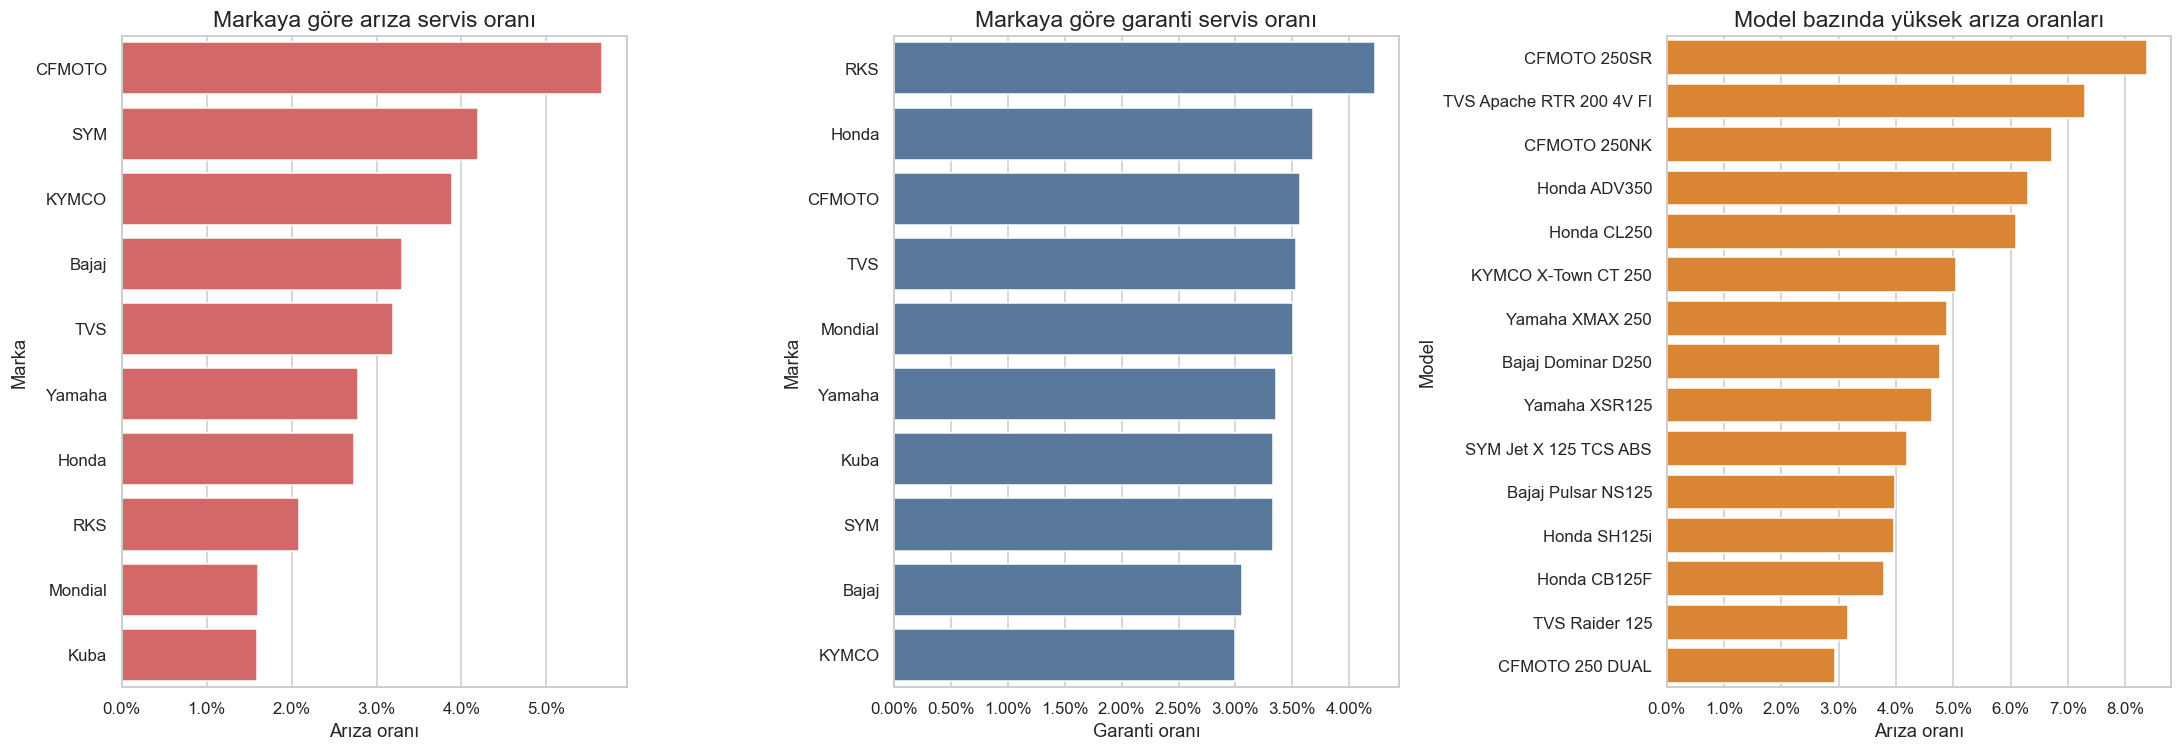

,brand,service_count,breakdown_rate,warranty_rate,avg_cost
1,CFMOTO,954,0.057,0.036,2480.145
7,SYM,691,0.042,0.033,2428.691
3,KYMCO,334,0.039,0.030,2361.211
0,Bajaj,1241,0.033,0.031,2193.221
8,TVS,3228,0.032,0.035,2396.582
9,Yamaha,3697,0.028,0.034,2359.894
2,Honda,12152,0.027,0.037,2239.931
6,RKS,2011,0.021,0.042,2252.472
5,Mondial,10091,0.016,0.035,1914.780
4,Kuba,6932,0.016,0.033,2298.608


In [40]:
reliability = services_eda.merge(df_motorcycles[["motorcycle_id", "brand", "model_name", "production_year"]], on="motorcycle_id", how="left")
reliability["motorcycle_age"] = reliability["received_at"].dt.year - reliability["production_year"]
brand_reliability = reliability.groupby("brand").agg(service_count=("service_id","nunique"), breakdown_rate=("is_breakdown","mean"), warranty_rate=("is_warranty","mean"), avg_cost=("grand_total","mean")).query("service_count >= 300").reset_index()
model_reliability = reliability.groupby(["brand","model_name"]).agg(service_count=("service_id","nunique"), breakdown_rate=("is_breakdown","mean")).query("service_count >= 100").sort_values("breakdown_rate", ascending=False).head(15).reset_index()
model_reliability["model"] = model_reliability["brand"] + " " + model_reliability["model_name"]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
sns.barplot(data=brand_reliability.sort_values("breakdown_rate", ascending=False), x="breakdown_rate", y="brand", ax=axes[0], color="#E45756")
sns.barplot(data=brand_reliability.sort_values("warranty_rate", ascending=False), x="warranty_rate", y="brand", ax=axes[1], color="#4C78A8")
sns.barplot(data=model_reliability, x="breakdown_rate", y="model", ax=axes[2], color="#F58518")
axes[0].set(title="Markaya göre arıza servis oranı", xlabel="Arıza oranı", ylabel="Marka"); axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1].set(title="Markaya göre garanti servis oranı", xlabel="Garanti oranı", ylabel="Marka"); axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[2].set(title="Model bazında yüksek arıza oranları", xlabel="Arıza oranı", ylabel="Model"); axes[2].xaxis.set_major_formatter(mtick.PercentFormatter(1))
finish_plot(fig, "31_breakdown_warranty.png")
display(brand_reliability.sort_values("breakdown_rate", ascending=False).round(3))

### Grafik ne anlatıyor?

**Arıza oranı**, bir marka/modelin servislerinin ne kadarının `is_breakdown=1` olduğunu; **garanti oranı**, ne kadarının garanti kapsamında olduğunu gösterir. Çok küçük örneklerin yanıltmaması için yalnızca en az 300 servisli markalar ve 100 servisli modeller gösterildi. Bu sentetik sonuçlar gerçek marka güvenilirliği değildir.

## 10. Workshop kapasite kullanımı

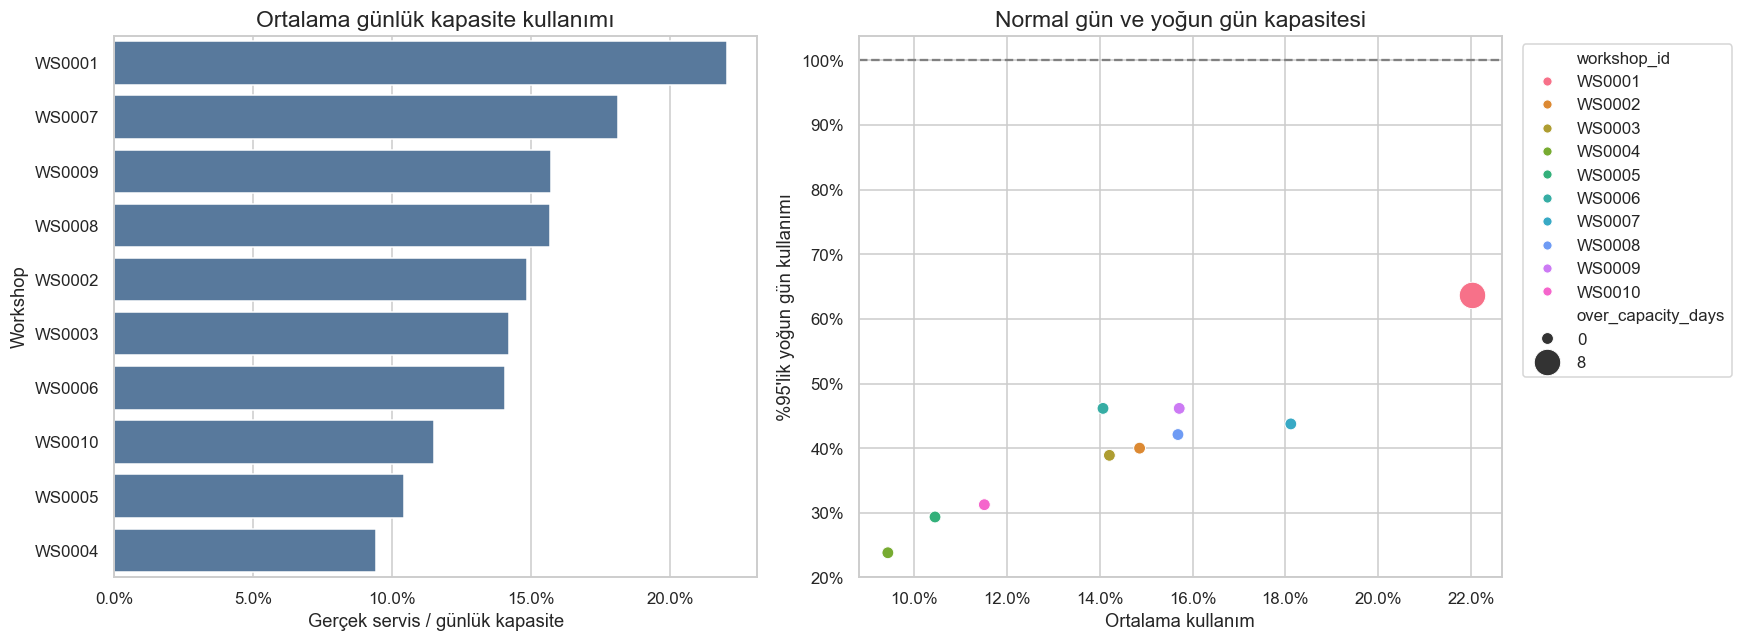

,workshop_id,avg_utilization,p95_utilization,over_capacity_days,active_days
0,WS0001,0.220,0.636,8,1436
6,WS0007,0.181,0.438,0,1429
8,WS0009,0.157,0.462,0,1272
7,WS0008,0.157,0.421,0,1439
1,WS0002,0.149,0.400,0,1311
2,WS0003,0.142,0.389,0,1377
5,WS0006,0.141,0.462,0,1330
9,WS0010,0.115,0.312,0,1225
4,WS0005,0.104,0.293,0,1364
3,WS0004,0.094,0.238,0,1265


In [41]:
daily_services = services_time.assign(service_date=services_time["received_at"].dt.normalize()).groupby(["workshop_id","service_date"]).size().rename("daily_services").reset_index()
date_range = pd.date_range(daily_services["service_date"].min(), daily_services["service_date"].max(), freq="D")
calendar = pd.MultiIndex.from_product([df_workshops["workshop_id"], date_range], names=["workshop_id","service_date"]).to_frame(index=False)
calendar["weekday"] = calendar["service_date"].dt.dayofweek
calendar = calendar.merge(df_workshops[["workshop_id","daily_service_capacity","sunday_open"]], on="workshop_id", how="left")
calendar = calendar[(calendar["weekday"] < 6) | ((calendar["weekday"] == 6) & calendar["sunday_open"].eq(1))]
calendar = calendar.merge(daily_services, on=["workshop_id","service_date"], how="left")
calendar["daily_services"] = calendar["daily_services"].fillna(0)
calendar["utilization"] = calendar["daily_services"] / calendar["daily_service_capacity"]
capacity_summary = calendar.groupby("workshop_id").agg(avg_utilization=("utilization","mean"), p95_utilization=("utilization",lambda s:s.quantile(.95)), over_capacity_days=("utilization",lambda s:(s>1).sum()), active_days=("daily_services",lambda s:(s>0).sum())).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=capacity_summary.sort_values("avg_utilization", ascending=False), x="avg_utilization", y="workshop_id", ax=axes[0], color="#4C78A8")
sns.scatterplot(data=capacity_summary, x="avg_utilization", y="p95_utilization", size="over_capacity_days", hue="workshop_id", sizes=(60,300), ax=axes[1])
axes[0].set(title="Ortalama günlük kapasite kullanımı", xlabel="Gerçek servis / günlük kapasite", ylabel="Workshop"); axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1].axhline(1, ls="--", color="gray"); axes[1].set(title="Normal gün ve yoğun gün kapasitesi", xlabel="Ortalama kullanım", ylabel="%95'lik yoğun gün kullanımı"); axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1)); axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1)); axes[1].legend(bbox_to_anchor=(1.02,1), loc="upper left")
finish_plot(fig, "32_workshop_capacity_utilization.png")
display(capacity_summary.sort_values("avg_utilization", ascending=False).round(3))

### Grafik ne anlatıyor?

Kapasite kullanımı `o gün gelen servis / günlük servis kapasitesi` olarak hesaplandı. `%100`, günlük planlanan kapasitenin tamamının kullanılmasıdır. **p95**, günlerin yalnızca en yoğun `%5` bölümünün başladığı seviyedir; yoğun gün baskısını gösterir. Buradaki kapasite yaklaşık operasyon kapasitesidir, aynı anda açık iş emri sayısı değildir.

## 11. Müşteri yaşam döngüsü

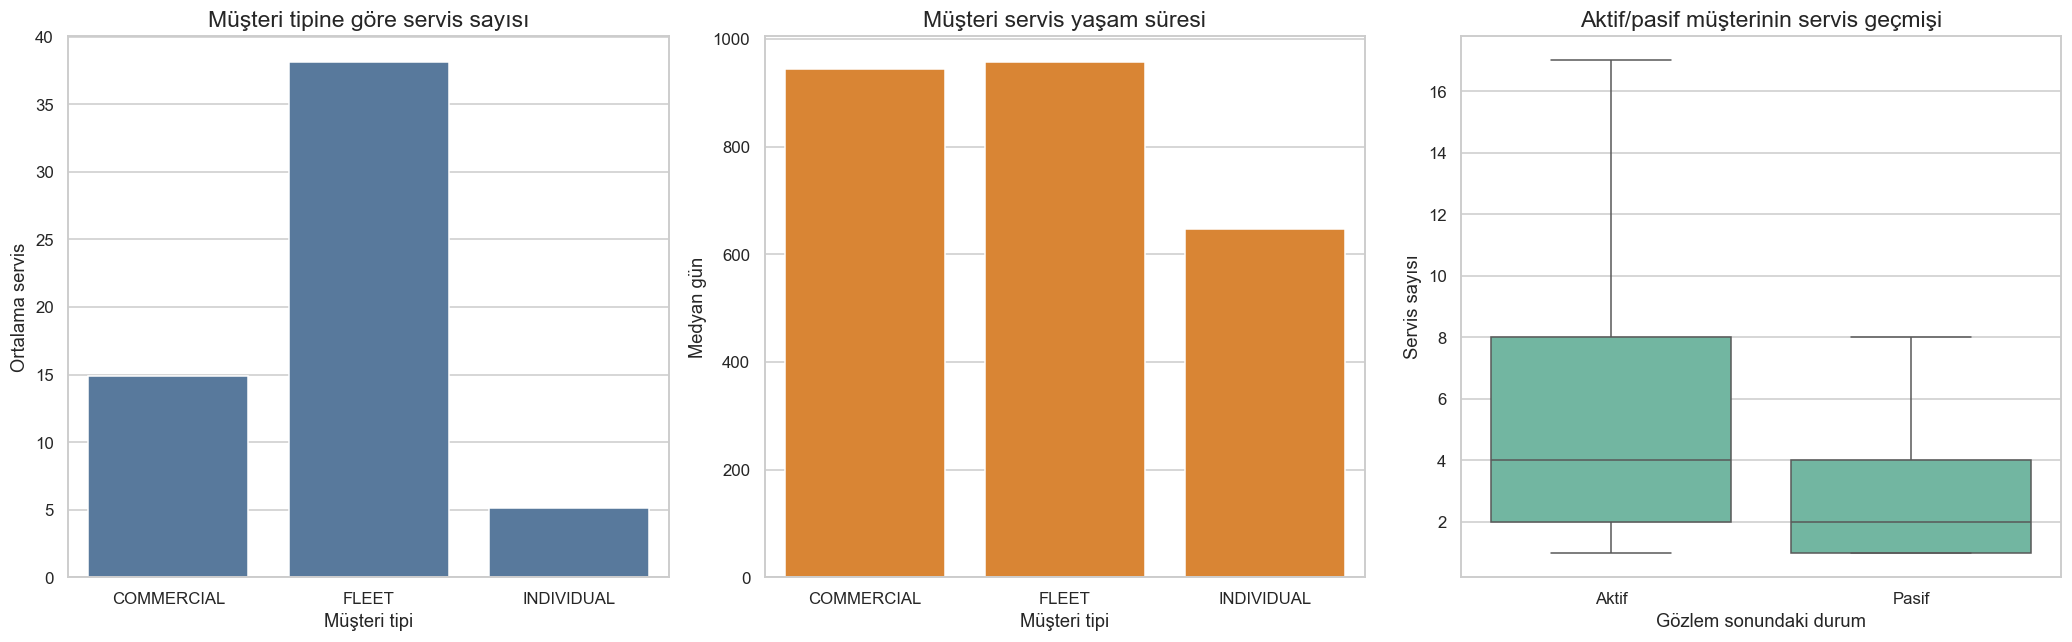

,customer_type,customer_count,avg_services,median_lifecycle_days,avg_total_spend,active_rate
0,COMMERCIAL,706,14.87,945.0,32213.72,0.94
1,FLEET,124,38.15,958.0,77837.04,0.95
2,INDIVIDUAL,6170,5.12,648.0,11487.64,0.90


In [42]:
customer_service = services_time.groupby("customer_id").agg(
    first_service=("received_at","min"), last_service=("received_at","max"), service_count=("service_id","nunique"), motorcycle_count=("motorcycle_id","nunique"), total_spend=("grand_total","sum")
).reset_index()
customer_lifecycle = df_customers[["customer_id","customer_type","first_seen_date","is_active","churn_date"]].merge(customer_service, on="customer_id", how="left")
customer_lifecycle["first_seen_date"] = pd.to_datetime(customer_lifecycle["first_seen_date"], errors="coerce")
customer_lifecycle["churn_date"] = pd.to_datetime(customer_lifecycle["churn_date"], errors="coerce")
customer_lifecycle["lifecycle_days"] = (customer_lifecycle["last_service"] - customer_lifecycle["first_service"]).dt.days.clip(lower=0)
customer_lifecycle["customer_status"] = customer_lifecycle["is_active"].map({1:"Aktif",0:"Pasif"})
lifecycle_summary = customer_lifecycle.groupby("customer_type").agg(customer_count=("customer_id","nunique"), avg_services=("service_count","mean"), median_lifecycle_days=("lifecycle_days","median"), avg_total_spend=("total_spend","mean"), active_rate=("is_active","mean")).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
sns.barplot(data=lifecycle_summary, x="customer_type", y="avg_services", ax=axes[0], color="#4C78A8")
sns.barplot(data=lifecycle_summary, x="customer_type", y="median_lifecycle_days", ax=axes[1], color="#F58518")
sns.boxplot(data=customer_lifecycle, x="customer_status", y="service_count", showfliers=False, ax=axes[2])
axes[0].set(title="Müşteri tipine göre servis sayısı", xlabel="Müşteri tipi", ylabel="Ortalama servis")
axes[1].set(title="Müşteri servis yaşam süresi", xlabel="Müşteri tipi", ylabel="Medyan gün")
axes[2].set(title="Aktif/pasif müşterinin servis geçmişi", xlabel="Gözlem sonundaki durum", ylabel="Servis sayısı")
finish_plot(fig, "33_customer_lifecycle.png")
display(lifecycle_summary.round(2))

### Grafik ne anlatıyor?

Müşteri yaşam süresi, müşterinin ilk ve son **gözlenen servisleri** arasındaki gündür. `Aktif`, veri gözlem ufkunun sonunda müşteri ilişkisinin sürdüğünü; `Pasif`, sona erdiğini gösterir. Yaşam süresinin kısa olması kesin churn nedeni değildir; müşteri veri döneminin sonuna yakın katılmış olabilir.

## 12. Müşteri cohort analizi

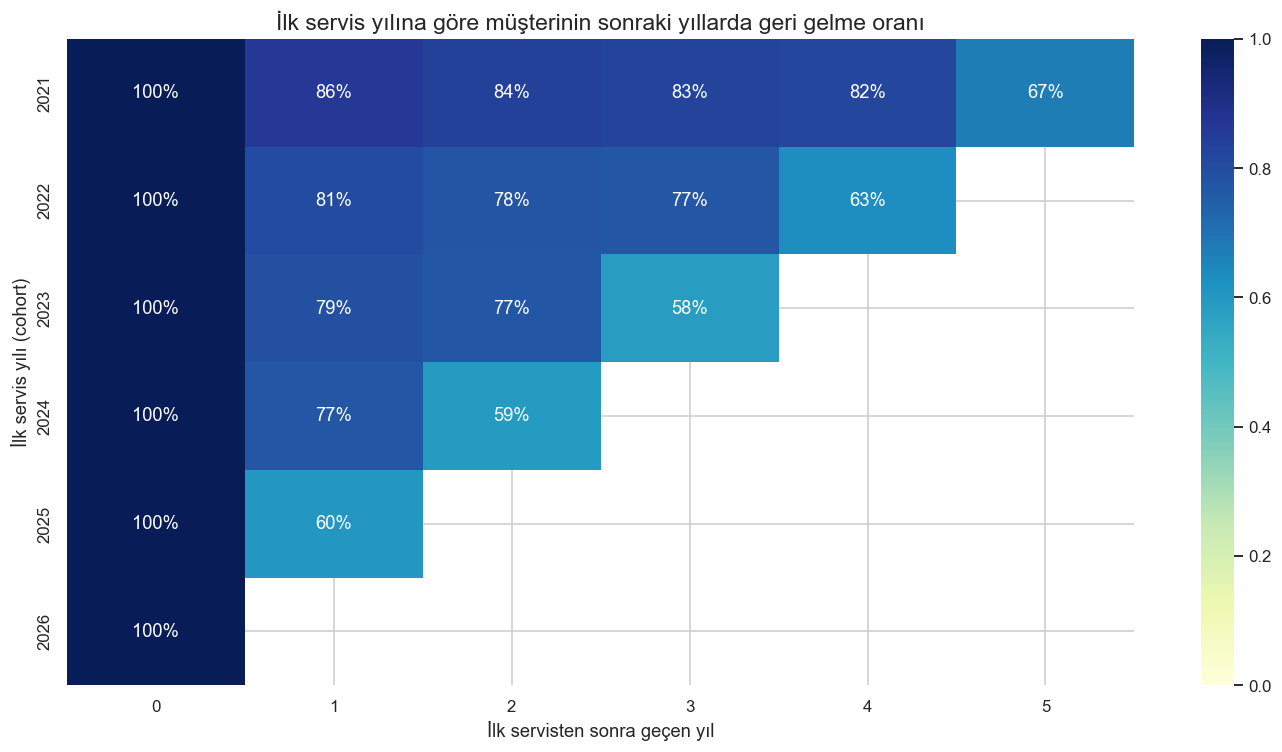

year_index,0,1,2,3,4,5
cohort_year,,,,,,
2021,607,522,507,505,496,409
2022,1221,987,947,940,769,0
2023,1259,998,971,735,0,0
2024,1237,954,732,0,0,0
2025,1147,693,0,0,0,0
2026,609,0,0,0,0,0


In [43]:
cohort_base = services_time[["customer_id","received_at"]].copy()
cohort_base["service_year"] = cohort_base["received_at"].dt.year
first_year = cohort_base.groupby("customer_id")["service_year"].min().rename("cohort_year")
cohort_base = cohort_base.join(first_year, on="customer_id")
cohort_base["year_index"] = cohort_base["service_year"] - cohort_base["cohort_year"]
cohort_counts = cohort_base.groupby(["cohort_year","year_index"])["customer_id"].nunique().unstack(fill_value=0)
cohort_sizes = cohort_counts[0]
cohort_retention = cohort_counts.div(cohort_sizes, axis=0)
last_observed_year = int(cohort_base["service_year"].max())
for cohort_year in cohort_retention.index:
    for year_index in cohort_retention.columns:
        if cohort_year + year_index > last_observed_year:
            cohort_retention.loc[cohort_year, year_index] = np.nan

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(cohort_retention, annot=True, fmt=".0%", cmap="YlGnBu", vmin=0, vmax=1, ax=ax)
ax.set_title("İlk servis yılına göre müşterinin sonraki yıllarda geri gelme oranı")
ax.set_xlabel("İlk servisten sonra geçen yıl"); ax.set_ylabel("İlk servis yılı (cohort)")
finish_plot(fig, "34_customer_cohort.png")
display(cohort_counts)

### Cohort ne demektir?

**Cohort**, ilk servisini aynı yılda yaptıran müşteri grubudur. Satırlar başlangıç yılını, sütunlar ilk servisten sonra geçen yılı gösterir. İlk sütun tanım gereği `%100`dür. Sonraki hücrelerde oran yüksekse o gruptaki müşterilerin daha büyük kısmı yeniden servis almıştır. Yeni cohort'ların ileri yılları henüz gözlenmediği için boş olabilir.

## 13. Survival (olaya kadar geçen süre) analizi

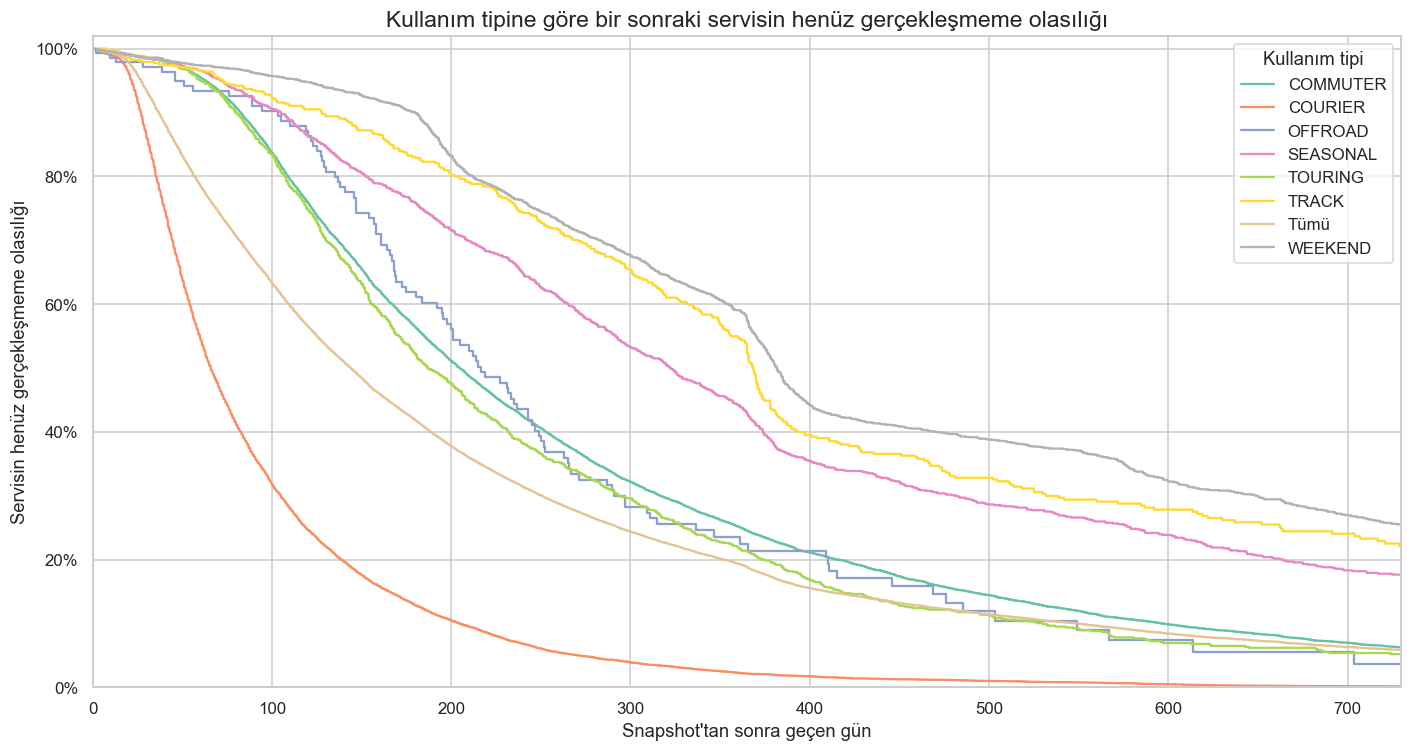

,yaklaşık_medyan_gün
group,
COMMUTER,204.817361
COURIER,65.908333
OFFROAD,214.722222
SEASONAL,321.879861
TOURING,186.979861
TRACK,368.120833
Tümü,143.943750
WEEKEND,381.815972


In [44]:
def kaplan_meier_frame(frame, duration_col="days_to_event_or_censor", event_col="target_event_observed"):
    x = frame[[duration_col, event_col]].dropna().copy()
    x = x[x[duration_col].ge(0)]
    events = x.groupby(duration_col)[event_col].agg(observed="sum", total="size").sort_index()
    events["censored"] = events["total"] - events["observed"]
    at_risk = len(x)
    survival = 1.0
    rows = [(0.0, 1.0)]
    for t, row in events.iterrows():
        if at_risk > 0:
            survival *= (1 - row["observed"] / at_risk)
            rows.append((float(t), float(survival)))
        at_risk -= int(row["total"])
    return pd.DataFrame(rows, columns=["day", "survival_probability"])

survival_data = df_next_service_targets[["motorcycle_id","days_to_event_or_censor","target_event_observed"]].merge(df_usage_profiles[["motorcycle_id","usage_type"]], on="motorcycle_id", how="left")
km_all = kaplan_meier_frame(survival_data).assign(group="Tümü")
km_groups = [km_all]
for group, group_df in survival_data.groupby("usage_type"):
    km_groups.append(kaplan_meier_frame(group_df).assign(group=group))
km_plot = pd.concat(km_groups, ignore_index=True)

fig, ax = plt.subplots(figsize=(13, 7))
for group, group_df in km_plot.groupby("group"):
    ax.step(group_df["day"], group_df["survival_probability"], where="post", label=group)
ax.set_xlim(0, min(730, km_plot["day"].max())); ax.set_ylim(0,1.02)
ax.set_title("Kullanım tipine göre bir sonraki servisin henüz gerçekleşmeme olasılığı")
ax.set_xlabel("Snapshot'tan sonra geçen gün"); ax.set_ylabel("Servisin henüz gerçekleşmeme olasılığı")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1)); ax.legend(title="Kullanım tipi")
finish_plot(fig, "35_survival_next_service.png")
display(km_plot.groupby("group").apply(lambda g: g.loc[g["survival_probability"].sub(.5).abs().idxmin(), "day"], include_groups=False).rename("yaklaşık_medyan_gün").to_frame())

### Survival analizi ne demektir?

Bu grafik, snapshot'tan sonra **bir sonraki servisin henüz gerçekleşmemiş olma olasılığını** gösterir. Eğri aşağı indikçe motosikletler yeniden servise gelmiştir. Daha hızlı düşen grup daha erken servise dönmektedir. Kaplan–Meier hesabı right-censored kayıtları silmez; gözlemlenebildikleri süre boyunca bilgilerini kullanır. Bu nedenle yalnızca gözlenen kayıtların ortalamasından daha doğru bir zaman görünümü verir.

## 14. Eksik değer örüntüleri

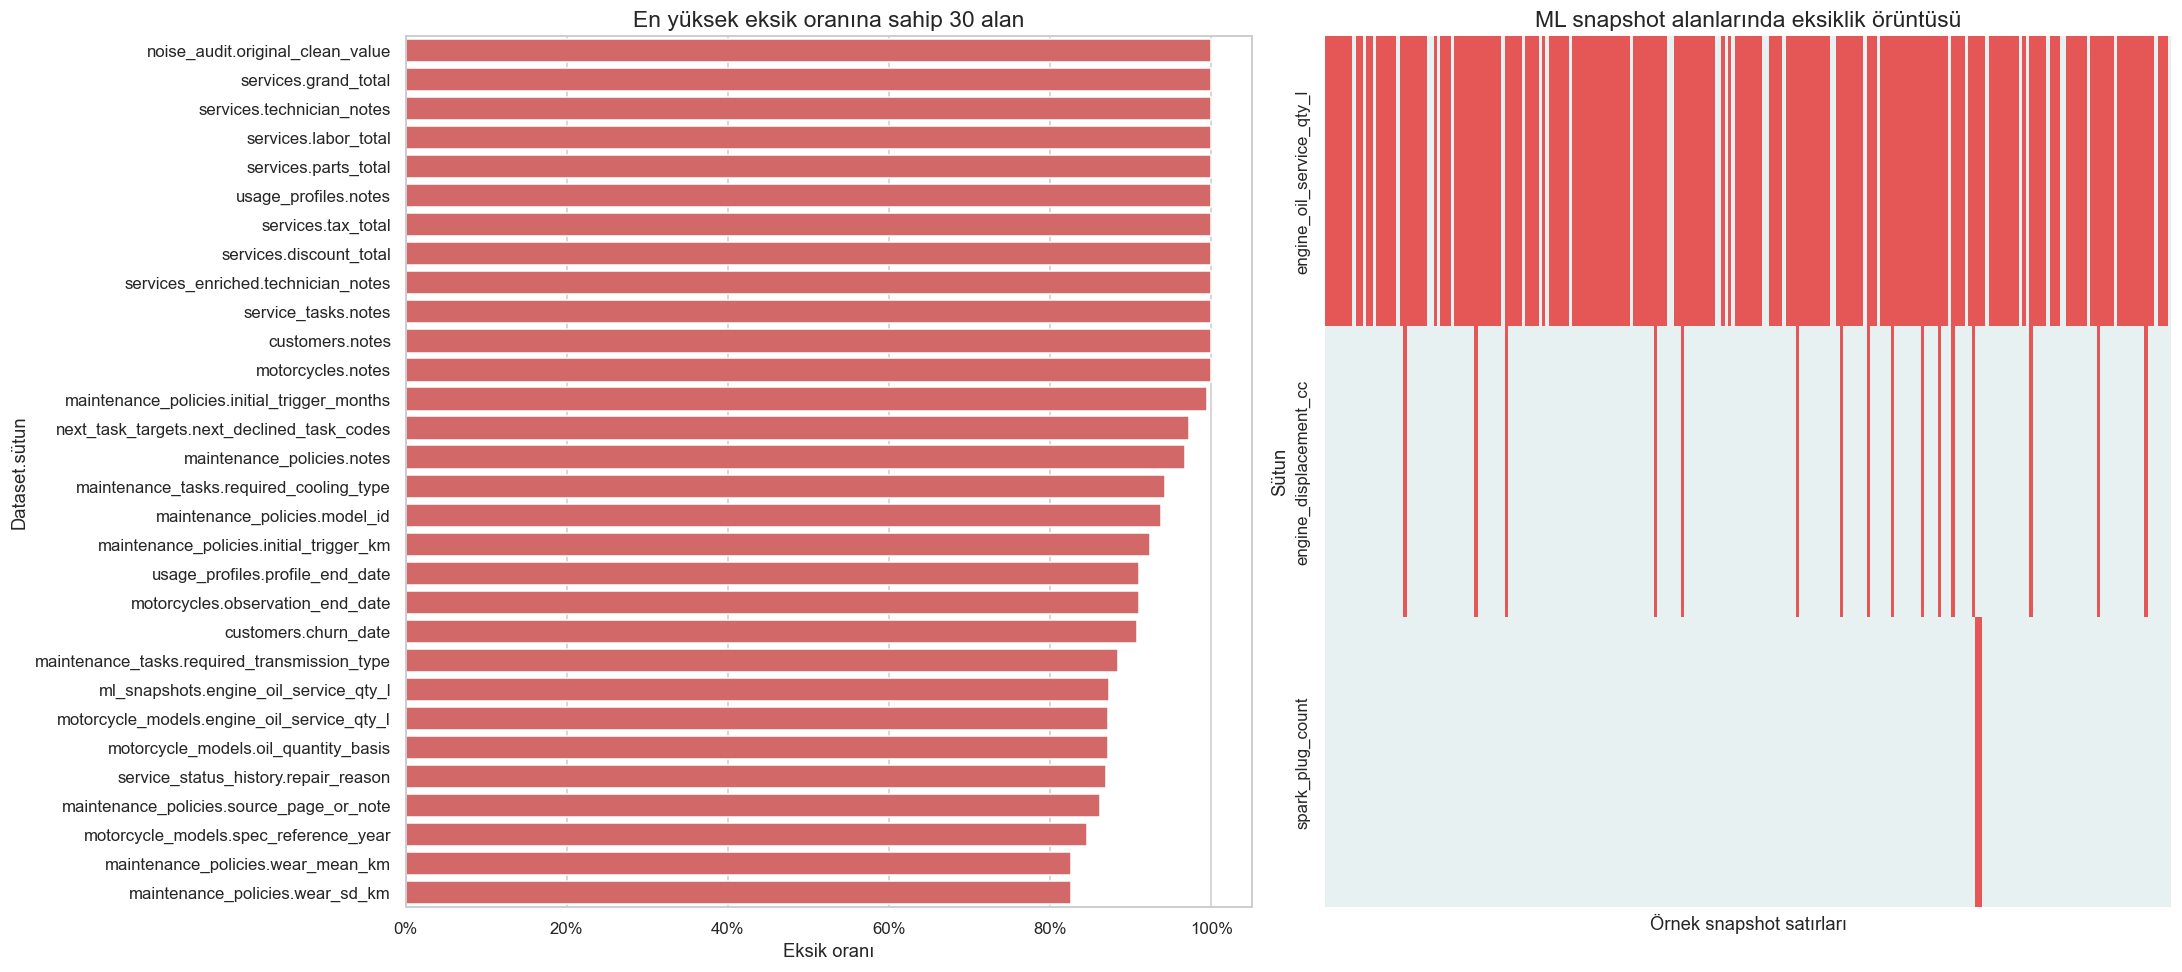

,dataset,column,null_pct,null_count
0,noise_audit,original_clean_value,1.000000,46621
1,services,grand_total,1.000000,41518
2,services,technician_notes,1.000000,41518
3,services,labor_total,1.000000,41518
4,services,parts_total,1.000000,41518
5,usage_profiles,notes,1.000000,10000
6,services,tax_total,1.000000,41518
7,services,discount_total,1.000000,41518
8,services_enriched,technician_notes,1.000000,41518
9,service_tasks,notes,1.000000,201800


In [45]:
missing_rows = []
for dataset_name, frame in dataframes.items():
    for column_name, ratio in frame.isna().mean().items():
        if ratio > 0:
            missing_rows.append({"dataset":dataset_name, "column":column_name, "null_pct":ratio, "null_count":int(frame[column_name].isna().sum())})
missing_summary = pd.DataFrame(missing_rows).sort_values("null_pct", ascending=False)
missing_top = missing_summary.head(30).copy()
missing_top["field"] = missing_top["dataset"] + "." + missing_top["column"]

snapshot_missing_cols = df_ml_snapshots.isna().mean().sort_values(ascending=False)
snapshot_missing_cols = snapshot_missing_cols[(snapshot_missing_cols > 0) & (snapshot_missing_cols < 1)].head(25).index
snapshot_missing_sample = df_ml_snapshots[list(snapshot_missing_cols)].sample(min(250, len(df_ml_snapshots)), random_state=42).isna()

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
sns.barplot(data=missing_top, x="null_pct", y="field", ax=axes[0], color="#E45756")
sns.heatmap(snapshot_missing_sample.T, cbar=False, cmap=["#E8F1F2", "#E45756"], xticklabels=False, ax=axes[1])
axes[0].set(title="En yüksek eksik oranına sahip 30 alan", xlabel="Eksik oranı", ylabel="Dataset.sütun"); axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1].set(title="ML snapshot alanlarında eksiklik örüntüsü", xlabel="Örnek snapshot satırları", ylabel="Sütun")
finish_plot(fig, "36_missingness_patterns.png")
display(missing_summary[missing_summary["null_pct"].ge(.50)].reset_index(drop=True))

### Grafik ne anlatıyor?

Solda tüm datasetlerde eksik oranı en yüksek alanlar vardır. Sağdaki haritada her sütun bir örnek snapshot, her satır bir özelliktir; kırmızı hücre eksik değeri gösterir. Eksik değer her zaman hata değildir:

- `notes` ve `technician_notes` gibi alanlar isteğe bağlıdır.
- `churn_date`, aktif müşteride doğal olarak boştur.
- `next_service...` hedefleri right-censored satırlarda bilinmediği için boştur.
- Güç sistemine özel alanlar yalnızca ICE veya EV motosiklette geçerli olabilir.

Bu nedenle modellemeden önce eksiklikler **hata**, **uygulanamaz**, **olay henüz gözlenmedi** ve **opsiyonel alan** olarak ayrılmalıdır; bütün boşlukları tek değerle doldurmak doğru değildir.

## İlk 14 tamamlayıcı EDA adımının özeti

Bu bölümle birlikte kilometre yoğunluğu, motosiklet yaşı, servis akışı, maliyet, görevler, görev birlikteliği, parçalar, randevular, arıza/garanti, kapasite, müşteri yaşam döngüsü, cohort, survival ve eksiklik mekanizması incelendi. Bir sonraki aşama, bu bulgulardan hareketle hedef değişkeni ve modelleme veri setini kesinleştirmektir.

# EDA Aşama 4 — Detaylı Enler Analizi

Bu bölüm veri setindeki dikkat çekici uç kayıtları bulur. Bir “en” sonucu ancak kullanılan ölçüt kadar anlamlıdır. Bu nedenle her sonuçta **neyin ölçüldüğü**, **hangi alt sınırın kullanıldığı** ve **neyin ölçülemediği** açıkça belirtilir.

> Bu kayıtlar sentetiktir. Marka veya model sonuçları gerçek dünyadaki dayanıklılık, kalite ya da güvenilirlik sıralaması değildir.

## 1. En uzun ömürlü, en çok ve en az kullanılan motosikletler

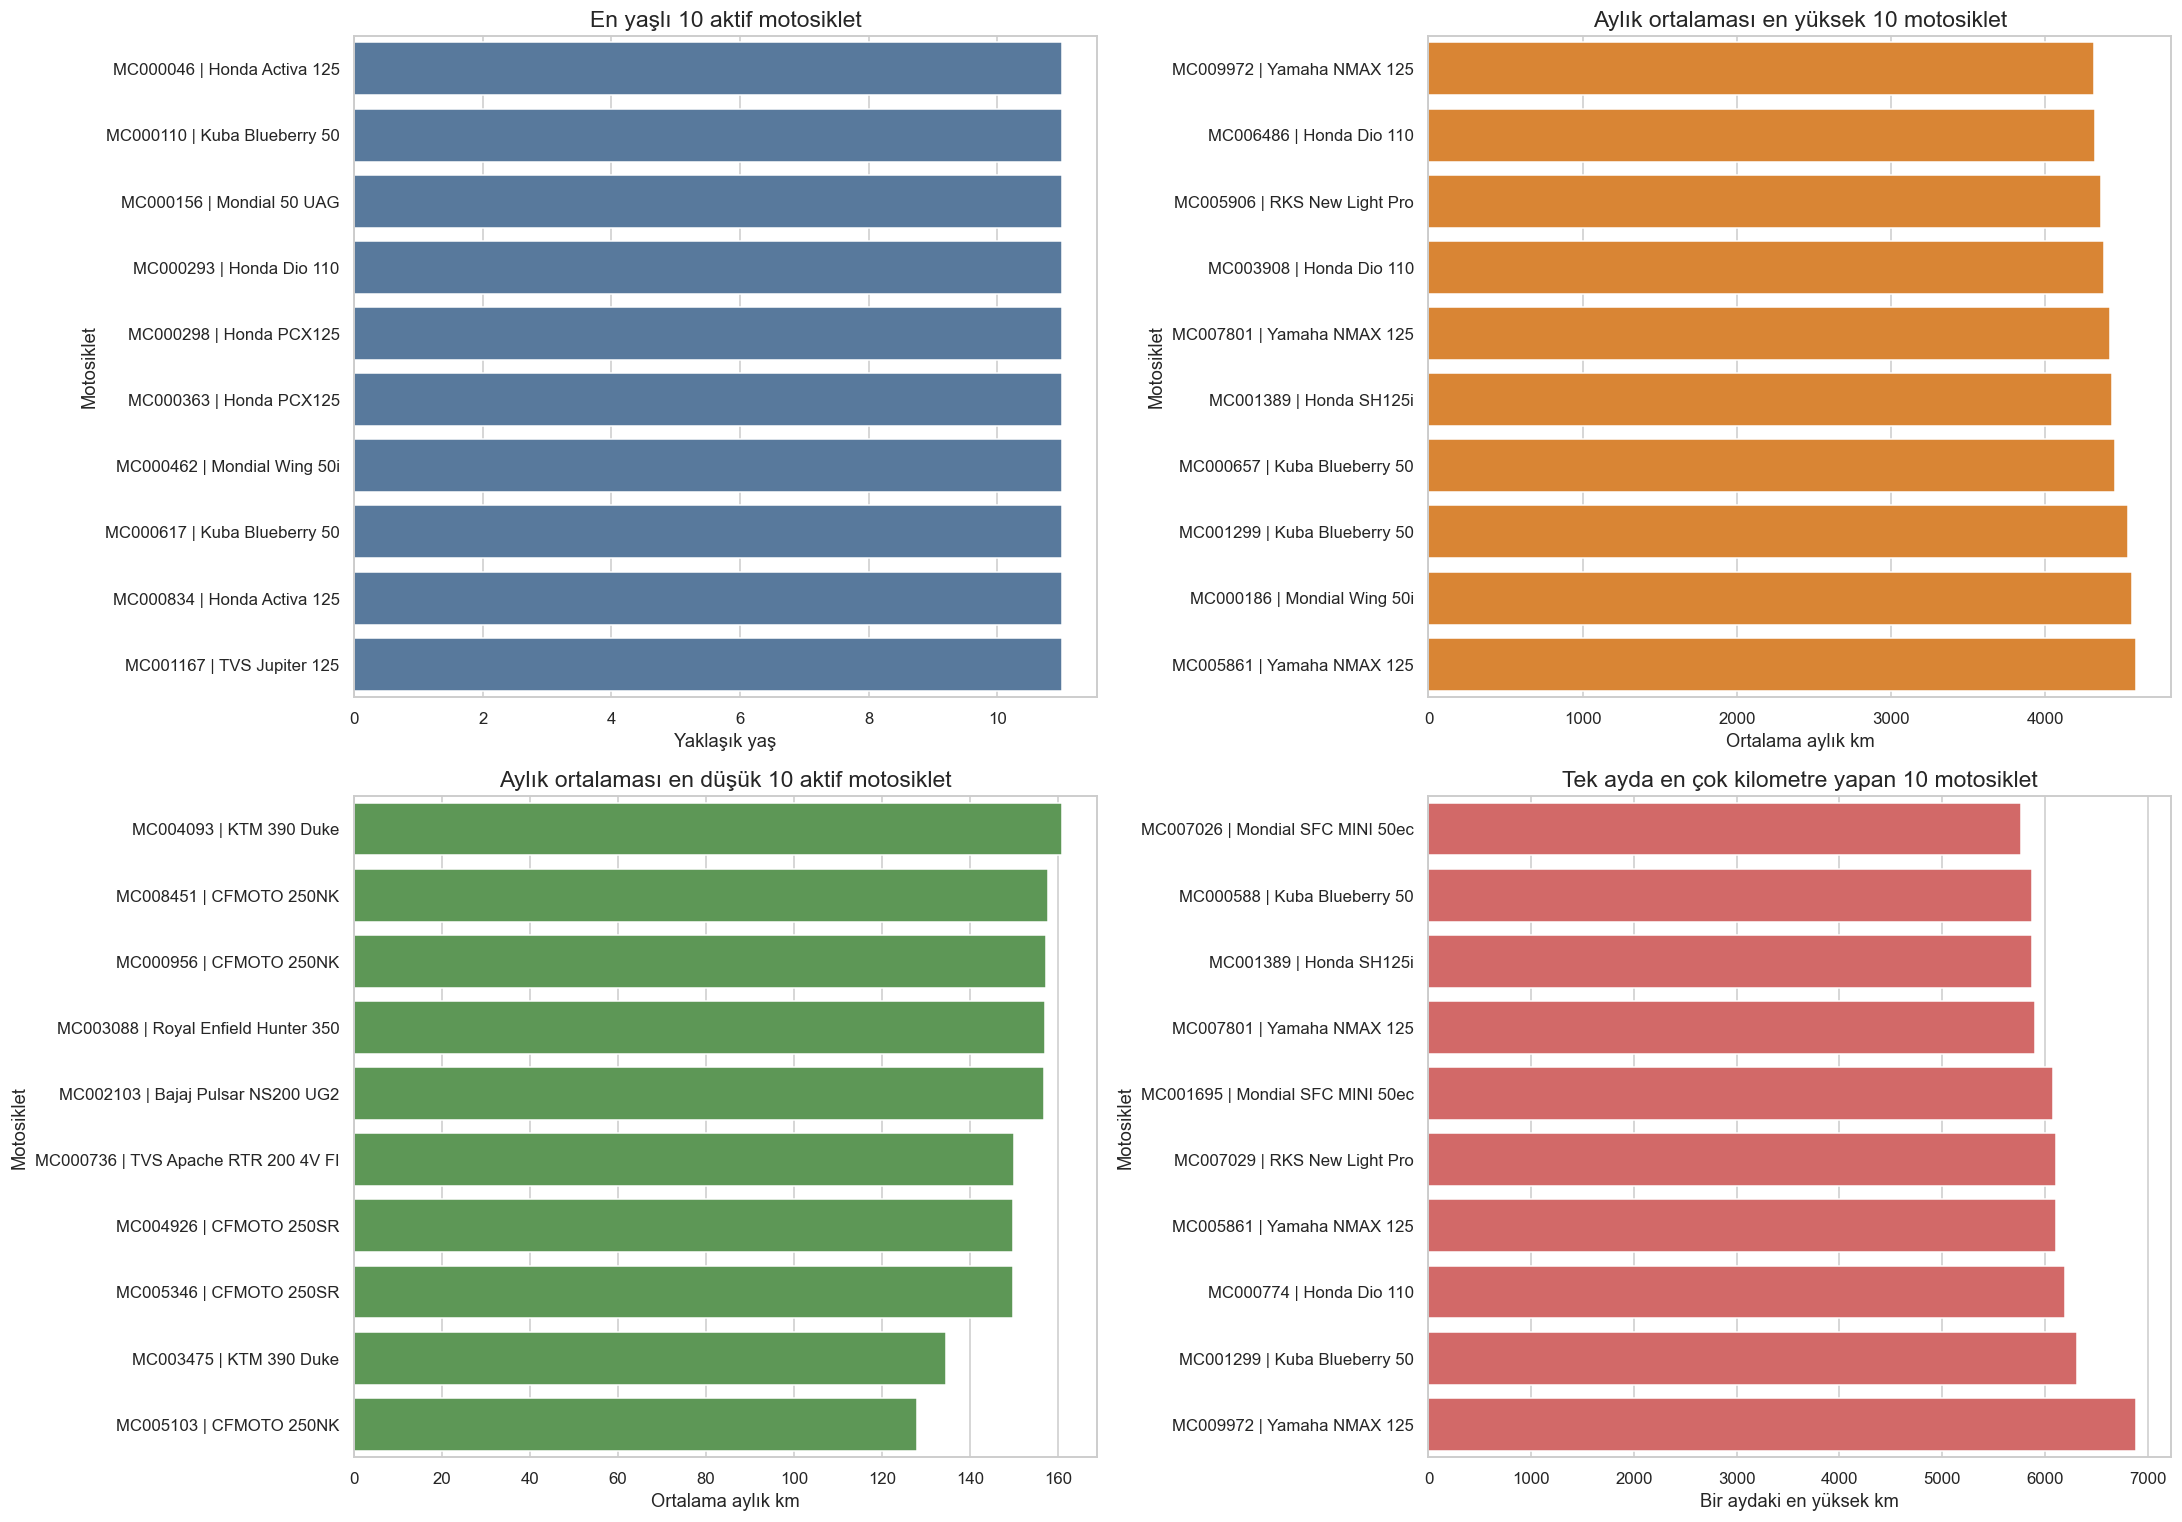


### Doğrudan sonuçlar

- **En yaşlı aktif motosiklet:** `MC000046` — **Honda Activa 125**, yaklaşık **11 yaşında**.
- **En uzun gözlenen motosiklet:** `MC001084` — **Yamaha NMAX 125**, **2057 gün** izlenmiş.
- **Aylık ortalaması en yüksek kullanım:** `MC005861` — **Yamaha NMAX 125**, ayda ortalama **4,590 km**.
- **Aylık ortalaması en düşük karşılaştırılabilir kullanım:** `MC005103` — **CFMOTO 250NK**, ayda ortalama **128 km**.
- **Gözlem boyunca en yüksek toplam kullanım:** `MC000186` — **Mondial Wing 50i**, **310,485 km**.
- **Tek ayda en yüksek mesafe:** `MC009972` — **Yamaha NMAX 125**, **6,886 km**.


In [46]:
# "Ömür" için arıza sonucu kullanım dışı kalma tarihi yoktur.
# Bu nedenle iki güvenli vekil ölçü kullanılır: en yaşlı aktif motosiklet ve en uzun gözlenen motosiklet.
motor_extreme_base = df_motorcycles[[
    "motorcycle_id", "model_id", "brand", "model_name", "category", "powertrain_type",
    "production_year", "observation_start_date", "observation_end_date", "is_active"
]].copy()
motor_extreme_base["observation_start_date"] = pd.to_datetime(motor_extreme_base["observation_start_date"], errors="coerce")
motor_extreme_base["observation_end_date"] = pd.to_datetime(motor_extreme_base["observation_end_date"], errors="coerce")
analysis_reference_date = max(
    pd.to_datetime(services_time["received_at"], errors="coerce").max().normalize(),
    motor_extreme_base["observation_end_date"].max(),
)
analysis_reference_year = analysis_reference_date.year
motor_extreme_base["approx_age_years"] = analysis_reference_year - motor_extreme_base["production_year"]
motor_extreme_base["effective_observation_end"] = motor_extreme_base["observation_end_date"].fillna(analysis_reference_date)
motor_extreme_base["observed_days"] = (motor_extreme_base["effective_observation_end"] - motor_extreme_base["observation_start_date"]).dt.days
motor_extreme_base["motor_label"] = motor_extreme_base["motorcycle_id"] + " | " + motor_extreme_base["brand"] + " " + motor_extreme_base["model_name"]

motor_monthly_use = mileage_eda.groupby("motorcycle_id").agg(
    observed_months=("year_month", "nunique"),
    avg_monthly_km=("km_added", "mean"),
    total_added_km=("km_added", "sum"),
    max_monthly_km=("km_added", "max"),
).reset_index().merge(motor_extreme_base, on="motorcycle_id", how="left")

# En az kullanım için en az 12 ay gözlenmiş aktif motosikletler karşılaştırılır.
comparable_use = motor_monthly_use.query("observed_months >= 12 and is_active == 1").copy()
oldest_active = motor_extreme_base.query("is_active == 1").nlargest(10, "approx_age_years")
longest_observed = motor_extreme_base.nlargest(10, "observed_days")
most_used = comparable_use.nlargest(10, "avg_monthly_km")
least_used = comparable_use.nsmallest(10, "avg_monthly_km")
most_total_use = motor_monthly_use.nlargest(10, "total_added_km")
longest_month = motor_monthly_use.nlargest(10, "max_monthly_km")

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
sns.barplot(data=oldest_active.sort_values("approx_age_years"), x="approx_age_years", y="motor_label", ax=axes[0,0], color="#4C78A8")
sns.barplot(data=most_used.sort_values("avg_monthly_km"), x="avg_monthly_km", y="motor_label", ax=axes[0,1], color="#F58518")
sns.barplot(data=least_used.sort_values("avg_monthly_km", ascending=False), x="avg_monthly_km", y="motor_label", ax=axes[1,0], color="#54A24B")
sns.barplot(data=longest_month.sort_values("max_monthly_km"), x="max_monthly_km", y="motor_label", ax=axes[1,1], color="#E45756")
axes[0,0].set(title="En yaşlı 10 aktif motosiklet", xlabel="Yaklaşık yaş", ylabel="Motosiklet")
axes[0,1].set(title="Aylık ortalaması en yüksek 10 motosiklet", xlabel="Ortalama aylık km", ylabel="Motosiklet")
axes[1,0].set(title="Aylık ortalaması en düşük 10 aktif motosiklet", xlabel="Ortalama aylık km", ylabel="Motosiklet")
axes[1,1].set(title="Tek ayda en çok kilometre yapan 10 motosiklet", xlabel="Bir aydaki en yüksek km", ylabel="Motosiklet")
finish_plot(fig, "37_motorcycle_usage_extremes.png")

display(Markdown(f"""
### Doğrudan sonuçlar

- **En yaşlı aktif motosiklet:** `{oldest_active.iloc[0]['motorcycle_id']}` — **{oldest_active.iloc[0]['brand']} {oldest_active.iloc[0]['model_name']}**, yaklaşık **{oldest_active.iloc[0]['approx_age_years']:.0f} yaşında**.
- **En uzun gözlenen motosiklet:** `{longest_observed.iloc[0]['motorcycle_id']}` — **{longest_observed.iloc[0]['brand']} {longest_observed.iloc[0]['model_name']}**, **{longest_observed.iloc[0]['observed_days']:.0f} gün** izlenmiş.
- **Aylık ortalaması en yüksek kullanım:** `{most_used.iloc[0]['motorcycle_id']}` — **{most_used.iloc[0]['brand']} {most_used.iloc[0]['model_name']}**, ayda ortalama **{most_used.iloc[0]['avg_monthly_km']:,.0f} km**.
- **Aylık ortalaması en düşük karşılaştırılabilir kullanım:** `{least_used.iloc[0]['motorcycle_id']}` — **{least_used.iloc[0]['brand']} {least_used.iloc[0]['model_name']}**, ayda ortalama **{least_used.iloc[0]['avg_monthly_km']:,.0f} km**.
- **Gözlem boyunca en yüksek toplam kullanım:** `{most_total_use.iloc[0]['motorcycle_id']}` — **{most_total_use.iloc[0]['brand']} {most_total_use.iloc[0]['model_name']}**, **{most_total_use.iloc[0]['total_added_km']:,.0f} km**.
- **Tek ayda en yüksek mesafe:** `{longest_month.iloc[0]['motorcycle_id']}` — **{longest_month.iloc[0]['brand']} {longest_month.iloc[0]['model_name']}**, **{longest_month.iloc[0]['max_monthly_km']:,.0f} km**.
"""))

### Bu “en”ler nasıl yorumlanmalı?

- Dataset gerçek bir motosikletin mekanik olarak kaç yıl dayandığını söyleyen `failure_date` veya `scrap_date` alanı içermez. Bu yüzden **en uzun ömürlü** ifadesinin güvenli karşılığı “verideki en yaşlı aktif motosiklet”tir.
- Aktif motosikletlerde `observation_end_date` boş olabildiği için gözlem süresi hesabında bu alan veri setindeki son analiz tarihiyle tamamlanır; böylece halen izlenen araçlar sıralama dışında kalmaz.
- **En az kullanılan** motosiklet seçilirken yeni eklenmiş araçların haksız biçimde en alta düşmemesi için en az 12 ay gözlenmiş ve aktif araçlar karşılaştırıldı.
- Dataset yolculuk/tur bazlı kayıt içermez. Bu nedenle **en uzun motor turu** ölçülemez; en yakın ölçü, tek bir ayda eklenen en yüksek kilometredir. Bu değer aynı ay içindeki birden fazla yolculuğun toplamı olabilir.

## 2. En çok servis gören, en arızalı ve en pahalı motosikletler

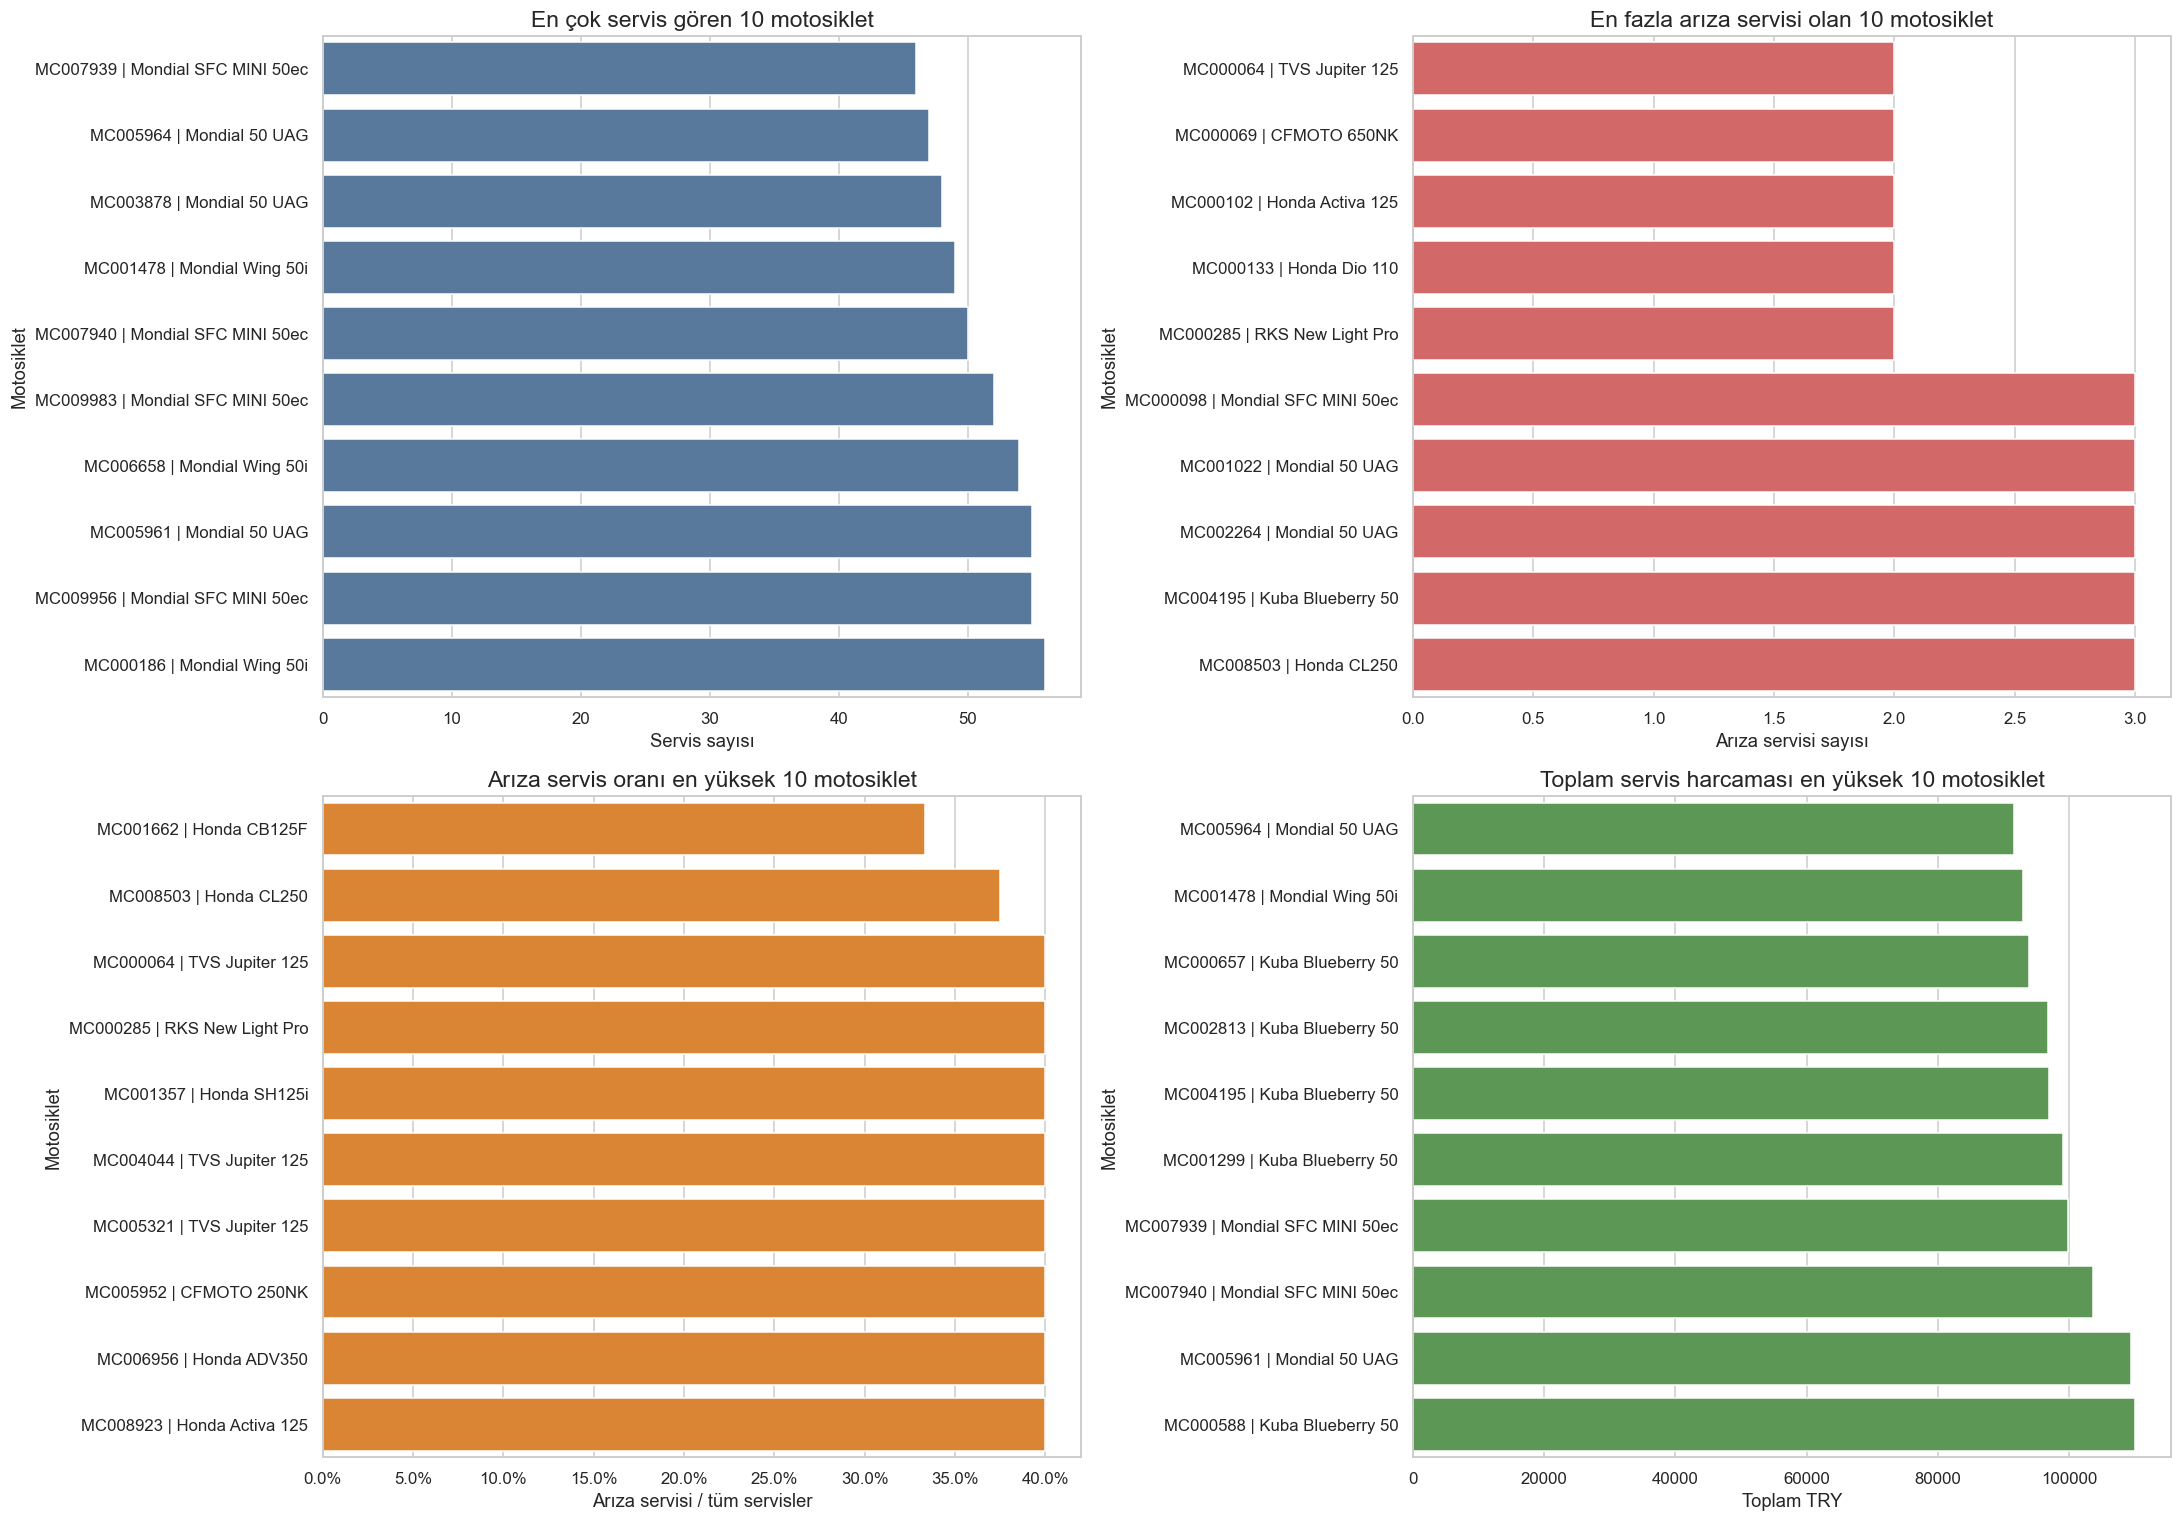


### Doğrudan sonuçlar

- **En çok servis gören:** `MC000186` — **Mondial Wing 50i**, **56 servis**.
- **En fazla arıza kaydı olan:** `MC000098` — **Mondial SFC MINI 50ec**, **3 arıza servisi**.
- **Arıza oranı en yüksek (en az 5 servis):** `MC000064` — **TVS Jupiter 125**, **%40.0**.
- **En fazla garanti kaydı olan:** `MC008912` — **Yamaha NMAX 125**, **4 garanti servisi**.
- **Toplam servis harcaması en yüksek:** `MC000588` — **Kuba Blueberry 50**, **110,107 TRY**.
- **Servis başı ortalama harcaması en yüksek (en az 5 servis):** `MC009915` — **Honda Activa 125**, **5,973 TRY/servis**.
- **İki servis arasında en uzun gözlenen boşluk:** `MC002047` — **MC002047 | Bajaj Pulsar NS125**, **1880 gün**.


,motorcycle_id,motor_label,previous_service_at,received_at,gap_days
0,MC002047,MC002047 | Bajaj Pulsar NS125,2021-04-23 12:27:00,2026-06-16 15:26:00,1880.0
1,MC004902,MC004902 | Honda CB125F,2021-09-30 10:19:00,2026-06-12 12:21:00,1716.0
2,MC000320,MC000320 | Honda PCX125,2021-11-15 08:39:00,2026-05-02 11:00:00,1629.0
3,MC002998,MC002998 | Yamaha XMAX 250,2021-12-09 10:55:00,2026-05-05 17:14:00,1608.0
4,MC004562,MC004562 | Honda PCX125,2022-01-12 12:46:00,2026-06-05 11:01:00,1604.0
5,MC008036,MC008036 | TVS Apache RTR 200 4V FI,2022-04-04 09:11:00,2026-07-27 11:06:00,1575.0
6,MC005529,MC005529 | Honda SH125i,2022-04-11 12:29:00,2026-06-22 15:46:00,1533.0
7,MC003796,MC003796 | Honda Monkey,2021-10-11 13:48:00,2025-11-26 09:27:00,1506.0
8,MC002328,MC002328 | Honda Forza 250,2021-11-24 10:14:00,2025-11-12 13:32:00,1449.0
9,MC008143,MC008143 | TVS Apache RTR 200 4V FI,2022-05-25 11:59:00,2026-04-28 10:26:00,1433.0


In [47]:
motor_service_extremes = services_time.groupby("motorcycle_id").agg(
    service_count=("service_id", "nunique"),
    breakdown_count=("is_breakdown", "sum"),
    breakdown_rate=("is_breakdown", "mean"),
    warranty_count=("is_warranty", "sum"),
    total_spend=("grand_total", "sum"),
    avg_service_cost=("grand_total", "mean"),
    first_service=("received_at", "min"),
    last_service=("received_at", "max"),
).reset_index().merge(motor_extreme_base[["motorcycle_id","brand","model_name","motor_label"]], on="motorcycle_id", how="left")

# Oran karşılaştırmasında tek servislik araçların %100 görünmesini engelle.
rate_comparable = motor_service_extremes.query("service_count >= 5").copy()
most_serviced = motor_service_extremes.nlargest(10, "service_count")
most_breakdowns = motor_service_extremes.nlargest(10, "breakdown_count")
highest_breakdown_rate = rate_comparable.sort_values(["breakdown_rate","breakdown_count"], ascending=False).head(10)
most_warranty = motor_service_extremes.nlargest(10, "warranty_count")
highest_spend = motor_service_extremes.nlargest(10, "total_spend")
highest_avg_service_cost_motor = rate_comparable.nlargest(10, "avg_service_cost")

service_gaps = services_time.sort_values(["motorcycle_id","received_at"])[["motorcycle_id","service_id","received_at"]].copy()
service_gaps["previous_service_at"] = service_gaps.groupby("motorcycle_id")["received_at"].shift()
service_gaps["gap_days"] = (service_gaps["received_at"] - service_gaps["previous_service_at"]).dt.days
longest_service_gaps = service_gaps.dropna(subset=["gap_days"]).nlargest(10, "gap_days").merge(motor_extreme_base[["motorcycle_id","motor_label"]], on="motorcycle_id", how="left")

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
sns.barplot(data=most_serviced.sort_values("service_count"), x="service_count", y="motor_label", ax=axes[0,0], color="#4C78A8")
sns.barplot(data=most_breakdowns.sort_values("breakdown_count"), x="breakdown_count", y="motor_label", ax=axes[0,1], color="#E45756")
sns.barplot(data=highest_breakdown_rate.sort_values("breakdown_rate"), x="breakdown_rate", y="motor_label", ax=axes[1,0], color="#F58518")
sns.barplot(data=highest_spend.sort_values("total_spend"), x="total_spend", y="motor_label", ax=axes[1,1], color="#54A24B")
axes[0,0].set(title="En çok servis gören 10 motosiklet", xlabel="Servis sayısı", ylabel="Motosiklet")
axes[0,1].set(title="En fazla arıza servisi olan 10 motosiklet", xlabel="Arıza servisi sayısı", ylabel="Motosiklet")
axes[1,0].set(title="Arıza servis oranı en yüksek 10 motosiklet", xlabel="Arıza servisi / tüm servisler", ylabel="Motosiklet"); axes[1,0].xaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1,1].set(title="Toplam servis harcaması en yüksek 10 motosiklet", xlabel="Toplam TRY", ylabel="Motosiklet")
finish_plot(fig, "38_motorcycle_service_extremes.png")

display(Markdown(f"""
### Doğrudan sonuçlar

- **En çok servis gören:** `{most_serviced.iloc[0]['motorcycle_id']}` — **{most_serviced.iloc[0]['brand']} {most_serviced.iloc[0]['model_name']}**, **{most_serviced.iloc[0]['service_count']:.0f} servis**.
- **En fazla arıza kaydı olan:** `{most_breakdowns.iloc[0]['motorcycle_id']}` — **{most_breakdowns.iloc[0]['brand']} {most_breakdowns.iloc[0]['model_name']}**, **{most_breakdowns.iloc[0]['breakdown_count']:.0f} arıza servisi**.
- **Arıza oranı en yüksek (en az 5 servis):** `{highest_breakdown_rate.iloc[0]['motorcycle_id']}` — **{highest_breakdown_rate.iloc[0]['brand']} {highest_breakdown_rate.iloc[0]['model_name']}**, **%{highest_breakdown_rate.iloc[0]['breakdown_rate']*100:.1f}**.
- **En fazla garanti kaydı olan:** `{most_warranty.iloc[0]['motorcycle_id']}` — **{most_warranty.iloc[0]['brand']} {most_warranty.iloc[0]['model_name']}**, **{most_warranty.iloc[0]['warranty_count']:.0f} garanti servisi**.
- **Toplam servis harcaması en yüksek:** `{highest_spend.iloc[0]['motorcycle_id']}` — **{highest_spend.iloc[0]['brand']} {highest_spend.iloc[0]['model_name']}**, **{highest_spend.iloc[0]['total_spend']:,.0f} TRY**.
- **Servis başı ortalama harcaması en yüksek (en az 5 servis):** `{highest_avg_service_cost_motor.iloc[0]['motorcycle_id']}` — **{highest_avg_service_cost_motor.iloc[0]['brand']} {highest_avg_service_cost_motor.iloc[0]['model_name']}**, **{highest_avg_service_cost_motor.iloc[0]['avg_service_cost']:,.0f} TRY/servis**.
- **İki servis arasında en uzun gözlenen boşluk:** `{longest_service_gaps.iloc[0]['motorcycle_id']}` — **{longest_service_gaps.iloc[0]['motor_label']}**, **{longest_service_gaps.iloc[0]['gap_days']:.0f} gün**.
"""))
display(longest_service_gaps[["motorcycle_id","brand" if "brand" in longest_service_gaps.columns else "motor_label","previous_service_at","received_at","gap_days"]].head(10))

### Arıza sayısı ile arıza oranı neden ayrı?

Çok kullanılan bir motosiklet daha fazla servise girdiği için ham arıza sayısı yüksek olabilir. **Arıza oranı**, arıza servislerini tüm servis sayısına böler ve kullanım hacmini kısmen dengeler. Ancak çok az servisli araçta oran oynak olduğu için oran sıralamasına yalnızca en az 5 servis gören motosikletler alındı.

## 3. En uzun ve en pahalı servis kayıtları

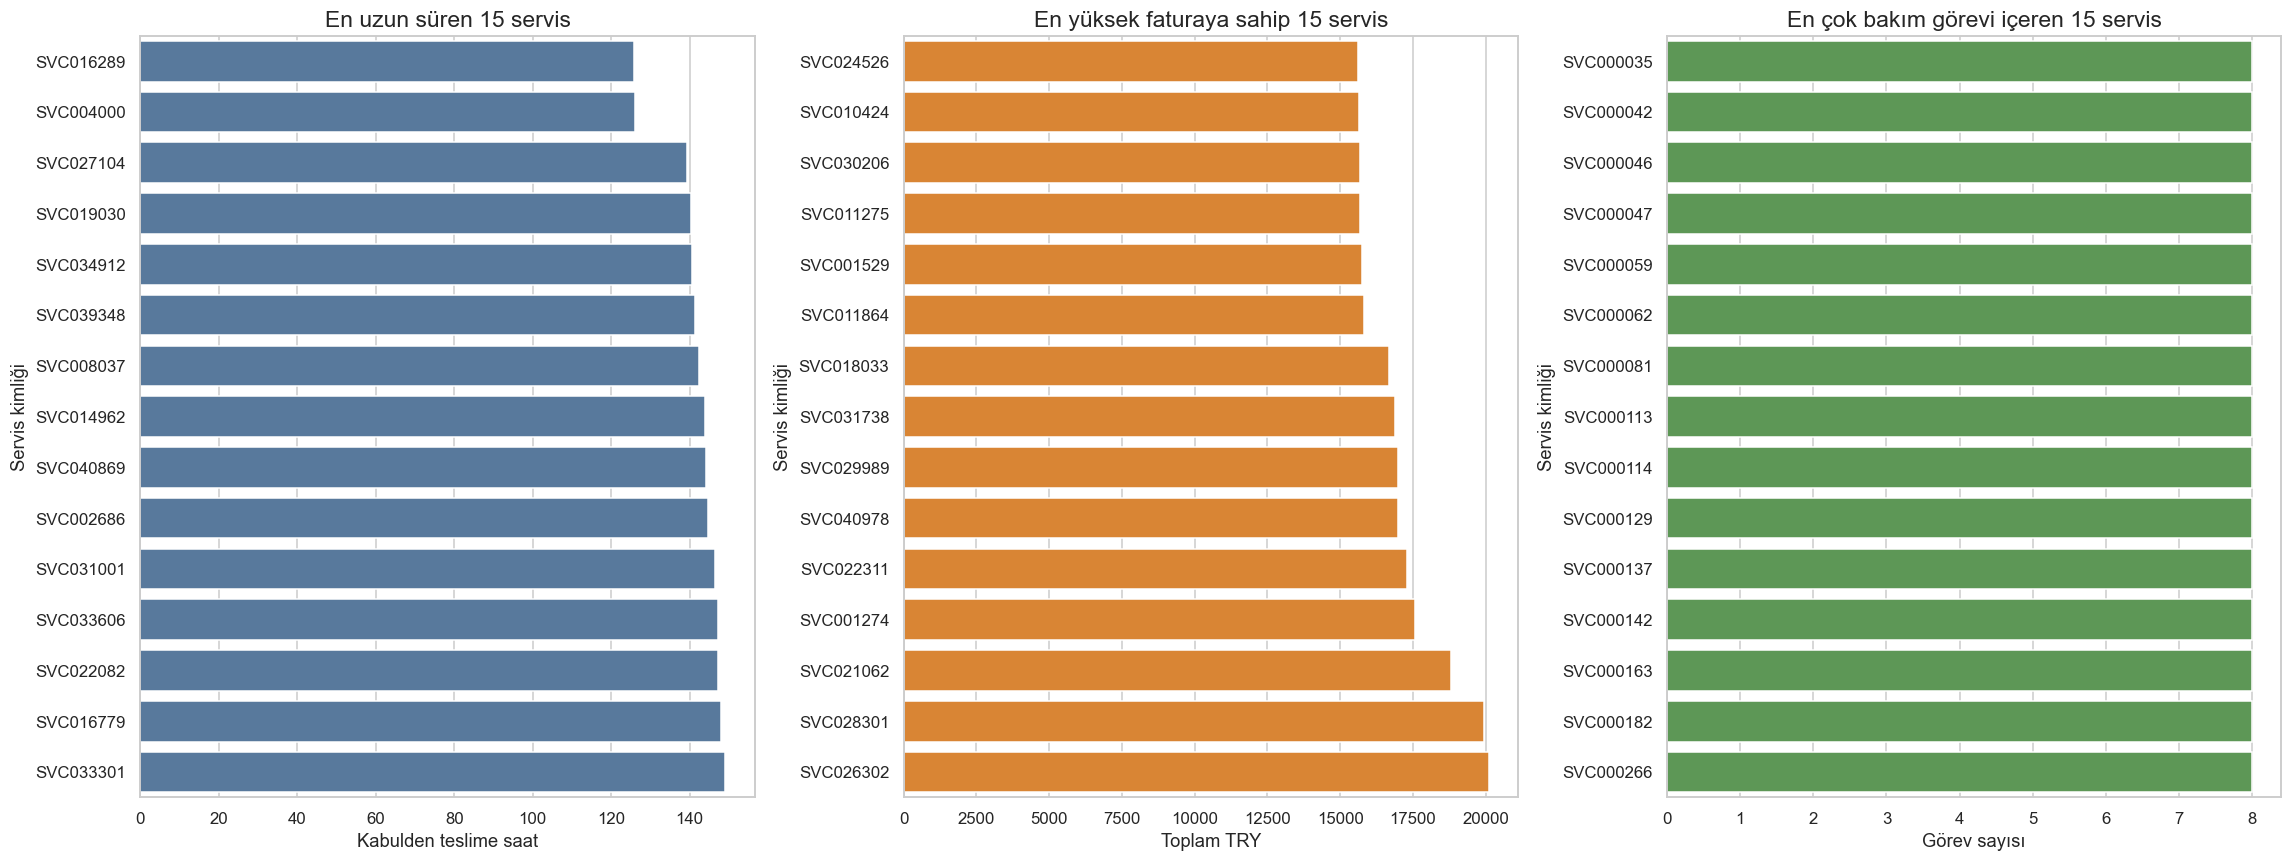


- **En uzun servis:** `SVC033301` — **RKS New Light Pro**, **149.1 saat**, parça durumu: **Parça bekledi**.
- **En pahalı servis:** `SVC026302` — **Yamaha NMAX 125**, **20,112 TRY**.
- **İşçilik toplamı en yüksek servis:** `SVC013687` — **7,420 TRY**.
- **Parça toplamı en yüksek servis:** `SVC026302` — **14,000 TRY**.
- **En çok görev içeren servis:** `SVC000035` — **Mondial Wing 50i**, **8 görev**.


In [48]:
service_record_extremes = services_time[["service_id","motorcycle_id","workshop_id","service_type_code","received_at","grand_total","labor_total","parts_total","is_breakdown"]].merge(
    process[["service_id","turnaround_hours","waited_for_parts","task_count"]], on="service_id", how="left"
).merge(
    motor_extreme_base[["motorcycle_id","brand","model_name"]], on="motorcycle_id", how="left"
)
service_record_extremes["motor_name"] = service_record_extremes["brand"] + " " + service_record_extremes["model_name"]
longest_services = service_record_extremes.query("turnaround_hours >= 0").nlargest(15, "turnaround_hours")
most_expensive_services = service_record_extremes.nlargest(15, "grand_total")
highest_labor_services = service_record_extremes.nlargest(15, "labor_total")
highest_parts_services = service_record_extremes.nlargest(15, "parts_total")
most_tasks_services = service_record_extremes.nlargest(15, "task_count")

fig, axes = plt.subplots(1, 3, figsize=(21, 8))
sns.barplot(data=longest_services.sort_values("turnaround_hours"), x="turnaround_hours", y="service_id", ax=axes[0], color="#4C78A8")
sns.barplot(data=most_expensive_services.sort_values("grand_total"), x="grand_total", y="service_id", ax=axes[1], color="#F58518")
sns.barplot(data=most_tasks_services.sort_values("task_count"), x="task_count", y="service_id", ax=axes[2], color="#54A24B")
axes[0].set(title="En uzun süren 15 servis", xlabel="Kabulden teslime saat", ylabel="Servis kimliği")
axes[1].set(title="En yüksek faturaya sahip 15 servis", xlabel="Toplam TRY", ylabel="Servis kimliği")
axes[2].set(title="En çok bakım görevi içeren 15 servis", xlabel="Görev sayısı", ylabel="Servis kimliği")
finish_plot(fig, "39_service_record_extremes.png")

display(Markdown(f"""
- **En uzun servis:** `{longest_services.iloc[0]['service_id']}` — **{longest_services.iloc[0]['motor_name']}**, **{longest_services.iloc[0]['turnaround_hours']:.1f} saat**, parça durumu: **{longest_services.iloc[0]['waited_for_parts']}**.
- **En pahalı servis:** `{most_expensive_services.iloc[0]['service_id']}` — **{most_expensive_services.iloc[0]['motor_name']}**, **{most_expensive_services.iloc[0]['grand_total']:,.0f} TRY**.
- **İşçilik toplamı en yüksek servis:** `{highest_labor_services.iloc[0]['service_id']}` — **{highest_labor_services.iloc[0]['labor_total']:,.0f} TRY**.
- **Parça toplamı en yüksek servis:** `{highest_parts_services.iloc[0]['service_id']}` — **{highest_parts_services.iloc[0]['parts_total']:,.0f} TRY**.
- **En çok görev içeren servis:** `{most_tasks_services.iloc[0]['service_id']}` — **{most_tasks_services.iloc[0]['motor_name']}**, **{most_tasks_services.iloc[0]['task_count']:.0f} görev**.
"""))

### Grafik ne anlatıyor?

Buradaki her satır tek bir servis ziyaretidir. **En uzun servis**, kabulden müşteriye teslime kadar geçen takvim süresidir; yalnızca teknisyenin aktif çalışma süresi değildir. Gece, hafta sonu veya parça bekleme bu süreye dahil olabilir. En pahalı servis ise `grand_total` değerine göre belirlenir.

## 4. Marka ve model enleri

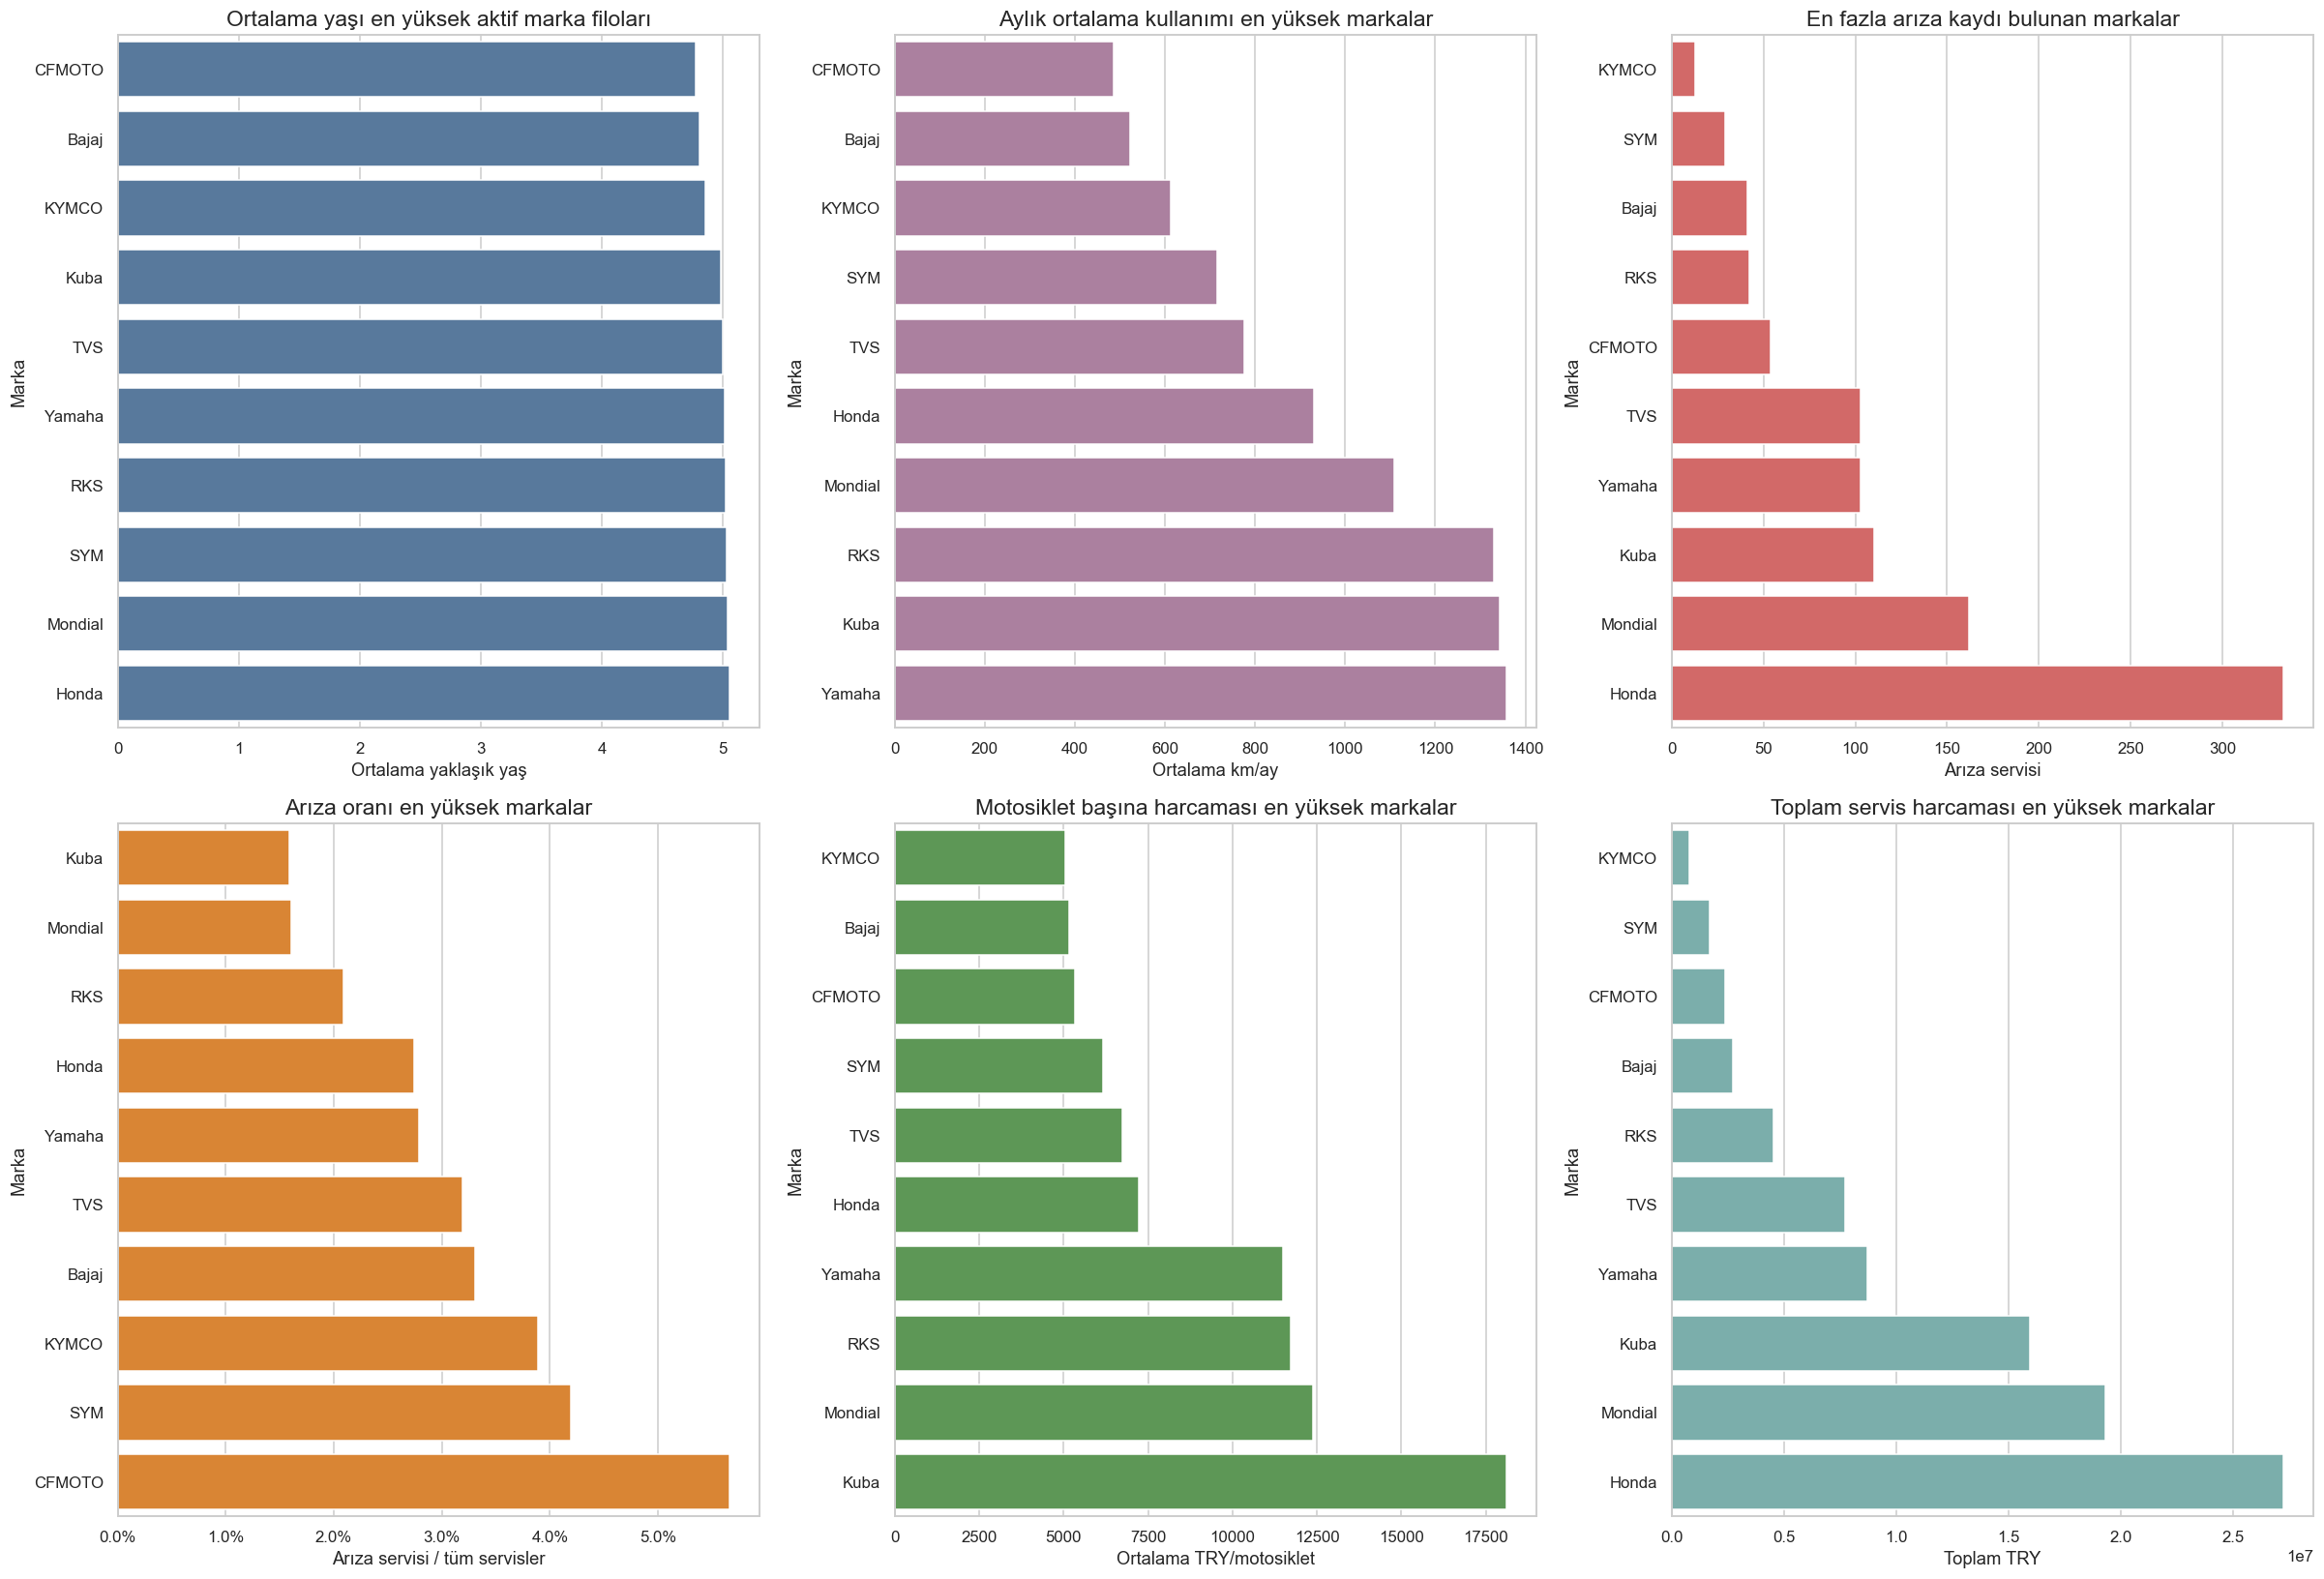

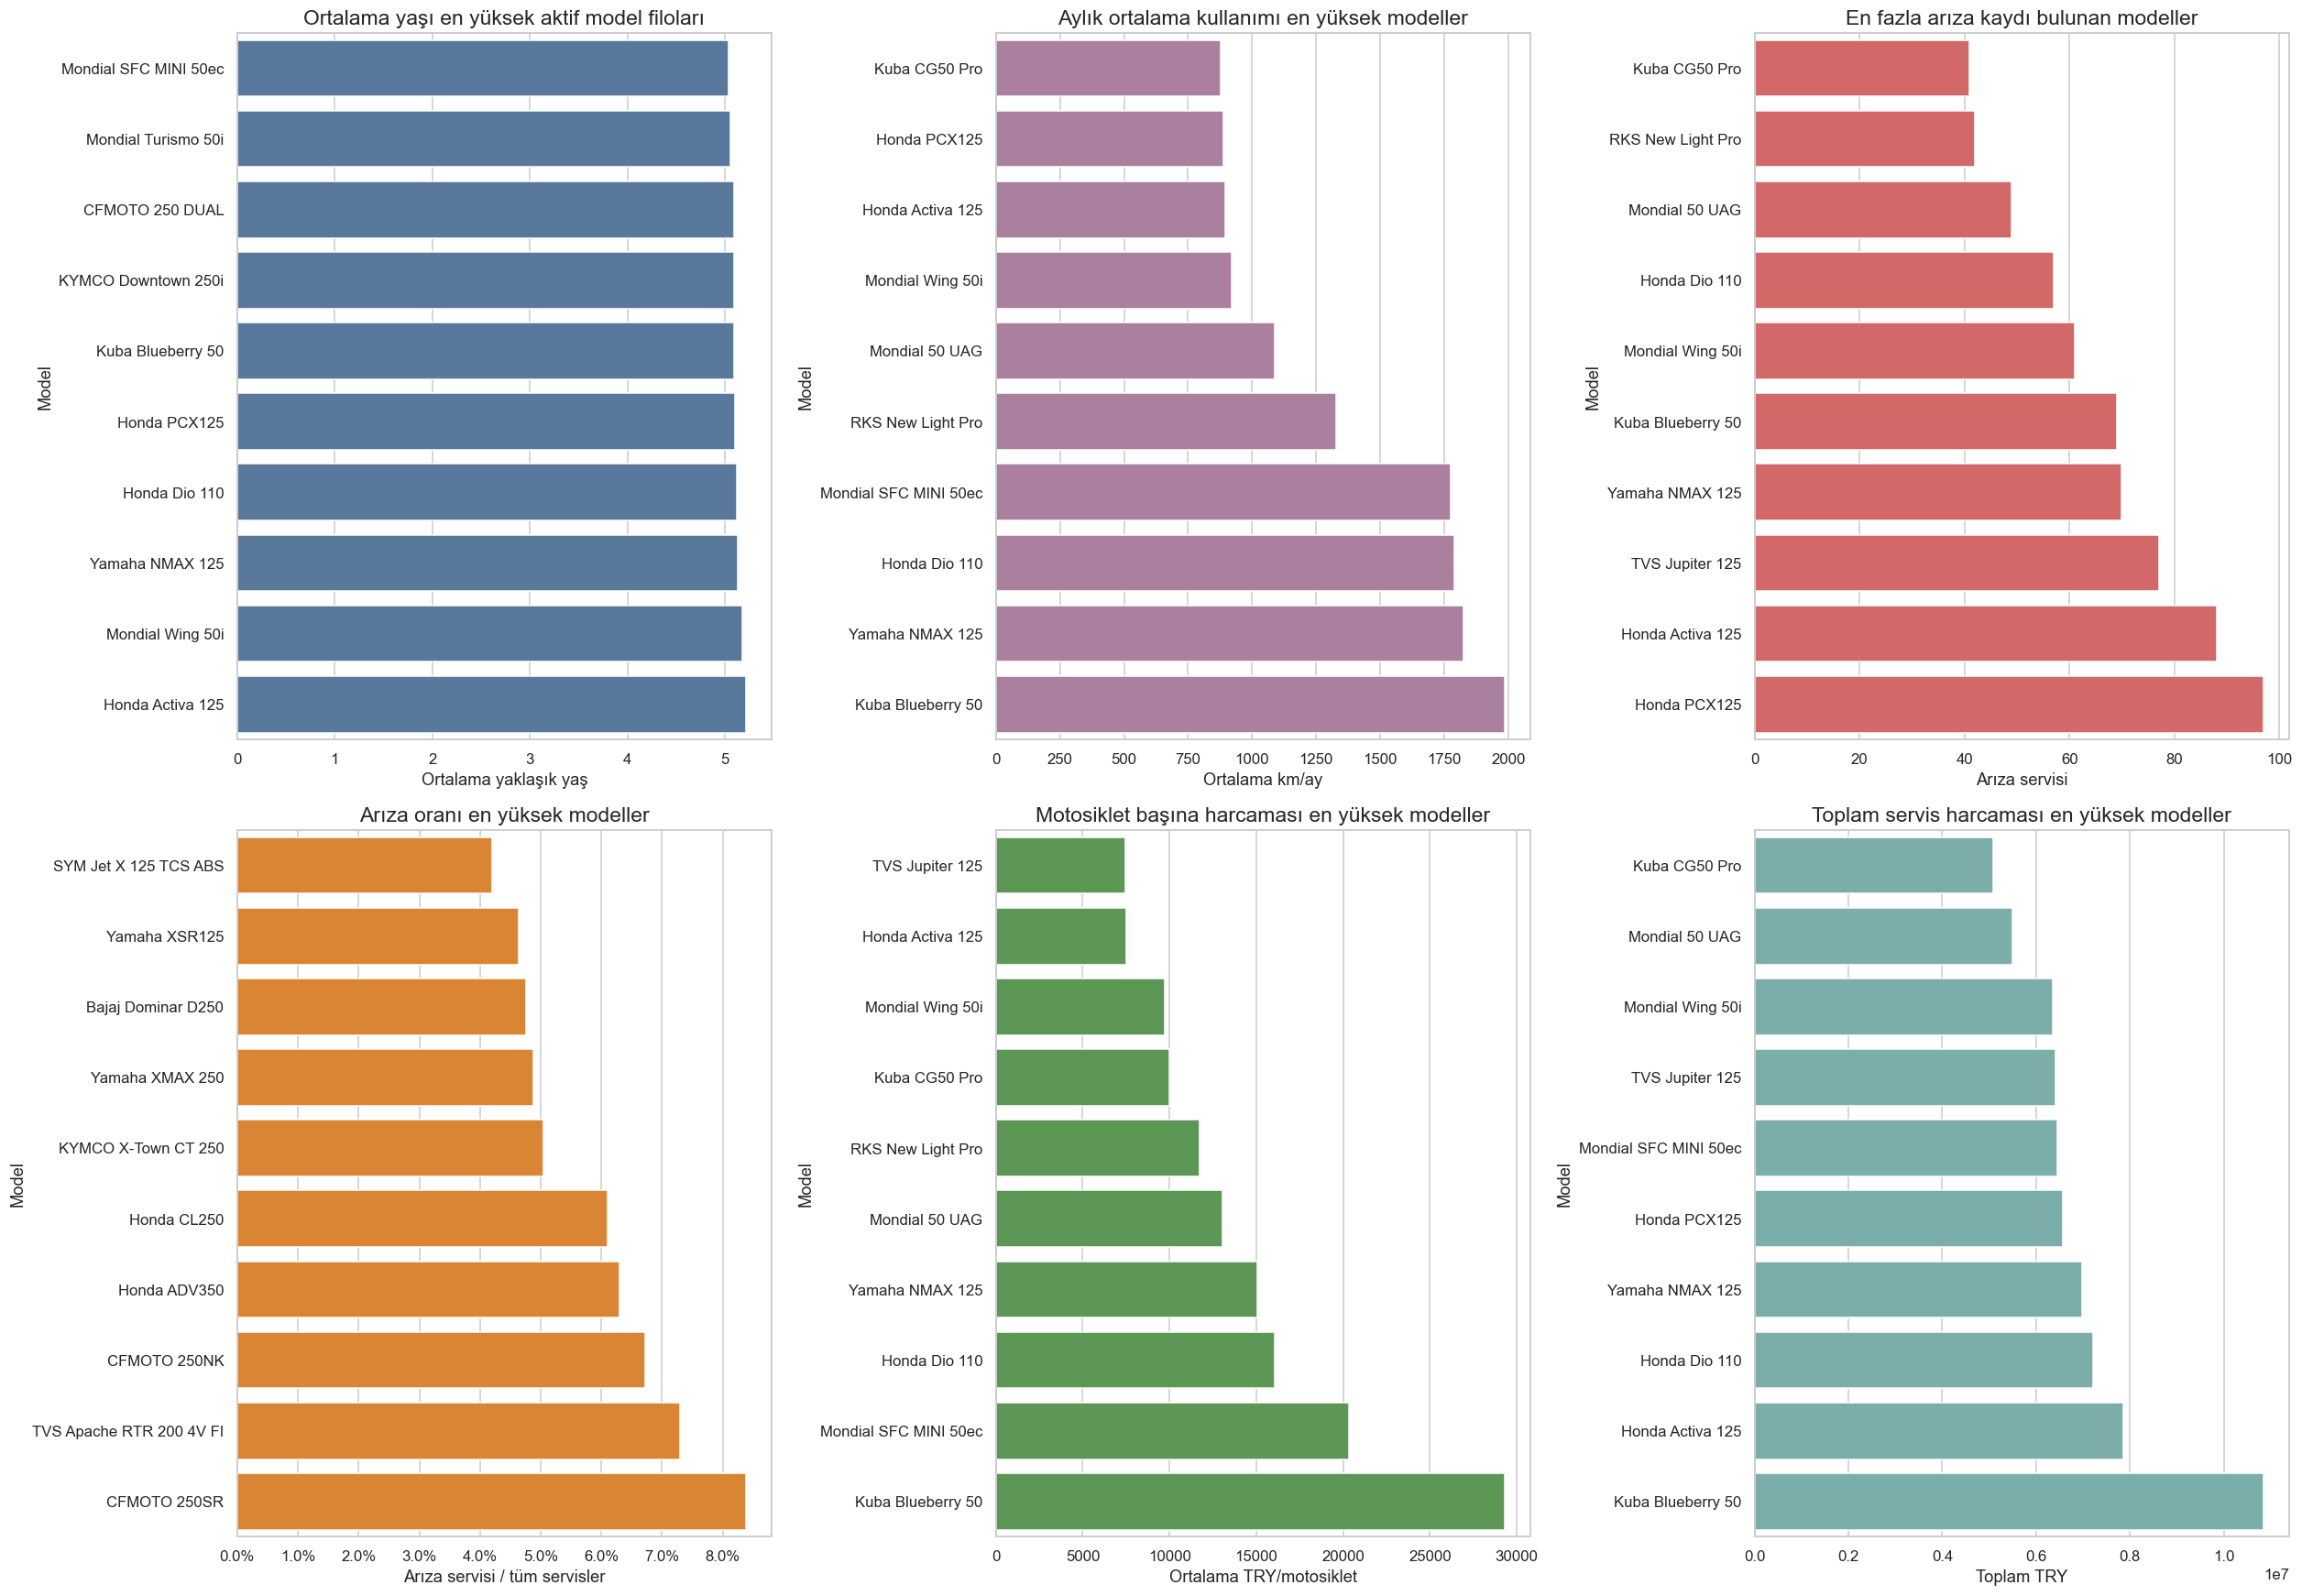

,brand,motorcycle_count,active_motorcycle_count,avg_active_age_years,avg_observed_days,avg_monthly_km,total_added_km,service_count,breakdown_count,warranty_count,total_spend,avg_spend_per_motorcycle,avg_services_per_motorcycle,breakdown_rate,warranty_rate,avg_service_cost,brand_label
2,Honda,3772,3422,5.051,1033.849,930.139,127235899,12152.0,333.0,447.0,27219642.03,7216.236,3.222,0.027,0.037,2239.931,Honda
6,Mondial,1560,1407,5.038,1011.585,1109.344,62139352,10091.0,162.0,354.0,19322044.43,12385.926,6.469,0.016,0.035,1914.780,Mondial
5,Kuba,880,806,4.983,1015.511,1343.848,42805087,6932.0,110.0,231.0,15933948.31,18106.759,7.877,0.016,0.033,2298.608,Kuba
11,Yamaha,759,700,5.014,1018.211,1357.461,37648992,3697.0,103.0,124.0,8724528.86,11494.768,4.871,0.028,0.034,2359.894,Yamaha
10,TVS,1148,1054,4.994,1037.693,775.052,32247753,3228.0,103.0,114.0,7736166.30,6738.821,2.812,0.032,0.035,2396.582,TVS
7,RKS,386,350,5.020,1001.479,1329.296,17865143,2011.0,42.0,85.0,4529721.53,11735.030,5.210,0.021,0.042,2252.472,RKS
0,Bajaj,527,476,4.805,1033.078,522.553,10010474,1241.0,41.0,38.0,2721786.71,5164.681,2.355,0.033,0.031,2193.221,Bajaj
1,CFMOTO,443,406,4.771,1062.594,486.080,8023218,954.0,54.0,34.0,2366058.00,5340.989,2.153,0.057,0.036,2480.145,CFMOTO
9,SYM,272,253,5.032,1024.695,715.408,6894649,691.0,29.0,23.0,1678225.64,6169.947,2.540,0.042,0.033,2428.691,SYM
4,KYMCO,156,135,4.852,1027.096,612.534,3473275,334.0,13.0,10.0,788644.37,5055.413,2.141,0.039,0.030,2361.211,KYMCO


,model_id,brand,model_name,motorcycle_count,active_motorcycle_count,avg_active_age_years,avg_observed_days,avg_monthly_km,total_added_km,service_count,breakdown_count,warranty_count,total_spend,avg_spend_per_motorcycle,avg_services_per_motorcycle,breakdown_rate,warranty_rate,avg_service_cost,model_label
6,CFMOTO_250SR,CFMOTO,250SR,76,70,4.529,1035.961,356.297,929433,155.0,13.0,5.0,392020.92,5158.170,2.039,0.084,0.032,2529.167,CFMOTO 250SR
33,TVS_APACHE_RTR200_4V,TVS,Apache RTR 200 4V FI,81,76,4.974,1168.506,436.499,1399567,178.0,13.0,5.0,431244.76,5324.009,2.198,0.073,0.028,2422.723,TVS Apache RTR 200 4V FI
5,CFMOTO_250NK,CFMOTO,250NK,156,142,4.958,1084.647,434.140,2603962,357.0,24.0,6.0,836148.30,5359.925,2.288,0.067,0.017,2342.152,CFMOTO 250NK
11,HONDA_ADV350,Honda,ADV350,118,107,4.757,1058.127,498.518,2178228,222.0,14.0,10.0,538512.13,4563.662,1.881,0.063,0.045,2425.730,Honda ADV350
13,HONDA_CL250,Honda,CL250,62,57,4.702,1096.000,497.588,1174967,164.0,10.0,2.0,460674.73,7430.238,2.645,0.061,0.012,2808.992,Honda CL250
24,KYMCO_XTOWN_CT250,KYMCO,X-Town CT 250,83,74,4.649,1110.446,615.190,1975781,198.0,10.0,6.0,452187.63,5448.044,2.386,0.051,0.030,2283.776,KYMCO X-Town CT 250
37,YAMAHA_XMAX250,Yamaha,XMAX 250,222,197,4.772,976.928,675.803,5140552,532.0,26.0,22.0,1370819.17,6174.861,2.396,0.049,0.041,2576.728,Yamaha XMAX 250
0,BAJAJ_DOMINAR250,Bajaj,Dominar D250,62,58,4.552,1118.161,577.955,1378932,126.0,6.0,3.0,298192.57,4809.558,2.032,0.048,0.024,2366.608,Bajaj Dominar D250
38,YAMAHA_XSR125,Yamaha,XSR125,74,70,4.986,1057.378,474.789,1338806,151.0,7.0,1.0,377016.27,5094.814,2.041,0.046,0.007,2496.796,Yamaha XSR125
32,SYM_JETX125,SYM,Jet X 125 TCS ABS,272,253,5.032,1024.695,715.408,6894649,691.0,29.0,23.0,1678225.64,6169.947,2.540,0.042,0.033,2428.691,SYM Jet X 125 TCS ABS


In [49]:
# Tekil motosiklet ölçülerinden marka ve marka-model özetleri üret.
# Böylece büyük grupların toplamı ile motosiklet başına ortalama birbirine karıştırılmaz.
motor_rollup = motor_extreme_base.copy()
motor_rollup = motor_rollup.merge(
    motor_monthly_use[["motorcycle_id","observed_months","avg_monthly_km","total_added_km","max_monthly_km"]],
    on="motorcycle_id", how="left"
).merge(
    motor_service_extremes[["motorcycle_id","service_count","breakdown_count","warranty_count","total_spend"]],
    on="motorcycle_id", how="left"
)
for col in ["service_count","breakdown_count","warranty_count","total_spend"]:
    motor_rollup[col] = pd.to_numeric(motor_rollup[col], errors="coerce").fillna(0)
motor_rollup["active_age_years"] = motor_rollup["approx_age_years"].where(motor_rollup["is_active"].eq(1))

def summarize_vehicle_groups(group_cols):
    summary = motor_rollup.groupby(group_cols, dropna=False).agg(
        motorcycle_count=("motorcycle_id","nunique"),
        active_motorcycle_count=("is_active","sum"),
        avg_active_age_years=("active_age_years","mean"),
        avg_observed_days=("observed_days","mean"),
        avg_monthly_km=("avg_monthly_km","mean"),
        total_added_km=("total_added_km","sum"),
        service_count=("service_count","sum"),
        breakdown_count=("breakdown_count","sum"),
        warranty_count=("warranty_count","sum"),
        total_spend=("total_spend","sum"),
        avg_spend_per_motorcycle=("total_spend","mean"),
        avg_services_per_motorcycle=("service_count","mean"),
    ).reset_index()
    summary["breakdown_rate"] = summary["breakdown_count"].div(summary["service_count"].replace(0, np.nan))
    summary["warranty_rate"] = summary["warranty_count"].div(summary["service_count"].replace(0, np.nan))
    summary["avg_service_cost"] = summary["total_spend"].div(summary["service_count"].replace(0, np.nan))
    return summary

brand_extremes = summarize_vehicle_groups("brand")
brand_extremes["brand_label"] = brand_extremes["brand"]
brand_comparable = brand_extremes.query("motorcycle_count >= 50 and service_count >= 300").copy()
oldest_brand_fleet = brand_extremes.query("active_motorcycle_count >= 50").nlargest(10, "avg_active_age_years")
highest_brand_usage = brand_comparable.nlargest(10, "avg_monthly_km")
most_common_brands = brand_extremes.nlargest(10, "motorcycle_count")
most_brand_breakdowns = brand_extremes.nlargest(10, "breakdown_count")
highest_brand_breakdown = brand_comparable.nlargest(10, "breakdown_rate")
highest_brand_spend = brand_extremes.nlargest(10, "total_spend")
highest_brand_spend_per_motorcycle = brand_comparable.nlargest(10, "avg_spend_per_motorcycle")
highest_brand_service_cost = brand_comparable.nlargest(10, "avg_service_cost")

model_extremes = summarize_vehicle_groups(["model_id","brand","model_name"])
model_extremes["model_label"] = model_extremes["brand"] + " " + model_extremes["model_name"]
model_comparable = model_extremes.query("motorcycle_count >= 20 and service_count >= 100").copy()
oldest_model_fleet = model_extremes.query("active_motorcycle_count >= 20").nlargest(10, "avg_active_age_years")
highest_model_usage = model_comparable.nlargest(10, "avg_monthly_km")
most_common_models = model_extremes.nlargest(10, "motorcycle_count")
most_model_breakdowns = model_extremes.nlargest(10, "breakdown_count")
highest_model_breakdown = model_comparable.nlargest(10, "breakdown_rate")
highest_model_spend = model_extremes.nlargest(10, "total_spend")
highest_model_spend_per_motorcycle = model_comparable.nlargest(10, "avg_spend_per_motorcycle")
highest_model_cost = model_comparable.nlargest(10, "avg_service_cost")

fig, axes = plt.subplots(2, 3, figsize=(22, 15))
sns.barplot(data=oldest_brand_fleet.sort_values("avg_active_age_years"), x="avg_active_age_years", y="brand_label", ax=axes[0,0], color="#4C78A8")
sns.barplot(data=highest_brand_usage.sort_values("avg_monthly_km"), x="avg_monthly_km", y="brand_label", ax=axes[0,1], color="#B279A2")
sns.barplot(data=most_brand_breakdowns.sort_values("breakdown_count"), x="breakdown_count", y="brand_label", ax=axes[0,2], color="#E45756")
sns.barplot(data=highest_brand_breakdown.sort_values("breakdown_rate"), x="breakdown_rate", y="brand_label", ax=axes[1,0], color="#F58518")
sns.barplot(data=highest_brand_spend_per_motorcycle.sort_values("avg_spend_per_motorcycle"), x="avg_spend_per_motorcycle", y="brand_label", ax=axes[1,1], color="#54A24B")
sns.barplot(data=highest_brand_spend.sort_values("total_spend"), x="total_spend", y="brand_label", ax=axes[1,2], color="#72B7B2")
axes[0,0].set(title="Ortalama yaşı en yüksek aktif marka filoları", xlabel="Ortalama yaklaşık yaş", ylabel="Marka")
axes[0,1].set(title="Aylık ortalama kullanımı en yüksek markalar", xlabel="Ortalama km/ay", ylabel="Marka")
axes[0,2].set(title="En fazla arıza kaydı bulunan markalar", xlabel="Arıza servisi", ylabel="Marka")
axes[1,0].set(title="Arıza oranı en yüksek markalar", xlabel="Arıza servisi / tüm servisler", ylabel="Marka"); axes[1,0].xaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1,1].set(title="Motosiklet başına harcaması en yüksek markalar", xlabel="Ortalama TRY/motosiklet", ylabel="Marka")
axes[1,2].set(title="Toplam servis harcaması en yüksek markalar", xlabel="Toplam TRY", ylabel="Marka")
finish_plot(fig, "40_brand_extremes.png")

fig, axes = plt.subplots(2, 3, figsize=(23, 16))
sns.barplot(data=oldest_model_fleet.sort_values("avg_active_age_years"), x="avg_active_age_years", y="model_label", ax=axes[0,0], color="#4C78A8")
sns.barplot(data=highest_model_usage.sort_values("avg_monthly_km"), x="avg_monthly_km", y="model_label", ax=axes[0,1], color="#B279A2")
sns.barplot(data=most_model_breakdowns.sort_values("breakdown_count"), x="breakdown_count", y="model_label", ax=axes[0,2], color="#E45756")
sns.barplot(data=highest_model_breakdown.sort_values("breakdown_rate"), x="breakdown_rate", y="model_label", ax=axes[1,0], color="#F58518")
sns.barplot(data=highest_model_spend_per_motorcycle.sort_values("avg_spend_per_motorcycle"), x="avg_spend_per_motorcycle", y="model_label", ax=axes[1,1], color="#54A24B")
sns.barplot(data=highest_model_spend.sort_values("total_spend"), x="total_spend", y="model_label", ax=axes[1,2], color="#72B7B2")
axes[0,0].set(title="Ortalama yaşı en yüksek aktif model filoları", xlabel="Ortalama yaklaşık yaş", ylabel="Model")
axes[0,1].set(title="Aylık ortalama kullanımı en yüksek modeller", xlabel="Ortalama km/ay", ylabel="Model")
axes[0,2].set(title="En fazla arıza kaydı bulunan modeller", xlabel="Arıza servisi", ylabel="Model")
axes[1,0].set(title="Arıza oranı en yüksek modeller", xlabel="Arıza servisi / tüm servisler", ylabel="Model"); axes[1,0].xaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1,1].set(title="Motosiklet başına harcaması en yüksek modeller", xlabel="Ortalama TRY/motosiklet", ylabel="Model")
axes[1,2].set(title="Toplam servis harcaması en yüksek modeller", xlabel="Toplam TRY", ylabel="Model")
finish_plot(fig, "40_model_extremes.png")

display(
    brand_extremes.sort_values("total_spend", ascending=False).round(3),
    model_comparable.sort_values("breakdown_rate", ascending=False).round(3),
)

### Grafik ne anlatıyor?

Marka ve modeller yalnızca arıza açısından değil; **aktif filo yaşı, aylık kullanım, motosiklet sayısı, servis hacmi ve harcama** açısından da karşılaştırılır. Oran ve ortalama sıralamalarının küçük örneklerden etkilenmesini azaltmak için markalarda en az **50 motosiklet ve 300 servis**, modellerde en az **20 motosiklet ve 100 servis** eşiği kullanıldı. Ortalama aktif filo yaşı için ayrıca aynı aktif motosiklet alt sınırları uygulandı.

**Toplam** metrikler grubun veri setindeki hacmini, **motosiklet başına ortalama** metrikler ise tipik araç yükünü anlatır. Bu nedenle örneğin toplam harcama lideri ile motosiklet başına harcama lideri farklı olabilir. Sonuçlar sentetik veri üretim kurallarını yansıtır; gerçek dünyada marka dayanıklılığı veya kalite sıralaması değildir.

## 5. Müşteri enleri

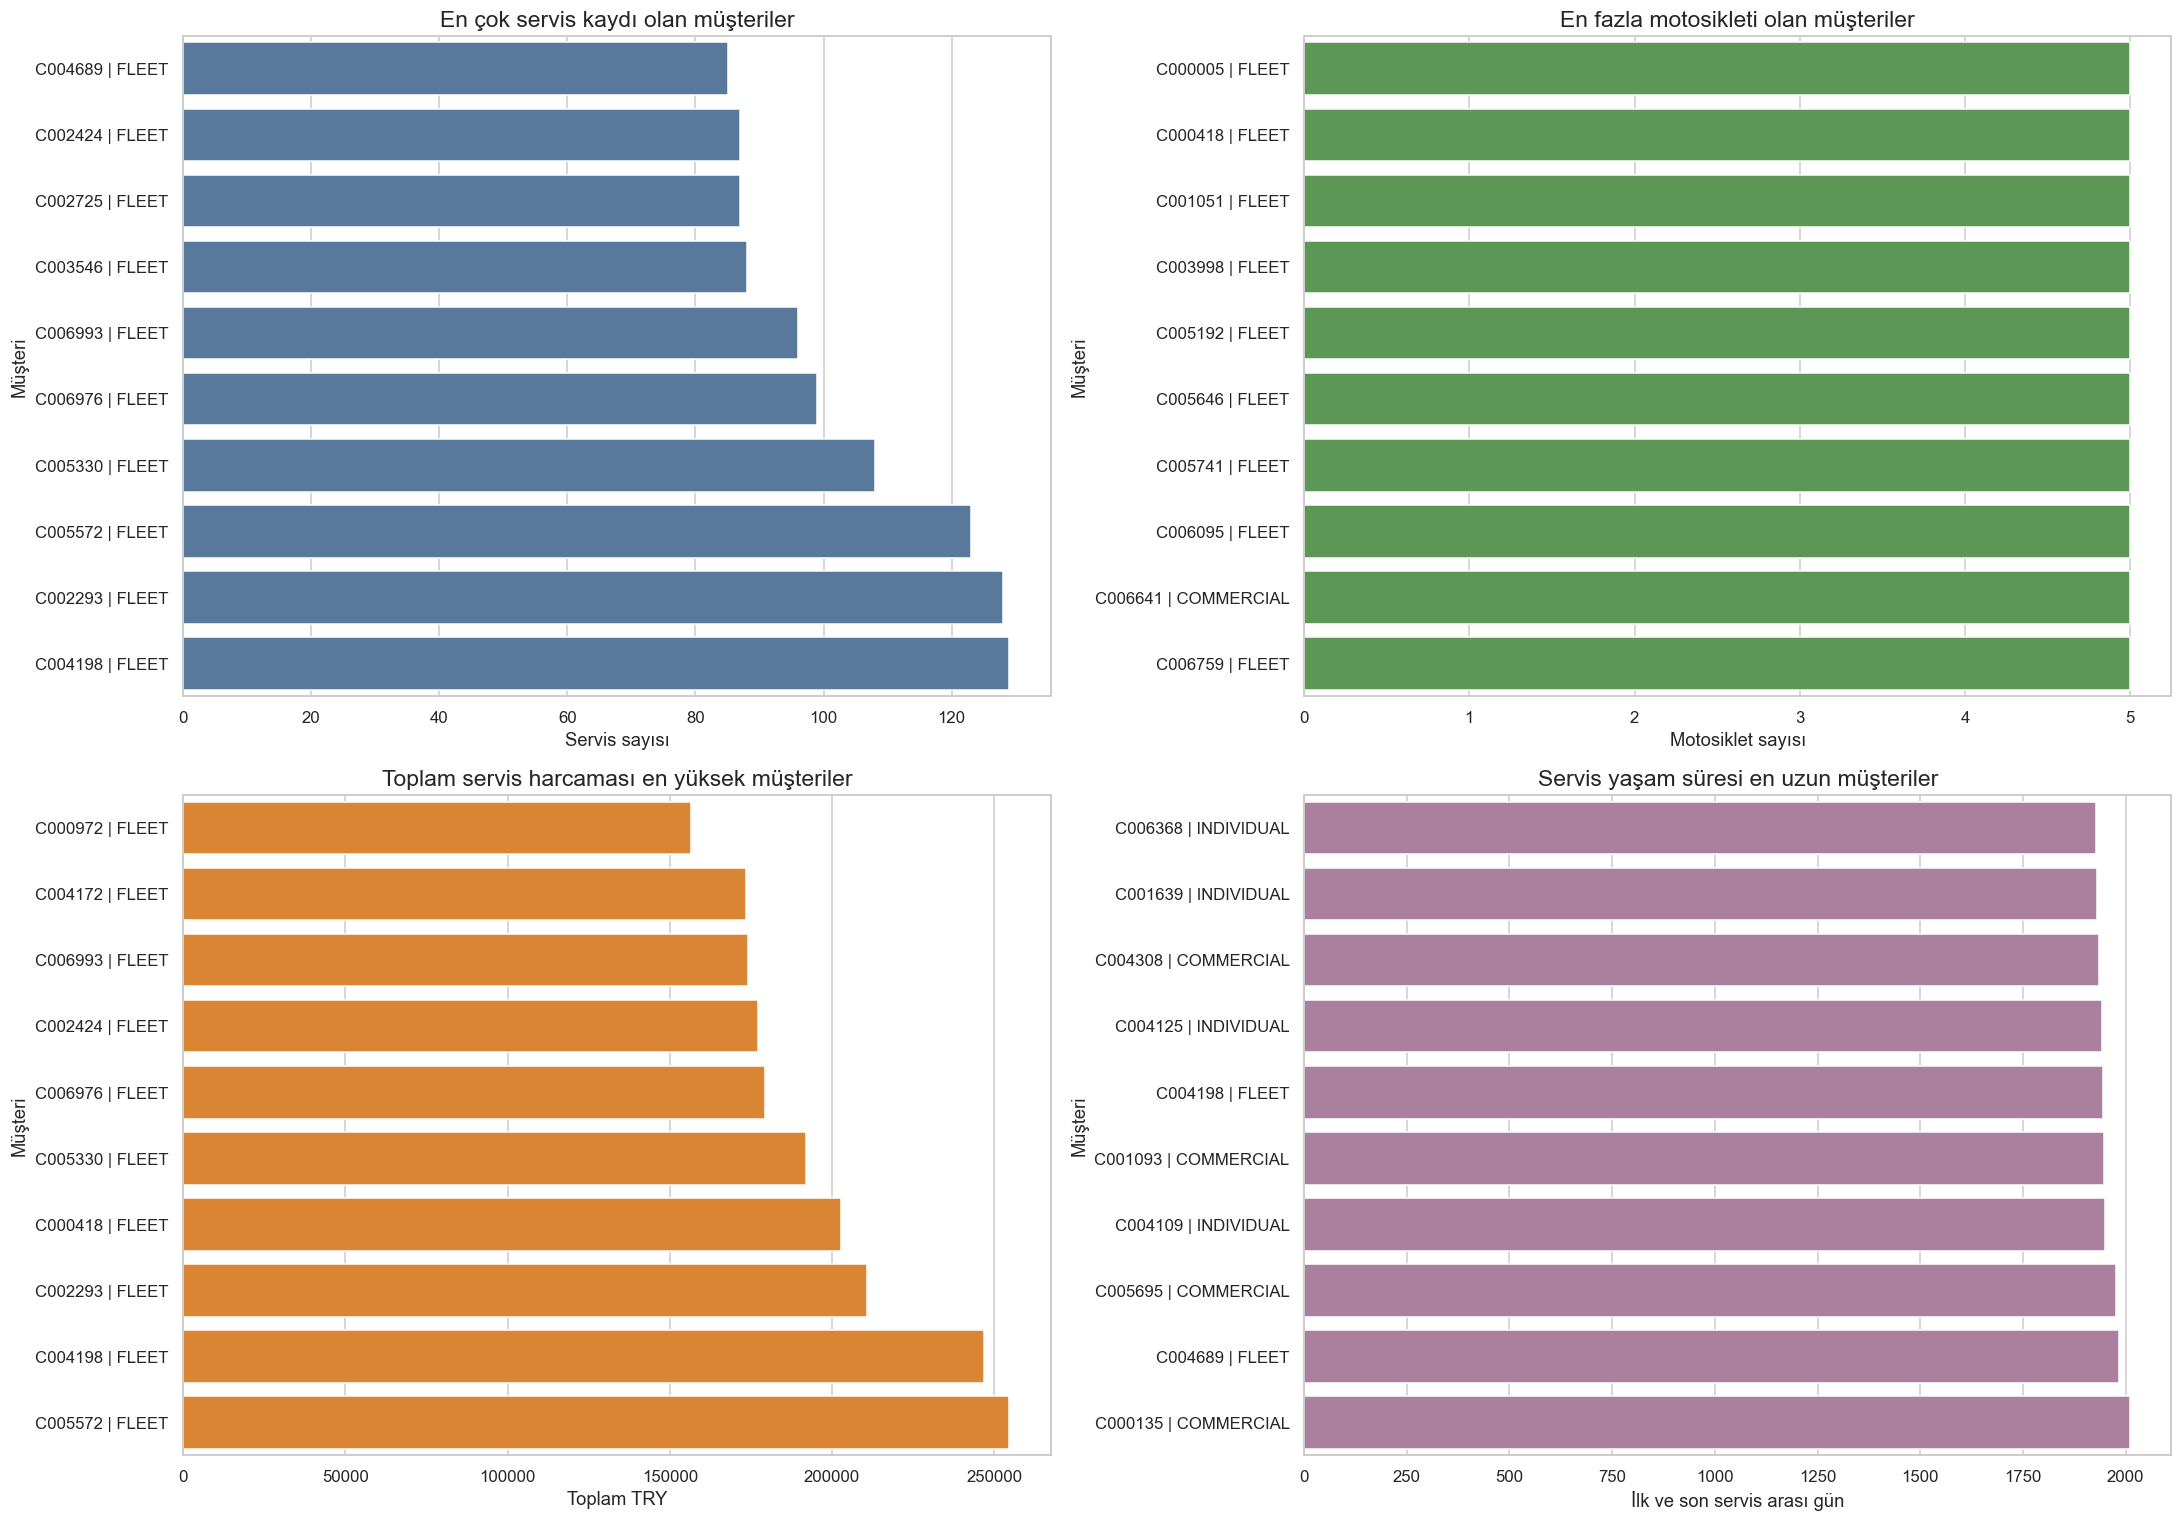


- **En çok servisi olan müşteri:** `C004198` — **129 servis**.
- **En büyük motosiklet portföyü:** `C000005` — **5 motosiklet**.
- **En yüksek toplam servis harcaması:** `C005572` — **254,639 TRY**.
- **En uzun servis yaşam süresi:** `C000135` — **2011 gün**.


In [50]:
customer_extremes = customer_lifecycle.copy()
customer_extremes["customer_label"] = customer_extremes["customer_id"] + " | " + customer_extremes["customer_type"]
most_customer_services = customer_extremes.nlargest(10, "service_count")
largest_fleets = customer_extremes.nlargest(10, "motorcycle_count")
highest_customer_spend = customer_extremes.nlargest(10, "total_spend")
longest_customer_lifecycle = customer_extremes.nlargest(10, "lifecycle_days")

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
sns.barplot(data=most_customer_services.sort_values("service_count"), x="service_count", y="customer_label", ax=axes[0,0], color="#4C78A8")
sns.barplot(data=largest_fleets.sort_values("motorcycle_count"), x="motorcycle_count", y="customer_label", ax=axes[0,1], color="#54A24B")
sns.barplot(data=highest_customer_spend.sort_values("total_spend"), x="total_spend", y="customer_label", ax=axes[1,0], color="#F58518")
sns.barplot(data=longest_customer_lifecycle.sort_values("lifecycle_days"), x="lifecycle_days", y="customer_label", ax=axes[1,1], color="#B279A2")
axes[0,0].set(title="En çok servis kaydı olan müşteriler", xlabel="Servis sayısı", ylabel="Müşteri")
axes[0,1].set(title="En fazla motosikleti olan müşteriler", xlabel="Motosiklet sayısı", ylabel="Müşteri")
axes[1,0].set(title="Toplam servis harcaması en yüksek müşteriler", xlabel="Toplam TRY", ylabel="Müşteri")
axes[1,1].set(title="Servis yaşam süresi en uzun müşteriler", xlabel="İlk ve son servis arası gün", ylabel="Müşteri")
finish_plot(fig, "41_customer_extremes.png")

display(Markdown(f"""
- **En çok servisi olan müşteri:** `{most_customer_services.iloc[0]['customer_id']}` — **{most_customer_services.iloc[0]['service_count']:.0f} servis**.
- **En büyük motosiklet portföyü:** `{largest_fleets.iloc[0]['customer_id']}` — **{largest_fleets.iloc[0]['motorcycle_count']:.0f} motosiklet**.
- **En yüksek toplam servis harcaması:** `{highest_customer_spend.iloc[0]['customer_id']}` — **{highest_customer_spend.iloc[0]['total_spend']:,.0f} TRY**.
- **En uzun servis yaşam süresi:** `{longest_customer_lifecycle.iloc[0]['customer_id']}` — **{longest_customer_lifecycle.iloc[0]['lifecycle_days']:.0f} gün**.
"""))

### Grafik ne anlatıyor?

Müşteri enleri bireysel müşteri ile filo müşterisini aynı tabloda gösterebilir. Filo müşterisinin çok servis ve yüksek harcamaya sahip olması, tek motosikletin sorunlu olduğunu değil portföyde daha fazla motosiklet bulunduğunu gösterebilir. Bu nedenle servis sayısı, motosiklet sayısı ve harcama ayrı sıralandı.

## 6. Workshop enleri

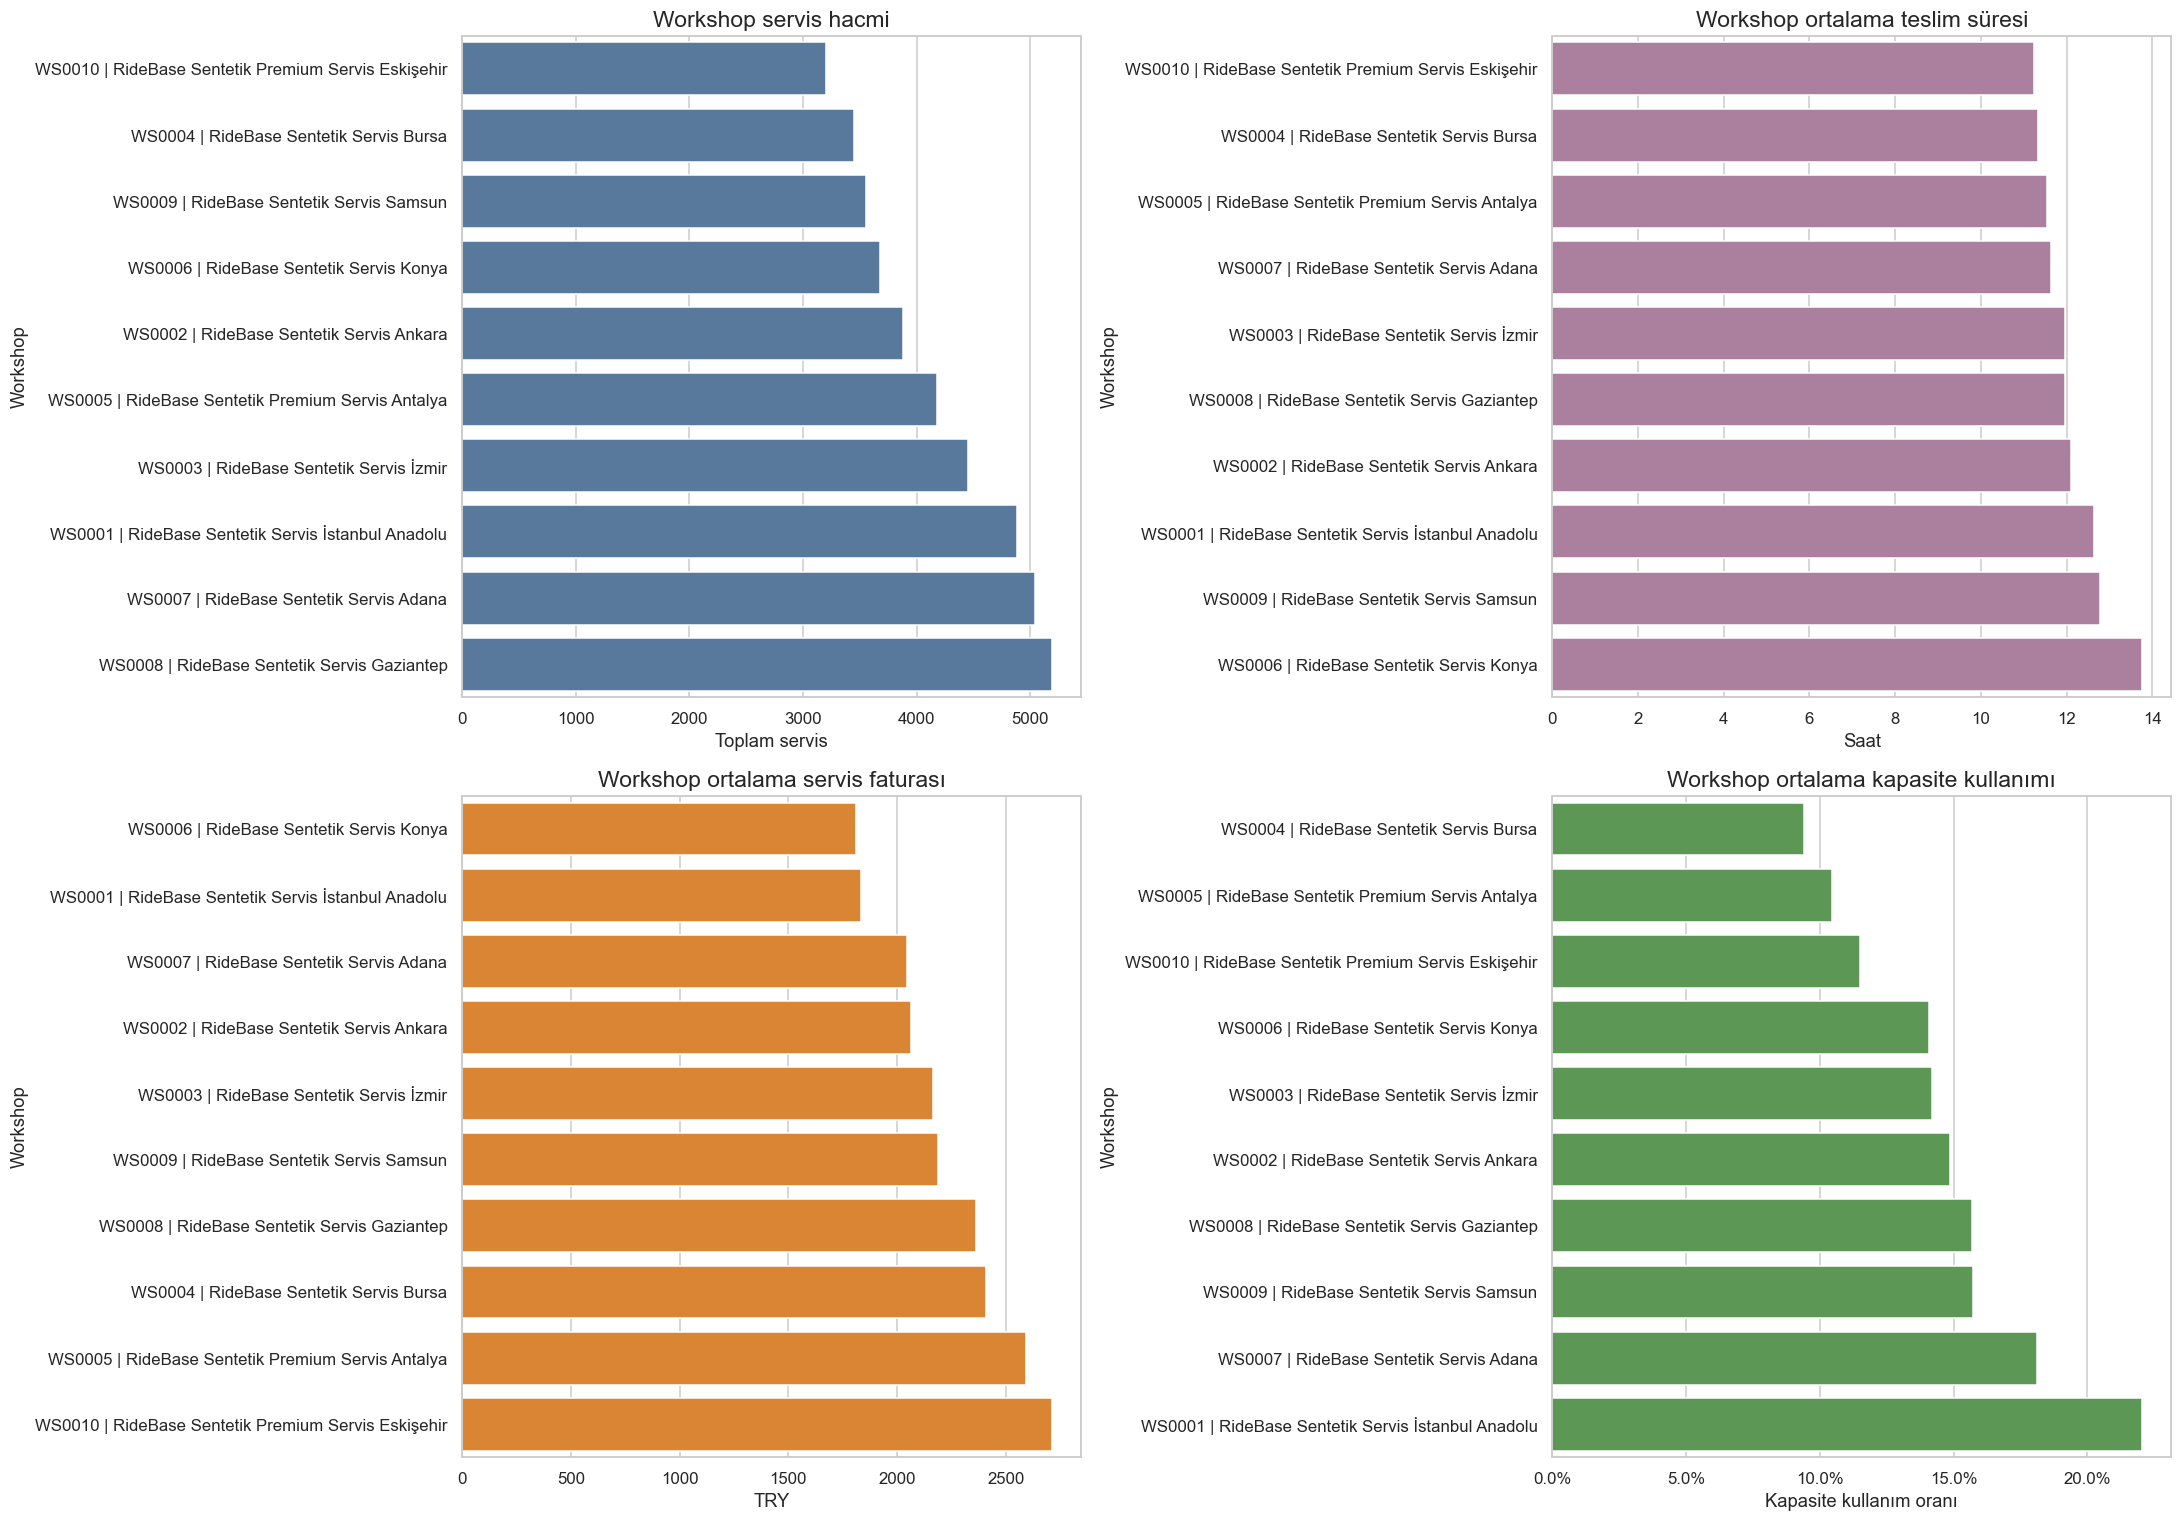

,workshop_id,service_count,avg_service_cost,median_service_cost,avg_turnaround_hours,breakdown_rate,workshop_name,daily_service_capacity,service_bay_count,technician_count,avg_utilization,p95_utilization,over_capacity_days,workshop_label
7,WS0008,5189,2363.604,1996.560,11.968,0.023,RideBase Sentetik Servis Gaziantep,19,7,9,0.157,0.421,0,WS0008 | RideBase Sentetik Servis Gaziantep
6,WS0007,5044,2046.245,1704.100,11.634,0.020,RideBase Sentetik Servis Adana,16,6,7,0.181,0.438,0,WS0007 | RideBase Sentetik Servis Adana
0,WS0001,4879,1833.256,1555.200,12.647,0.023,RideBase Sentetik Servis İstanbul Anadolu,11,4,5,0.220,0.636,8,WS0001 | RideBase Sentetik Servis İstanbul Anadolu
2,WS0003,4454,2166.953,1767.600,11.967,0.023,RideBase Sentetik Servis İzmir,18,7,8,0.142,0.389,0,WS0003 | RideBase Sentetik Servis İzmir
4,WS0005,4178,2592.104,2163.145,11.548,0.026,RideBase Sentetik Premium Servis Antalya,23,9,11,0.104,0.293,0,WS0005 | RideBase Sentetik Premium Servis Antalya
1,WS0002,3881,2064.035,1692.000,12.098,0.023,RideBase Sentetik Servis Ankara,15,6,7,0.149,0.400,0,WS0002 | RideBase Sentetik Servis Ankara
5,WS0006,3681,1809.344,1559.520,13.754,0.024,RideBase Sentetik Servis Konya,13,5,6,0.141,0.462,0,WS0006 | RideBase Sentetik Servis Konya
8,WS0009,3556,2186.619,1843.200,12.768,0.023,RideBase Sentetik Servis Samsun,13,5,6,0.157,0.462,0,WS0009 | RideBase Sentetik Servis Samsun
3,WS0004,3450,2410.094,2029.200,11.329,0.026,RideBase Sentetik Servis Bursa,21,8,10,0.094,0.238,0,WS0004 | RideBase Sentetik Servis Bursa
9,WS0010,3206,2711.232,2209.800,11.233,0.030,RideBase Sentetik Premium Servis Eskişehir,16,6,8,0.115,0.312,0,WS0010 | RideBase Sentetik Premium Servis Eskişehir


In [51]:
workshop_extremes = workshop_summary.merge(capacity_summary[["workshop_id","avg_utilization","p95_utilization","over_capacity_days"]], on="workshop_id", how="left")
workshop_extremes["workshop_label"] = workshop_extremes["workshop_id"] + " | " + workshop_extremes["workshop_name"]

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
sns.barplot(data=workshop_extremes.sort_values("service_count"), x="service_count", y="workshop_label", ax=axes[0,0], color="#4C78A8")
sns.barplot(data=workshop_extremes.sort_values("avg_turnaround_hours"), x="avg_turnaround_hours", y="workshop_label", ax=axes[0,1], color="#B279A2")
sns.barplot(data=workshop_extremes.sort_values("avg_service_cost"), x="avg_service_cost", y="workshop_label", ax=axes[1,0], color="#F58518")
sns.barplot(data=workshop_extremes.sort_values("avg_utilization"), x="avg_utilization", y="workshop_label", ax=axes[1,1], color="#54A24B")
axes[0,0].set(title="Workshop servis hacmi", xlabel="Toplam servis", ylabel="Workshop")
axes[0,1].set(title="Workshop ortalama teslim süresi", xlabel="Saat", ylabel="Workshop")
axes[1,0].set(title="Workshop ortalama servis faturası", xlabel="TRY", ylabel="Workshop")
axes[1,1].set(title="Workshop ortalama kapasite kullanımı", xlabel="Kapasite kullanım oranı", ylabel="Workshop"); axes[1,1].xaxis.set_major_formatter(mtick.PercentFormatter(1))
finish_plot(fig, "42_workshop_extremes.png")
display(workshop_extremes.sort_values("service_count", ascending=False).round(3))

### Grafik ne anlatıyor?

Workshop'lar dört ayrı açıdan karşılaştırılır: toplam iş hacmi, teslim süresi, ortalama fatura ve kapasite kullanımı. En yüksek fatura tek başına kötü performans değildir; fiyat seviyesi, motosiklet karması ve yapılan işlemler etkiler. En kısa teslim süresi de kalite göstergesi sayılmaz; iş türü farklı olabilir.

## 7. Görev ve parça enleri

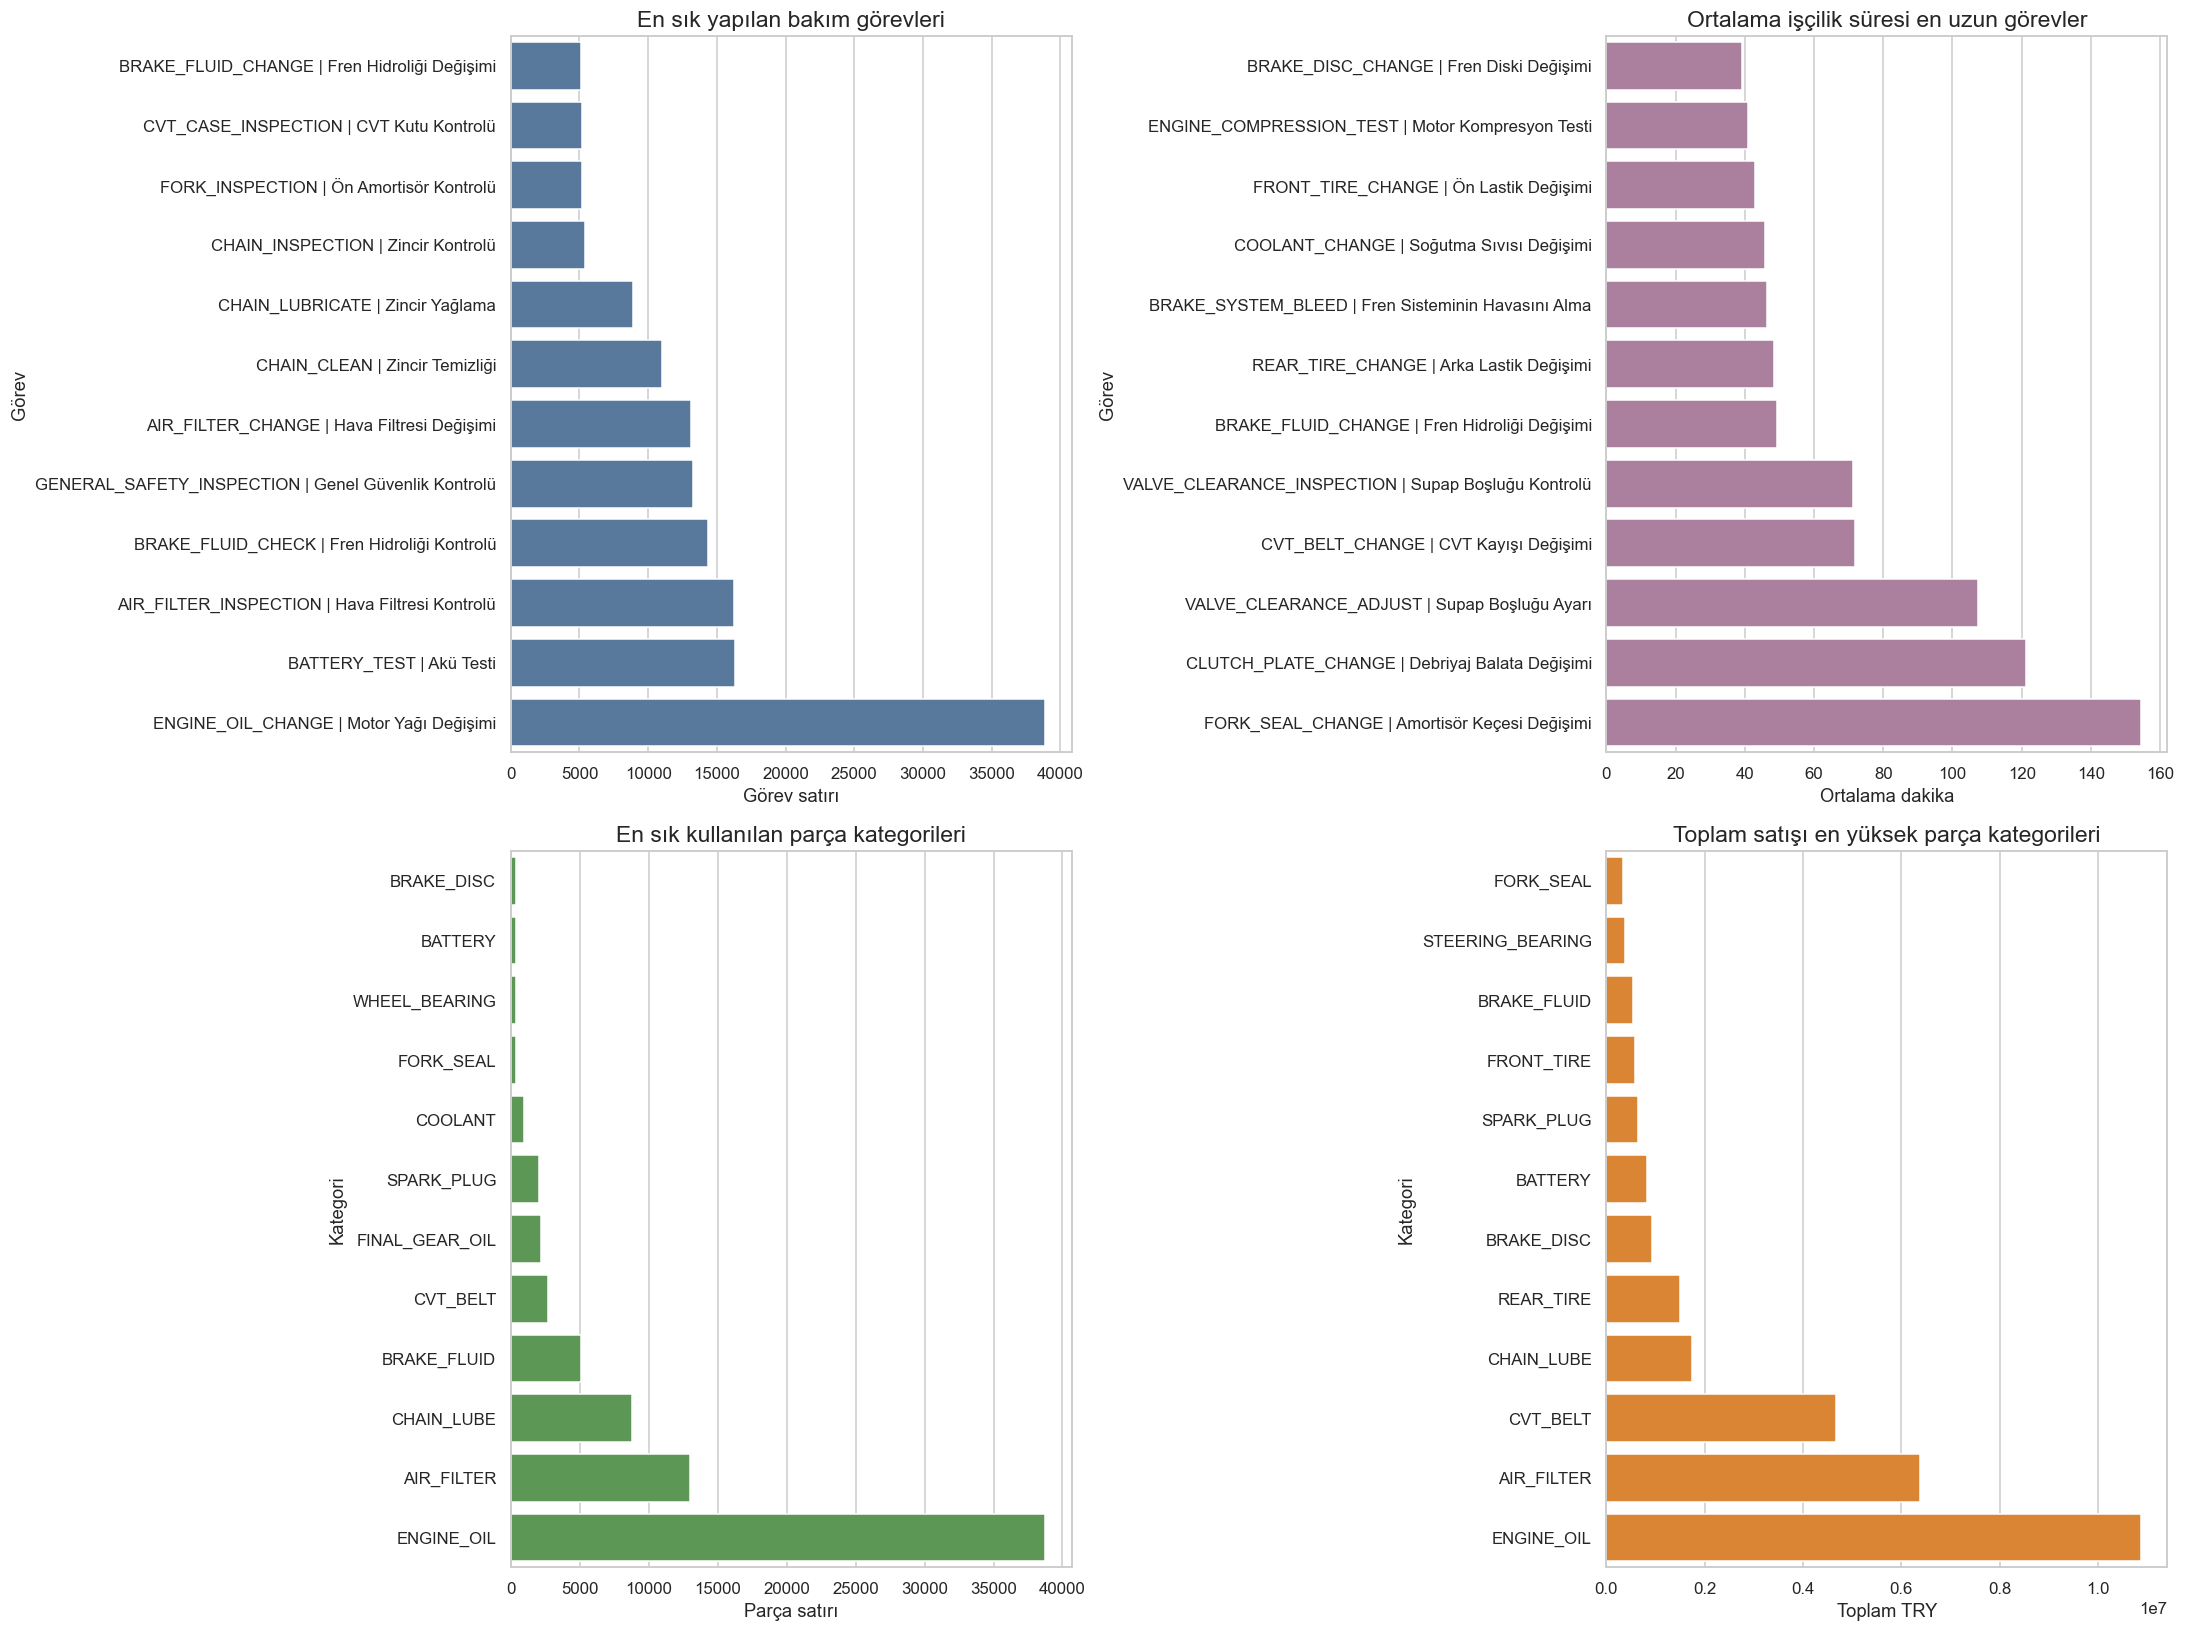

,task_code,canonical_name_tr,task_count,completed_rate,avg_labor_minutes,avg_labor_cost,task_label
28,ENGINE_OIL_CHANGE,Motor Yağı Değişimi,38882,1.00,25.67,274.61,ENGINE_OIL_CHANGE | Motor Yağı Değişimi
5,BATTERY_TEST,Akü Testi,16335,0.99,32.68,352.40,BATTERY_TEST | Akü Testi
3,AIR_FILTER_INSPECTION,Hava Filtresi Kontrolü,16224,0.99,12.26,132.27,AIR_FILTER_INSPECTION | Hava Filtresi Kontrolü
9,BRAKE_FLUID_CHECK,Fren Hidroliği Kontrolü,14329,0.99,12.23,131.59,BRAKE_FLUID_CHECK | Fren Hidroliği Kontrolü
43,GENERAL_SAFETY_INSPECTION,Genel Güvenlik Kontrolü,13246,0.99,22.48,238.35,GENERAL_SAFETY_INSPECTION | Genel Güvenlik Kontrolü
1,AIR_FILTER_CHANGE,Hava Filtresi Değişimi,13091,0.99,20.45,221.38,AIR_FILTER_CHANGE | Hava Filtresi Değişimi
11,CHAIN_CLEAN,Zincir Temizliği,10988,0.99,20.41,218.83,CHAIN_CLEAN | Zincir Temizliği
13,CHAIN_LUBRICATE,Zincir Yağlama,8888,0.99,12.25,132.21,CHAIN_LUBRICATE | Zincir Yağlama
12,CHAIN_INSPECTION,Zincir Kontrolü,5421,0.99,12.28,131.53,CHAIN_INSPECTION | Zincir Kontrolü
34,FORK_INSPECTION,Ön Amortisör Kontrolü,5195,0.99,12.26,130.07,FORK_INSPECTION | Ön Amortisör Kontrolü


,part_category,use_count,median_unit_price,max_unit_price,total_sales
8,ENGINE_OIL,38734,300.0,675.0,10870669.5
0,AIR_FILTER,13002,490.0,1150.0,6373185.0
7,CVT_BELT,2681,1750.0,4100.0,4673865.0
4,CHAIN_LUBE,8818,190.0,430.0,1739790.0
14,REAR_TIRE,362,4000.0,8200.0,1490900.0
2,BRAKE_DISC,390,2350.0,5200.0,921750.0
1,BATTERY,398,2000.0,4750.0,824590.0
15,SPARK_PLUG,2082,300.0,700.0,641070.0
11,FRONT_TIRE,192,3000.0,6050.0,572925.0
3,BRAKE_FLUID,5109,210.0,430.0,551630.0


In [52]:
task_extremes = task_detail.groupby(["task_code","canonical_name_tr"]).agg(
    task_count=("service_task_id","size"),
    completed_rate=("completed","mean"),
    avg_labor_minutes=("labor_minutes","mean"),
    avg_labor_cost=("labor_cost","mean"),
).reset_index()
task_extremes["task_label"] = task_extremes["task_code"] + " | " + task_extremes["canonical_name_tr"].fillna("")
most_common_tasks = task_extremes.nlargest(12, "task_count")
longest_tasks = task_extremes.query("task_count >= 100").nlargest(12, "avg_labor_minutes")

part_extremes = parts_eda.groupby("part_category").agg(
    use_count=("service_part_id","size"),
    median_unit_price=("unit_sale_price","median"),
    max_unit_price=("unit_sale_price","max"),
    total_sales=("sale_total","sum"),
).reset_index()
most_used_parts = part_extremes.nlargest(12, "use_count")
highest_part_sales = part_extremes.nlargest(12, "total_sales")

fig, axes = plt.subplots(2, 2, figsize=(20, 15))
sns.barplot(data=most_common_tasks.sort_values("task_count"), x="task_count", y="task_label", ax=axes[0,0], color="#4C78A8")
sns.barplot(data=longest_tasks.sort_values("avg_labor_minutes"), x="avg_labor_minutes", y="task_label", ax=axes[0,1], color="#B279A2")
sns.barplot(data=most_used_parts.sort_values("use_count"), x="use_count", y="part_category", ax=axes[1,0], color="#54A24B")
sns.barplot(data=highest_part_sales.sort_values("total_sales"), x="total_sales", y="part_category", ax=axes[1,1], color="#F58518")
axes[0,0].set(title="En sık yapılan bakım görevleri", xlabel="Görev satırı", ylabel="Görev")
axes[0,1].set(title="Ortalama işçilik süresi en uzun görevler", xlabel="Ortalama dakika", ylabel="Görev")
axes[1,0].set(title="En sık kullanılan parça kategorileri", xlabel="Parça satırı", ylabel="Kategori")
axes[1,1].set(title="Toplam satışı en yüksek parça kategorileri", xlabel="Toplam TRY", ylabel="Kategori")
finish_plot(fig, "43_task_part_extremes.png")
display(task_extremes.sort_values("task_count", ascending=False).head(20).round(2), part_extremes.sort_values("total_sales", ascending=False).head(20).round(2))

### Grafik ne anlatıyor?

Görev sıklığı servis iş yükünü, ortalama işçilik dakikası görevin emek yoğunluğunu gösterir. Parçada **kullanım sayısı** ile **toplam satış tutarı** ayrıdır: ucuz ama sık kullanılan bir kategori adet lideri olabilir; pahalı ama daha az kullanılan bir kategori ciro lideri olabilir.

## 8. Genel enler özeti — tek bakışta lider kayıtlar

In [53]:
def bike_name(row):
    return f"{row['brand']} {row['model_name']}"

def group_support(row):
    return f"{row['motorcycle_count']:,.0f} motosiklet / {row['service_count']:,.0f} servis"

oldest_bike = oldest_active.iloc[0]
longest_observed_bike = longest_observed.iloc[0]
most_used_bike = most_used.iloc[0]
least_used_bike = least_used.iloc[0]
most_total_use_bike = most_total_use.iloc[0]
longest_month_bike = longest_month.iloc[0]
most_serviced_bike = most_serviced.iloc[0]
most_breakdown_bike = most_breakdowns.iloc[0]
highest_breakdown_rate_bike = highest_breakdown_rate.iloc[0]
most_warranty_bike = most_warranty.iloc[0]
highest_spend_bike = highest_spend.iloc[0]
highest_avg_cost_bike = highest_avg_service_cost_motor.iloc[0]
longest_gap_bike = longest_service_gaps.iloc[0]

top_workshop_volume = workshop_extremes.nlargest(1, "service_count").iloc[0]
top_workshop_turnaround = workshop_extremes.nlargest(1, "avg_turnaround_hours").iloc[0]
top_workshop_cost = workshop_extremes.nlargest(1, "avg_service_cost").iloc[0]
top_workshop_utilization = workshop_extremes.nlargest(1, "avg_utilization").iloc[0]

extreme_rows = []
def add_extreme(scope, category, winner, record_id, value, support, note):
    extreme_rows.append({
        "Kapsam": scope, "En kategorisi": category, "Kazanan": winner,
        "Kayıt / grup ID": record_id, "Değer": value,
        "Karşılaştırma desteği": support, "Ölçüt / uyarı": note,
    })

# Motosiklet ömrü ve kullanım enleri
add_extreme("Motosiklet — ömür/kullanım", "En yaşlı aktif motosiklet", bike_name(oldest_bike), oldest_bike["motorcycle_id"], f"{oldest_bike['approx_age_years']:.0f} yaş", "1 aktif motosiklet", f"{analysis_reference_year} - üretim yılı; gerçek mekanik ömür değildir")
add_extreme("Motosiklet — ömür/kullanım", "En uzun gözlenen motosiklet", bike_name(longest_observed_bike), longest_observed_bike["motorcycle_id"], f"{longest_observed_bike['observed_days']:,.0f} gün", "1 motosiklet", "Gözlem başlangıcı ile etkin gözlem sonu")
add_extreme("Motosiklet — ömür/kullanım", "Aylık ortalaması en yüksek kullanım", bike_name(most_used_bike), most_used_bike["motorcycle_id"], f"{most_used_bike['avg_monthly_km']:,.0f} km/ay", f"{most_used_bike['observed_months']:.0f} ay", "Aktif ve en az 12 ay gözlem")
add_extreme("Motosiklet — ömür/kullanım", "Aylık ortalaması en düşük kullanım", bike_name(least_used_bike), least_used_bike["motorcycle_id"], f"{least_used_bike['avg_monthly_km']:,.0f} km/ay", f"{least_used_bike['observed_months']:.0f} ay", "Aktif ve en az 12 ay gözlem")
add_extreme("Motosiklet — ömür/kullanım", "Gözlemde en yüksek toplam kilometre", bike_name(most_total_use_bike), most_total_use_bike["motorcycle_id"], f"{most_total_use_bike['total_added_km']:,.0f} km", f"{most_total_use_bike['observed_months']:.0f} ay", "Aylık kilometre eklemeleri toplamı")
add_extreme("Motosiklet — ömür/kullanım", "Tek ayda en yüksek kilometre", bike_name(longest_month_bike), longest_month_bike["motorcycle_id"], f"{longest_month_bike['max_monthly_km']:,.0f} km", "1 motosiklet-ay", "Tur değil, aylık toplam")

# Motosiklet servis, arıza, garanti ve maliyet enleri
add_extreme("Motosiklet — servis/maliyet", "En çok servis gören motosiklet", bike_name(most_serviced_bike), most_serviced_bike["motorcycle_id"], f"{most_serviced_bike['service_count']:.0f} servis", "Tüm gözlem dönemi", "Benzersiz servis sayısı")
add_extreme("Motosiklet — servis/maliyet", "En fazla arıza kaydı", bike_name(most_breakdown_bike), most_breakdown_bike["motorcycle_id"], f"{most_breakdown_bike['breakdown_count']:.0f} arıza", f"{most_breakdown_bike['service_count']:.0f} servis", "Ham arıza servisi sayısı")
add_extreme("Motosiklet — servis/maliyet", "En yüksek arıza oranı", bike_name(highest_breakdown_rate_bike), highest_breakdown_rate_bike["motorcycle_id"], f"%{highest_breakdown_rate_bike['breakdown_rate']*100:.1f}", f"{highest_breakdown_rate_bike['service_count']:.0f} servis", "En az 5 servis")
add_extreme("Motosiklet — servis/maliyet", "En fazla garanti servisi", bike_name(most_warranty_bike), most_warranty_bike["motorcycle_id"], f"{most_warranty_bike['warranty_count']:.0f} garanti", f"{most_warranty_bike['service_count']:.0f} servis", "Ham garanti servisi sayısı")
add_extreme("Motosiklet — servis/maliyet", "En yüksek toplam servis harcaması", bike_name(highest_spend_bike), highest_spend_bike["motorcycle_id"], f"{highest_spend_bike['total_spend']:,.0f} TRY", f"{highest_spend_bike['service_count']:.0f} servis", "Tüm nihai servis faturaları")
add_extreme("Motosiklet — servis/maliyet", "Servis başı ortalama harcaması en yüksek", bike_name(highest_avg_cost_bike), highest_avg_cost_bike["motorcycle_id"], f"{highest_avg_cost_bike['avg_service_cost']:,.0f} TRY/servis", f"{highest_avg_cost_bike['service_count']:.0f} servis", "En az 5 servis")
add_extreme("Motosiklet — servis/maliyet", "İki servis arasında en uzun boşluk", str(longest_gap_bike["motor_label"]).split(" | ", 1)[-1], longest_gap_bike["motorcycle_id"], f"{longest_gap_bike['gap_days']:,.0f} gün", "Ardışık 2 servis", "Servis kabul tarihleri arası")

# Tek servis kaydı enleri
add_extreme("Servis kaydı", "En uzun servis", longest_services.iloc[0]["motor_name"], longest_services.iloc[0]["service_id"], f"{longest_services.iloc[0]['turnaround_hours']:.1f} saat", "1 servis", "Kabulden teslime; aktif işçilik süresi değildir")
add_extreme("Servis kaydı", "En pahalı servis", most_expensive_services.iloc[0]["motor_name"], most_expensive_services.iloc[0]["service_id"], f"{most_expensive_services.iloc[0]['grand_total']:,.0f} TRY", "1 servis", "Nihai fatura")
add_extreme("Servis kaydı", "İşçilik toplamı en yüksek servis", highest_labor_services.iloc[0]["motor_name"], highest_labor_services.iloc[0]["service_id"], f"{highest_labor_services.iloc[0]['labor_total']:,.0f} TRY", "1 servis", "İşçilik toplamı")
add_extreme("Servis kaydı", "Parça toplamı en yüksek servis", highest_parts_services.iloc[0]["motor_name"], highest_parts_services.iloc[0]["service_id"], f"{highest_parts_services.iloc[0]['parts_total']:,.0f} TRY", "1 servis", "Parça satış toplamı")
add_extreme("Servis kaydı", "En çok görev içeren servis", most_tasks_services.iloc[0]["motor_name"], most_tasks_services.iloc[0]["service_id"], f"{most_tasks_services.iloc[0]['task_count']:.0f} görev", "1 servis", "Benzersiz görev satırı sayısı")

# Marka enleri
for category, row, value, note in [
    ("Ortalama yaşı en yüksek aktif marka filosu", oldest_brand_fleet.iloc[0], f"{oldest_brand_fleet.iloc[0]['avg_active_age_years']:.1f} yaş", "Aktif araçların yaklaşık yaş ortalaması"),
    ("Aylık ortalama kullanımı en yüksek marka", highest_brand_usage.iloc[0], f"{highest_brand_usage.iloc[0]['avg_monthly_km']:,.0f} km/ay", "Araçların aylık ortalamalarının ortalaması"),
    ("En çok motosiklete sahip marka", most_common_brands.iloc[0], f"{most_common_brands.iloc[0]['motorcycle_count']:,.0f} motosiklet", "Dataset içi adet"),
    ("En fazla arıza kaydı bulunan marka", most_brand_breakdowns.iloc[0], f"{most_brand_breakdowns.iloc[0]['breakdown_count']:,.0f} arıza", "Ham arıza sayısı; hacim etkilenir"),
    ("Arıza oranı en yüksek marka", highest_brand_breakdown.iloc[0], f"%{highest_brand_breakdown.iloc[0]['breakdown_rate']*100:.1f}", "En az 50 motosiklet ve 300 servis"),
    ("Toplam servis harcaması en yüksek marka", highest_brand_spend.iloc[0], f"{highest_brand_spend.iloc[0]['total_spend']:,.0f} TRY", "Tüm motosikletlerin toplamı; hacim etkilenir"),
    ("Motosiklet başına harcaması en yüksek marka", highest_brand_spend_per_motorcycle.iloc[0], f"{highest_brand_spend_per_motorcycle.iloc[0]['avg_spend_per_motorcycle']:,.0f} TRY/motosiklet", "En az 50 motosiklet ve 300 servis"),
    ("Servis başı ortalama faturası en yüksek marka", highest_brand_service_cost.iloc[0], f"{highest_brand_service_cost.iloc[0]['avg_service_cost']:,.0f} TRY/servis", "En az 50 motosiklet ve 300 servis"),
]:
    add_extreme("Marka", category, row["brand"], row["brand"], value, group_support(row), note)

# Marka altında model enleri
for category, row, value, note in [
    ("Ortalama yaşı en yüksek aktif model filosu", oldest_model_fleet.iloc[0], f"{oldest_model_fleet.iloc[0]['avg_active_age_years']:.1f} yaş", "Aktif araçların yaklaşık yaş ortalaması"),
    ("Aylık ortalama kullanımı en yüksek model", highest_model_usage.iloc[0], f"{highest_model_usage.iloc[0]['avg_monthly_km']:,.0f} km/ay", "Araçların aylık ortalamalarının ortalaması"),
    ("Dataset içinde en çok bulunan model", most_common_models.iloc[0], f"{most_common_models.iloc[0]['motorcycle_count']:,.0f} motosiklet", "Marka + model birlikte gruplandı"),
    ("En fazla arıza kaydı bulunan model", most_model_breakdowns.iloc[0], f"{most_model_breakdowns.iloc[0]['breakdown_count']:,.0f} arıza", "Ham arıza sayısı; hacim etkilenir"),
    ("Arıza oranı en yüksek model", highest_model_breakdown.iloc[0], f"%{highest_model_breakdown.iloc[0]['breakdown_rate']*100:.1f}", "En az 20 motosiklet ve 100 servis"),
    ("Toplam servis harcaması en yüksek model", highest_model_spend.iloc[0], f"{highest_model_spend.iloc[0]['total_spend']:,.0f} TRY", "Modeldeki tüm motosikletlerin toplamı"),
    ("Motosiklet başına harcaması en yüksek model", highest_model_spend_per_motorcycle.iloc[0], f"{highest_model_spend_per_motorcycle.iloc[0]['avg_spend_per_motorcycle']:,.0f} TRY/motosiklet", "En az 20 motosiklet ve 100 servis"),
    ("Servis başı ortalama faturası en yüksek model", highest_model_cost.iloc[0], f"{highest_model_cost.iloc[0]['avg_service_cost']:,.0f} TRY/servis", "En az 20 motosiklet ve 100 servis"),
]:
    add_extreme("Model (marka altında)", category, row["model_label"], row["model_id"], value, group_support(row), note)

# Müşteri, workshop, görev ve parça enleri
add_extreme("Müşteri", "En çok servisli müşteri", most_customer_services.iloc[0]["customer_type"], most_customer_services.iloc[0]["customer_id"], f"{most_customer_services.iloc[0]['service_count']:,.0f} servis", f"{most_customer_services.iloc[0]['motorcycle_count']:.0f} motosiklet", "Müşteri toplamı")
add_extreme("Müşteri", "En büyük motosiklet portföyü", largest_fleets.iloc[0]["customer_type"], largest_fleets.iloc[0]["customer_id"], f"{largest_fleets.iloc[0]['motorcycle_count']:.0f} motosiklet", "1 müşteri", "Benzersiz motosiklet")
add_extreme("Müşteri", "En yüksek toplam servis harcaması", highest_customer_spend.iloc[0]["customer_type"], highest_customer_spend.iloc[0]["customer_id"], f"{highest_customer_spend.iloc[0]['total_spend']:,.0f} TRY", f"{highest_customer_spend.iloc[0]['service_count']:.0f} servis", "Müşteri toplamı")
add_extreme("Müşteri", "En uzun servis yaşam döngüsü", longest_customer_lifecycle.iloc[0]["customer_type"], longest_customer_lifecycle.iloc[0]["customer_id"], f"{longest_customer_lifecycle.iloc[0]['lifecycle_days']:,.0f} gün", f"{longest_customer_lifecycle.iloc[0]['service_count']:.0f} servis", "İlk ve son servis arası")
add_extreme("Workshop", "En yüksek servis hacmi", top_workshop_volume["workshop_name"], top_workshop_volume["workshop_id"], f"{top_workshop_volume['service_count']:,.0f} servis", "Tüm gözlem dönemi", "Toplam servis hacmi")
add_extreme("Workshop", "En uzun ortalama teslim süresi", top_workshop_turnaround["workshop_name"], top_workshop_turnaround["workshop_id"], f"{top_workshop_turnaround['avg_turnaround_hours']:.1f} saat", f"{top_workshop_turnaround['service_count']:,.0f} servis", "Kabulden teslime ortalama")
add_extreme("Workshop", "En yüksek ortalama servis faturası", top_workshop_cost["workshop_name"], top_workshop_cost["workshop_id"], f"{top_workshop_cost['avg_service_cost']:,.0f} TRY/servis", f"{top_workshop_cost['service_count']:,.0f} servis", "Hizmet karmasından etkilenir")
add_extreme("Workshop", "En yüksek ortalama kapasite kullanımı", top_workshop_utilization["workshop_name"], top_workshop_utilization["workshop_id"], f"%{top_workshop_utilization['avg_utilization']*100:.1f}", f"{top_workshop_utilization['over_capacity_days']:,.0f} kapasite aşım günü", "Günlük kapasite kullanım ortalaması")
add_extreme("Bakım görevi", "En sık yapılan görev", str(most_common_tasks.iloc[0]["canonical_name_tr"]), most_common_tasks.iloc[0]["task_code"], f"{most_common_tasks.iloc[0]['task_count']:,.0f} satır", "Tüm görev kayıtları", "Görev kullanım sıklığı")
add_extreme("Bakım görevi", "Ortalama işçilik süresi en uzun görev", str(longest_tasks.iloc[0]["canonical_name_tr"]), longest_tasks.iloc[0]["task_code"], f"{longest_tasks.iloc[0]['avg_labor_minutes']:.1f} dakika", f"{longest_tasks.iloc[0]['task_count']:,.0f} görev", "En az 100 görev kaydı")
add_extreme("Parça kategorisi", "En sık kullanılan parça kategorisi", most_used_parts.iloc[0]["part_category"], most_used_parts.iloc[0]["part_category"], f"{most_used_parts.iloc[0]['use_count']:,.0f} satır", "Tüm parça kayıtları", "Parça kullanım sıklığı")
add_extreme("Parça kategorisi", "Toplam satışı en yüksek parça kategorisi", highest_part_sales.iloc[0]["part_category"], highest_part_sales.iloc[0]["part_category"], f"{highest_part_sales.iloc[0]['total_sales']:,.0f} TRY", f"{highest_part_sales.iloc[0]['use_count']:,.0f} satır", "Parça satış toplamı")

extreme_summary = pd.DataFrame(extreme_rows)
display(extreme_summary)

,Kapsam,En kategorisi,Kazanan,Kayıt / grup ID,Değer,Karşılaştırma desteği,Ölçüt / uyarı
0,Motosiklet — ömür/kullanım,En yaşlı aktif motosiklet,Honda Activa 125,MC000046,11 yaş,1 aktif motosiklet,2026 - üretim yılı; gerçek mekanik ömür değildir
1,Motosiklet — ömür/kullanım,En uzun gözlenen motosiklet,Yamaha NMAX 125,MC001084,"2,057 gün",1 motosiklet,Gözlem başlangıcı ile etkin gözlem sonu
2,Motosiklet — ömür/kullanım,Aylık ortalaması en yüksek kullanım,Yamaha NMAX 125,MC005861,"4,590 km/ay",67 ay,Aktif ve en az 12 ay gözlem
3,Motosiklet — ömür/kullanım,Aylık ortalaması en düşük kullanım,CFMOTO 250NK,MC005103,128 km/ay,61 ay,Aktif ve en az 12 ay gözlem
4,Motosiklet — ömür/kullanım,Gözlemde en yüksek toplam kilometre,Mondial Wing 50i,MC000186,"310,485 km",68 ay,Aylık kilometre eklemeleri toplamı
5,Motosiklet — ömür/kullanım,Tek ayda en yüksek kilometre,Yamaha NMAX 125,MC009972,"6,886 km",1 motosiklet-ay,"Tur değil, aylık toplam"
6,Motosiklet — servis/maliyet,En çok servis gören motosiklet,Mondial Wing 50i,MC000186,56 servis,Tüm gözlem dönemi,Benzersiz servis sayısı
7,Motosiklet — servis/maliyet,En fazla arıza kaydı,Mondial SFC MINI 50ec,MC000098,3 arıza,14 servis,Ham arıza servisi sayısı
8,Motosiklet — servis/maliyet,En yüksek arıza oranı,TVS Jupiter 125,MC000064,%40.0,5 servis,En az 5 servis
9,Motosiklet — servis/maliyet,En fazla garanti servisi,Yamaha NMAX 125,MC008912,4 garanti,19 servis,Ham garanti servisi sayısı


### Son not

Enler analizi **veri kalite kontrolü** için de kullanılır. Aşırı yüksek kilometre, maliyet veya süre gerçek bir uç durum olabileceği gibi sentetik üretim kuralı ya da veri hatası da olabilir. Bu kayıtlar modellemeye geçmeden önce ayrıca incelenmeli; sırf uçta oldukları için otomatik silinmemelidir.